[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Shift & Forensics — 20th Presidential Election (2022)

--- [1/6] Loading Demographic Census Data ---
    Loaded 3,850 census rows with 22 Age-Gender cohorts.

--- [2/6] Loading Apartment Transaction Data ---
    Calculated stable median prices for 3,423 unique Dongs.

--- [3/6] Loading Employment Covariates ---

--- [4/6] Loading Election Result Data (20th_presidential_election_result.csv, type=presidential) ---

--- [5/6] Forensics Suite ---

  ── Variable Definitions ──
  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total
                 The Democratic candidate's vote share among all valid ballots
                 cast at in-precinct early-voting stations (관내사전투표소).
  sameday_pct  = same_day_dem ÷ same_day_total
                 The Democratic share among voters who showed up on election day
                 (당일투표), the conventional voting mode.
  gap          = early_pct − same

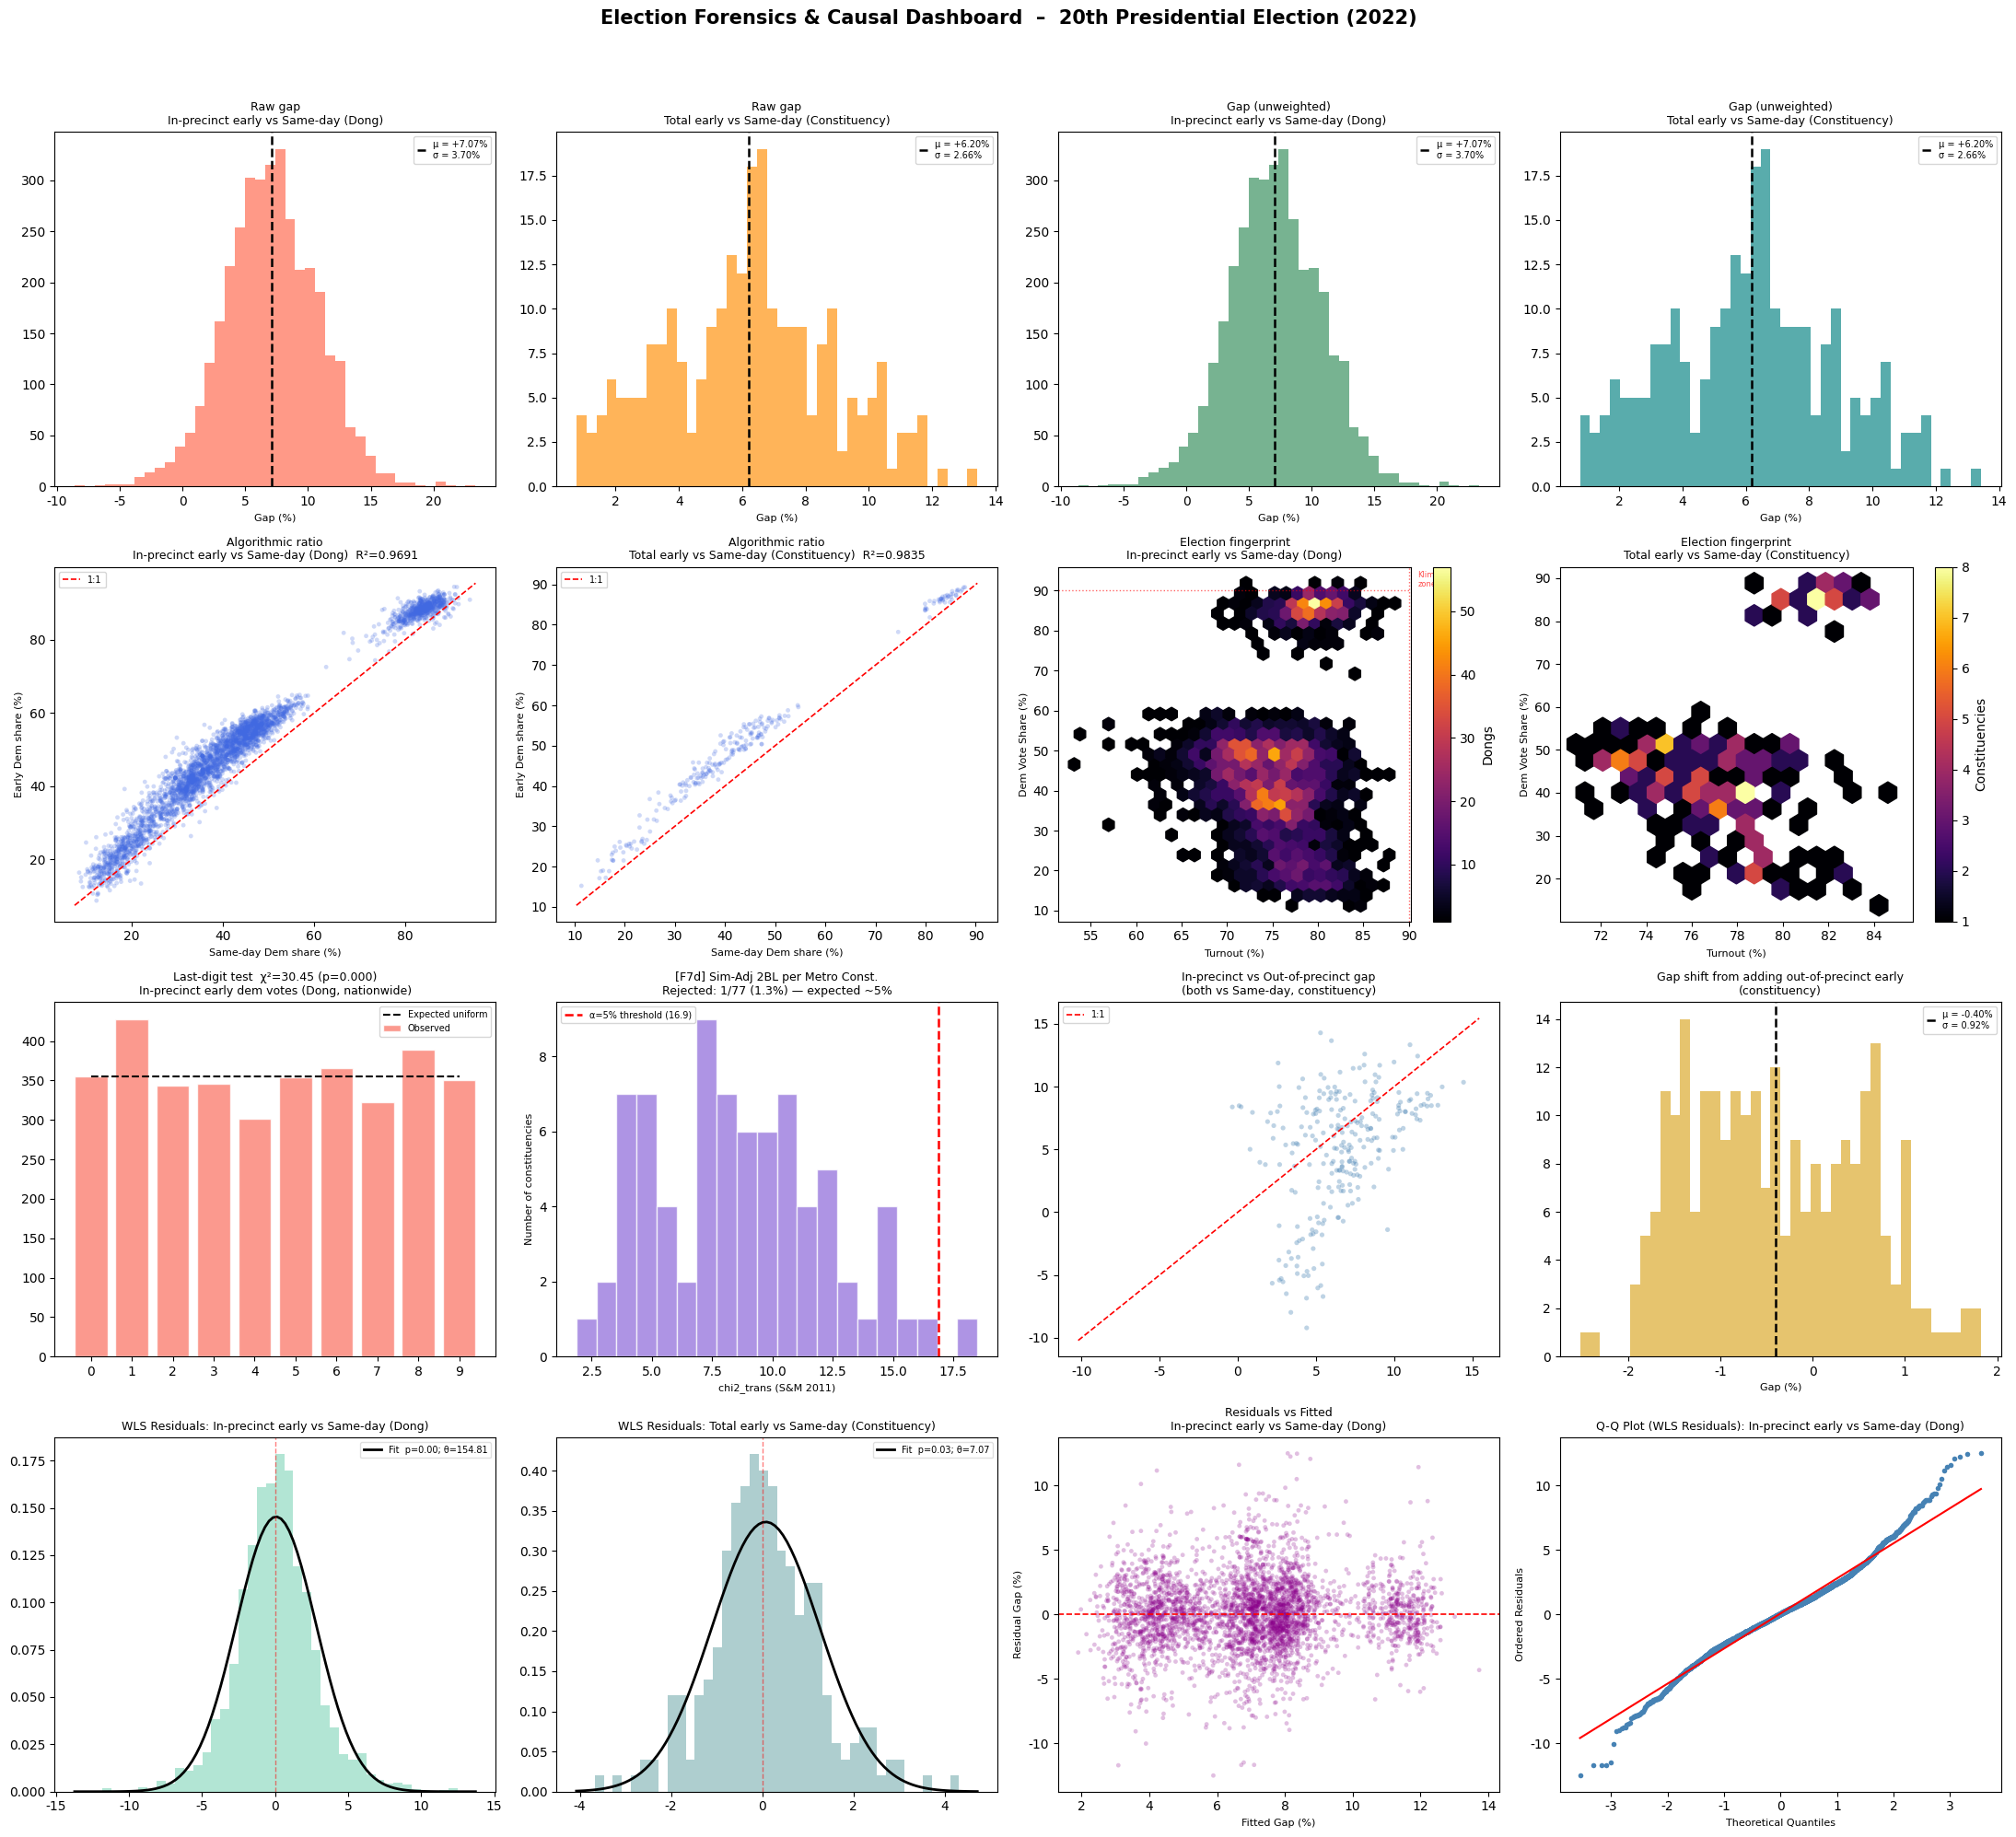

In [22]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import os
import re
import glob
from difflib import get_close_matches
from scipy.stats import (chisquare, pearsonr, norm, probplot, normaltest,
                          gaussian_kde, multivariate_t, ttest_1samp)
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# FONT SETUP
# ==========================================

def setup_font():
    """Configure matplotlib to render text properly."""
    matplotlib.rcParams['axes.unicode_minus'] = False

# ==========================================
# CONFIGURATION
# ==========================================

ELECTION_NUM = 'pres20'   # options: 21, 22, 'pres20', 'pres21'
EXCLUDE_HONAM_YEONGNAM = False

PCA_VARIANCE_THRESHOLD     = 0.95
DEMEAN_GROUP_COLS          = ['province_tag']  # Removed urban_type
MIN_COVERAGE               = 0.50

ELECTION_CONFIGS = {
    21: {
        'election_type':  'general',
        'census_csv':     '21st_election_census.csv',
        'result_csv':     '21st_election_result.csv',
        'apt_csv_glob':   '*21st_election_*_apt_price.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'미래통합당|자유한국당',
        'third_pattern':  None,
        'label':          '21st General Election (2020)',
        'year':           2020,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_21st.png',
    },
    22: {
        'election_type':  'general',
        'census_csv':     '22nd_election_census.csv',
        'result_csv':     '22nd_election_result.csv',
        'apt_csv_glob':   '*22nd_election_*_apt_price.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'국민의힘',
        'third_pattern':  None,
        'label':          '22nd General Election (2024)',
        'year':           2024,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_22nd.png',
    },
    'pres20': {
        'election_type':         'presidential',
        'census_csv':            '20th_presidential_election_census.csv',
        'result_csv':            '20th_presidential_election_result.csv',
        'apt_csv_glob':          '*20th_presidential_election_*_apt_prices.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         None,
        'label':                 '20th Presidential Election (2022)',
        'year':                  2022,
        'election_month':        3,
        'dashboard_out':         'mega_forensics_dashboard_pres20.png',
        'fallback_election_num': 21,
    },
    'pres21': {
        'election_type':         'presidential',
        'census_csv':            '21st_presidential_election_census.csv',
        'result_csv':            '21st_presidential_election_result.csv',
        'apt_csv_glob':          '*21st_presidential_election_*_apt_prices.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         r'이준석|개혁신당',
        'label':                 '21st Presidential Election (2025)',
        'year':                  2025,
        'election_month':        6,
        'dashboard_out':         'mega_forensics_dashboard_pres21.png',
        'fallback_election_num': 22,
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES_GENERAL = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES_PRESIDENTIAL = {
    '거소·선상투표', '관외사전투표', '재외투표',
    '잘못 투입·구분된 투표지',
}
GWANNAESA_LABEL = '관내사전투표'
GWANOE_LABEL    = '관외사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': 'Seoul',  '부산광역시': 'Busan',   '대구광역시': 'Daegu',
    '인천광역시': 'Incheon','광주광역시': 'Gwangju', '대전광역시': 'Daejeon',
    '울산광역시': 'Ulsan',  '세종특별자치시': 'Sejong',
    '경기도': 'Gyeonggi',  '강원도': 'Gangwon',     '강원특별자치도': 'Gangwon',
    '충청북도': 'Chungbuk', '충청남도': 'Chungnam',
    '전라북도': 'Jeonbuk',  '전북특별자치도': 'Jeonbuk', '전라남도': 'Jeonnam',
    '경상북도': 'Gyeongbuk','경상남도': 'Gyeongnam', '제주특별자치도': 'Jeju',
    # Abbreviated metro-city names used in employment CSV region column
    '서울': 'Seoul',   '부산': 'Busan',    '대구': 'Daegu',
    '인천': 'Incheon', '광주': 'Gwangju',  '대전': 'Daejeon',
    '울산': 'Ulsan',
}

# Maps standalone provincial city/county names (as they appear in employment CSVs,
# without a province prefix) to their English province tag.
SGG_TO_PROVINCE_EMP = {
    # Gyeonggi
    '가평군':'Gyeonggi','고양시':'Gyeonggi','과천시':'Gyeonggi','광명시':'Gyeonggi',
    '광주시':'Gyeonggi','구리시':'Gyeonggi','군포시':'Gyeonggi','김포시':'Gyeonggi',
    '남양주시':'Gyeonggi','동두천시':'Gyeonggi','부천시':'Gyeonggi','성남시':'Gyeonggi',
    '수원시':'Gyeonggi','시흥시':'Gyeonggi','안산시':'Gyeonggi','안성시':'Gyeonggi',
    '안양시':'Gyeonggi','양주시':'Gyeonggi','양평군':'Gyeonggi','여주군':'Gyeonggi',
    '여주시':'Gyeonggi','연천군':'Gyeonggi','오산시':'Gyeonggi','용인시':'Gyeonggi',
    '의왕시':'Gyeonggi','의정부시':'Gyeonggi','의정부시':'Gyeonggi','이천시':'Gyeonggi',
    '파주시':'Gyeonggi','평택시':'Gyeonggi','포천시':'Gyeonggi','하남시':'Gyeonggi',
    '화성시':'Gyeonggi',
    # Gangwon
    '강릉시':'Gangwon','고성군':'Gangwon','동해시':'Gangwon','삼척시':'Gangwon',
    '속초시':'Gangwon','양구군':'Gangwon','양양군':'Gangwon','영월군':'Gangwon',
    '원주시':'Gangwon','인제군':'Gangwon','정선군':'Gangwon','철원군':'Gangwon',
    '춘천시':'Gangwon','태백시':'Gangwon','평창군':'Gangwon','홍천군':'Gangwon',
    '화천군':'Gangwon','횡성군':'Gangwon',
    # Chungbuk
    '괴산군':'Chungbuk','단양군':'Chungbuk','보은군':'Chungbuk','영동군':'Chungbuk',
    '옥천군':'Chungbuk','음성군':'Chungbuk','제천시':'Chungbuk','증평군':'Chungbuk',
    '진천군':'Chungbuk','청원군':'Chungbuk','청주시':'Chungbuk','충주시':'Chungbuk',
    # Chungnam
    '계룡시':'Chungnam','공주시':'Chungnam','금산군':'Chungnam','논산시':'Chungnam',
    '당진시':'Chungnam','보령시':'Chungnam','부여군':'Chungnam','서산시':'Chungnam',
    '서천군':'Chungnam','아산시':'Chungnam','연기군':'Chungnam','예산군':'Chungnam',
    '청양군':'Chungnam','천안시':'Chungnam','태안군':'Chungnam','홍성군':'Chungnam',
    # Jeonbuk
    '고창군':'Jeonbuk','군산시':'Jeonbuk','김제시':'Jeonbuk','남원시':'Jeonbuk',
    '무주군':'Jeonbuk','부안군':'Jeonbuk','순창군':'Jeonbuk','완주군':'Jeonbuk',
    '익산시':'Jeonbuk','임실군':'Jeonbuk','장수군':'Jeonbuk','전주시':'Jeonbuk',
    '정읍시':'Jeonbuk','진안군':'Jeonbuk',
    # Jeonnam
    '강진군':'Jeonnam','고흥군':'Jeonnam','곡성군':'Jeonnam','구례군':'Jeonnam',
    '나주시':'Jeonnam','담양군':'Jeonnam','목포시':'Jeonnam','무안군':'Jeonnam',
    '보성군':'Jeonnam','순천시':'Jeonnam','신안군':'Jeonnam','여수시':'Jeonnam',
    '영광군':'Jeonnam','영암군':'Jeonnam','완도군':'Jeonnam','장성군':'Jeonnam',
    '장흥군':'Jeonnam','진도군':'Jeonnam','함평군':'Jeonnam','화순군':'Jeonnam',
    '광양시':'Jeonnam','해남군':'Jeonnam',
    # Gyeongbuk
    '경산시':'Gyeongbuk','경주시':'Gyeongbuk','고령군':'Gyeongbuk','구미시':'Gyeongbuk',
    '김천시':'Gyeongbuk','문경시':'Gyeongbuk','봉화군':'Gyeongbuk','상주시':'Gyeongbuk',
    '성주군':'Gyeongbuk','안동시':'Gyeongbuk','영덕군':'Gyeongbuk','영양군':'Gyeongbuk',
    '영주시':'Gyeongbuk','영천시':'Gyeongbuk','예천군':'Gyeongbuk','울릉군':'Gyeongbuk',
    '울진군':'Gyeongbuk','의성군':'Gyeongbuk','청도군':'Gyeongbuk','청송군':'Gyeongbuk',
    '칠곡군':'Gyeongbuk','포항시':'Gyeongbuk',
    # Gyeongnam
    '거제시':'Gyeongnam','거창군':'Gyeongnam','김해시':'Gyeongnam','남해군':'Gyeongnam',
    '밀양시':'Gyeongnam','사천시':'Gyeongnam','산청군':'Gyeongnam','양산시':'Gyeongnam',
    '의령군':'Gyeongnam','진주시':'Gyeongnam','창녕군':'Gyeongnam','창원시':'Gyeongnam',
    '통영시':'Gyeongnam','하동군':'Gyeongnam','함안군':'Gyeongnam','함양군':'Gyeongnam',
    '합천군':'Gyeongnam',
    # Jeju
    '서귀포시':'Jeju','제주시':'Jeju',
}

PARTISAN_REGION_PROVINCES = {
    'Honam':   {'Jeonnam', 'Jeonbuk', 'Gwangju', '전남', '전북', '광주'},
    'Yeongnam':{'Gyeongbuk', 'Gyeongnam', 'Daegu', 'Busan', 'Ulsan',
                '경북', '경남', '대구', '부산', '울산'},
}

AGE_GENDER_COLS = [
    'pct_m_1824', 'pct_m_2529', 'pct_m_3034', 'pct_m_3539', 'pct_m_4044', 'pct_m_4549',
    'pct_m_5054', 'pct_m_5559', 'pct_m_6064', 'pct_m_6569', 'pct_m_70plus',
    'pct_f_1824', 'pct_f_2529', 'pct_f_3034', 'pct_f_3539', 'pct_f_4044', 'pct_f_4549',
    'pct_f_5054', 'pct_f_5559', 'pct_f_6064', 'pct_f_6569', 'pct_f_70plus',
]

EMPLOYMENT_FEATURE_COLS = [
    'emp_men_total', 'emp_men_1529', 'emp_men_3049', 'emp_men_5064', 'emp_men_65plus',
    'emp_wmn_total', 'emp_wmn_1529', 'emp_wmn_3049', 'emp_wmn_5064', 'emp_wmn_65plus',
    'occ_wage_share', 'occ_regular_share', 'occ_nonwage_share',
    'job_professional', 'job_clerical', 'job_service_sales',
    'job_skilled_machine', 'job_simple_labor', 'job_farming',
    'ind_agriculture', 'ind_manufacturing', 'ind_construction',
    'ind_retail_food', 'ind_transport_finance', 'ind_services',
    'nonp_male_share', 'nonp_young_share', 'nonp_middle_share', 'nonp_old_share',
]

# ==========================================
# SHARED NORMALISATION & IO UTILITIES
# ==========================================

def _read_csv_auto(path: str, **kwargs) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8', **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp949', **kwargs)

def _to_numeric_safe(series: pd.Series) -> pd.Series:
    return (series.astype(str).str.strip()
            .replace(['-', '.', '', 'nan'], np.nan)
            .pipe(pd.to_numeric, errors='coerce'))

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구'  and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates

def get_election_periods(month: int, year: int) -> dict:
    if month <= 6:
        prev = year - 1
        return {'half_periods': [f'{prev}.1/2', f'{prev}.2/2'], 'grdp_year': prev}
    else:
        prev = year - 1
        return {'half_periods': [f'{prev}.2/2', f'{year}.1/2'], 'grdp_year': prev}

def parse_employment_sgg(region_name: str) -> tuple:
    if not isinstance(region_name, str): return ('', '')
    parts = region_name.strip().split(None, 1)
    if not parts: return ('', '')
    prov = parts[0]
    if len(parts) == 1:
        prov_eng = SGG_TO_PROVINCE_EMP.get(prov, '')
        primary  = re.sub(r'[시군구]$', '', prov).strip()
        return (prov_eng, primary)
    sgg_raw  = parts[1]
    sgg_norm = normalize_sigungu(sgg_raw)
    primary  = sgg_norm[0] if sgg_norm else re.sub(r'[시군구]$', '', sgg_raw).strip()
    prov_eng = PROV_FULL_TO_SHORT.get(prov, prov)
    return (prov_eng, primary)

# ==========================================
# 1. DEMOGRAPHIC & ASSET DATA LOADERS
# ==========================================

def _detect_year_prefix(df: pd.DataFrame) -> str:
    for col in df.columns:
        m = re.match(r'(\d{4}년\d{2}월)_계_총인구수', col)
        if m: return m.group(1)
    raise ValueError("Cannot detect census year prefix.")

def load_census_csv(csv_path: str) -> pd.DataFrame:
    print(f"\n--- [1/6] Loading Demographic Census Data ---")
    if not csv_path or not os.path.exists(csv_path): return pd.DataFrame()
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
        prefix = _detect_year_prefix(df)
        voting_age_cols = ([f"{prefix}_계_{a}세" for a in range(18, 100)]
                           + [f"{prefix}_계_100세 이상"])
        cols_4059 = [f"{prefix}_계_{a}세" for a in range(40, 60)]

        all_target_cols = list(voting_age_cols)
        for g in ['남', '여']:
            for a in range(18, 100):
                all_target_cols.append(f"{prefix}_{g}_{a}세")
            all_target_cols.append(f"{prefix}_{g}_100세 이상")

        for col in set(all_target_cols):
            if col in df.columns:
                df[col] = (df[col].astype(str).str.replace(',', '', regex=False)
                           .pipe(pd.to_numeric, errors='coerce').fillna(0))

        df = df.copy()
        df['total_voting_pop'] = df[[c for c in voting_age_cols if c in df.columns]].sum(axis=1)
        df = df[df['total_voting_pop'] > 0].copy()

        ranges = [(18,25,'1824'),(25,30,'2529'),(30,35,'3034'),(35,40,'3539'),
                  (40,45,'4044'),(45,50,'4549'),(50,55,'5054'),(55,60,'5559'),
                  (60,65,'6064'),(65,70,'6569')]

        for g, g_str in [('남','m'), ('여','f')]:
            for r_start, r_end, r_str in ranges:
                cols = [f"{prefix}_{g}_{a}세" for a in range(r_start, r_end)]
                df[f'pct_{g_str}_{r_str}'] = (df[[c for c in cols if c in df.columns]].sum(axis=1)
                                               / df['total_voting_pop'])
            cols_70 = ([f"{prefix}_{g}_{a}세" for a in range(70, 100)]
                       + [f"{prefix}_{g}_100세 이상"])
            df[f'pct_{g_str}_70plus'] = (df[[c for c in cols_70 if c in df.columns]].sum(axis=1)
                                          / df['total_voting_pop'])

        df['demographic_propensity'] = (df[[c for c in cols_4059 if c in df.columns]].sum(axis=1)
                                         / df['total_voting_pop'])

        def extract_census_keys(admin_name):
            if not isinstance(admin_name, str): return [], ""
            clean = re.sub(r'\(.*?\)', '', admin_name).strip()
            parts = clean.split()
            dong_norm = normalize_dong_name(parts[-1]) if parts else ""
            sgg_cands = []
            for token in reversed(parts[:-1]):
                for c in normalize_sigungu(token):
                    if c not in sgg_cands: sgg_cands.append(c)
            return sgg_cands, dong_norm

        rows = []
        for _, row in df.iterrows():
            sgg_cands, dong_norm = extract_census_keys(row['행정구역'])
            row_dict = {
                'sgg_candidates': sgg_cands,
                'primary_sgg':    sgg_cands[0] if sgg_cands else "",
                'dong_norm':      dong_norm,
                'dong_raw':       row['행정구역'],
                'demographic_propensity': row['demographic_propensity'],
            }
            for col in AGE_GENDER_COLS:
                row_dict[col] = row.get(col, np.nan)
            rows.append(row_dict)

        census = pd.DataFrame(rows)
        print(f"    Loaded {len(census):,} census rows with 22 Age-Gender cohorts.")
        return census
    except Exception as e:
        print(f"[!] Error processing census CSV: {e}")
        return pd.DataFrame()

def load_apt_csv(glob_pattern: str) -> pd.DataFrame:
    print(f"\n--- [2/6] Loading Apartment Transaction Data ---")
    if not glob_pattern: return pd.DataFrame()
    file_list = glob.glob(glob_pattern)
    if not file_list: return pd.DataFrame()

    df_list = []
    for file in file_list:
        try:
            df_list.append(_read_csv_auto(file, skiprows=15))
        except Exception:
            pass
    if not df_list: return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    try:
        df['거래금액(만원)'] = pd.to_numeric(
            df['거래금액(만원)'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
        df['전용면적(㎡)']   = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')
        df['price_per_sqm']  = df['거래금액(만원)'] / df['전용면적(㎡)']

        def parse_loc(x):
            parts = str(x).split()
            prov  = PROV_FULL_TO_SHORT.get(parts[0], parts[0]) if parts else ""
            sgg   = normalize_sigungu(parts[1])[0] if len(parts) > 2 and normalize_sigungu(parts[1]) else ""
            dong  = normalize_dong_name(parts[-1]) if parts else ""
            return pd.Series([prov, sgg, dong])

        df[['prov','sgg','dong_norm']] = df['시군구'].apply(parse_loc)

        # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
        mask_seoul = df['prov'] == 'Seoul'
        mask_g3 = df['sgg'].isin(['강남', '서초', '송파'])
        df.loc[mask_seoul & mask_g3, 'prov'] = 'Seoul (Gangnam3gu)'
        df.loc[mask_seoul & ~mask_g3, 'prov'] = 'Seoul (Non-Gangnam3gu)'

        apt_agg = (df.groupby(['prov','sgg','dong_norm'])['price_per_sqm']
                   .median().reset_index()
                   .rename(columns={'price_per_sqm': 'median_apt_price_sqm'}))
        print(f"    Calculated stable median prices for {len(apt_agg):,} unique Dongs.")
        return apt_agg
    except Exception as e:
        print(f"[!] Error processing concatenated APT data: {e}")
        return pd.DataFrame()

def _avg_half_periods(df: pd.DataFrame, base_cols: list) -> pd.Series:
    available = [c for c in base_cols if c in df.columns]
    if not available: return pd.Series(np.nan, index=df.index)
    return df[available].apply(pd.to_numeric, errors='coerce').mean(axis=1)

def load_employment_sgg(election_key: str, **kwargs) -> pd.DataFrame:
    print(f"\n--- [3/6] Loading Employment Covariates ---")
    cfg    = ELECTION_CONFIGS[election_key]
    month  = cfg['election_month']
    year   = cfg['year']
    periods_info = get_election_periods(month, year)
    periods      = periods_info['half_periods']

    def read_emp(path):
        if not os.path.exists(path): return pd.DataFrame()
        df = _read_csv_auto(path, low_memory=False)
        return df[[c for c in df.columns if not str(c).startswith('Unnamed')]]

    age_map = {'total':'계','1529':'15 - 29세','3049':'30 - 49세',
               '5064':'50 - 64세','65plus':'65세이상'}

    def extract_gender_emp(csv_path, gender_prefix):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df_rate = df[df['항목'].str.strip() == '고용률 (%)'].copy()
        records = {}
        for suf, kor_age in age_map.items():
            sub = df_rate[df_rate['연령별'].str.strip() == kor_age].copy()
            if sub.empty: continue
            val_col = f'{gender_prefix}_{suf}'
            sub[val_col] = _avg_half_periods(sub, periods)
            prov_sgg = sub['행정구역별'].apply(parse_employment_sgg)
            sub['province_tag'] = prov_sgg.apply(lambda x: x[0])
            sub['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
            records[val_col] = sub.groupby(['province_tag','primary_sgg'])[val_col].mean()
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_men = extract_gender_emp(kwargs.get('men_csv',   'men_employment_data.csv'),   'emp_men')
    df_wmn = extract_gender_emp(kwargs.get('women_csv', 'women_employment_data.csv'), 'emp_wmn')

    occ_type_map = {'occ_wage_share':'임금근로자',
                    'occ_regular_share':'- 상용근로자',
                    'occ_nonwage_share':'비임금근로자'}

    def extract_occ_type(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df_total = df[df['종사상지위별'].str.strip() == '계'].copy()
        df_total['_total'] = _avg_half_periods(df_total, periods)
        prov_sgg = df_total['행정구역별'].apply(parse_employment_sgg)
        df_total['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df_total['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df_total.set_index(['province_tag','primary_sgg'])['_total']
        records = {}
        for col_name, kor_cat in occ_type_map.items():
            sub = df[df['종사상지위별'].str.strip() == kor_cat].copy()
            if sub.empty: continue
            sub['_val'] = _avg_half_periods(sub, periods)
            prov_sgg2 = sub['행정구역별'].apply(parse_employment_sgg)
            sub['province_tag'] = prov_sgg2.apply(lambda x: x[0])
            sub['primary_sgg']  = prov_sgg2.apply(lambda x: x[1])
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_occ_type = extract_occ_type(kwargs.get('occ_type_csv', 'occupation_type_employment_data.csv'))

    job_map = {
        'job_professional':   '관리자, 전문가 및 관련종사자',
        'job_clerical':       '사무 종사자',
        'job_service_sales':  '서비스·판매 종사자',
        'job_skilled_machine':'기능·기계조작·조립 종사자',
        'job_simple_labor':   '단순노무 종사자',
        'job_farming':        '농림어업 숙련종사자',
    }

    def extract_job_shares(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df[df['항목'].str.strip() == '취업자[천명]'].copy()
        df['_val'] = _avg_half_periods(df, periods)
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df[df['직업별'].str.strip() == '계'].set_index(['province_tag','primary_sgg'])['_val']
        records = {}
        for col_name, kor_cat in job_map.items():
            sub = df[df['직업별'].str.strip() == kor_cat].copy()
            if sub.empty: continue
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_job = extract_job_shares(kwargs.get('occ_csv', 'occupation_employment_data.csv'))

    ind_map = {
        'ind_agriculture':        '농업, 임업 및 어업 (A)',
        'ind_manufacturing':      '광·제조업(B,C)',
        'ind_construction':       '건설업 (F) ',
        'ind_retail_food':        '도소매·숙박음식업(G,I)',
        'ind_transport_finance':  '전기·운수·통신·금융(D,H,J,K)',
        'ind_services':           '사업·개인·공공서비스 및 기타(E,L~U)',
    }

    def extract_ind_shares(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df[df['항목'].str.strip() == '취업자[천명]'].copy()
        df['_val'] = _avg_half_periods(df, periods)
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df[df['산업별'].str.strip() == '계'].set_index(['province_tag','primary_sgg'])['_val']
        records = {}
        for col_name, kor_cat in ind_map.items():
            sub = df[df['산업별'].str.strip() == kor_cat.strip()].copy()
            if sub.empty:
                match = get_close_matches(kor_cat.strip(),
                                          df['산업별'].str.strip().unique().tolist(), n=1, cutoff=0.85)
                if match: sub = df[df['산업별'].str.strip() == match[0]].copy()
            if sub.empty: continue
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_ind = extract_ind_shares(kwargs.get('ind_csv', 'industry_employment_data.csv'))

    def extract_nonpart(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df.iloc[1:].copy()
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        sub_suffixes = {'total':'', 'male':'.1', 'young':'.3', 'middle':'.4'}
        period_vals  = {k: [] for k in sub_suffixes}
        for period in periods:
            for k, suf in sub_suffixes.items():
                if period + suf in df.columns:
                    period_vals[k].append(_to_numeric_safe(df[period + suf]))
        def mean_series(lst):
            return pd.concat(lst, axis=1).mean(axis=1) if lst else pd.Series(np.nan, index=df.index)
        total  = mean_series(period_vals['total'])
        result = df[['province_tag','primary_sgg']].copy()
        result['nonp_male_share']   = mean_series(period_vals['male'])   / total.replace(0, np.nan)
        result['nonp_young_share']  = mean_series(period_vals['young'])  / total.replace(0, np.nan)
        result['nonp_middle_share'] = mean_series(period_vals['middle']) / total.replace(0, np.nan)
        return (result.groupby(['province_tag','primary_sgg'])
                [['nonp_male_share','nonp_young_share','nonp_middle_share']]
                .mean().reset_index())

    df_nonp = extract_nonpart(kwargs.get('nonp_csv', 'non_participant_employment_data.csv'))

    merge_key = ['province_tag','primary_sgg']
    frames = [f for f in [df_men, df_wmn, df_occ_type, df_job, df_ind, df_nonp] if not f.empty]
    if not frames: return pd.DataFrame(columns=merge_key + EMPLOYMENT_FEATURE_COLS)

    df_emp = frames[0]
    for frame in frames[1:]:
        df_emp = df_emp.merge(frame, on=merge_key, how='outer')
    for col in EMPLOYMENT_FEATURE_COLS:
        if col not in df_emp.columns: df_emp[col] = np.nan

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    if not df_emp.empty:
        mask_seoul = df_emp['province_tag'] == 'Seoul'
        mask_g3 = df_emp['primary_sgg'].isin(['강남', '서초', '송파'])
        df_emp.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
        df_emp.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    return df_emp

# ==========================================
# 2. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str,
                      third_pattern: str = None, election_type: str = 'general'):
    print(f"\n--- [4/6] Loading Election Result Data ({csv_path}, type={election_type}) ---")
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if election_type == 'presidential':
        df = df.rename(columns={'구시군명': '선거구명', '읍면동명': '법정읍면동명'})
        special_dong_names = SPECIAL_DONG_NAMES_PRESIDENTIAL
    else:
        special_dong_names = SPECIAL_DONG_NAMES_GENERAL

    df['득표수']    = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']   = df['후보자'].str.contains(dem_pattern,   case=False, na=False)
    df['is_con']   = df['후보자'].str.contains(con_pattern,   case=False, na=False)
    df['is_third'] = df['후보자'].str.contains(third_pattern, case=False, na=False) if third_pattern else False
    df['is_meta']  = df['후보자'].isin(META_CANDIDATES)
    df['is_early'] = df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명','선거구명','법정읍면동명']
    const_key = ['시도명','선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(special_dong_names)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot = df_votes[df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    sd_dem = df_votes[df_votes['is_dem']  & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')
    gn_th  = df_votes[df_votes['is_third'] & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_third')
    sd_th  = df_votes[df_votes['is_third'] & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_third')

    sum_people_dong = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_people'))
    sum_vote_geo    = (df_geo[df_geo['후보자'] == '투표수']
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo'))

    df_dong = gn_dem.copy()
    for frame in (gn_tot, gn_con, gn_th, sd_dem, sd_tot, sd_th,
                  sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    gn_ppl_dong = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                   .groupby(dong_key)['득표수'].sum().reset_index(name='_gn_ppl'))
    df_dong = df_dong.merge(gn_ppl_dong, on=dong_key, how='left')
    df_dong['sum_people'] = df_dong['sum_people'] + df_dong['_gn_ppl'].fillna(0)
    df_dong.drop(columns=['_gn_ppl'], inplace=True)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul = df_dong['province_tag'] == 'Seoul'
    mask_g3 = df_dong['primary_sgg'].isin(['강남', '서초', '송파'])
    df_dong.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_dong.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    # ── Constituency-level aggregates ──
    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot_c  = df_votes[df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con_c  = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    gn_turn_c = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_turnout'))

    df_gw   = df[df['법정읍면동명'] == GWANOE_LABEL]
    df_gw_v = df_gw[~df_gw['is_meta']]

    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_total')
    go_th_c   = df_gw_v[df_gw_v['is_third']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_third')
    go_turn_c = (df_gw[df_gw['후보자'] == '투표수']
                 .groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_turnout'))

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout'))

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')
    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_con_c, gn_turn_c,
                  go_dem_c, go_tot_c, go_turn_c, go_th_c,
                  sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['early_total_dem']     = df_const['in_precinct_early_dem']     + df_const['out_precinct_early_dem']
    df_const['early_total_total']   = df_const['in_precinct_early_total']   + df_const['out_precinct_early_total']
    df_const['early_total_turnout'] = df_const['in_precinct_early_turnout'] + df_const['out_precinct_early_turnout']
    df_const['total_turnout']       = df_const['early_total_turnout'] + df_const['same_day_turnout']

    go_ppl_c = (df_gw[df_gw['후보자'] == '선거인수']
                .groupby(const_key)['득표수'].sum().reset_index(name='_go_ppl'))
    df_const = df_const.merge(go_ppl_c, on=const_key, how='left')
    df_const['sum_people'] = df_const['sum_people'] + df_const['_go_ppl'].fillna(0)
    df_const.drop(columns=['_go_ppl'], inplace=True)

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_c = df_const['province_tag'] == 'Seoul'
    mask_g3_c = df_const['primary_sgg'].isin(['강남', '서초', '송파'])
    df_const.loc[mask_seoul_c & mask_g3_c, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_const.loc[mask_seoul_c & ~mask_g3_c, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    sk = ['시도명','선거구명','법정읍면동명','투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c):
        df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early_flag'] = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['province_tag']  = df_station['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_station['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_s = df_station['province_tag'] == 'Seoul'
    mask_g3_s = df_station['선거구명'].apply(lambda x: any(g in str(x) for g in ['강남', '서초', '송파']))
    df_station.loc[mask_seoul_s & mask_g3_s, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_station.loc[mask_seoul_s & ~mask_g3_s, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    df_station['region']        = df_station['province_tag'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']  = df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan)

    return df_dong, df_const, df_station

# ==========================================
# 3. MULTI-PASS DONG↔CENSUS↔APT↔EMP MATCHER
# ==========================================

def merge_dong_with_covariates(df_election: pd.DataFrame, df_census: pd.DataFrame,
                                df_apt: pd.DataFrame, df_emp: pd.DataFrame) -> pd.DataFrame:
    if not df_census.empty:
        census_lookup = {}
        census_by_sgg = {}
        for _, row in df_census.iterrows():
            dnorm = row['dong_norm']
            covs  = {'demographic_propensity': row['demographic_propensity']}
            for c in AGE_GENDER_COLS: covs[c] = row.get(c, np.nan)
            for sgg in row['sgg_candidates']:
                census_lookup[(sgg, dnorm)] = covs
                census_by_sgg.setdefault(sgg, []).append(dnorm)

        results = []
        for _, row in df_election.iterrows():
            covs = None
            dk   = row['dong_norm']
            sgc  = row['sgg_candidates'] if isinstance(row['sgg_candidates'], list) else [row['primary_sgg']]
            if (row['primary_sgg'], dk) in census_lookup:
                covs = census_lookup[(row['primary_sgg'], dk)]
            if covs is None and '·' in dk:
                k1b = (row['primary_sgg'], dk.replace('·', ''))
                if k1b in census_lookup: covs = census_lookup[k1b]
            if covs is None:
                for sgg in sgc[1:]:
                    if (sgg, dk) in census_lookup: covs = census_lookup[(sgg, dk)]; break
            if covs is None:
                for sgg in sgc:
                    pool = census_by_sgg.get(sgg, [])
                    if pool:
                        m = get_close_matches(dk, pool, n=1, cutoff=0.82)
                        if m and (sgg, m[0]) in census_lookup:
                            covs = census_lookup[(sgg, m[0])]; break
            if covs is None:
                covs = {k: np.nan for k in ['demographic_propensity'] + AGE_GENDER_COLS}
            rd = row.to_dict(); rd.update(covs)
            results.append(rd)
        df_out = pd.DataFrame(results)
    else:
        df_out = df_election.copy()

    if not df_apt.empty:
        df_out = df_out.merge(df_apt,
                              left_on=['province_tag','primary_sgg','dong_norm'],
                              right_on=['prov','sgg','dong_norm'], how='left')
        sgg_med  = df_out.groupby('primary_sgg')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(sgg_med)
        prov_med = df_out.groupby('province_tag')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(prov_med)
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(df_out['median_apt_price_sqm'].median())
        df_out['log_apt_price'] = np.log1p(df_out['median_apt_price_sqm'])
    else:
        df_out['log_apt_price'] = 0.0

    if not df_emp.empty:
        df_out = df_out.merge(df_emp[['province_tag','primary_sgg'] + EMPLOYMENT_FEATURE_COLS],
                              on=['province_tag','primary_sgg'], how='left')
        for col in EMPLOYMENT_FEATURE_COLS:
            if col not in df_out.columns: df_out[col] = np.nan
            prov_med = df_out.groupby('province_tag')[col].transform('median')
            df_out[col] = df_out[col].fillna(prov_med)
            df_out[col] = df_out[col].fillna(df_out[col].median())
    else:
        for col in EMPLOYMENT_FEATURE_COLS: df_out[col] = np.nan

    return df_out[df_out['pct_f_4044'].notna()].copy()


def merge_const_with_covariates(df_const: pd.DataFrame,
                                 df_dong_merged: pd.DataFrame) -> pd.DataFrame:
    """
    Population-weighted aggregation of dong-level census + apt covariates up to
    constituency level, for use in constituency-level forensics.
    """
    if df_dong_merged.empty or 'pct_f_4044' not in df_dong_merged.columns:
        return df_const.copy()

    const_key = ['시도명','선거구명']
    dm = df_dong_merged.dropna(subset=['pct_f_4044']).copy()

    agg_funcs = {'_reg': ('sum_people','sum')}
    for col in AGE_GENDER_COLS:
        dm[f'_pw_{col}'] = dm[col] * dm['sum_people']
        agg_funcs[f'_pw_{col}_sum'] = (f'_pw_{col}','sum')

    out_cols = list(AGE_GENDER_COLS)
    if 'log_apt_price' in dm.columns:
        dm['_pw_log_apt_price'] = dm['log_apt_price'] * dm['sum_people']
        agg_funcs['_pw_log_apt_price_sum'] = ('_pw_log_apt_price','sum')

    agg = dm.groupby(const_key).agg(**agg_funcs).reset_index()

    for col in AGE_GENDER_COLS:
        agg[col] = agg[f'_pw_{col}_sum'] / agg['_reg'].replace(0, np.nan)
    if 'log_apt_price' in dm.columns:
        agg['log_apt_price'] = agg['_pw_log_apt_price_sum'] / agg['_reg'].replace(0, np.nan)
        out_cols.append('log_apt_price')

    return df_const.merge(agg[const_key + out_cols], on=const_key, how='left')

# ==========================================
# 4. GLOBAL PCA COLLINEARITY PIPELINE
# ==========================================

def compute_vif(df: pd.DataFrame, cols: list, label: str = "") -> pd.DataFrame:
    available = [c for c in cols if c in df.columns]
    X = df[available].dropna()
    if X.shape[0] < X.shape[1] + 5: return pd.DataFrame()
    records = []
    for i, col in enumerate(available):
        try:    vif = variance_inflation_factor(X.values.astype(float), i)
        except: vif = np.nan
        records.append({'feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(records).sort_values('VIF', ascending=False)

def _drop_zero_variance_cols(df: pd.DataFrame, cols: list) -> list:
    kept = []
    for col in cols:
        if col not in df.columns: continue
        std = df[col].std(skipna=True)
        if not (pd.isna(std) or std < 1e-10): kept.append(col)
    return kept

def reduce_global_pca(df: pd.DataFrame, feature_cols: list, threshold: float) -> tuple:
    """
    Applies standard scaling to all provided valid feature columns (Demographics,
    Employment, Wealth) simultaneously and extracts perfectly orthogonal Global PCs.
    """
    available = [c for c in feature_cols if c in df.columns and df[c].notna().mean() >= MIN_COVERAGE]
    if len(available) < 2:
        return df.copy(), [], None, available

    valid_mask = df[available].notna().all(axis=1)
    if valid_mask.sum() < 30:
        return df.copy(), [], None, available

    X = df.loc[valid_mask, available].values.astype(float)
    X_scaled = StandardScaler().fit_transform(X)

    pca_probe = PCA().fit(X_scaled)
    cumvar = np.cumsum(pca_probe.explained_variance_ratio_)
    n_components = min(int(np.searchsorted(cumvar, threshold)) + 1, len(available))

    pca_final = PCA(n_components=n_components)
    components = pca_final.fit_transform(X_scaled)

    pc_cols = [f'global_pc{i+1}' for i in range(n_components)]
    df_out = df.copy()
    for col in pc_cols:
        df_out[col] = np.nan
    df_out.loc[valid_mask, pc_cols] = components

    return df_out, pc_cols, pca_final, available

def demean_continuous_within_groups(df: pd.DataFrame, cont_cols: list) -> tuple:
    df_out = df.copy()
    dm_cols   = []
    available = [c for c in cont_cols if c in df_out.columns]
    active_groups = [g for g in DEMEAN_GROUP_COLS if g in df_out.columns]
    for col in available:
        gm     = df_out.groupby(active_groups)[col].transform('mean')
        dm_col = f'{col}_dm'
        df_out[dm_col] = df_out[col] - gm
        dm_cols.append(dm_col)
    return df_out, dm_cols

def prepare_continuous_covariates(df: pd.DataFrame, raw_age_cols: list,
                                   raw_emp_cols: list, label: str = "") -> tuple:
    combined_raw = list(raw_age_cols) + list(raw_emp_cols)
    if 'log_apt_price' in df.columns:
        combined_raw.append('log_apt_price')

    df, pc_cols, pca_model, used_features = reduce_global_pca(df, combined_raw, PCA_VARIANCE_THRESHOLD)

    pc_cols = [c for c in pc_cols if df[c].notna().mean() >= MIN_COVERAGE]

    if pc_cols:
        df, dm_cols = demean_continuous_within_groups(df, pc_cols)
    else:
        dm_cols = []

    dm_cols = _drop_zero_variance_cols(df, dm_cols)

    if dm_cols:
        valid_mask = df[dm_cols].notna().all(axis=1)
        if valid_mask.sum() > len(dm_cols) + 5:
            scaler = StandardScaler()
            df.loc[valid_mask, dm_cols] = scaler.fit_transform(df.loc[valid_mask, dm_cols])

    return df, dm_cols, pca_model, used_features

# ==========================================
# 5. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if 'Incheon' in region or 'Gyeyang' in region or 'Yeonsu' in region: return "Incheon"
    if any(c in region for c in ('Suwon','Goyang','Seongnam','Yongin','Gyeonggi')): return "Gyeonggi"
    if 'Seoul (Gangnam3gu)' in region: return "Seoul (Gangnam3gu)"
    if 'Seoul' in region: return "Seoul (Non-Gangnam3gu)"
    return "Other"

def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n

def compute_benford_2bl_statistic(vote_series: pd.Series) -> float:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    if len(valid) == 0: return np.nan
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2, _ = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return chi2

def simulate_2bl_critical_value(df_constituency: pd.DataFrame,
                                 dem_col:   str = 'in_precinct_early_dem',
                                 con_col:   str = 'in_precinct_early_con',
                                 total_col: str = 'in_precinct_early_total',
                                 n_simulations: int = 500,
                                 df_t:      int = 5) -> dict:
    df_sub = df_constituency[df_constituency[total_col] > 0].copy()
    if len(df_sub) < 5:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    eps = 1e-5
    v_dem   = np.maximum(df_sub[dem_col]   / df_sub[total_col], eps)
    v_con   = np.maximum(df_sub[con_col]   / df_sub[total_col], eps)
    v_other = np.maximum(1.0 - v_dem - v_con, eps)
    denom   = v_dem + v_con + v_other
    v_dem, v_con, v_other = v_dem/denom, v_con/denom, v_other/denom
    y_dem = np.log(v_dem / v_other)
    y_con = np.log(v_con / v_other)
    Y = np.column_stack([y_dem, y_con])
    mu = np.mean(Y, axis=0)
    S  = np.cov(Y, rowvar=False)
    shape_matrix = S * (df_t - 2) / df_t if df_t > 2 else S
    shape_matrix = np.atleast_2d(shape_matrix)
    try:
        rv = multivariate_t(loc=mu, shape=shape_matrix, df=df_t)
    except Exception:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    actual_voters = df_sub[total_col].values
    simulated_chi2_stats = []
    for _ in range(n_simulations):
        Y_sim = rv.rvs(size=len(df_sub))
        if len(df_sub) == 1: Y_sim = Y_sim.reshape(1, -1)
        exp_y_dem = np.exp(Y_sim[:, 0])
        exp_y_con = np.exp(Y_sim[:, 1])
        denom_sim = 1.0 + exp_y_dem + exp_y_con
        v_dem_sim = exp_y_dem / denom_sim
        sim_counts = np.round(v_dem_sim * actual_voters)
        sim_chi2 = compute_benford_2bl_statistic(pd.Series(sim_counts))
        if not np.isnan(sim_chi2): simulated_chi2_stats.append(sim_chi2)
    if not simulated_chi2_stats:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    empirical_chi2 = compute_benford_2bl_statistic(df_sub[dem_col])
    chi2_sim95     = np.percentile(simulated_chi2_stats, 95)
    chi2_trans     = (empirical_chi2 * 16.9 / chi2_sim95) if chi2_sim95 > 0 else np.nan
    return {'empirical_chi2': empirical_chi2, 'chi2_sim95': chi2_sim95, 'chi2_trans': chi2_trans}

def _classify_gmm_cluster(t_center: float, v_center: float,
                           province_tag_series: pd.Series) -> str:
    KLIMEK_TURNOUT_THRESHOLD = 0.90
    KLIMEK_SHARE_THRESHOLD   = 0.90
    joint_extreme = (t_center > KLIMEK_TURNOUT_THRESHOLD and
                     (v_center > KLIMEK_SHARE_THRESHOLD or v_center < (1 - KLIMEK_SHARE_THRESHOLD)))
    if joint_extreme:
        return "Klimek Anomaly — extreme turnout + vote share (fraud signal)"
    if province_tag_series is not None and len(province_tag_series) > 0:
        top_prov = province_tag_series.value_counts().index[0]
        for region_name, region_provs in PARTISAN_REGION_PROVINCES.items():
            if top_prov in region_provs:
                return f"Geographic/Partisan — {region_name} region ({top_prov} dominant)"
    return "Geographic/Partisan — swing or mixed region"


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame,
                  df_station:  pd.DataFrame, df_census:    pd.DataFrame,
                  df_apt:      pd.DataFrame, df_emp:       pd.DataFrame) -> dict:
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log(f"\n--- [5/6] Forensics Suite ---")
    MIN_VOTES = 50

    dm = merge_dong_with_covariates(df_dong_raw, df_census, df_apt, df_emp)
    dm = dm[(dm['in_precinct_early_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()
    no_cand = (dm['in_precinct_early_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    # --- PROPORTIONALLY ALLOCATE OUT-OF-PRECINCT VOTES TO DONG LEVEL ---
    const_sums = dm.groupby(['시도명', '선거구명'])[['in_precinct_early_total', 'same_day_total']].transform('sum')
    dm['dong_weight'] = (dm['in_precinct_early_total'] + dm['same_day_total']) / (const_sums['in_precinct_early_total'] + const_sums['same_day_total']).replace(0, np.nan)

    cols_to_merge = ['시도명', '선거구명', 'out_precinct_early_dem', 'out_precinct_early_total']
    if 'out_precinct_early_third' in df_const_raw.columns:
        cols_to_merge.append('out_precinct_early_third')

    df_const_sub = df_const_raw[cols_to_merge].drop_duplicates()
    dm = dm.merge(df_const_sub, on=['시도명', '선거구명'], how='left')

    dm['out_precinct_alloc_dem'] = dm['out_precinct_early_dem'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_tot'] = dm['out_precinct_early_total'].fillna(0) * dm['dong_weight'].fillna(0)

    if 'out_precinct_early_third' in dm.columns:
        dm['out_precinct_alloc_third'] = dm['out_precinct_early_third'].fillna(0) * dm['dong_weight'].fillna(0)

    log("\n  ── Variable Definitions ──")
    log("  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total")
    log("                 The Democratic candidate's vote share among all valid ballots")
    log("                 cast at in-precinct early-voting stations (관내사전투표소).")
    log("  sameday_pct  = same_day_dem ÷ same_day_total")
    log("                 The Democratic share among voters who showed up on election day")
    log("                 (당일투표), the conventional voting mode.")
    log("  gap          = early_pct − sameday_pct")
    log("  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷")
    log("                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)")
    log("                 Combined Democratic share across all voting modes (Dong level).")
    log("                 Out-of-precinct early votes are proportionally allocated to dongs.")
    log("  turnout      = sum_vote_geo ÷ sum_people")
    log("                 Official turnout rate as ballots cast over registered electors.")

    dm['early_pct']   = dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
    dm['sameday_pct'] = dm['same_day_dem'] / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    dm['w_gap']       = dm['gap']

    dm['vote_share'] = ((dm['in_precinct_early_dem'] + dm['same_day_dem'] + dm['out_precinct_alloc_dem']) /
                        (dm['in_precinct_early_total'] + dm['same_day_total'] + dm['out_precinct_alloc_tot'])).fillna(0)
    dm['turnout']    = dm['sum_vote_geo'] / dm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW — nationwide naive test
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test")
    log("  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.")
    log("="*60)
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['in_precinct_early_dem'])
    log(f"  N (votes >= 10)      : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}  (df=9)")
    log("  Result: " + ("PASS" if p_2bl > 0.05 else "FAIL"))
    log("\n  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}  exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test (Three-Series Comparative)")
    log("="*60)

    def _last_digit_test(series: pd.Series, label: str) -> tuple:
        v  = series.astype(int).astype(str)
        v  = v[v.str.len() >= 2]
        ld = v.str[-1].astype(int)
        n  = len(ld)
        obs = ld.value_counts().reindex(range(10), fill_value=0).sort_index()
        exp = [n / 10.0] * 10
        chi2, p = chisquare(obs.values, f_exp=exp)
        cramer_v = np.sqrt(chi2 / (n * 9)) if n > 0 else np.nan
        log(f"  [{label}]  N={n:,}  χ²={chi2:.2f}  p={p:.4f}  "
            f"Cramér's V={cramer_v:.4f}  {'FAIL ★' if p < 0.05 else 'PASS'}")
        return obs, exp, chi2, p

    obs_ld, exp_ld, chi2_ld, p_ld = _last_digit_test(
        dm['in_precinct_early_dem'], 'in_precinct_early_dem  (early, DEM)')
    obs_ld_con = pd.Series(dtype=int)
    chi2_ld_con, p_ld_con = np.nan, np.nan
    if 'in_precinct_early_con' in dm.columns and dm['in_precinct_early_con'].sum() > 0:
        obs_ld_con, _, chi2_ld_con, p_ld_con = _last_digit_test(
            dm['in_precinct_early_con'], 'in_precinct_early_con  (early, CON)')
    _last_digit_test(dm['same_day_dem'], 'same_day_dem   (sameday, DEM)')

    ld_dem_fails  = p_ld < 0.05
    ld_con_passes = np.isnan(p_ld_con) or p_ld_con >= 0.05
    if ld_dem_fails and ld_con_passes:
        log("  [!] ASYMMETRIC FAILURE: in_precinct_early_dem fails while in_precinct_early_con and")
        log("      same_day_dem pass. This cannot be explained by a counting machine artifact")
        log("      (which would affect all candidates equally). It is candidate-specific.")
    elif ld_dem_fails:
        log("  NOTE: Failure appears in multiple series — likely a structural counting artifact.")

    log(f"\n  Binomial simulation null (using actual in_precinct_early_total & p_dem per dong):")
    gn_tot_col = dm['in_precinct_early_total'].astype(int).values
    p_dem_col  = (dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
                  .replace(0, np.nan)).fillna(0).values
    np.random.seed(42)
    sim_counts = np.array([np.random.binomial(int(N), float(p))
                           for N, p in zip(gn_tot_col, p_dem_col)])
    ld_sim = sim_counts % 10
    obs_sim = np.bincount(ld_sim, minlength=10)
    chi2_sim, p_sim = chisquare(obs_sim, f_exp=[len(ld_sim)/10]*10)
    log(f"  Simulated χ²={chi2_sim:.2f} (p={p_sim:.4f}) vs Actual χ²={chi2_ld:.2f} (p={p_ld:.4f})")
    if p_ld < 0.05 and p_sim >= 0.05:
        log("  The actual deviation exceeds what pure binomial sampling predicts.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby(['province_tag','primary_sgg'])['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate','dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations        : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}  (p={p_inv:.4f})")
        log("  Result: " + (
            "Near-zero — no weaponized invalid ballot signal." if abs(corr_inv) < 0.10
            else f"Non-trivial r={corr_inv:.4f}. Warrants further investigation."))
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
    valid_tp = df_station[(df_station['dem_votes'] + df_station['con_votes']) > 0].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes','sum'),
        con_total=('con_votes','sum'),
        station_count=('dem_votes','count'),
    ).reset_index()
    metro_agg['dem_ratio'] = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio'] = 1.0 - metro_agg['dem_ratio']

    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – in-precinct early votes only)")
    log("="*60)

    METRO_PROVINCES = {'Seoul (Non-Gangnam3gu)', 'Seoul (Gangnam3gu)', 'Incheon', 'Gyeonggi'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    obs_2bl_metro  = pd.Series(dtype=int);  exp_2bl_metro  = np.zeros(10)
    chi2_2bl_metro = np.nan;                p_2bl_metro    = np.nan;  n_2bl_metro = 0
    obs_ld_metro   = pd.Series(dtype=int);  exp_ld_metro   = []
    chi2_ld_metro  = np.nan;                p_ld_metro     = np.nan
    metro_early_agg  = pd.DataFrame()
    metro_early_std  = np.nan
    sm_const_results = pd.DataFrame()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
    else:
        # F7a – Naive 2BL
        log(f"\n  [F7a] Naive 2BL – Metro in_precinct_early_dem (N={len(dm_metro):,} precincts)")
        log(f"  NOTE: Naive χ²(9) test only. See [F7d] for simulation-adjusted result.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['in_precinct_early_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_2bl_metro > 0.05 else "FAIL"))

        votes_metro_sm  = dm_metro['in_precinct_early_dem'][dm_metro['in_precinct_early_dem'] >= 10].values.astype(float)
        votes_nation_sm = dm['in_precinct_early_dem'][dm['in_precinct_early_dem'] >= 10].values.astype(float)
        metro_min_sr    = int(votes_metro_sm.min())  if len(votes_metro_sm)  > 0 else 0
        metro_max_sr    = int(votes_metro_sm.max())  if len(votes_metro_sm)  > 0 else 0
        nation_min_sr   = int(votes_nation_sm.min()) if len(votes_nation_sm) > 0 else 0
        nation_max_sr   = int(votes_nation_sm.max()) if len(votes_nation_sm) > 0 else 0
        metro_orders    = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders   = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} ({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range     : {metro_min_sr:,} – {metro_max_sr:,} ({metro_orders:.2f} orders of magnitude)")

        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm)//10)))
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0)
            kde_obj      = gaussian_kde(votes_metro_sm)
            kde_x        = np.linspace(votes_metro_sm.min(),
                                       min(float(votes_metro_sm.max()), 2000.0), 1000)
            kde_max      = float(kde_obj(kde_x).max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"    Approx. mode of metro vote-count distribution : {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)           : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if not np.isnan(mode_approx) and 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if not np.isnan(kde_max) and kde_max > 0.01 else 'NO'}")
        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max) and (kde_max > 0.01)
        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  Simulation-adjusted result [F7d] is the primary forensic indicator.")

        # F7b – Last-digit metro
        log(f"\n  [F7b] Last-Digit – Metro in_precinct_early_dem")
        v_ld_m = dm_metro['in_precinct_early_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL"))

        # F7c – Early-only two-party ratio
        log(f"\n  [F7c] Early-Only Two-Party Ratio (in-precinct early, 63:37 hypothesis)")
        early_st = df_station[
            df_station['is_early_flag'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes']))
        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes','sum'),
            early_con_total=('con_votes','sum'),
            station_count=('dem_votes','count'),
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total']))
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:22s}: {row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")

        # --- Calculate Total Seoul ---
        seoul_rows = metro_early_agg[metro_early_agg['metro_zone'].str.contains('Seoul', na=False)]
        if not seoul_rows.empty:
            s_dem_tot = seoul_rows['early_dem_total'].sum()
            s_con_tot = seoul_rows['early_con_total'].sum()
            s_n_stat  = seoul_rows['station_count'].sum()
            if s_dem_tot + s_con_tot > 0:
                s_dem_ratio = s_dem_tot / (s_dem_tot + s_con_tot)
                s_con_ratio = 1.0 - s_dem_ratio
                log(f"    {'-'*55}")
                log(f"    {'Seoul (Combined Total)':22s}: {s_dem_ratio*100:.2f}% vs {s_con_ratio*100:.2f}%"
                    f"  (n={s_n_stat:,} early stations)")
        # ----------------------------------

        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"\n  Micro std of early two-party dem share across metro stations: {metro_early_std:.2f}%")
        log(f"  HIGH micro std alongside any macro convergence → LLN, not top-down fixing.")
        log(f"  LOW micro std (<2%) with near-63:37 macro → supports fixed-ratio hypothesis.")

        # F7d – Simulation-adjusted 2BL per metro constituency
        log(f"\n  [F7d] Simulation-Adjusted 2BL Per Metro Constituency (S&M 2011)")
        log(f"  Unit: dongs within each constituency  |  Simulations: 500  |  df_t=5")
        if 'in_precinct_early_con' not in df_dong_raw.columns:
            log("  [!] in_precinct_early_con not found in dong data. Skipping simulation-based test.")
        else:
            metro_dong_raw = df_dong_raw[
                df_dong_raw['province_tag'].isin(METRO_PROVINCES) &
                (df_dong_raw['in_precinct_early_total'] > MIN_VOTES)
            ].copy()
            sm_rows = []
            for (sido, const_name), grp in metro_dong_raw.groupby(['province_tag','선거구명']):
                if len(grp) < 5: continue
                res = simulate_2bl_critical_value(grp, n_simulations=500, df_t=5)
                res['Province']     = sido
                res['Constituency'] = const_name
                res['n_dongs']      = len(grp)
                sm_rows.append(res)
            if sm_rows:
                sm_const_results = pd.DataFrame(sm_rows)
                valid_mask = sm_const_results['chi2_trans'].notna()
                n_valid    = valid_mask.sum()
                n_reject   = (sm_const_results.loc[valid_mask,'chi2_trans'] > 16.9).sum()
                pct_reject = n_reject / n_valid * 100 if n_valid > 0 else 0.0
                log(f"  Metro constituencies analysed    : {len(sm_const_results)}")
                log(f"  With valid simulation results    : {n_valid}")
                log(f"  Exceeding sim-adjusted threshold : {n_reject} ({pct_reject:.1f}%)  (expected ~5%)")
                log("  Result: " + (
                    "PASS — rejection rate within chance expectation." if pct_reject <= 7.5
                    else "FAIL — more rejections than chance predicts. Warrants review."))
                log(f"\n  Top 10 constituencies by chi2_trans:")
                log(f"  {'Province':<22} {'Constituency':<20} {'emp_χ²':>8} {'sim95':>7} {'trans_χ²':>9} {'n_dongs':>7}")
                top_sm = (sm_const_results.dropna(subset=['chi2_trans'])
                          .sort_values('chi2_trans', ascending=False).head(10))
                for _, r in top_sm.iterrows():
                    flag = " ★" if r['chi2_trans'] > 16.9 else ""
                    log(f"  {str(r['Province'])[:22]:<22} {str(r['Constituency']):<20} "
                        f"{r['empirical_chi2']:8.2f} {r['chi2_sim95']:7.2f} "
                        f"{r['chi2_trans']:9.2f}{flag}  (n={int(r['n_dongs'])})")
            else:
                log("  [!] No valid simulation results produced.")

    # ------------------------------------------------------------------
    # [F8] BEBER & SCACCO "0s AND 5s" TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F8] Beber & Scacco '0s and 5s' Test (Human Fabrication Signature)")
    log("="*60)
    v_ld_all    = dm['in_precinct_early_dem'].astype(int).astype(str)
    v_ld_all    = v_ld_all[v_ld_all.str.len() >= 2]
    last_digits = v_ld_all.str[-1].astype(int)
    count_05    = last_digits.isin([0, 5]).sum()
    n_ld        = len(last_digits)
    p_hat_05    = count_05 / n_ld if n_ld > 0 else 0.0
    p_0         = 0.20
    if n_ld > 0:
        se_p      = np.sqrt(p_0 * (1 - p_0) / n_ld)
        z_05      = (p_hat_05 - p_0) / se_p
        p_val_05  = 2 * (1 - norm.cdf(abs(z_05)))
        log(f"  Observed 0s/5s frequency : {p_hat_05*100:.2f}%  (Expected: 20.00%)")
        log(f"  Z-Statistic              : {z_05:.4f}")
        log(f"  p-value                  : {p_val_05:.4e}")
        log("  Result: " + (
            "PASS – No significant human preference for 0s and 5s." if p_val_05 > 0.05
            else "FAIL – Unnatural frequency of 0s and 5s detected."))

    # ------------------------------------------------------------------
    # [F9] BEBER & SCACCO MEAN & VARIANCE OF LAST DIGITS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F9] Beber & Scacco Mean & Variance of Last Digits")
    log("="*60)
    if n_ld > 0:
        mean_ld = last_digits.mean()
        var_ld  = last_digits.var()
        se_mean = np.sqrt(8.25 / n_ld)
        z_mean  = (mean_ld - 4.5) / se_mean
        p_val_mean = 2 * (1 - norm.cdf(abs(z_mean)))
        log(f"  Observed Mean     : {mean_ld:.4f}  (Expected: 4.5)")
        log(f"  Observed Variance : {var_ld:.4f}   (Expected: 8.25)")
        log(f"  Mean Z-Statistic  : {z_mean:.4f}  (p={p_val_mean:.4e})")
        log("  Result: " + (
            "PASS – Last digit mean conforms to uniform distribution." if p_val_mean > 0.05
            else "FAIL – Last digit mean deviates from uniform expectation."))

    # ------------------------------------------------------------------
    # [F10] KLIMEK ET AL. MIXTURE MODELING (Election Fingerprint)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F10] Klimek et al. Mixture Modeling (Election Fingerprint)")
    log("  NOTE: Fraud signal = HIGH TURNOUT + HIGH VOTE SHARE simultaneously.")
    log("  A cluster extreme only in vote share at normal turnout is geographic.")
    log("="*60)
    fp_data_raw = dm[['turnout','vote_share','province_tag']].dropna()
    fp_data     = fp_data_raw[['turnout','vote_share']].copy()
    if len(fp_data) > 50:
        best_gmm, best_bic, best_n = None, np.inf, 2
        for n_comp in range(2, 7):
            g   = GaussianMixture(n_components=n_comp, random_state=42, n_init=3)
            g.fit(fp_data)
            bic = g.bic(fp_data)
            if bic < best_bic: best_bic, best_gmm, best_n = bic, g, n_comp
        log(f"  BIC-selected n_components: {best_n}  (BIC={best_bic:.1f})")
        labels  = best_gmm.predict(fp_data)
        weights = best_gmm.weights_
        centers = best_gmm.means_
        sorted_indices = np.argsort(weights)[::-1]
        log(f"  Identified Clusters (Turnout %, Dem Vote Share %):")
        klimek_anomaly_found = False
        for i, idx in enumerate(sorted_indices):
            w        = weights[idx] * 100
            t_center = centers[idx][0]
            v_center = centers[idx][1]
            cluster_provs = fp_data_raw.loc[fp_data.index[labels == idx], 'province_tag']
            c_type   = _classify_gmm_cluster(t_center, v_center, cluster_provs)
            if "Anomaly" in c_type: klimek_anomaly_found = True
            log(f"    Cluster {i+1}: Weight={w:.1f}%  "
                f"Turnout={t_center*100:.1f}%  VoteShare={v_center*100:.1f}%")
            log(f"             → {c_type}")
        if klimek_anomaly_found:
            log("  [!] KLIMEK FLAG: At least one cluster meets the fraud criterion.")
            log("      This warrants cross-examination with F11 (Genuine Correlations) results.")
        else:
            log("  Result: No cluster meets the Klimek joint fraud criterion.")
            log("          Cluster separation is explained by regional partisanship.")
    else:
        log("  [!] Insufficient data for Klimek GMM modeling.")

    # ------------------------------------------------------------------
    # [F11] GENUINE TURNOUT-TO-DEM-SHARE CORRELATION TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F11] Genuine Turnout-to-Dem-Share Correlation Test")
    log("  Tests whether voter turnout genuinely correlates with Democratic party")
    log("  candidate votes, independent of election forensics/fraud framing.")
    log("="*60)
    genuine_correlations = []
    for (sido, const_name), grp in dm.groupby(['시도명','선거구명']):
        grp_clean = grp[['turnout','vote_share']].dropna()
        if len(grp_clean) > 5:
            r_val, p_val = pearsonr(grp_clean['turnout'], grp_clean['vote_share'])
            prov = grp['province_tag'].iat[0] if 'province_tag' in grp.columns else sido
            genuine_correlations.append((prov, const_name, r_val, p_val, len(grp_clean)))
    if genuine_correlations:
        genuine_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
        log(f"  Analysed {len(genuine_correlations)} constituencies.")
        log(f"  Top 15 strongest Turnout–Share correlations (positive or negative):")
        for prov, const_name, r_val, p_val, n_d in genuine_correlations[:15]:
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
            log(f"      - {str(prov)[:15]:<15} {const_name:<20}: r = {r_val:+.4f} {sig:<3} (n={n_d} Dongs)")
    else:
        log("  Result: Insufficient data to calculate genuine correlations.")

    # ------------------------------------------------------------------
    # Constituency-level frame
    # ------------------------------------------------------------------
    cm = merge_const_with_covariates(df_const_raw, dm)
    cm = cm[(cm['early_total_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()
    no_cand_c = (cm['early_total_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']              = cm['early_total_dem']  / cm['early_total_total']
    cm['sameday_pct']            = cm['same_day_dem']     / cm['same_day_total']
    cm['gap']                    = cm['early_pct'] - cm['sameday_pct']
    cm['w_gap']                  = cm['gap']

    cm['in_precinct_early_pct']  = cm['in_precinct_early_dem']  / cm['in_precinct_early_total'].replace(0, np.nan)
    cm['out_precinct_early_pct'] = cm['out_precinct_early_dem'] / cm['out_precinct_early_total'].replace(0, np.nan)
    cm['in_precinct_early_gap']  = cm['in_precinct_early_pct']  - cm['sameday_pct']
    cm['out_precinct_early_gap'] = cm['out_precinct_early_pct'] - cm['sameday_pct']
    cm['gap_shift']              = cm['gap'] - cm['in_precinct_early_gap']

    # Constituency vote_share natively captures in-precinct + out-precinct in `early_total_dem`
    cm['vote_share']             = ((cm['early_total_dem'] + cm['same_day_dem']) /
                                    (cm['early_total_total'] + cm['same_day_total']))
    cm['turnout']                = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F12] ABSENTEE (OUT-OF-PRECINCT EARLY) SHIFT ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F12] Absentee (Out-of-Precinct Early) Shift Analysis")
    log("  Compares: In-precinct early gap vs Out-of-precinct early gap vs Same-day")
    log("  Unit: constituency level")
    log("="*60)
    cm_abs = cm.dropna(subset=['out_precinct_early_pct','in_precinct_early_pct','sameday_pct']).copy()
    cm_abs = cm_abs[cm_abs['out_precinct_early_total'] > MIN_VOTES].copy()

    if len(cm_abs) < 5:
        log("  [!] Insufficient out-of-precinct data for absentee shift analysis.")
    else:
        log(f"\n  N constituencies with sufficient out-of-precinct early data: {len(cm_abs)}")
        ip_gap_mean  = cm_abs['in_precinct_early_gap'].mean()  * 100
        ip_gap_std   = cm_abs['in_precinct_early_gap'].std()   * 100
        oop_gap_mean = cm_abs['out_precinct_early_gap'].mean() * 100
        oop_gap_std  = cm_abs['out_precinct_early_gap'].std()  * 100
        shift_mean   = cm_abs['gap_shift'].mean() * 100
        shift_std    = cm_abs['gap_shift'].std()  * 100

        log(f"\n  Gap = (voting-mode Dem share) − (same-day Dem share)")
        log(f"  {'Metric':<45} {'Mean':>8}  {'Std':>8}")
        log(f"  {'-'*65}")
        log(f"  {'In-precinct early gap  (관내사전 − 당일)':<45} {ip_gap_mean:>+8.2f}%  {ip_gap_std:>7.2f}%")
        log(f"  {'Out-of-precinct early gap (관외사전 − 당일)':<45} {oop_gap_mean:>+8.2f}%  {oop_gap_std:>7.2f}%")
        log(f"  {'Gap shift  (out − in)  : extra absentee premium':<45} {shift_mean:>+8.2f}%  {shift_std:>7.2f}%")

        if len(cm_abs) >= 10:
            r_gaps, p_gaps = pearsonr(cm_abs['in_precinct_early_gap'], cm_abs['out_precinct_early_gap'])
            log(f"\n  Pearson r(in-precinct gap ↔ out-of-precinct gap): {r_gaps:.4f}  (p={p_gaps:.4e})")
            if r_gaps > 0.80:
                log("  High correlation → both modes track the same underlying partisan preference.")
            elif r_gaps < 0.40:
                log("  Low correlation → out-of-precinct gap diverges from in-precinct; investigate.")

        if 'province_tag' in cm_abs.columns:
            prov_abs = cm_abs.groupby('province_tag').agg(
                n_const=('in_precinct_early_gap','count'),
                ip_gap_mean=('in_precinct_early_gap','mean'),
                oop_gap_mean=('out_precinct_early_gap','mean'),
                shift_mean=('gap_shift','mean'),
            ).reset_index().sort_values('shift_mean', ascending=False)
            prov_abs[['ip_gap_mean','oop_gap_mean','shift_mean']] *= 100
            log(f"\n  Province-level absentee shift breakdown (sorted by gap_shift desc):")
            log(f"  {'Province':<22} {'N':>4}  {'IP gap':>8}  {'OOP gap':>8}  {'Shift':>8}")
            log(f"  {'-'*60}")
            for _, r in prov_abs.iterrows():
                log(f"  {str(r['province_tag'])[:22]:<22} {int(r['n_const']):>4}  "
                    f"{r['ip_gap_mean']:>+8.2f}%  {r['oop_gap_mean']:>+8.2f}%  {r['shift_mean']:>+8.2f}%")

        log(f"\n  Top 10 constituencies by |gap_shift| (largest absentee premium):")
        log(f"  {'Province':<20} {'Constituency':<20} {'IP gap':>8}  {'OOP gap':>8}  {'Shift':>8}  {'N_oop':>6}")
        log(f"  {'-'*82}")
        top_shift = cm_abs.reindex(
            cm_abs['gap_shift'].abs().sort_values(ascending=False).index).head(10)
        for _, r in top_shift.iterrows():
            prov  = str(r.get('province_tag',''))[:20]
            const = str(r.get('선거구명', r.get('primary_sgg','')))[:20]
            log(f"  {prov:<20} {const:<20} "
                f"{r['in_precinct_early_gap']*100:>+8.2f}%  "
                f"{r['out_precinct_early_gap']*100:>+8.2f}%  "
                f"{r['gap_shift']*100:>+8.2f}%  "
                f"{int(r.get('out_precinct_early_total',0)):>6,}")

        n_pos_shift = (cm_abs['gap_shift'] > 0.02).sum()
        n_neg_shift = (cm_abs['gap_shift'] < -0.02).sum()
        n_neutral   = len(cm_abs) - n_pos_shift - n_neg_shift
        log(f"\n  Gap shift direction (threshold ±2pp):")
        log(f"    Absentee MORE Dem than in-precinct early (shift > +2pp) : {n_pos_shift} ({n_pos_shift/len(cm_abs)*100:.1f}%)")
        log(f"    Absentee LESS Dem than in-precinct early (shift < −2pp) : {n_neg_shift} ({n_neg_shift/len(cm_abs)*100:.1f}%)")
        log(f"    Broadly consistent (|shift| ≤ 2pp)                      : {n_neutral} ({n_neutral/len(cm_abs)*100:.1f}%)")

        t_stat, t_p = ttest_1samp(cm_abs['gap_shift'].dropna(), popmean=0)
        log(f"\n  One-sample t-test: mean gap_shift = 0?")
        log(f"    t = {t_stat:.4f},  p = {t_p:.4e}")
        if t_p < 0.05:
            direction = "Dem" if shift_mean > 0 else "Con"
            log(f"  SIGNIFICANT: Out-of-precinct early votes lean systematically {direction} relative")
            log(f"  to in-precinct early votes, beyond chance. Mean shift = {shift_mean:+.2f}pp.")
        else:
            log(f"  No significant systematic difference between absentee modes (p ≥ 0.05).")

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong': {
            'df': dm,
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld':  obs_ld,  'exp_ld':  exp_ld,  'chi2_ld':  chi2_ld,  'p_ld':  p_ld,
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            'metro_agg': metro_agg, 'metro_std': metro_std,
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'sm_const_results': sm_const_results,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs,
    }

# ==========================================
# 6. CAUSAL INFERENCE & REGRESSION (PCA)
# ==========================================

def get_macro_region(prov):
    if pd.isna(prov): return 'Other'
    if prov in ['Seoul (Gangnam3gu)', 'Seoul (Non-Gangnam3gu)', 'Gyeonggi', 'Incheon']: return 'Capital_Metro'
    if prov in ['Busan', 'Ulsan', 'Gyeongnam', 'Daegu', 'Gyeongbuk']: return 'Yeongnam'
    if prov in ['Gwangju', 'Jeonnam', 'Jeonbuk']: return 'Honam'
    if prov in ['Daejeon', 'Sejong', 'Chungnam', 'Chungbuk']: return 'Chungcheong'
    return 'Other'


def run_causal_analysis(dm: pd.DataFrame, cm: pd.DataFrame,
                        anomaly_log_path: str = None):
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log("\n" + "="*60)
    log("  LEVEL C │ Causal Inference & Regression")
    log("  Using Single Global PCA (Age + Emp + Wealth) + Within-group Demeaning")
    log("="*60)

    raw_age_cols = [c for c in AGE_GENDER_COLS
                    if c in dm.columns and dm[c].notna().mean() >= MIN_COVERAGE]
    raw_emp_cols = [c for c in EMPLOYMENT_FEATURE_COLS
                    if c in dm.columns and dm[c].notna().mean() >= MIN_COVERAGE]

    log(f"\n  ── Variable Coverage Diagnostic ──")
    log(f"  Valid Age-Gender Features             : {len(raw_age_cols)}")
    log(f"  Valid Employment Features             : {len(raw_emp_cols)}")
    if len(raw_emp_cols) == 0:
        log("  [!] Warning: Employment columns are below threshold. Global PCA will only use Age/Wealth.")

    df_mod, dm_cols, pca_global, used_features = prepare_continuous_covariates(
        dm, raw_age_cols, raw_emp_cols, label="Causal Regression")

    log(f"\n  ── Global PCA Summary ──")
    log(f"  Features entering PCA : {len(used_features)}")
    log(f"  Global PC components retained : {len(dm_cols)}")


    # ── Detailed Global PCA Interpretation ──
    pc_interpretations = {}
    if pca_global and len(dm_cols) > 0:
        log("\n  ── Detailed Global PCA Component Breakdown ──")
        log("  (These perfectly orthogonal components are included in the regressions as global_pcX_dm)")

        for i in range(len(dm_cols)):
            exp_var = pca_global.explained_variance_ratio_[i] * 100
            log(f"\n    [ global_pc{i+1}_dm ] (Explains {exp_var:.1f}% of total variance)")
            loadings = pd.Series(pca_global.components_[i], index=used_features).sort_values(ascending=False)

            top_pos = loadings[loadings > 0].head(4)
            top_neg = loadings[loadings < 0].tail(4).sort_values()

            pos_str = ", ".join([f"{k} (+{v:.2f})" for k, v in top_pos.items()]) if not top_pos.empty else "None"
            neg_str = ", ".join([f"{k} ({v:.2f})" for k, v in top_neg.items()]) if not top_neg.empty else "None"

            pos_short = ", ".join(top_pos.index) if not top_pos.empty else "None"
            neg_short = ", ".join(top_neg.index) if not top_neg.empty else "None"
            pc_interpretations[f"global_pc{i+1}_dm"] = f"Pos: [{pos_short}] | Neg: [{neg_short}]"

            log(f"      • MORE of: {pos_str}")
            log(f"      • LESS of: {neg_str}")


    req_cols = (['gap','early_pct','sameday_pct','vote_share',
                 'province_tag','area2_name', 'sum_people'] + dm_cols)
    df_mod = df_mod.dropna(subset=req_cols).copy()

    df_mod['macro_region'] = df_mod['province_tag'].apply(get_macro_region)

    rhs_terms = dm_cols.copy()
    base_rhs = ' + '.join(rhs_terms) if rhs_terms else '1'
    base_gap_formula = f'gap ~ {base_rhs}'

    # ── Option 1: VIF Diagnostic Check ──
    log("\n  ── Variance Inflation Factor (VIF) Diagnostic ──")
    log("  Checking multicollinearity among the demeaned Global PCs.")
    log("  (Because we used a single global PCA, these should be near 1.0, proving orthogonality)")
    vif_df = compute_vif(df_mod, dm_cols)
    if not vif_df.empty:
        for _, r in vif_df.iterrows():
            flag = " [!] HIGH (Collinearity risk)" if r['VIF'] > 5 else " (Safe)"
            log(f"    {r['feature']:<20}: {r['VIF']:>5.2f}{flag}")
    else:
        log("    [!] Could not compute VIF (insufficient data or columns).")

    log("\n  ── Automating Spatial Fixed Effects Selection (BIC) ──")
    spatial_options = {
        'None (Demographics/Wealth only)': '',
        'Macro-Regions (Metro, Honam, Yeongnam, etc.)': " + C(macro_region, Treatment('Other'))",
        'Provinces (Current Baseline)': " + C(province_tag, Treatment('Chungbuk'))"
    }

    best_bic = np.inf
    spatial_fe = ''
    best_name = ''

    for name, fe in spatial_options.items():
        test_formula = base_gap_formula + fe
        try:
            temp_model = smf.wls(test_formula, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')
            bic = temp_model.bic
            log(f"    Testing {name:<45} | BIC: {bic:,.1f}")
            if bic < best_bic:
                best_bic = bic
                spatial_fe = fe
                best_name = name
        except Exception as e:
            log(f"    [!] Failed testing {name}: {e}")

    log(f"  → Automatically Selected: {best_name} (Lowest BIC)")

    # ── [C1] Gap model ──
    formula_gap = base_gap_formula + spatial_fe
    model_gap = smf.wls(formula_gap, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})

    log("\n[C1] Mobilization Test — WLS Gap Regression")
    log("  Dependent variable : gap  (in-precinct early Dem share − same-day Dem share)")
    log("  early_pct is the Democratic share among voters who used in-precinct early voting")
    log("  (관내사전투표). sameday_pct is the Democratic share on election day (당일투표).")
    log("  gap = early_pct − sameday_pct: positive values indicate the Democratic candidate")
    log("  outperformed in early voting relative to same-day within the same precinct.")
    log("  Weights            : sum_people (dong population)")
    log("  SE correction      : HC3 (heteroskedasticity-robust)")
    log("\n" + model_gap.summary().as_text())

    # ── [C2] Algorithmic ratio model ──
    formula_ratio = f'early_pct ~ sameday_pct + {base_rhs}{spatial_fe}'
    model_ratio = smf.wls(formula_ratio, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})

    log("\n[C2] Algorithmic Ratio Test — WLS Early-on-Sameday Regression")
    log("\n" + model_ratio.summary().as_text())

    # ── [C2.5] Three-candidate full OLS (pres21 only) ──
    extra_models = {}
    model_gap_3 = model_ratio_3 = model_vs_3 = None
    df_mod_3 = pd.DataFrame()

    if ELECTION_NUM == 'pres21' and CFG.get('third_pattern'):
        log("\n" + "="*60)
        log("  [C2.5] 21st Presidential Election: Three-Candidate Race — Full OLS")
        log("  Adding third-party vote share (이준석/개혁신당) as additional covariate")
        log("  to all three main models: Gap, Ratio, and Vote Share.")
        log("="*60)

        third_nom = (df_mod.get('in_precinct_early_third', 0) +
                     df_mod.get('same_day_third', 0) +
                     df_mod.get('out_precinct_alloc_third', 0))
        third_den = (df_mod['in_precinct_early_total'] +
                     df_mod['same_day_total'] +
                     df_mod.get('out_precinct_alloc_tot', 0))

        df_mod['third_share'] = (third_nom / third_den.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)
        df_mod_3 = df_mod.dropna(subset=['third_share']).copy()

        if not df_mod_3.empty and df_mod_3['third_share'].sum() > 0:
            log(f"\n  N dongs with valid third_share: {len(df_mod_3):,}")
            log(f"  third_share mean: {df_mod_3['third_share'].mean()*100:.2f}%  "
                f"std: {df_mod_3['third_share'].std()*100:.2f}%  "
                f"max: {df_mod_3['third_share'].max()*100:.2f}%")

            log("\n  [C2.5a] Isolating Third-Party Demographic Confounding")
            log("  Third-party voting is often highly correlated with age, gender, and regional")
            log("  demographics. Adding it directly to the OLS models would cause severe")
            log("  multicollinearity and distort the baseline coefficients.")
            log("  To solve this, we regress third_share on all baseline covariates and extract")
            log("  the residual ('third_share_resid'). This represents the *unexplained* local")
            log("  surge in third-party voting, mathematically isolated from the demographics.")

            formula_third = f'third_share ~ {base_rhs}{spatial_fe}'
            model_third   = smf.wls(formula_third, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            df_mod_3['third_share_resid'] = model_third.resid

            log(f"\n  Third-Party Demographic Model (R² = {model_third.rsquared:.4f})")
            log("  Top 5 baseline predictors for third-party share:")
            tstats = model_third.tvalues.drop('Intercept', errors='ignore').abs().sort_values(ascending=False)
            for col in tstats.head(5).index:
                coef = model_third.params[col]
                pval = model_third.pvalues[col]
                sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
                log(f"    {col:<25} coef: {coef:>+8.4f}  (t={model_third.tvalues[col]:>6.2f}) {sig}")

            formula_gap_3   = formula_gap   + ' + third_share_resid'
            formula_ratio_3 = formula_ratio + ' + third_share_resid'
            formula_vs_3    = f'vote_share ~ {base_rhs}{spatial_fe} + third_share_resid'

            model_gap_3   = smf.wls(formula_gap_3,   data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            model_ratio_3 = smf.wls(formula_ratio_3, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            model_vs_3    = smf.wls(formula_vs_3,    data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})

            log(f"\n  R² Comparison (Baseline vs Orthogonalized Three-Candidate):")
            log(f"  {'Model':<30} {'Baseline R²':>12}  {'3-Cand R²':>12}  {'ΔR²':>8}")
            log(f"  {'-'*66}")
            for label_m, m_base, m_3 in [
                    ('Gap (early − sameday)',    model_gap,   model_gap_3),
                    ('Ratio (early on sameday)', model_ratio, model_ratio_3),
                    ('Total Dem vote share',     None,        model_vs_3),
            ]:
                if m_base is not None:
                    delta = m_3.rsquared - m_base.rsquared
                    log(f"  {label_m:<30} {m_base.rsquared:>12.4f}  {m_3.rsquared:>12.4f}  {delta:>+8.4f}")
                else:
                    log(f"  {label_m:<30} {'(see C8)':>12}  {m_3.rsquared:>12.4f}")

            log(f"\n  Third-Party Residual Coefficient Summary across Models:")
            log(f"  {'Model':<30} {'Coef':>8}  {'p-value':>9}  {'Significant?':>13}")
            log(f"  {'-'*66}")
            for label_m, m in [('Gap model', model_gap_3),
                                ('Ratio model', model_ratio_3),
                                ('Vote share model', model_vs_3)]:
                c  = m.params.get('third_share_resid', np.nan)
                p  = m.pvalues.get('third_share_resid', np.nan)
                sig = '*** p<0.001' if p < 0.001 else '** p<0.01' if p < 0.01 else '* p<0.05' if p < 0.05 else 'n.s.'
                log(f"  {label_m:<30} {c:>+8.4f}  {p:>9.4f}  {sig:>13}")

            log(f"\n  Coefficient Stability: Baseline Gap vs Three-Candidate Gap")
            log(f"  (Note: Thanks to orthogonalization, baseline covariates remain perfectly stable)")
            log(f"  {'Covariate':<22} {'Baseline':>10}  {'3-Cand':>10}  {'Δ%':>8}")
            log(f"  {'-'*56}")
            for col in dm_cols:
                b_coef = model_gap.params.get(col, np.nan)
                t_coef = model_gap_3.params.get(col, np.nan)
                pct_ch = ((t_coef - b_coef) / abs(b_coef) * 100
                          if (b_coef and not np.isnan(b_coef) and b_coef != 0) else np.nan)
                pct_str = f'{pct_ch:>+8.2f}%' if not np.isnan(pct_ch) else '      n/a'
                log(f"  {col:<22} {b_coef:>+10.4f}  {t_coef:>+10.4f}  {pct_str}")

            # --- NEW COUNTERFACTUAL LOGIC ---
            log("\n  [C2.5d] Counterfactual Analysis: What if the Third Party didn't run?")

            # 1. Estimate Turnout Effect (Abstention Rate)
            formula_turnout_3 = f'turnout ~ {base_rhs}{spatial_fe} + third_share_resid'
            model_turnout_3 = smf.wls(formula_turnout_3, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})

            mean_turnout = df_mod_3['turnout'].mean()
            beta_turnout = model_turnout_3.params.get('third_share_resid', 0)

            # Abstention rate (rho): fraction of third-party voters who would abstain without the candidate
            rho_raw = beta_turnout / mean_turnout if mean_turnout > 0 else 0.0
            rho_clipped = np.clip(rho_raw, 0, 1)

            # 2. Estimate Partisan Substitution
            beta_T = model_vs_3.params.get('third_share_resid', 0)
            gamma_raw = -beta_T

            # Ensure Dem and Abstention fractions don't exceed 100% combined
            gamma_clipped = np.clip(gamma_raw, 0, 1.0 - rho_clipped)
            con_fraction = 1.0 - gamma_clipped - rho_clipped

            # 3. Calculate Counterfactual Shares
            # The new valid vote pool shrinks because some third-party voters abstain
            df_mod_3['cf_denom'] = (1.0 - rho_clipped * df_mod_3['third_share']).clip(lower=1e-5)

            df_mod_3['cf_dem_share'] = ((df_mod_3['vote_share'] + gamma_clipped * df_mod_3['third_share']) / df_mod_3['cf_denom']).clip(0, 1)
            df_mod_3['cf_con_share'] = (((1.0 - df_mod_3['vote_share'] - df_mod_3['third_share']) + con_fraction * df_mod_3['third_share']) / df_mod_3['cf_denom']).clip(0, 1)

            log("  We estimate the counterfactual by reallocating the third-party vote share based on the")
            log("  empirical substitution rates derived from orthogonalized OLS coefficients.")
            log(f"  From the Turnout model, the coefficient on the third-party residual is {beta_turnout:+.4f}.")
            log(f"  This implies ~{rho_clipped*100:.1f}% of third-party voters were 'new' and would abstain without the candidate.")
            log(f"  From the Vote Share model, the coefficient on the third-party residual is {beta_T:+.4f}.")
            log(f"  This implies the remaining third-party voters were drawn approx {gamma_clipped*100:.1f}% from the Democratic")
            log(f"  candidate and {con_fraction*100:.1f}% from the Conservative candidate.")

            orig_dem_nat = (df_mod_3['vote_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            orig_con_nat = ((1 - df_mod_3['vote_share'] - df_mod_3['third_share']) * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            cf_dem_nat = (df_mod_3['cf_dem_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            cf_con_nat = (df_mod_3['cf_con_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()

            log(f"")
            log(f"  National Original Dem Share : {orig_dem_nat*100:.2f}%  |  Con Share: {orig_con_nat*100:.2f}%")
            log(f"  National CF Dem Share       : {cf_dem_nat*100:.2f}%  |  Con Share: {cf_con_nat*100:.2f}%")

            log(f"\n  ── Region-wise Counterfactual Regression (cf_dem_share) ──")
            log("  Below is the full regression output for each macro region modeling the")
            log("  counterfactual Democratic vote share (as if the third-party candidate did not run)")
            log("  against the baseline continuous covariates and local province fixed effects.")

            for m_region in sorted(df_mod_3['macro_region'].dropna().unique()):
                df_reg = df_mod_3[df_mod_3['macro_region'] == m_region].copy()
                if len(df_reg) > 15:
                    try:
                        provs_in_region = df_reg['province_tag'].nunique()
                        local_fe = " + C(province_tag)" if provs_in_region > 1 else ""
                        cf_formula = f'cf_dem_share ~ {base_rhs}{local_fe}'

                        m_cf = smf.wls(cf_formula, data=df_reg, weights=df_reg['sum_people']).fit(cov_type='HC3')

                        log(f"\n{'='*65}")
                        log(f"  Macro Region: {m_region.upper()}")
                        log(f"  N = {len(df_reg)} dongs | Formula: {cf_formula}")
                        log(f"{'='*65}")
                        log("\n" + m_cf.summary().as_text())
                    except Exception as e:
                        log(f"\n  [!] Failed to run counterfactual regression for {m_region}: {e}")

            extra_models = {
                'model_gap_3':   model_gap_3,
                'model_ratio_3': model_ratio_3,
                'model_vs_3':    model_vs_3,
                'model_turnout_3': model_turnout_3,
                'df_mod_3':      df_mod_3,
                'gamma':         gamma_clipped,
                'rho':           rho_clipped,
                'nat_orig_dem':  orig_dem_nat,
                'nat_orig_con':  orig_con_nat,
                'nat_cf_dem':    cf_dem_nat,
                'nat_cf_con':    cf_con_nat
            }
        else:
            log("  [!] Third candidate data missing or zero. Cannot run three-candidate OLS.")

    df_mod['residual_gap'] = model_gap.resid
    df_mod['fitted_gap']   = model_gap.fittedvalues

    # ── [C2b] Constituency-level WLS gap model ──
    cm_mod    = cm.copy()
    agg_cols  = dm_cols
    if agg_cols and not cm_mod.empty:
        for col in agg_cols:
            df_mod[f'_pw_{col}'] = df_mod[col] * df_mod['sum_people']
        agg_funcs = {'sum_people': 'sum'}
        for col in agg_cols:
            agg_funcs[f'_pw_{col}'] = 'sum'
        agg_df = (df_mod.groupby(['시도명','선거구명'])
                  .agg(agg_funcs)
                  .rename(columns={'sum_people':'_reg'})
                  .reset_index())
        for col in agg_cols:
            agg_df[col] = agg_df[f'_pw_{col}'] / agg_df['_reg'].replace(0, np.nan)
        cm_mod = cm_mod.merge(agg_df[['시도명','선거구명'] + agg_cols],
                               on=['시도명','선거구명'], how='inner')
        cm_mod = cm_mod.dropna(subset=['gap','province_tag','sum_people'] + agg_cols).copy()

        # Add macro_region to cm_mod for spatial_fe
        cm_mod['macro_region'] = cm_mod['province_tag'].apply(get_macro_region)

        if not cm_mod.empty:
            formula_gap_c = f'gap ~ {base_rhs}{spatial_fe}'
            model_gap_c   = smf.wls(formula_gap_c, data=cm_mod,
                                     weights=cm_mod['sum_people']).fit(cov_type='HC3')
            cm_mod['residual_gap'] = model_gap_c.resid
            log("\n[C2b] Constituency-Level WLS Gap Regression")
            log("  Dependent variable : gap  (total early Dem share − same-day Dem share)")
            log("  Weights            : sum_people (constituency population)")
            log("  SE correction      : HC3")
            log("\n" + model_gap_c.summary().as_text())
        else:
            log("\n[!] Insufficient data for Constituency-Level WLS Regression")

    # ── [C3] Propensity score matching ──
    median_turnout = df_mod['in_precinct_early_total'].median()
    df_mod['D_high_early'] = (df_mod['in_precinct_early_total'] > median_turnout).astype(int)

    prov_dummies  = pd.get_dummies(df_mod['province_tag'], drop_first=True)
    X_cols = df_mod[dm_cols]
    X = pd.concat([X_cols, prov_dummies], axis=1)
    y = df_mod['D_high_early']

    lr = LogisticRegression(solver='liblinear', max_iter=1000)
    lr.fit(X, y)
    df_mod['propensity_score'] = lr.predict_proba(X)[:, 1]

    treated = df_mod[df_mod['D_high_early'] == 1]
    control = df_mod[df_mod['D_high_early'] == 0]
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[['propensity_score']])
    _, indices = nn.kneighbors(treated[['propensity_score']])
    matched_control = control.iloc[indices.flatten()]

    treated_mean      = treated['vote_share'].mean()
    matched_ctrl_mean = matched_control['vote_share'].mean()
    att = treated_mean - matched_ctrl_mean

    log("\n[C3] Propensity Score Matching — Average Treatment Effect on the Treated (ATT)")
    log("  ── Setup ──")
    log(f"  Treatment (D=1): Dongs where in-precinct early total > {median_turnout:,.0f} votes (median)")
    log(f"  Control  (D=0): Dongs at or below the median early-vote volume.")
    log(f"  Matching vars : Global PCs (Demographics + Wealth), province FE.")
    log(f"  Outcome       : Total Democratic vote share (in-precinct early + same-day combined).")
    log(f"\n  ── Results ──")
    log(f"  Treated Dem vote share (high-early dongs) : {treated_mean*100:.2f}%")
    log(f"  Matched control share (propensity-matched) : {matched_ctrl_mean*100:.2f}%")
    log(f"  Estimated ATT                              : {att*100:+.2f}%")
    log(f"\n  ── Interpretation in relation to regression [C1] and [C8] ──")
    log(f"  WLS regression [C1] estimates the conditional ATE of covariates on the")
    log(f"  early-vs-same-day gap, assuming a linear functional form. It answers:")
    log(f"  'Holding all other covariates constant, how does each unit shift in, e.g.,")
    log(f"  Global PC1 change the gap?'  Regression coefficients are marginal effects,")
    log(f"  estimated across the full covariate distribution.")
    log(f"")
    log(f"  PSM-ATT asks a fundamentally different counterfactual: 'For precincts that")
    log(f"  actually experienced ABOVE-MEDIAN early-voting volume (the treated group),")
    log(f"  what would their Democratic vote share have been if they had instead had")
    log(f"  BELOW-MEDIAN volume, conditional on having the same propensity to be high-")
    log(f"  volume (i.e. same observable characteristics)?'")
    log(f"")
    log(f"  PSM [C3] controls non-parametrically through nearest-neighbour matching on")
    log(f"  the propensity score, making no linearity assumption. It also focuses")
    log(f"  specifically on the treated sample (ATT), rather than averaging over all")
    log(f"  dongs (ATE as in regression).")
    log(f"")
    log(f"  Convergence check:")
    reg_gap_mean = model_gap.fittedvalues.mean() * 100
    log(f"    Regression-implied mean fitted gap (from [C1]) : {reg_gap_mean:+.2f}%")
    log(f"    PSM ATT on total vote share                    : {att*100:+.2f}%")
    log(f"  These measure different estimands (gap vs total share; ATE vs ATT), so")
    log(f"  direct numerical comparison is not meaningful. However, if both imply")
    log(f"  a large, consistent, demographically-unexplained Democratic premium in")
    log(f"  high-early-volume precincts, that would warrant further scrutiny.")
    log(f"  If the ATT is small relative to the raw gap, observable covariates")
    log(f"  (demographics, wealth, urbanisation) largely account for the pattern.")

    # ── [C4] Fraud vs Mobilization diagnostic ──
    raw_mean  = df_mod['gap'].mean()
    r_squared = model_gap.rsquared
    log("\n[C4] Fraud vs. Mobilization Diagnostic (WLS Variance Analysis)")
    log(f"  Raw Mean Gap                       : {raw_mean*100:+.2f}%")
    log(f"  Covariate Explained Variance R²    : {r_squared*100:.2f}%")
    log(f"  Unexplained Variance               : {(1-r_squared)*100:.2f}%")

    # ── [C6] Anomaly profiling ──
    log("\n[C6] Anomaly Profiling: Top 8 Dongs by Absolute Unexplained Residual (Pop > 2,000)")
    log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Fitted':>9} {'Residual':>9}")
    valid_dongs  = df_mod[df_mod['sum_people'] >= 2000]
    top_outliers = valid_dongs.reindex(
        valid_dongs['residual_gap'].abs().sort_values(ascending=False).index).head(8)
    for _, row in top_outliers.iterrows():
        region = f"{row['province_tag']} {row['area2_name']}"[:15]
        dong   = str(row['name'])[:13]
        log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
            f"{row['fitted_gap']*100:+9.2f}% {row['residual_gap']*100:+9.2f}%")

    c6_anomalies = valid_dongs[valid_dongs['residual_gap'].abs() > 0.05].copy()
    c6_anomalies = c6_anomalies.sort_values('residual_gap', key=abs, ascending=False)

    # ── [C7] Isolation Forest ──
    log("\n[C7] Isolation Forest Multivariate Anomaly Detection")
    iso_features = dm_cols + ['gap', 'turnout', 'vote_share']
    df_iso = df_mod.dropna(subset=iso_features).copy()
    c7_anomalies = pd.DataFrame()
    if len(df_iso) > 100:
        iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=200)
        df_iso['anomaly_score'] = iso.fit_predict(df_iso[iso_features])
        c7_anomalies = df_iso[df_iso['anomaly_score'] == -1].copy()
        log(f"  Isolated {len(c7_anomalies)} extreme multivariate anomalies across {len(iso_features)} dimensions.")
        log(f"  These precincts exhibit statistically implausible feature combinations.")
        log(f"\n  Top 5 anomalies by absolute gap:")
        log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Turnout':>9} {'Dem Share':>9}")
        top_iso = c7_anomalies.reindex(
            c7_anomalies['gap'].abs().sort_values(ascending=False).index).head(5)
        for _, row in top_iso.iterrows():
            region = f"{row['province_tag']} {row['area2_name']}"[:15]
            dong   = str(row['name'])[:13]
            log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
                f"{row['turnout']*100:9.1f}% {row['vote_share']*100:9.1f}%")
    else:
        log("  [!] Insufficient clean data for multivariate Isolation Forest.")

    if anomaly_log_path:
        _write_anomaly_log(c6_anomalies, c7_anomalies, anomaly_log_path)

    # ── [C8] Total Dem vote share WLS regression ──
    log("\n" + "="*60)
    log("  [C8] Total Dem Vote Share Regression")
    log("  Dependent variable : vote_share  (early + same-day Dem / total votes)")
    log("  Same covariates as Gap model [C1].")
    log("="*60)
    formula_vs = f'vote_share ~ {base_rhs}{spatial_fe}'
    model_vs = smf.wls(formula_vs, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})
    log("\n" + model_vs.summary().as_text())

    # NEW: Print the PCA cheat-sheet directly alongside the regression coefficients
    log("\n  ── What do these Global PCs mean for Vote Share? ──")
    for col in dm_cols:
        coef = model_vs.params.get(col, np.nan)
        pval = model_vs.pvalues.get(col, np.nan)
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
        desc = pc_interpretations.get(col, "Unknown")

        # Display the coefficient and its significance next to what the PC actually represents
        log(f"  {col:<15} (Coef: {coef:>+7.4f} {sig:<4}) -> {desc}")

    df_mod['residual_vs'] = model_vs.resid
    df_mod['fitted_vs']   = model_vs.fittedvalues

    return df_mod, cm_mod if not cm_mod.empty else cm, model_gap, model_ratio, model_vs, logs, extra_models


def _write_anomaly_log(c6_anomalies: pd.DataFrame, c7_anomalies: pd.DataFrame,
                       out_path: str):
    lines = [
        "=" * 70,
        f"  ELECTION FORENSICS — ANOMALY LOG",
        f"  Election: {CFG['label']}",
        "=" * 70,
        "",
        "[ SECTION C6: Dongs with |WLS Residual Gap| > 5.0 percentage points ]",
        "  These precincts show a gap between early and same-day voting that the",
        "  demographic, wealth, and regional covariates cannot explain. They are",
        "  ranked by absolute unexplained residual (largest first).",
        "",
    ]

    if c6_anomalies.empty:
        lines.append("  No dongs exceed the 5.0 pp residual threshold.")
    else:
        lines.append(f"  N dongs flagged: {len(c6_anomalies)}")
        lines.append("")
        hdr = (f"  {'Province':<22} {'Constituency':<22} {'Dong':<16}"
               f" {'Population':>10} {'Gap%':>8} {'Fitted%':>8} {'Residual%':>10}")
        lines.append(hdr)
        lines.append("  " + "-" * 102)
        for _, row in c6_anomalies.iterrows():
            prov  = str(row.get('province_tag', ''))[:22]
            const = str(row.get('area2_name', ''))[:21]
            dong  = str(row.get('name', ''))[:15]
            pop   = int(row.get('sum_people', 0))
            gap   = row.get('gap', np.nan) * 100
            fit   = row.get('fitted_gap', np.nan) * 100
            res   = row.get('residual_gap', np.nan) * 100
            lines.append(
                f"  {prov:<22} {const:<22} {dong:<16}"
                f" {pop:>10,} {gap:>+8.2f}% {fit:>+8.2f}% {res:>+10.2f}%")

    lines += [
        "",
        "=" * 70,
        "[ SECTION C7: All Isolation Forest Multivariate Anomalies ]",
        "  Precincts flagged as statistically implausible across the full",
        "  feature space (demographics, wealth, gap, turnout, vote share).",
        "  Contamination parameter: 1% (i.e. top ~1% most anomalous dongs).",
        "",
    ]

    if c7_anomalies.empty:
        lines.append("  No C7 anomalies (Isolation Forest may not have run — check data coverage).")
    else:
        lines.append(f"  N dongs flagged: {len(c7_anomalies)}")
        lines.append("")
        hdr = (f"  {'Province':<22} {'Constituency':<22} {'Dong':<16}"
               f" {'Population':>10} {'Gap%':>8} {'Turnout%':>9} {'Share%':>8}")
        lines.append(hdr)
        lines.append("  " + "-" * 102)
        for _, row in c7_anomalies.sort_values('gap', key=abs, ascending=False).iterrows():
            prov    = str(row.get('province_tag', ''))[:22]
            const   = str(row.get('area2_name', ''))[:21]
            dong    = str(row.get('name', ''))[:15]
            pop     = int(row.get('sum_people', 0))
            gap     = row.get('gap', np.nan) * 100
            turnout = row.get('turnout', np.nan) * 100
            share   = row.get('vote_share', np.nan) * 100
            lines.append(
                f"  {prov:<22} {const:<22} {dong:<16}"
                f" {pop:>10,} {gap:>+8.2f}% {turnout:>9.1f}% {share:>8.1f}%")

    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved anomaly log → '{out_path}'")

# ==========================================
# 7. COVARIATE EFFECTS PLOT
# ==========================================

def _split_coefs(model):
    """Splits model parameters into Continuous (PCs) and Regional (Intercept + Dummies) DataFrames."""
    params = model.params
    ci     = model.conf_int()
    pvals  = model.pvalues
    intercept_val = params.get('Intercept', 0.0)

    df_cont = []
    df_reg  = []

    for name in params.index:
        val = params[name]
        c_lo = ci.loc[name, 0]
        c_hi = ci.loc[name, 1]
        pval = pvals[name]

        if name == 'Intercept':
            df_reg.append({
                'param': 'Intercept (Baseline)',
                'coef': val, 'ci_lo': c_lo, 'ci_hi': c_hi,
                'pval': pval, 'raw_param': name
            })
        elif 'province_tag' in name or 'macro_region' in name:
            if 'province_tag' in name:
                clean_name = re.sub(r"^.*\[T\.(.*)\]$", r"Prov: \1", name)
            else:
                clean_name = re.sub(r"^.*\[T\.(.*)\]$", r"Reg: \1", name)
            # Add intercept to region dummy coefficients for absolute values
            df_reg.append({
                'param': f"{clean_name} (Abs)",
                'coef': val + intercept_val,
                'ci_lo': c_lo + intercept_val,
                'ci_hi': c_hi + intercept_val,
                'pval': pval, 'raw_param': name
            })
        else:
            df_cont.append({
                'param': name,
                'coef': val, 'ci_lo': c_lo, 'ci_hi': c_hi,
                'pval': pval, 'raw_param': name
            })

    return pd.DataFrame(df_cont), pd.DataFrame(df_reg), intercept_val


def plot_covariate_effects(df_mod: pd.DataFrame, model_gap, model_vs,
                            dm_cols: list, out_path: str, title: str):
    setup_font()

    df_gap_cont, df_gap_reg, int_gap = _split_coefs(model_gap)
    df_vs_cont,  df_vs_reg,  int_vs  = _split_coefs(model_vs)

    sig_params = set(df_gap_cont.loc[df_gap_cont['pval'] < 0.05, 'param'].tolist() +
                     df_vs_cont.loc[df_vs_cont['pval']  < 0.05, 'param'].tolist())
    scatter_cols = [c for c in dm_cols if c in sig_params and c in df_mod.columns][:6]

    n_scatter_rows = max(1, math.ceil(len(scatter_cols) / 2))
    n_rows = 2 + n_scatter_rows # 2 rows for forests + N rows for scatter

    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 12 + 4.5 * n_scatter_rows))
    fig.suptitle(f'Covariate Effects on Democratic Vote — {title}',
                 fontsize=14, fontweight='bold', y=0.992)

    def _forest_panel(ax, df_c, accent, panel_title, baseline_val=0):
        if df_c.empty:
            ax.axis('off')
            return
        df_c = df_c.sort_values('coef').reset_index(drop=True)
        y_pos  = np.arange(len(df_c))
        colors = [accent if p < 0.05 else '#aaaaaa' for p in df_c['pval']]
        ax.barh(y_pos, df_c['coef'], color=colors, alpha=0.75, height=0.6)
        ax.errorbar(df_c['coef'], y_pos,
                    xerr=[df_c['coef'] - df_c['ci_lo'],
                           df_c['ci_hi'] - df_c['coef']],
                    fmt='none', color='#333333', capsize=3, linewidth=1)
        ax.axvline(baseline_val, color='black', lw=0.8, ls='--')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_c['param'], fontsize=7)
        ax.set_title(panel_title, fontsize=10)
        ax.set_xlabel('Coefficient  (coloured = p < 0.05)', fontsize=9)

    # Row 0: Gap Model (Continuous | Regional)
    _forest_panel(axes[0, 0], df_gap_cont, '#d62728', 'Continuous Covariates: Gap Model\n(Early − Same-day Dem share)')
    _forest_panel(axes[0, 1], df_gap_reg, '#ff7f0e', 'Regional Absolute Est: Gap Model\n(Intercept + Province Effect)', baseline_val=int_gap)

    # Row 1: Vote Share Model (Continuous | Regional)
    _forest_panel(axes[1, 0], df_vs_cont, '#1f77b4', 'Continuous Covariates: Total Vote Share Model\n(Dem / all valid votes)')
    _forest_panel(axes[1, 1], df_vs_reg, '#2ca02c', 'Regional Absolute Est: Total Vote Share Model\n(Intercept + Province Effect)', baseline_val=int_vs)

    df_plot = df_mod.dropna(subset=['vote_share']).copy()
    weights  = df_plot['sum_people'].clip(lower=1)

    provs = sorted(df_plot['province_tag'].dropna().unique())
    cmap  = plt.cm.tab20
    prov_color = {p: cmap(i / max(len(provs)-1, 1)) for i, p in enumerate(provs)}

    present_provs = [p for p in provs if p in df_plot['province_tag'].values]
    prov_handles  = [Patch(color=prov_color[p], label=p) for p in present_provs]

    for idx, col in enumerate(scatter_cols):
        row_i = 2 + idx // 2
        col_i = idx % 2
        if row_i >= n_rows: break
        ax = axes[row_i, col_i]
        if col not in df_plot.columns:
            ax.axis('off'); continue

        x = df_plot[col]
        y = df_plot['vote_share'] * 100
        c = df_plot['province_tag'].map(prov_color).fillna('#888888')

        sz = np.sqrt(weights / weights.max()) * 40
        ax.scatter(x, y, c=c, s=sz, alpha=0.35, edgecolors='none')

        valid = df_plot[[col,'vote_share']].dropna()
        if len(valid) >= 10:
            z     = np.polyfit(valid[col], valid['vote_share'] * 100, 1)
            p_ln  = np.poly1d(z)
            xl    = np.linspace(float(x.min()), float(x.max()), 200)
            ax.plot(xl, p_ln(xl), 'k-', lw=1.6, alpha=0.8)
            r_val, p_val = pearsonr(valid[col], valid['vote_share'])
            subtitle = f'r = {r_val:+.3f}  (p = {p_val:.3f})'
        else:
            subtitle = '(insufficient data for trend)'

        friendly = col.replace('_dm','').replace('_',' ')
        ax.set_title(f'{friendly}\nvs Dem Vote Share   {subtitle}', fontsize=9)
        ax.set_xlabel(friendly, fontsize=8)
        ax.set_ylabel('Dem Vote Share (%)', fontsize=8)

        if idx == 0 and prov_handles:
            ax.legend(handles=prov_handles, title='Province', fontsize=6,
                      title_fontsize=7, ncol=2, loc='best', framealpha=0.7,
                      handlelength=1.0, handleheight=0.8)

    for idx in range(len(scatter_cols), n_scatter_rows * 2):
        row_i = 2 + idx // 2
        col_i = idx % 2
        if row_i < n_rows:
            axes[row_i, col_i].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.992])
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved covariate effects plot → '{out_path}'")


# ==========================================
# 7b. PRES21 THREE-CANDIDATE PLOT
# ==========================================

def plot_pres21_third_party(df_mod: pd.DataFrame, extra_models: dict,
                             dm_cols: list, out_path: str, title: str):
    setup_font()

    model_gap_3   = extra_models.get('model_gap_3')
    model_ratio_3 = extra_models.get('model_ratio_3')
    model_vs_3    = extra_models.get('model_vs_3')
    df_mod_3      = extra_models.get('df_mod_3', pd.DataFrame())

    if model_gap_3 is None:
        print("[!] No third-party models available. Skipping pres21 plot.")
        return

    # Expand canvas to accommodate split continuous/regional + counterfactuals
    fig, axes = plt.subplots(6, 2, figsize=(16, 42))
    fig.suptitle(f'Three-Candidate Race Analysis — {title}',
                 fontsize=14, fontweight='bold', y=0.995)

    def _forest_panel(ax, df_c, accent, panel_title, highlight_param=None, baseline_val=0):
        if df_c.empty:
            ax.axis('off')
            return
        df_c = df_c.sort_values('coef').reset_index(drop=True)
        y_pos = np.arange(len(df_c))

        def _color(row):
            if highlight_param and row['raw_param'] == highlight_param:
                return '#ff7f0e'
            return accent if row['pval'] < 0.05 else '#aaaaaa'

        colors = [_color(r) for _, r in df_c.iterrows()]
        ax.barh(y_pos, df_c['coef'], color=colors, alpha=0.75, height=0.6)
        ax.errorbar(df_c['coef'], y_pos,
                    xerr=[df_c['coef'] - df_c['ci_lo'],
                           df_c['ci_hi'] - df_c['coef']],
                    fmt='none', color='#333333', capsize=3, linewidth=1)
        ax.axvline(baseline_val, color='black', lw=0.8, ls='--')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_c['param'], fontsize=7)
        ax.set_title(panel_title, fontsize=10)
        ax.set_xlabel('Coefficient  (orange = 3rd-party resid; coloured = p<0.05)', fontsize=9)

    df_g_cont, df_g_reg, int_g = _split_coefs(model_gap_3)
    df_r_cont, df_r_reg, int_r = _split_coefs(model_ratio_3)
    df_v_cont, df_v_reg, int_v = _split_coefs(model_vs_3)

    # Row 0: Gap Model
    _forest_panel(axes[0, 0], df_g_cont, '#d62728', '[C2.5a] Continuous Covs: Gap Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[0, 1], df_g_reg,  '#ff9896', '[C2.5a] Regional Abs Est: Gap Model + 3rd-Party', baseline_val=int_g)

    # Row 1: Ratio Model
    _forest_panel(axes[1, 0], df_r_cont, '#2ca02c', '[C2.5b] Continuous Covs: Ratio Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[1, 1], df_r_reg,  '#98df8a', '[C2.5b] Regional Abs Est: Ratio Model + 3rd-Party', baseline_val=int_r)

    # Row 2: Vote Share Model
    _forest_panel(axes[2, 0], df_v_cont, '#1f77b4', '[C2.5c] Continuous Covs: Vote Share Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[2, 1], df_v_reg,  '#aec7e8', '[C2.5c] Regional Abs Est: Vote Share Model + 3rd-Party', baseline_val=int_v)

    # Row 3: Covariate Stability Bar Plot
    ax_stab = axes[3, 0]
    params_3   = model_gap_3.params
    pvals_3    = model_gap_3.pvalues
    cov_labels = [c for c in dm_cols if c in params_3.index]

    if cov_labels:
        y_pos = np.arange(len(cov_labels))
        coefs = [params_3.get(c, np.nan) for c in cov_labels]
        pvals = [pvals_3.get(c, 1.0) for c in cov_labels]
        colors_stab = ['#d62728' if p < 0.05 else '#aaaaaa' for p in pvals]
        ax_stab.barh(y_pos, coefs, color=colors_stab, alpha=0.75, height=0.6, label='3-Cand model')
        ax_stab.axvline(0, color='black', lw=0.8, ls='--')
        ax_stab.set_yticks(y_pos)
        ax_stab.set_yticklabels([c.replace('_dm','') for c in cov_labels], fontsize=7)
        ax_stab.set_title('Continuous Covariate Stability in 3-Cand Gap Model\n(red = p<0.05)', fontsize=10)
        ax_stab.set_xlabel('Coefficient', fontsize=9)
    else:
        ax_stab.text(0.5, 0.5, 'No shared covariates to display',
                     ha='center', va='center', transform=ax_stab.transAxes)
        ax_stab.axis('off')

    axes[3, 1].axis('off') # Leave this panel empty or you can shift plots up.

    # Align residuals from main causal framework
    for col in ['residual_gap', 'residual_vs']:
        if col in df_mod.columns:
            df_mod_3[col] = df_mod[col]

    # Row 4: Added Variable Plots
    if not df_mod_3.empty and 'third_share_resid' in df_mod_3.columns:
        ax_s0 = axes[4, 0]
        provs = sorted(df_mod_3['province_tag'].dropna().unique())
        cmap  = plt.cm.tab20
        prov_color = {p: cmap(i / max(len(provs)-1, 1)) for i, p in enumerate(provs)}
        c_scatter = df_mod_3['province_tag'].map(prov_color).fillna('#888888')
        sz = np.sqrt(df_mod_3['sum_people'].clip(lower=1) /
                     df_mod_3['sum_people'].max()) * 40

        x_val = df_mod_3['third_share_resid'] * 100
        y_val = df_mod_3.get('residual_gap', pd.Series(dtype=float)) * 100

        ax_s0.scatter(x_val, y_val, c=c_scatter, s=sz, alpha=0.35, edgecolors='none')

        valid = pd.DataFrame({'x': x_val, 'y': y_val}).dropna()
        if len(valid) >= 10:
            z   = np.polyfit(valid['x'], valid['y'], 1)
            p_l = np.poly1d(z)
            xl  = np.linspace(float(valid['x'].min()), float(valid['x'].max()), 200)
            ax_s0.plot(xl, p_l(xl), 'k-', lw=1.6, alpha=0.8)
            r_val, p_val = pearsonr(valid['x'], valid['y'])
            ax_s0.set_title(f'Added Variable: Third-Party vs Early-Sameday Gap\nr={r_val:+.3f}  p={p_val:.3f}', fontsize=10)
        else:
            ax_s0.set_title('Added Variable: Third-Party vs Early-Sameday Gap', fontsize=10)

        ax_s0.set_xlabel('Unexplained Third-Party Share (Residual %)', fontsize=9)
        ax_s0.set_ylabel('Unexplained Gap (Residual %)', fontsize=9)
        ax_s0.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
        ax_s0.axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)

        prov_handles = [Patch(color=prov_color[p], label=p) for p in provs
                        if p in df_mod_3['province_tag'].values]
        if prov_handles:
            ax_s0.legend(handles=prov_handles, title='Province', fontsize=6,
                         title_fontsize=7, ncol=2, loc='best', framealpha=0.7)

        # Added variable plot for Vote Share
        ax_s1 = axes[4, 1]
        y_val2 = df_mod_3.get('residual_vs', pd.Series(dtype=float)) * 100
        ax_s1.scatter(x_val, y_val2, c=c_scatter, s=sz, alpha=0.35, edgecolors='none')

        valid2 = pd.DataFrame({'x': x_val, 'y': y_val2}).dropna()
        if len(valid2) >= 10:
            z2   = np.polyfit(valid2['x'], valid2['y'], 1)
            p_l2 = np.poly1d(z2)
            ax_s1.plot(xl, p_l2(xl), 'k-', lw=1.6, alpha=0.8)
            r2_val, p2_val = pearsonr(valid2['x'], valid2['y'])
            ax_s1.set_title(f'Added Variable: Third-Party vs Total Dem Vote Share\nr={r2_val:+.3f}  p={p2_val:.3f}', fontsize=10)
        else:
            ax_s1.set_title('Added Variable: Third-Party vs Total Dem Vote Share', fontsize=10)

        ax_s1.set_xlabel('Unexplained Third-Party Share (Residual %)', fontsize=9)
        ax_s1.set_ylabel('Unexplained Dem Vote Share (Residual %)', fontsize=9)
        ax_s1.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
        ax_s1.axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)
    else:
        axes[4, 0].axis('off')
        axes[4, 1].axis('off')

    # Row 5: Counterfactual Scenarios
    if 'cf_dem_share' in df_mod_3.columns:
        ax_d = axes[5, 0]

        prov_agg = df_mod_3.groupby('province_tag').apply(
            lambda x: pd.Series({
                'orig_dem': (x['vote_share'] * x['sum_people']).sum() / x['sum_people'].sum(),
                'cf_dem': (x['cf_dem_share'] * x['sum_people']).sum() / x['sum_people'].sum()
            })
        ).reset_index().sort_values('orig_dem')

        y_pos_d = np.arange(len(prov_agg))

        ax_d.hlines(y=y_pos_d, xmin=prov_agg['orig_dem']*100, xmax=prov_agg['cf_dem']*100,
                    color='gray', alpha=0.5, zorder=1)

        ax_d.scatter(prov_agg['orig_dem']*100, y_pos_d, color='#1f77b4', s=60, label='Original Dem Share', zorder=2)
        ax_d.scatter(prov_agg['cf_dem']*100, y_pos_d, color='#d62728', marker='D', s=60, label='Counterfactual (No Third Party)', zorder=2)

        ax_d.set_yticks(y_pos_d)
        ax_d.set_yticklabels(prov_agg['province_tag'], fontsize=8)
        ax_d.set_title('[C2.5d] Provincial Dem Share: Original vs Counterfactual', fontsize=10)
        ax_d.set_xlabel('Democratic Vote Share (%)', fontsize=9)
        ax_d.legend(fontsize=8, loc='lower right')

        # Counterfactual KDE Distribution plot
        ax_k = axes[5, 1]

        try:
            orig_kde = gaussian_kde(df_mod_3['vote_share']*100, weights=df_mod_3['sum_people'])
            cf_kde   = gaussian_kde(df_mod_3['cf_dem_share']*100, weights=df_mod_3['sum_people'])

            x_grid = np.linspace(df_mod_3['vote_share'].min()*100 - 5, df_mod_3['vote_share'].max()*100 + 5, 200)

            ax_k.plot(x_grid, orig_kde(x_grid), color='#1f77b4', lw=2, label='Original')
            ax_k.fill_between(x_grid, orig_kde(x_grid), alpha=0.3, color='#1f77b4')

            ax_k.plot(x_grid, cf_kde(x_grid), color='#d62728', lw=2, linestyle='--', label='Counterfactual')
            ax_k.fill_between(x_grid, cf_kde(x_grid), alpha=0.3, color='#d62728')

            ax_k.set_title('Dong-Level Dem Vote Share Distribution\n(Population Weighted)', fontsize=10)
            ax_k.set_xlabel('Democratic Vote Share (%)', fontsize=9)
            ax_k.set_ylabel('Density', fontsize=9)
            ax_k.legend(fontsize=8, loc='upper left')

            gamma = extra_models.get('gamma', 0)
            rho = extra_models.get('rho', 0)
            nat_orig = extra_models.get('nat_orig_dem', 0)*100
            nat_cf   = extra_models.get('nat_cf_dem', 0)*100

            txt = (f"Empirical Substitution:\n"
                   f"~{gamma*100:.1f}% to Dem cand.\n"
                   f"~{rho*100:.1f}% Abstain.\n\n"
                   f"Natl Dem Share (Orig): {nat_orig:.2f}%\n"
                   f"Natl Dem Share (CF):  {nat_cf:.2f}%")

            ax_k.text(0.95, 0.95, txt, transform=ax_k.transAxes, fontsize=9,
                      verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
        except Exception as e:
            ax_k.text(0.5, 0.5, f"KDE Error: {e}", ha='center', va='center')
            ax_k.axis('off')

    else:
        axes[5, 0].axis('off')
        axes[5, 1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.995])
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved pres21 three-candidate plot → '{out_path}'")

# ==========================================
# 8. DASHBOARDS & REPORTS
# ==========================================

def _draw_naive_2bl(ax, obs_2bl, exp_2bl, results):
    """Fallback panel: naive nationwide 2BL bar chart."""
    digits = np.arange(10)
    w = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    ax.bar(digits - w/2, obs_2bl, w, color='mediumpurple', alpha=0.8,
           edgecolor='white', label='Observed')
    ax.bar(digits + w/2, exp_2bl, w, color='slategray',    alpha=0.6,
           edgecolor='white', label='Expected (Benford)')
    ax.set_title(f'2nd-digit Benford (2BL, naive)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n'
                 f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    ax.set_xticks(digits)
    ax.legend(fontsize=7)


def plot_dashboard(results: dict, out_path: str, title: str):
    setup_font()
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']
    sm_const_results = results['dong'].get('sm_const_results', pd.DataFrame())

    fig, axes = plt.subplots(4, 4, figsize=(22, 20))
    fig.suptitle(f"Election Forensics & Causal Dashboard  –  {title}",
                 fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = 'In-precinct early vs Same-day (Dong)'
    LEVEL_B = 'Total early vs Same-day (Constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('Same-day Dem share (%)', fontsize=8)
        ax.set_ylabel('Early Dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def plot_residual_hist(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0: ax.axis('off'); return
        ax.hist(data, bins=40, density=True, color=color, alpha=0.5)
        mu, std = data.mean(), data.std()
        x = np.linspace(*ax.get_xlim(), 100)
        ax.plot(x, norm.pdf(x, mu, std), 'k', linewidth=2)
        ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5)
        theta, p_val = normaltest(data)
        ax.set_title(f'WLS Residuals: {label}', fontsize=9)
        ax.legend([f'Fit  p={p_val:.2f}; θ={theta:.2f}'], fontsize=7,
                  loc='upper right', framealpha=0.6)

    def plot_qq(ax, data, title_str):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0: ax.axis('off'); return
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot (WLS Residuals): {title_str}', fontsize=9)
        ax.get_lines()[0].set_markerfacecolor('steelblue')
        ax.get_lines()[0].set_markeredgecolor('none')
        ax.get_lines()[0].set_markersize(4)
        ax.get_lines()[1].set_color('red')
        ax.set_xlabel('Theoretical Quantiles', fontsize=8)
        ax.set_ylabel('Ordered Residuals', fontsize=8)

    hist_gap(axes[0,0], dm['gap'],  f'Raw gap\n{LEVEL_A}',      'tomato')
    hist_gap(axes[0,1], cm['gap'],  f'Raw gap\n{LEVEL_B}',      'darkorange')
    hist_gap(axes[0,2], dm['gap'],  f'Gap (unweighted)\n{LEVEL_A}',  'seagreen')
    hist_gap(axes[0,3], cm['gap'],  f'Gap (unweighted)\n{LEVEL_B}',  'teal')

    scatter_ratio(axes[1,0], dm['sameday_pct'], dm['early_pct'], r2_dong,  f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1,1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1,2].hexbin(fp['turnout']*100, fp['vote_share']*100,
                           gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1,2], label='Dongs')
    axes[1,2].set_title(f'Election fingerprint\n{LEVEL_A}', fontsize=9)
    axes[1,2].set_xlabel('Turnout (%)', fontsize=8)
    axes[1,2].set_ylabel('Dem Vote Share (%)', fontsize=8)
    axes[1,2].axvline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].axhline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].text(91, 91, 'Klimek\nzone', fontsize=6, color='red', alpha=0.7)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1,3].hexbin(fpc['turnout']*100, fpc['vote_share']*100,
                            gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1,3], label='Constituencies')
    axes[1,3].set_title(f'Election fingerprint\n{LEVEL_B}', fontsize=9)
    axes[1,3].set_xlabel('Turnout (%)', fontsize=8)
    axes[1,3].set_ylabel('Dem Vote Share (%)', fontsize=8)

    axes[2,0].bar(range(10), obs_ld, color='salmon',   alpha=0.8, edgecolor='white', label='Observed')
    axes[2,0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld']; p_ld = results['dong']['p_ld']
    axes[2,0].set_title(f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n'
                        f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    axes[2,0].set_xticks(range(10))
    axes[2,0].legend(fontsize=7)

    ax21 = axes[2,1]
    if not sm_const_results.empty and 'chi2_trans' in sm_const_results.columns:
        trans_vals = sm_const_results['chi2_trans'].dropna()
        if len(trans_vals) > 0:
            ax21.hist(trans_vals, bins=20, color='mediumpurple', alpha=0.75, edgecolor='white')
            ax21.axvline(16.9, color='red', lw=1.8, ls='--', label='α=5% threshold (16.9)')
            n_reject = (trans_vals > 16.9).sum()
            pct_rej  = n_reject / len(trans_vals) * 100
            ax21.set_title(f'[F7d] Sim-Adj 2BL per Metro Const.\n'
                           f'Rejected: {n_reject}/{len(trans_vals)} ({pct_rej:.1f}%) — expected ~5%',
                           fontsize=9)
            ax21.set_xlabel('chi2_trans (S&M 2011)', fontsize=8)
            ax21.set_ylabel('Number of constituencies', fontsize=8)
            ax21.legend(fontsize=7)
        else:
            _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)
    else:
        _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)

    vgo = cm.dropna(subset=['out_precinct_early_pct'])
    axes[2,2].scatter(vgo['in_precinct_early_gap']*100, vgo['out_precinct_early_gap']*100,
                      alpha=0.35, s=14, color='steelblue', edgecolors='none')
    lims = [
        min(vgo['in_precinct_early_gap'].min(), vgo['out_precinct_early_gap'].min())*100 - 1,
        max(vgo['in_precinct_early_gap'].max(), vgo['out_precinct_early_gap'].max())*100 + 1,
    ]
    axes[2,2].plot(lims, lims, 'r--', lw=1.2, label='1:1')
    axes[2,2].set_title('In-precinct vs Out-of-precinct gap\n(both vs Same-day, constituency)', fontsize=9)
    axes[2,2].legend(fontsize=7)

    hist_gap(axes[2,3], cm['gap_shift'],
             'Gap shift from adding out-of-precinct early\n(constituency)', 'goldenrod')

    plot_residual_hist(axes[3,0], dm.get('residual_gap', pd.Series(dtype=float)),
                       f'{LEVEL_A}', 'mediumaquamarine')
    if 'residual_gap' in cm.columns:
        plot_residual_hist(axes[3,1], cm.get('residual_gap', pd.Series(dtype=float)),
                           f'{LEVEL_B}', 'cadetblue')
    else:
        axes[3,1].axis('off')

    if 'fitted_gap' in dm.columns and 'residual_gap' in dm.columns:
        x, y = dm['fitted_gap'] * 100, dm['residual_gap'] * 100
        axes[3,2].scatter(x, y, alpha=0.25, s=12, color='darkmagenta', edgecolors='none')
        axes[3,2].axhline(0, color='red', lw=1.2, ls='--')
        axes[3,2].set_title(f'Residuals vs Fitted\n{LEVEL_A}', fontsize=9)
        axes[3,2].set_xlabel('Fitted Gap (%)', fontsize=8)
        axes[3,2].set_ylabel('Residual Gap (%)', fontsize=8)

    plot_qq(axes[3,3], dm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_A}')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def save_individual_plots(results: dict, prefix: str):
    """Saves key diagnostic plots individually for manuscript inclusion."""
    dm = results['dong']['df']
    setup_font()

    fig, ax = plt.subplots(figsize=(6, 4))
    data = dm['gap'].replace([np.inf,-np.inf], np.nan).dropna() * 100
    ax.hist(data, bins=40, color='tomato', alpha=0.65, edgecolor='none')
    ax.axvline(data.mean(), color='black', lw=1.8, ls='--', label=f'μ = {data.mean():+.2f}%')
    ax.set_title('Raw Gap (In-precinct early vs Same-day)')
    ax.set_xlabel('Gap (%)')
    ax.legend()
    fig.savefig(f"{prefix}_fig1_gap_hist.png", dpi=200, bbox_inches='tight')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = ax.hexbin(fp['turnout']*100, fp['vote_share']*100, gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=ax, label='Dongs')
    ax.set_title('Election Fingerprint')
    ax.set_xlabel('Turnout (%)')
    ax.set_ylabel('Dem Vote Share (%)')
    fig.savefig(f"{prefix}_fig2_fingerprint.png", dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved individual plots to {prefix}_fig*.png")


def save_text_report(results: dict, out_path: str, title: str):
    print(f"Saving text report → {out_path}")
    lines = [
        f"{'='*70}",
        f"  ELECTION FORENSICS & REGRESSION REPORT: {title}",
        f"{'='*70}", "",
        "[ SECTION 1: FORENSICS SUITE  (F1–F12) ]", "",
    ]
    lines.extend(results['forensics_logs'])
    lines += ["", "[ SECTION 2: CAUSAL INFERENCE & PCA WLS REGRESSION  (C1–C8) ]", ""]
    lines.extend(results['causal_logs'])
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved text report → '{out_path}'")

# ==========================================
# EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Shift & Forensics — {CFG['label']}")
    print(f"{'='*60}")

    census_csv   = CFG.get('census_csv')
    apt_csv_glob = CFG.get('apt_csv_glob')
    election_type = CFG.get('election_type', 'general')

    if 'fallback_election_num' in CFG and (census_csv is None or apt_csv_glob is None):
        fallback_cfg = ELECTION_CONFIGS.get(CFG['fallback_election_num'], {})
        if census_csv   is None and fallback_cfg.get('census_csv'):
            census_csv   = fallback_cfg['census_csv']
        if apt_csv_glob is None and fallback_cfg.get('apt_csv_glob'):
            apt_csv_glob = fallback_cfg['apt_csv_glob']

    df_census = load_census_csv(census_csv)
    df_apt    = load_apt_csv(apt_csv_glob)
    df_emp    = load_employment_sgg(election_key=ELECTION_NUM)

    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'],
        dem_pattern=CFG['dem_pattern'],
        con_pattern=CFG['con_pattern'],
        third_pattern=CFG.get('third_pattern'),
        election_type=election_type,
    )

    if EXCLUDE_HONAM_YEONGNAM:
        exclude_provs = PARTISAN_REGION_PROVINCES['Honam'] | PARTISAN_REGION_PROVINCES['Yeongnam']
        short_exclude = set()
        for p in exclude_provs:
            short_exclude.add(PROV_FULL_TO_SHORT.get(p, p))
            short_exclude.add(p)
        df_dong    = df_dong[~df_dong['province_tag'].isin(short_exclude)]
        df_const   = df_const[~df_const['province_tag'].isin(short_exclude)]
        df_station = df_station[~df_station['province_tag'].isin(short_exclude)]
        print(f"\n[!] EXCLUDE_HONAM_YEONGNAM=True — Honam/Yeongnam filtered out.")

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station, df_census, df_apt, df_emp)

        dm_raw = results['dong']['df']
        cm_raw = results['const']['df']

        anomaly_log_path = CFG['dashboard_out'].replace('.png', '_anomaly_log.txt')

        dm_causal, cm_causal, mod_gap, mod_ratio, mod_vs, causal_logs, extra_models = \
            run_causal_analysis(dm_raw, cm_raw, anomaly_log_path=anomaly_log_path)

        results['dong']['df']  = dm_causal
        results['const']['df'] = cm_causal
        results['mod_gap']     = mod_gap
        results['mod_ratio']   = mod_ratio
        results['mod_vs']      = mod_vs
        results['causal_logs'] = causal_logs

        dm_cols_inferred = [c for c in dm_causal.columns if c.startswith('global_pc') and c.endswith('_dm')]

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])

        cov_out = CFG['dashboard_out'].replace('.png', '_covariate_effects.png')
        plot_covariate_effects(dm_causal, mod_gap, mod_vs,
                               dm_cols_inferred, cov_out, CFG['label'])

        if ELECTION_NUM == 'pres21' and extra_models:
            pres21_out = CFG['dashboard_out'].replace('.png', '_pres21_third_party.png')
            plot_pres21_third_party(dm_causal, extra_models,
                                    dm_cols_inferred, pres21_out, CFG['label'])

        save_individual_plots(results,
                              prefix=CFG['label'].replace(" ", "_").lower()[:10])

        text_report_out = CFG['dashboard_out'].replace('.png', '_report.txt')
        save_text_report(results, out_path=text_report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")

[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Shift & Forensics — 21st General Election (2020)

--- [1/6] Loading Demographic Census Data ---
    Loaded 3,823 census rows with 22 Age-Gender cohorts.

--- [2/6] Loading Apartment Transaction Data ---
    Calculated stable median prices for 3,374 unique Dongs.

--- [3/6] Loading Employment Covariates ---

--- [4/6] Loading Election Result Data (21st_election_result.csv, type=general) ---

--- [5/6] Forensics Suite ---

  ── Variable Definitions ──
  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total
                 The Democratic candidate's vote share among all valid ballots
                 cast at in-precinct early-voting stations (관내사전투표소).
  sameday_pct  = same_day_dem ÷ same_day_total
                 The Democratic share among voters who showed up on election day
                 (당일투표), the conventional voting mode.
  gap          = early_pct − sameday_pct
  vote_share   

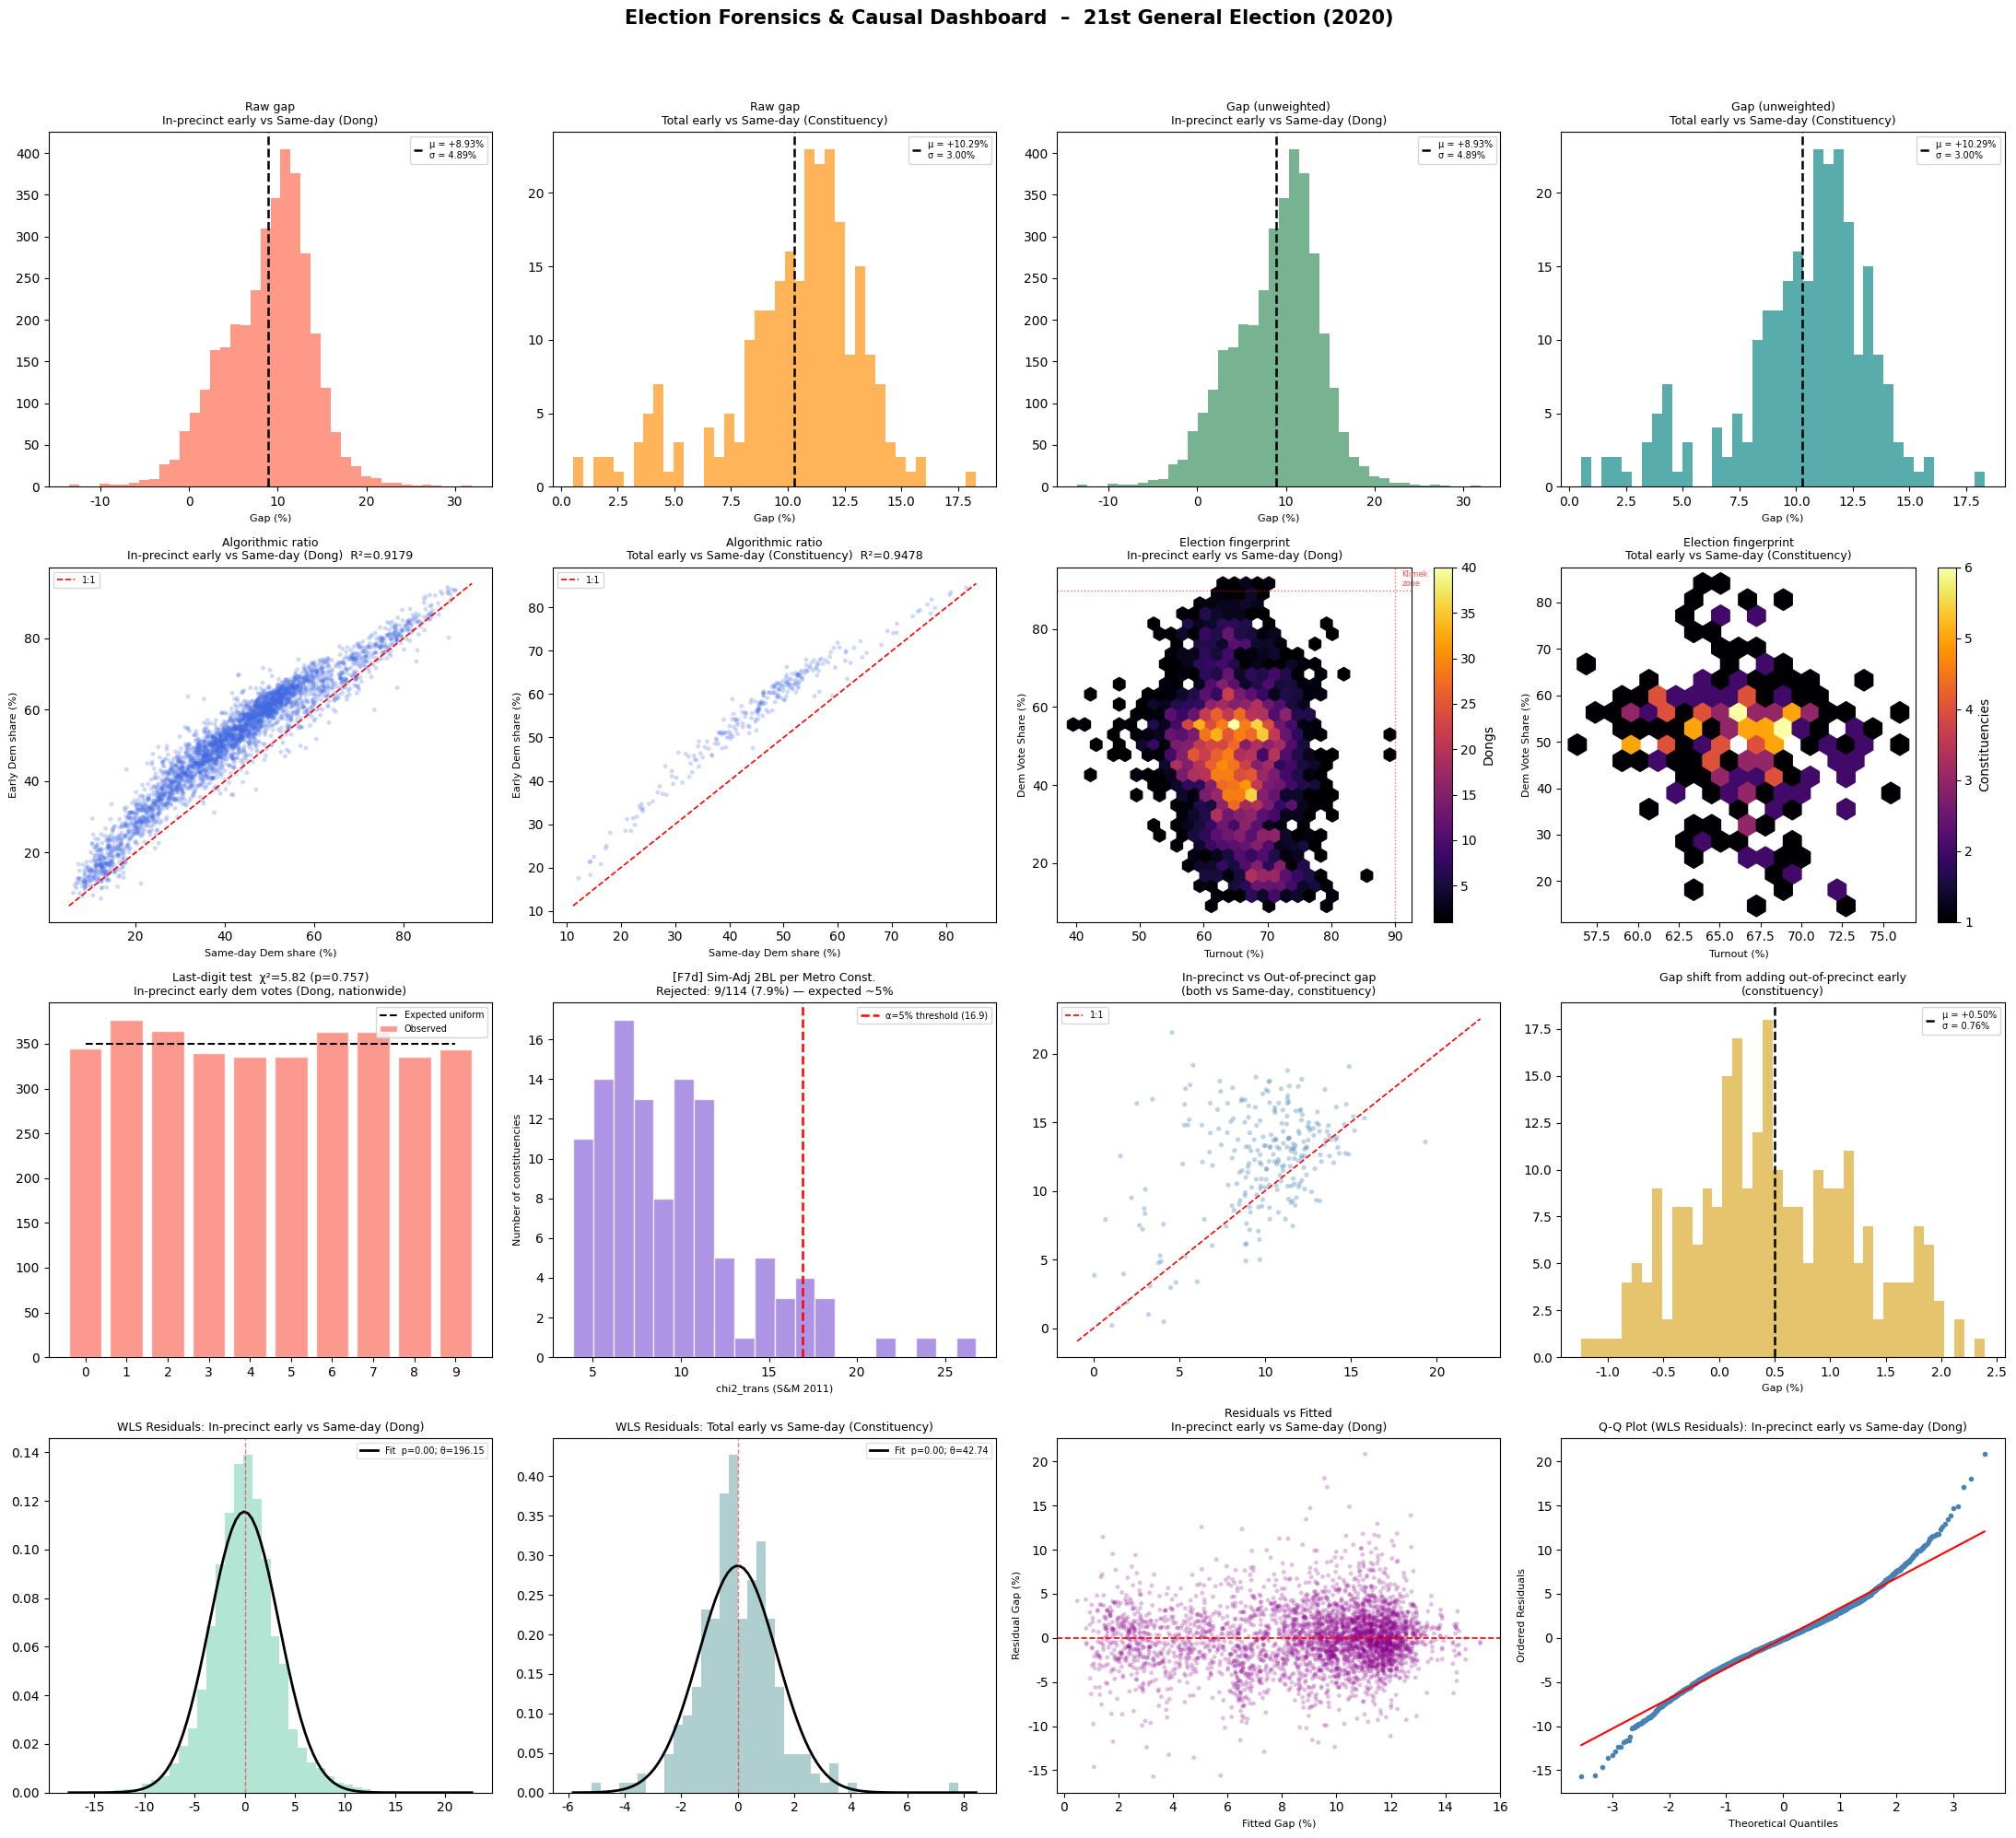

In [23]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import os
import re
import glob
from difflib import get_close_matches
from scipy.stats import (chisquare, pearsonr, norm, probplot, normaltest,
                          gaussian_kde, multivariate_t, ttest_1samp)
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# FONT SETUP
# ==========================================

def setup_font():
    """Configure matplotlib to render text properly."""
    matplotlib.rcParams['axes.unicode_minus'] = False

# ==========================================
# CONFIGURATION
# ==========================================

ELECTION_NUM = 21   # options: 21, 22, 'pres20', 'pres21'
EXCLUDE_HONAM_YEONGNAM = False

PCA_VARIANCE_THRESHOLD     = 0.95
DEMEAN_GROUP_COLS          = ['province_tag']  # Removed urban_type
MIN_COVERAGE               = 0.50

ELECTION_CONFIGS = {
    21: {
        'election_type':  'general',
        'census_csv':     '21st_election_census.csv',
        'result_csv':     '21st_election_result.csv',
        'apt_csv_glob':   '*21st_election_*_apt_price.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'미래통합당|자유한국당',
        'third_pattern':  None,
        'label':          '21st General Election (2020)',
        'year':           2020,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_21st.png',
    },
    22: {
        'election_type':  'general',
        'census_csv':     '22nd_election_census.csv',
        'result_csv':     '22nd_election_result.csv',
        'apt_csv_glob':   '*22nd_election_*_apt_price.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'국민의힘',
        'third_pattern':  None,
        'label':          '22nd General Election (2024)',
        'year':           2024,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_22nd.png',
    },
    'pres20': {
        'election_type':         'presidential',
        'census_csv':            '20th_presidential_election_census.csv',
        'result_csv':            '20th_presidential_election_result.csv',
        'apt_csv_glob':          '*20th_presidential_election_*_apt_prices.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         None,
        'label':                 '20th Presidential Election (2022)',
        'year':                  2022,
        'election_month':        3,
        'dashboard_out':         'mega_forensics_dashboard_pres20.png',
        'fallback_election_num': 21,
    },
    'pres21': {
        'election_type':         'presidential',
        'census_csv':            '21st_presidential_election_census.csv',
        'result_csv':            '21st_presidential_election_result.csv',
        'apt_csv_glob':          '*21st_presidential_election_*_apt_prices.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         r'이준석|개혁신당',
        'label':                 '21st Presidential Election (2025)',
        'year':                  2025,
        'election_month':        6,
        'dashboard_out':         'mega_forensics_dashboard_pres21.png',
        'fallback_election_num': 22,
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES_GENERAL = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES_PRESIDENTIAL = {
    '거소·선상투표', '관외사전투표', '재외투표',
    '잘못 투입·구분된 투표지',
}
GWANNAESA_LABEL = '관내사전투표'
GWANOE_LABEL    = '관외사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': 'Seoul',  '부산광역시': 'Busan',   '대구광역시': 'Daegu',
    '인천광역시': 'Incheon','광주광역시': 'Gwangju', '대전광역시': 'Daejeon',
    '울산광역시': 'Ulsan',  '세종특별자치시': 'Sejong',
    '경기도': 'Gyeonggi',  '강원도': 'Gangwon',     '강원특별자치도': 'Gangwon',
    '충청북도': 'Chungbuk', '충청남도': 'Chungnam',
    '전라북도': 'Jeonbuk',  '전북특별자치도': 'Jeonbuk', '전라남도': 'Jeonnam',
    '경상북도': 'Gyeongbuk','경상남도': 'Gyeongnam', '제주특별자치도': 'Jeju',
    # Abbreviated metro-city names used in employment CSV region column
    '서울': 'Seoul',   '부산': 'Busan',    '대구': 'Daegu',
    '인천': 'Incheon', '광주': 'Gwangju',  '대전': 'Daejeon',
    '울산': 'Ulsan',
}

# Maps standalone provincial city/county names (as they appear in employment CSVs,
# without a province prefix) to their English province tag.
SGG_TO_PROVINCE_EMP = {
    # Gyeonggi
    '가평군':'Gyeonggi','고양시':'Gyeonggi','과천시':'Gyeonggi','광명시':'Gyeonggi',
    '광주시':'Gyeonggi','구리시':'Gyeonggi','군포시':'Gyeonggi','김포시':'Gyeonggi',
    '남양주시':'Gyeonggi','동두천시':'Gyeonggi','부천시':'Gyeonggi','성남시':'Gyeonggi',
    '수원시':'Gyeonggi','시흥시':'Gyeonggi','안산시':'Gyeonggi','안성시':'Gyeonggi',
    '안양시':'Gyeonggi','양주시':'Gyeonggi','양평군':'Gyeonggi','여주군':'Gyeonggi',
    '여주시':'Gyeonggi','연천군':'Gyeonggi','오산시':'Gyeonggi','용인시':'Gyeonggi',
    '의왕시':'Gyeonggi','의정부시':'Gyeonggi','의정부시':'Gyeonggi','이천시':'Gyeonggi',
    '파주시':'Gyeonggi','평택시':'Gyeonggi','포천시':'Gyeonggi','하남시':'Gyeonggi',
    '화성시':'Gyeonggi',
    # Gangwon
    '강릉시':'Gangwon','고성군':'Gangwon','동해시':'Gangwon','삼척시':'Gangwon',
    '속초시':'Gangwon','양구군':'Gangwon','양양군':'Gangwon','영월군':'Gangwon',
    '원주시':'Gangwon','인제군':'Gangwon','정선군':'Gangwon','철원군':'Gangwon',
    '춘천시':'Gangwon','태백시':'Gangwon','평창군':'Gangwon','홍천군':'Gangwon',
    '화천군':'Gangwon','횡성군':'Gangwon',
    # Chungbuk
    '괴산군':'Chungbuk','단양군':'Chungbuk','보은군':'Chungbuk','영동군':'Chungbuk',
    '옥천군':'Chungbuk','음성군':'Chungbuk','제천시':'Chungbuk','증평군':'Chungbuk',
    '진천군':'Chungbuk','청원군':'Chungbuk','청주시':'Chungbuk','충주시':'Chungbuk',
    # Chungnam
    '계룡시':'Chungnam','공주시':'Chungnam','금산군':'Chungnam','논산시':'Chungnam',
    '당진시':'Chungnam','보령시':'Chungnam','부여군':'Chungnam','서산시':'Chungnam',
    '서천군':'Chungnam','아산시':'Chungnam','연기군':'Chungnam','예산군':'Chungnam',
    '청양군':'Chungnam','천안시':'Chungnam','태안군':'Chungnam','홍성군':'Chungnam',
    # Jeonbuk
    '고창군':'Jeonbuk','군산시':'Jeonbuk','김제시':'Jeonbuk','남원시':'Jeonbuk',
    '무주군':'Jeonbuk','부안군':'Jeonbuk','순창군':'Jeonbuk','완주군':'Jeonbuk',
    '익산시':'Jeonbuk','임실군':'Jeonbuk','장수군':'Jeonbuk','전주시':'Jeonbuk',
    '정읍시':'Jeonbuk','진안군':'Jeonbuk',
    # Jeonnam
    '강진군':'Jeonnam','고흥군':'Jeonnam','곡성군':'Jeonnam','구례군':'Jeonnam',
    '나주시':'Jeonnam','담양군':'Jeonnam','목포시':'Jeonnam','무안군':'Jeonnam',
    '보성군':'Jeonnam','순천시':'Jeonnam','신안군':'Jeonnam','여수시':'Jeonnam',
    '영광군':'Jeonnam','영암군':'Jeonnam','완도군':'Jeonnam','장성군':'Jeonnam',
    '장흥군':'Jeonnam','진도군':'Jeonnam','함평군':'Jeonnam','화순군':'Jeonnam',
    '광양시':'Jeonnam','해남군':'Jeonnam',
    # Gyeongbuk
    '경산시':'Gyeongbuk','경주시':'Gyeongbuk','고령군':'Gyeongbuk','구미시':'Gyeongbuk',
    '김천시':'Gyeongbuk','문경시':'Gyeongbuk','봉화군':'Gyeongbuk','상주시':'Gyeongbuk',
    '성주군':'Gyeongbuk','안동시':'Gyeongbuk','영덕군':'Gyeongbuk','영양군':'Gyeongbuk',
    '영주시':'Gyeongbuk','영천시':'Gyeongbuk','예천군':'Gyeongbuk','울릉군':'Gyeongbuk',
    '울진군':'Gyeongbuk','의성군':'Gyeongbuk','청도군':'Gyeongbuk','청송군':'Gyeongbuk',
    '칠곡군':'Gyeongbuk','포항시':'Gyeongbuk',
    # Gyeongnam
    '거제시':'Gyeongnam','거창군':'Gyeongnam','김해시':'Gyeongnam','남해군':'Gyeongnam',
    '밀양시':'Gyeongnam','사천시':'Gyeongnam','산청군':'Gyeongnam','양산시':'Gyeongnam',
    '의령군':'Gyeongnam','진주시':'Gyeongnam','창녕군':'Gyeongnam','창원시':'Gyeongnam',
    '통영시':'Gyeongnam','하동군':'Gyeongnam','함안군':'Gyeongnam','함양군':'Gyeongnam',
    '합천군':'Gyeongnam',
    # Jeju
    '서귀포시':'Jeju','제주시':'Jeju',
}

PARTISAN_REGION_PROVINCES = {
    'Honam':   {'Jeonnam', 'Jeonbuk', 'Gwangju', '전남', '전북', '광주'},
    'Yeongnam':{'Gyeongbuk', 'Gyeongnam', 'Daegu', 'Busan', 'Ulsan',
                '경북', '경남', '대구', '부산', '울산'},
}

AGE_GENDER_COLS = [
    'pct_m_1824', 'pct_m_2529', 'pct_m_3034', 'pct_m_3539', 'pct_m_4044', 'pct_m_4549',
    'pct_m_5054', 'pct_m_5559', 'pct_m_6064', 'pct_m_6569', 'pct_m_70plus',
    'pct_f_1824', 'pct_f_2529', 'pct_f_3034', 'pct_f_3539', 'pct_f_4044', 'pct_f_4549',
    'pct_f_5054', 'pct_f_5559', 'pct_f_6064', 'pct_f_6569', 'pct_f_70plus',
]

EMPLOYMENT_FEATURE_COLS = [
    'emp_men_total', 'emp_men_1529', 'emp_men_3049', 'emp_men_5064', 'emp_men_65plus',
    'emp_wmn_total', 'emp_wmn_1529', 'emp_wmn_3049', 'emp_wmn_5064', 'emp_wmn_65plus',
    'occ_wage_share', 'occ_regular_share', 'occ_nonwage_share',
    'job_professional', 'job_clerical', 'job_service_sales',
    'job_skilled_machine', 'job_simple_labor', 'job_farming',
    'ind_agriculture', 'ind_manufacturing', 'ind_construction',
    'ind_retail_food', 'ind_transport_finance', 'ind_services',
    'nonp_male_share', 'nonp_young_share', 'nonp_middle_share', 'nonp_old_share',
]

# ==========================================
# SHARED NORMALISATION & IO UTILITIES
# ==========================================

def _read_csv_auto(path: str, **kwargs) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8', **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp949', **kwargs)

def _to_numeric_safe(series: pd.Series) -> pd.Series:
    return (series.astype(str).str.strip()
            .replace(['-', '.', '', 'nan'], np.nan)
            .pipe(pd.to_numeric, errors='coerce'))

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구'  and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates

def get_election_periods(month: int, year: int) -> dict:
    if month <= 6:
        prev = year - 1
        return {'half_periods': [f'{prev}.1/2', f'{prev}.2/2'], 'grdp_year': prev}
    else:
        prev = year - 1
        return {'half_periods': [f'{prev}.2/2', f'{year}.1/2'], 'grdp_year': prev}

def parse_employment_sgg(region_name: str) -> tuple:
    if not isinstance(region_name, str): return ('', '')
    parts = region_name.strip().split(None, 1)
    if not parts: return ('', '')
    prov = parts[0]
    if len(parts) == 1:
        prov_eng = SGG_TO_PROVINCE_EMP.get(prov, '')
        primary  = re.sub(r'[시군구]$', '', prov).strip()
        return (prov_eng, primary)
    sgg_raw  = parts[1]
    sgg_norm = normalize_sigungu(sgg_raw)
    primary  = sgg_norm[0] if sgg_norm else re.sub(r'[시군구]$', '', sgg_raw).strip()
    prov_eng = PROV_FULL_TO_SHORT.get(prov, prov)
    return (prov_eng, primary)

# ==========================================
# 1. DEMOGRAPHIC & ASSET DATA LOADERS
# ==========================================

def _detect_year_prefix(df: pd.DataFrame) -> str:
    for col in df.columns:
        m = re.match(r'(\d{4}년\d{2}월)_계_총인구수', col)
        if m: return m.group(1)
    raise ValueError("Cannot detect census year prefix.")

def load_census_csv(csv_path: str) -> pd.DataFrame:
    print(f"\n--- [1/6] Loading Demographic Census Data ---")
    if not csv_path or not os.path.exists(csv_path): return pd.DataFrame()
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
        prefix = _detect_year_prefix(df)
        voting_age_cols = ([f"{prefix}_계_{a}세" for a in range(18, 100)]
                           + [f"{prefix}_계_100세 이상"])
        cols_4059 = [f"{prefix}_계_{a}세" for a in range(40, 60)]

        all_target_cols = list(voting_age_cols)
        for g in ['남', '여']:
            for a in range(18, 100):
                all_target_cols.append(f"{prefix}_{g}_{a}세")
            all_target_cols.append(f"{prefix}_{g}_100세 이상")

        for col in set(all_target_cols):
            if col in df.columns:
                df[col] = (df[col].astype(str).str.replace(',', '', regex=False)
                           .pipe(pd.to_numeric, errors='coerce').fillna(0))

        df = df.copy()
        df['total_voting_pop'] = df[[c for c in voting_age_cols if c in df.columns]].sum(axis=1)
        df = df[df['total_voting_pop'] > 0].copy()

        ranges = [(18,25,'1824'),(25,30,'2529'),(30,35,'3034'),(35,40,'3539'),
                  (40,45,'4044'),(45,50,'4549'),(50,55,'5054'),(55,60,'5559'),
                  (60,65,'6064'),(65,70,'6569')]

        for g, g_str in [('남','m'), ('여','f')]:
            for r_start, r_end, r_str in ranges:
                cols = [f"{prefix}_{g}_{a}세" for a in range(r_start, r_end)]
                df[f'pct_{g_str}_{r_str}'] = (df[[c for c in cols if c in df.columns]].sum(axis=1)
                                               / df['total_voting_pop'])
            cols_70 = ([f"{prefix}_{g}_{a}세" for a in range(70, 100)]
                       + [f"{prefix}_{g}_100세 이상"])
            df[f'pct_{g_str}_70plus'] = (df[[c for c in cols_70 if c in df.columns]].sum(axis=1)
                                          / df['total_voting_pop'])

        df['demographic_propensity'] = (df[[c for c in cols_4059 if c in df.columns]].sum(axis=1)
                                         / df['total_voting_pop'])

        def extract_census_keys(admin_name):
            if not isinstance(admin_name, str): return [], ""
            clean = re.sub(r'\(.*?\)', '', admin_name).strip()
            parts = clean.split()
            dong_norm = normalize_dong_name(parts[-1]) if parts else ""
            sgg_cands = []
            for token in reversed(parts[:-1]):
                for c in normalize_sigungu(token):
                    if c not in sgg_cands: sgg_cands.append(c)
            return sgg_cands, dong_norm

        rows = []
        for _, row in df.iterrows():
            sgg_cands, dong_norm = extract_census_keys(row['행정구역'])
            row_dict = {
                'sgg_candidates': sgg_cands,
                'primary_sgg':    sgg_cands[0] if sgg_cands else "",
                'dong_norm':      dong_norm,
                'dong_raw':       row['행정구역'],
                'demographic_propensity': row['demographic_propensity'],
            }
            for col in AGE_GENDER_COLS:
                row_dict[col] = row.get(col, np.nan)
            rows.append(row_dict)

        census = pd.DataFrame(rows)
        print(f"    Loaded {len(census):,} census rows with 22 Age-Gender cohorts.")
        return census
    except Exception as e:
        print(f"[!] Error processing census CSV: {e}")
        return pd.DataFrame()

def load_apt_csv(glob_pattern: str) -> pd.DataFrame:
    print(f"\n--- [2/6] Loading Apartment Transaction Data ---")
    if not glob_pattern: return pd.DataFrame()
    file_list = glob.glob(glob_pattern)
    if not file_list: return pd.DataFrame()

    df_list = []
    for file in file_list:
        try:
            df_list.append(_read_csv_auto(file, skiprows=15))
        except Exception:
            pass
    if not df_list: return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    try:
        df['거래금액(만원)'] = pd.to_numeric(
            df['거래금액(만원)'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
        df['전용면적(㎡)']   = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')
        df['price_per_sqm']  = df['거래금액(만원)'] / df['전용면적(㎡)']

        def parse_loc(x):
            parts = str(x).split()
            prov  = PROV_FULL_TO_SHORT.get(parts[0], parts[0]) if parts else ""
            sgg   = normalize_sigungu(parts[1])[0] if len(parts) > 2 and normalize_sigungu(parts[1]) else ""
            dong  = normalize_dong_name(parts[-1]) if parts else ""
            return pd.Series([prov, sgg, dong])

        df[['prov','sgg','dong_norm']] = df['시군구'].apply(parse_loc)

        # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
        mask_seoul = df['prov'] == 'Seoul'
        mask_g3 = df['sgg'].isin(['강남', '서초', '송파'])
        df.loc[mask_seoul & mask_g3, 'prov'] = 'Seoul (Gangnam3gu)'
        df.loc[mask_seoul & ~mask_g3, 'prov'] = 'Seoul (Non-Gangnam3gu)'

        apt_agg = (df.groupby(['prov','sgg','dong_norm'])['price_per_sqm']
                   .median().reset_index()
                   .rename(columns={'price_per_sqm': 'median_apt_price_sqm'}))
        print(f"    Calculated stable median prices for {len(apt_agg):,} unique Dongs.")
        return apt_agg
    except Exception as e:
        print(f"[!] Error processing concatenated APT data: {e}")
        return pd.DataFrame()

def _avg_half_periods(df: pd.DataFrame, base_cols: list) -> pd.Series:
    available = [c for c in base_cols if c in df.columns]
    if not available: return pd.Series(np.nan, index=df.index)
    return df[available].apply(pd.to_numeric, errors='coerce').mean(axis=1)

def load_employment_sgg(election_key: str, **kwargs) -> pd.DataFrame:
    print(f"\n--- [3/6] Loading Employment Covariates ---")
    cfg    = ELECTION_CONFIGS[election_key]
    month  = cfg['election_month']
    year   = cfg['year']
    periods_info = get_election_periods(month, year)
    periods      = periods_info['half_periods']

    def read_emp(path):
        if not os.path.exists(path): return pd.DataFrame()
        df = _read_csv_auto(path, low_memory=False)
        return df[[c for c in df.columns if not str(c).startswith('Unnamed')]]

    age_map = {'total':'계','1529':'15 - 29세','3049':'30 - 49세',
               '5064':'50 - 64세','65plus':'65세이상'}

    def extract_gender_emp(csv_path, gender_prefix):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df_rate = df[df['항목'].str.strip() == '고용률 (%)'].copy()
        records = {}
        for suf, kor_age in age_map.items():
            sub = df_rate[df_rate['연령별'].str.strip() == kor_age].copy()
            if sub.empty: continue
            val_col = f'{gender_prefix}_{suf}'
            sub[val_col] = _avg_half_periods(sub, periods)
            prov_sgg = sub['행정구역별'].apply(parse_employment_sgg)
            sub['province_tag'] = prov_sgg.apply(lambda x: x[0])
            sub['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
            records[val_col] = sub.groupby(['province_tag','primary_sgg'])[val_col].mean()
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_men = extract_gender_emp(kwargs.get('men_csv',   'men_employment_data.csv'),   'emp_men')
    df_wmn = extract_gender_emp(kwargs.get('women_csv', 'women_employment_data.csv'), 'emp_wmn')

    occ_type_map = {'occ_wage_share':'임금근로자',
                    'occ_regular_share':'- 상용근로자',
                    'occ_nonwage_share':'비임금근로자'}

    def extract_occ_type(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df_total = df[df['종사상지위별'].str.strip() == '계'].copy()
        df_total['_total'] = _avg_half_periods(df_total, periods)
        prov_sgg = df_total['행정구역별'].apply(parse_employment_sgg)
        df_total['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df_total['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df_total.set_index(['province_tag','primary_sgg'])['_total']
        records = {}
        for col_name, kor_cat in occ_type_map.items():
            sub = df[df['종사상지위별'].str.strip() == kor_cat].copy()
            if sub.empty: continue
            sub['_val'] = _avg_half_periods(sub, periods)
            prov_sgg2 = sub['행정구역별'].apply(parse_employment_sgg)
            sub['province_tag'] = prov_sgg2.apply(lambda x: x[0])
            sub['primary_sgg']  = prov_sgg2.apply(lambda x: x[1])
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_occ_type = extract_occ_type(kwargs.get('occ_type_csv', 'occupation_type_employment_data.csv'))

    job_map = {
        'job_professional':   '관리자, 전문가 및 관련종사자',
        'job_clerical':       '사무 종사자',
        'job_service_sales':  '서비스·판매 종사자',
        'job_skilled_machine':'기능·기계조작·조립 종사자',
        'job_simple_labor':   '단순노무 종사자',
        'job_farming':        '농림어업 숙련종사자',
    }

    def extract_job_shares(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df[df['항목'].str.strip() == '취업자[천명]'].copy()
        df['_val'] = _avg_half_periods(df, periods)
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df[df['직업별'].str.strip() == '계'].set_index(['province_tag','primary_sgg'])['_val']
        records = {}
        for col_name, kor_cat in job_map.items():
            sub = df[df['직업별'].str.strip() == kor_cat].copy()
            if sub.empty: continue
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_job = extract_job_shares(kwargs.get('occ_csv', 'occupation_employment_data.csv'))

    ind_map = {
        'ind_agriculture':        '농업, 임업 및 어업 (A)',
        'ind_manufacturing':      '광·제조업(B,C)',
        'ind_construction':       '건설업 (F) ',
        'ind_retail_food':        '도소매·숙박음식업(G,I)',
        'ind_transport_finance':  '전기·운수·통신·금융(D,H,J,K)',
        'ind_services':           '사업·개인·공공서비스 및 기타(E,L~U)',
    }

    def extract_ind_shares(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df[df['항목'].str.strip() == '취업자[천명]'].copy()
        df['_val'] = _avg_half_periods(df, periods)
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df[df['산업별'].str.strip() == '계'].set_index(['province_tag','primary_sgg'])['_val']
        records = {}
        for col_name, kor_cat in ind_map.items():
            sub = df[df['산업별'].str.strip() == kor_cat.strip()].copy()
            if sub.empty:
                match = get_close_matches(kor_cat.strip(),
                                          df['산업별'].str.strip().unique().tolist(), n=1, cutoff=0.85)
                if match: sub = df[df['산업별'].str.strip() == match[0]].copy()
            if sub.empty: continue
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_ind = extract_ind_shares(kwargs.get('ind_csv', 'industry_employment_data.csv'))

    def extract_nonpart(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df.iloc[1:].copy()
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        sub_suffixes = {'total':'', 'male':'.1', 'young':'.3', 'middle':'.4'}
        period_vals  = {k: [] for k in sub_suffixes}
        for period in periods:
            for k, suf in sub_suffixes.items():
                if period + suf in df.columns:
                    period_vals[k].append(_to_numeric_safe(df[period + suf]))
        def mean_series(lst):
            return pd.concat(lst, axis=1).mean(axis=1) if lst else pd.Series(np.nan, index=df.index)
        total  = mean_series(period_vals['total'])
        result = df[['province_tag','primary_sgg']].copy()
        result['nonp_male_share']   = mean_series(period_vals['male'])   / total.replace(0, np.nan)
        result['nonp_young_share']  = mean_series(period_vals['young'])  / total.replace(0, np.nan)
        result['nonp_middle_share'] = mean_series(period_vals['middle']) / total.replace(0, np.nan)
        return (result.groupby(['province_tag','primary_sgg'])
                [['nonp_male_share','nonp_young_share','nonp_middle_share']]
                .mean().reset_index())

    df_nonp = extract_nonpart(kwargs.get('nonp_csv', 'non_participant_employment_data.csv'))

    merge_key = ['province_tag','primary_sgg']
    frames = [f for f in [df_men, df_wmn, df_occ_type, df_job, df_ind, df_nonp] if not f.empty]
    if not frames: return pd.DataFrame(columns=merge_key + EMPLOYMENT_FEATURE_COLS)

    df_emp = frames[0]
    for frame in frames[1:]:
        df_emp = df_emp.merge(frame, on=merge_key, how='outer')
    for col in EMPLOYMENT_FEATURE_COLS:
        if col not in df_emp.columns: df_emp[col] = np.nan

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    if not df_emp.empty:
        mask_seoul = df_emp['province_tag'] == 'Seoul'
        mask_g3 = df_emp['primary_sgg'].isin(['강남', '서초', '송파'])
        df_emp.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
        df_emp.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    return df_emp

# ==========================================
# 2. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str,
                      third_pattern: str = None, election_type: str = 'general'):
    print(f"\n--- [4/6] Loading Election Result Data ({csv_path}, type={election_type}) ---")
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if election_type == 'presidential':
        df = df.rename(columns={'구시군명': '선거구명', '읍면동명': '법정읍면동명'})
        special_dong_names = SPECIAL_DONG_NAMES_PRESIDENTIAL
    else:
        special_dong_names = SPECIAL_DONG_NAMES_GENERAL

    df['득표수']    = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']   = df['후보자'].str.contains(dem_pattern,   case=False, na=False)
    df['is_con']   = df['후보자'].str.contains(con_pattern,   case=False, na=False)
    df['is_third'] = df['후보자'].str.contains(third_pattern, case=False, na=False) if third_pattern else False
    df['is_meta']  = df['후보자'].isin(META_CANDIDATES)
    df['is_early'] = df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명','선거구명','법정읍면동명']
    const_key = ['시도명','선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(special_dong_names)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot = df_votes[df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    sd_dem = df_votes[df_votes['is_dem']  & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')
    gn_th  = df_votes[df_votes['is_third'] & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_third')
    sd_th  = df_votes[df_votes['is_third'] & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_third')

    sum_people_dong = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_people'))
    sum_vote_geo    = (df_geo[df_geo['후보자'] == '투표수']
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo'))

    df_dong = gn_dem.copy()
    for frame in (gn_tot, gn_con, gn_th, sd_dem, sd_tot, sd_th,
                  sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    gn_ppl_dong = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                   .groupby(dong_key)['득표수'].sum().reset_index(name='_gn_ppl'))
    df_dong = df_dong.merge(gn_ppl_dong, on=dong_key, how='left')
    df_dong['sum_people'] = df_dong['sum_people'] + df_dong['_gn_ppl'].fillna(0)
    df_dong.drop(columns=['_gn_ppl'], inplace=True)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul = df_dong['province_tag'] == 'Seoul'
    mask_g3 = df_dong['primary_sgg'].isin(['강남', '서초', '송파'])
    df_dong.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_dong.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    # ── Constituency-level aggregates ──
    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot_c  = df_votes[df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con_c  = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    gn_turn_c = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_turnout'))

    df_gw   = df[df['법정읍면동명'] == GWANOE_LABEL]
    df_gw_v = df_gw[~df_gw['is_meta']]

    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_total')
    go_th_c   = df_gw_v[df_gw_v['is_third']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_third')
    go_turn_c = (df_gw[df_gw['후보자'] == '투표수']
                 .groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_turnout'))

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout'))

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')
    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_con_c, gn_turn_c,
                  go_dem_c, go_tot_c, go_turn_c, go_th_c,
                  sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['early_total_dem']     = df_const['in_precinct_early_dem']     + df_const['out_precinct_early_dem']
    df_const['early_total_total']   = df_const['in_precinct_early_total']   + df_const['out_precinct_early_total']
    df_const['early_total_turnout'] = df_const['in_precinct_early_turnout'] + df_const['out_precinct_early_turnout']
    df_const['total_turnout']       = df_const['early_total_turnout'] + df_const['same_day_turnout']

    go_ppl_c = (df_gw[df_gw['후보자'] == '선거인수']
                .groupby(const_key)['득표수'].sum().reset_index(name='_go_ppl'))
    df_const = df_const.merge(go_ppl_c, on=const_key, how='left')
    df_const['sum_people'] = df_const['sum_people'] + df_const['_go_ppl'].fillna(0)
    df_const.drop(columns=['_go_ppl'], inplace=True)

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_c = df_const['province_tag'] == 'Seoul'
    mask_g3_c = df_const['primary_sgg'].isin(['강남', '서초', '송파'])
    df_const.loc[mask_seoul_c & mask_g3_c, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_const.loc[mask_seoul_c & ~mask_g3_c, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    sk = ['시도명','선거구명','법정읍면동명','투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c):
        df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early_flag'] = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['province_tag']  = df_station['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_station['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_s = df_station['province_tag'] == 'Seoul'
    mask_g3_s = df_station['선거구명'].apply(lambda x: any(g in str(x) for g in ['강남', '서초', '송파']))
    df_station.loc[mask_seoul_s & mask_g3_s, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_station.loc[mask_seoul_s & ~mask_g3_s, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    df_station['region']        = df_station['province_tag'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']  = df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan)

    return df_dong, df_const, df_station

# ==========================================
# 3. MULTI-PASS DONG↔CENSUS↔APT↔EMP MATCHER
# ==========================================

def merge_dong_with_covariates(df_election: pd.DataFrame, df_census: pd.DataFrame,
                                df_apt: pd.DataFrame, df_emp: pd.DataFrame) -> pd.DataFrame:
    if not df_census.empty:
        census_lookup = {}
        census_by_sgg = {}
        for _, row in df_census.iterrows():
            dnorm = row['dong_norm']
            covs  = {'demographic_propensity': row['demographic_propensity']}
            for c in AGE_GENDER_COLS: covs[c] = row.get(c, np.nan)
            for sgg in row['sgg_candidates']:
                census_lookup[(sgg, dnorm)] = covs
                census_by_sgg.setdefault(sgg, []).append(dnorm)

        results = []
        for _, row in df_election.iterrows():
            covs = None
            dk   = row['dong_norm']
            sgc  = row['sgg_candidates'] if isinstance(row['sgg_candidates'], list) else [row['primary_sgg']]
            if (row['primary_sgg'], dk) in census_lookup:
                covs = census_lookup[(row['primary_sgg'], dk)]
            if covs is None and '·' in dk:
                k1b = (row['primary_sgg'], dk.replace('·', ''))
                if k1b in census_lookup: covs = census_lookup[k1b]
            if covs is None:
                for sgg in sgc[1:]:
                    if (sgg, dk) in census_lookup: covs = census_lookup[(sgg, dk)]; break
            if covs is None:
                for sgg in sgc:
                    pool = census_by_sgg.get(sgg, [])
                    if pool:
                        m = get_close_matches(dk, pool, n=1, cutoff=0.82)
                        if m and (sgg, m[0]) in census_lookup:
                            covs = census_lookup[(sgg, m[0])]; break
            if covs is None:
                covs = {k: np.nan for k in ['demographic_propensity'] + AGE_GENDER_COLS}
            rd = row.to_dict(); rd.update(covs)
            results.append(rd)
        df_out = pd.DataFrame(results)
    else:
        df_out = df_election.copy()

    if not df_apt.empty:
        df_out = df_out.merge(df_apt,
                              left_on=['province_tag','primary_sgg','dong_norm'],
                              right_on=['prov','sgg','dong_norm'], how='left')
        sgg_med  = df_out.groupby('primary_sgg')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(sgg_med)
        prov_med = df_out.groupby('province_tag')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(prov_med)
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(df_out['median_apt_price_sqm'].median())
        df_out['log_apt_price'] = np.log1p(df_out['median_apt_price_sqm'])
    else:
        df_out['log_apt_price'] = 0.0

    if not df_emp.empty:
        df_out = df_out.merge(df_emp[['province_tag','primary_sgg'] + EMPLOYMENT_FEATURE_COLS],
                              on=['province_tag','primary_sgg'], how='left')
        for col in EMPLOYMENT_FEATURE_COLS:
            if col not in df_out.columns: df_out[col] = np.nan
            prov_med = df_out.groupby('province_tag')[col].transform('median')
            df_out[col] = df_out[col].fillna(prov_med)
            df_out[col] = df_out[col].fillna(df_out[col].median())
    else:
        for col in EMPLOYMENT_FEATURE_COLS: df_out[col] = np.nan

    return df_out[df_out['pct_f_4044'].notna()].copy()


def merge_const_with_covariates(df_const: pd.DataFrame,
                                 df_dong_merged: pd.DataFrame) -> pd.DataFrame:
    """
    Population-weighted aggregation of dong-level census + apt covariates up to
    constituency level, for use in constituency-level forensics.
    """
    if df_dong_merged.empty or 'pct_f_4044' not in df_dong_merged.columns:
        return df_const.copy()

    const_key = ['시도명','선거구명']
    dm = df_dong_merged.dropna(subset=['pct_f_4044']).copy()

    agg_funcs = {'_reg': ('sum_people','sum')}
    for col in AGE_GENDER_COLS:
        dm[f'_pw_{col}'] = dm[col] * dm['sum_people']
        agg_funcs[f'_pw_{col}_sum'] = (f'_pw_{col}','sum')

    out_cols = list(AGE_GENDER_COLS)
    if 'log_apt_price' in dm.columns:
        dm['_pw_log_apt_price'] = dm['log_apt_price'] * dm['sum_people']
        agg_funcs['_pw_log_apt_price_sum'] = ('_pw_log_apt_price','sum')

    agg = dm.groupby(const_key).agg(**agg_funcs).reset_index()

    for col in AGE_GENDER_COLS:
        agg[col] = agg[f'_pw_{col}_sum'] / agg['_reg'].replace(0, np.nan)
    if 'log_apt_price' in dm.columns:
        agg['log_apt_price'] = agg['_pw_log_apt_price_sum'] / agg['_reg'].replace(0, np.nan)
        out_cols.append('log_apt_price')

    return df_const.merge(agg[const_key + out_cols], on=const_key, how='left')

# ==========================================
# 4. GLOBAL PCA COLLINEARITY PIPELINE
# ==========================================

def compute_vif(df: pd.DataFrame, cols: list, label: str = "") -> pd.DataFrame:
    available = [c for c in cols if c in df.columns]
    X = df[available].dropna()
    if X.shape[0] < X.shape[1] + 5: return pd.DataFrame()
    records = []
    for i, col in enumerate(available):
        try:    vif = variance_inflation_factor(X.values.astype(float), i)
        except: vif = np.nan
        records.append({'feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(records).sort_values('VIF', ascending=False)

def _drop_zero_variance_cols(df: pd.DataFrame, cols: list) -> list:
    kept = []
    for col in cols:
        if col not in df.columns: continue
        std = df[col].std(skipna=True)
        if not (pd.isna(std) or std < 1e-10): kept.append(col)
    return kept

def reduce_global_pca(df: pd.DataFrame, feature_cols: list, threshold: float) -> tuple:
    """
    Applies standard scaling to all provided valid feature columns (Demographics,
    Employment, Wealth) simultaneously and extracts perfectly orthogonal Global PCs.
    """
    available = [c for c in feature_cols if c in df.columns and df[c].notna().mean() >= MIN_COVERAGE]
    if len(available) < 2:
        return df.copy(), [], None, available

    valid_mask = df[available].notna().all(axis=1)
    if valid_mask.sum() < 30:
        return df.copy(), [], None, available

    X = df.loc[valid_mask, available].values.astype(float)
    X_scaled = StandardScaler().fit_transform(X)

    pca_probe = PCA().fit(X_scaled)
    cumvar = np.cumsum(pca_probe.explained_variance_ratio_)
    n_components = min(int(np.searchsorted(cumvar, threshold)) + 1, len(available))

    pca_final = PCA(n_components=n_components)
    components = pca_final.fit_transform(X_scaled)

    pc_cols = [f'global_pc{i+1}' for i in range(n_components)]
    df_out = df.copy()
    for col in pc_cols:
        df_out[col] = np.nan
    df_out.loc[valid_mask, pc_cols] = components

    return df_out, pc_cols, pca_final, available

def demean_continuous_within_groups(df: pd.DataFrame, cont_cols: list) -> tuple:
    df_out = df.copy()
    dm_cols   = []
    available = [c for c in cont_cols if c in df_out.columns]
    active_groups = [g for g in DEMEAN_GROUP_COLS if g in df_out.columns]
    for col in available:
        gm     = df_out.groupby(active_groups)[col].transform('mean')
        dm_col = f'{col}_dm'
        df_out[dm_col] = df_out[col] - gm
        dm_cols.append(dm_col)
    return df_out, dm_cols

def prepare_continuous_covariates(df: pd.DataFrame, raw_age_cols: list,
                                   raw_emp_cols: list, label: str = "") -> tuple:
    combined_raw = list(raw_age_cols) + list(raw_emp_cols)
    if 'log_apt_price' in df.columns:
        combined_raw.append('log_apt_price')

    df, pc_cols, pca_model, used_features = reduce_global_pca(df, combined_raw, PCA_VARIANCE_THRESHOLD)

    pc_cols = [c for c in pc_cols if df[c].notna().mean() >= MIN_COVERAGE]

    if pc_cols:
        df, dm_cols = demean_continuous_within_groups(df, pc_cols)
    else:
        dm_cols = []

    dm_cols = _drop_zero_variance_cols(df, dm_cols)

    if dm_cols:
        valid_mask = df[dm_cols].notna().all(axis=1)
        if valid_mask.sum() > len(dm_cols) + 5:
            scaler = StandardScaler()
            df.loc[valid_mask, dm_cols] = scaler.fit_transform(df.loc[valid_mask, dm_cols])

    return df, dm_cols, pca_model, used_features

# ==========================================
# 5. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if 'Incheon' in region or 'Gyeyang' in region or 'Yeonsu' in region: return "Incheon"
    if any(c in region for c in ('Suwon','Goyang','Seongnam','Yongin','Gyeonggi')): return "Gyeonggi"
    if 'Seoul (Gangnam3gu)' in region: return "Seoul (Gangnam3gu)"
    if 'Seoul' in region: return "Seoul (Non-Gangnam3gu)"
    return "Other"

def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n

def compute_benford_2bl_statistic(vote_series: pd.Series) -> float:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    if len(valid) == 0: return np.nan
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2, _ = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return chi2

def simulate_2bl_critical_value(df_constituency: pd.DataFrame,
                                 dem_col:   str = 'in_precinct_early_dem',
                                 con_col:   str = 'in_precinct_early_con',
                                 total_col: str = 'in_precinct_early_total',
                                 n_simulations: int = 500,
                                 df_t:      int = 5) -> dict:
    df_sub = df_constituency[df_constituency[total_col] > 0].copy()
    if len(df_sub) < 5:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    eps = 1e-5
    v_dem   = np.maximum(df_sub[dem_col]   / df_sub[total_col], eps)
    v_con   = np.maximum(df_sub[con_col]   / df_sub[total_col], eps)
    v_other = np.maximum(1.0 - v_dem - v_con, eps)
    denom   = v_dem + v_con + v_other
    v_dem, v_con, v_other = v_dem/denom, v_con/denom, v_other/denom
    y_dem = np.log(v_dem / v_other)
    y_con = np.log(v_con / v_other)
    Y = np.column_stack([y_dem, y_con])
    mu = np.mean(Y, axis=0)
    S  = np.cov(Y, rowvar=False)
    shape_matrix = S * (df_t - 2) / df_t if df_t > 2 else S
    shape_matrix = np.atleast_2d(shape_matrix)
    try:
        rv = multivariate_t(loc=mu, shape=shape_matrix, df=df_t)
    except Exception:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    actual_voters = df_sub[total_col].values
    simulated_chi2_stats = []
    for _ in range(n_simulations):
        Y_sim = rv.rvs(size=len(df_sub))
        if len(df_sub) == 1: Y_sim = Y_sim.reshape(1, -1)
        exp_y_dem = np.exp(Y_sim[:, 0])
        exp_y_con = np.exp(Y_sim[:, 1])
        denom_sim = 1.0 + exp_y_dem + exp_y_con
        v_dem_sim = exp_y_dem / denom_sim
        sim_counts = np.round(v_dem_sim * actual_voters)
        sim_chi2 = compute_benford_2bl_statistic(pd.Series(sim_counts))
        if not np.isnan(sim_chi2): simulated_chi2_stats.append(sim_chi2)
    if not simulated_chi2_stats:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    empirical_chi2 = compute_benford_2bl_statistic(df_sub[dem_col])
    chi2_sim95     = np.percentile(simulated_chi2_stats, 95)
    chi2_trans     = (empirical_chi2 * 16.9 / chi2_sim95) if chi2_sim95 > 0 else np.nan
    return {'empirical_chi2': empirical_chi2, 'chi2_sim95': chi2_sim95, 'chi2_trans': chi2_trans}

def _classify_gmm_cluster(t_center: float, v_center: float,
                           province_tag_series: pd.Series) -> str:
    KLIMEK_TURNOUT_THRESHOLD = 0.90
    KLIMEK_SHARE_THRESHOLD   = 0.90
    joint_extreme = (t_center > KLIMEK_TURNOUT_THRESHOLD and
                     (v_center > KLIMEK_SHARE_THRESHOLD or v_center < (1 - KLIMEK_SHARE_THRESHOLD)))
    if joint_extreme:
        return "Klimek Anomaly — extreme turnout + vote share (fraud signal)"
    if province_tag_series is not None and len(province_tag_series) > 0:
        top_prov = province_tag_series.value_counts().index[0]
        for region_name, region_provs in PARTISAN_REGION_PROVINCES.items():
            if top_prov in region_provs:
                return f"Geographic/Partisan — {region_name} region ({top_prov} dominant)"
    return "Geographic/Partisan — swing or mixed region"


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame,
                  df_station:  pd.DataFrame, df_census:    pd.DataFrame,
                  df_apt:      pd.DataFrame, df_emp:       pd.DataFrame) -> dict:
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log(f"\n--- [5/6] Forensics Suite ---")
    MIN_VOTES = 50

    dm = merge_dong_with_covariates(df_dong_raw, df_census, df_apt, df_emp)
    dm = dm[(dm['in_precinct_early_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()
    no_cand = (dm['in_precinct_early_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    # --- PROPORTIONALLY ALLOCATE OUT-OF-PRECINCT VOTES TO DONG LEVEL ---
    const_sums = dm.groupby(['시도명', '선거구명'])[['in_precinct_early_total', 'same_day_total']].transform('sum')
    dm['dong_weight'] = (dm['in_precinct_early_total'] + dm['same_day_total']) / (const_sums['in_precinct_early_total'] + const_sums['same_day_total']).replace(0, np.nan)

    cols_to_merge = ['시도명', '선거구명', 'out_precinct_early_dem', 'out_precinct_early_total']
    if 'out_precinct_early_third' in df_const_raw.columns:
        cols_to_merge.append('out_precinct_early_third')

    df_const_sub = df_const_raw[cols_to_merge].drop_duplicates()
    dm = dm.merge(df_const_sub, on=['시도명', '선거구명'], how='left')

    dm['out_precinct_alloc_dem'] = dm['out_precinct_early_dem'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_tot'] = dm['out_precinct_early_total'].fillna(0) * dm['dong_weight'].fillna(0)

    if 'out_precinct_early_third' in dm.columns:
        dm['out_precinct_alloc_third'] = dm['out_precinct_early_third'].fillna(0) * dm['dong_weight'].fillna(0)

    log("\n  ── Variable Definitions ──")
    log("  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total")
    log("                 The Democratic candidate's vote share among all valid ballots")
    log("                 cast at in-precinct early-voting stations (관내사전투표소).")
    log("  sameday_pct  = same_day_dem ÷ same_day_total")
    log("                 The Democratic share among voters who showed up on election day")
    log("                 (당일투표), the conventional voting mode.")
    log("  gap          = early_pct − sameday_pct")
    log("  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷")
    log("                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)")
    log("                 Combined Democratic share across all voting modes (Dong level).")
    log("                 Out-of-precinct early votes are proportionally allocated to dongs.")
    log("  turnout      = sum_vote_geo ÷ sum_people")
    log("                 Official turnout rate as ballots cast over registered electors.")

    dm['early_pct']   = dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
    dm['sameday_pct'] = dm['same_day_dem'] / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    dm['w_gap']       = dm['gap']

    dm['vote_share'] = ((dm['in_precinct_early_dem'] + dm['same_day_dem'] + dm['out_precinct_alloc_dem']) /
                        (dm['in_precinct_early_total'] + dm['same_day_total'] + dm['out_precinct_alloc_tot'])).fillna(0)
    dm['turnout']    = dm['sum_vote_geo'] / dm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW — nationwide naive test
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test")
    log("  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.")
    log("="*60)
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['in_precinct_early_dem'])
    log(f"  N (votes >= 10)      : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}  (df=9)")
    log("  Result: " + ("PASS" if p_2bl > 0.05 else "FAIL"))
    log("\n  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}  exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test (Three-Series Comparative)")
    log("="*60)

    def _last_digit_test(series: pd.Series, label: str) -> tuple:
        v  = series.astype(int).astype(str)
        v  = v[v.str.len() >= 2]
        ld = v.str[-1].astype(int)
        n  = len(ld)
        obs = ld.value_counts().reindex(range(10), fill_value=0).sort_index()
        exp = [n / 10.0] * 10
        chi2, p = chisquare(obs.values, f_exp=exp)
        cramer_v = np.sqrt(chi2 / (n * 9)) if n > 0 else np.nan
        log(f"  [{label}]  N={n:,}  χ²={chi2:.2f}  p={p:.4f}  "
            f"Cramér's V={cramer_v:.4f}  {'FAIL ★' if p < 0.05 else 'PASS'}")
        return obs, exp, chi2, p

    obs_ld, exp_ld, chi2_ld, p_ld = _last_digit_test(
        dm['in_precinct_early_dem'], 'in_precinct_early_dem  (early, DEM)')
    obs_ld_con = pd.Series(dtype=int)
    chi2_ld_con, p_ld_con = np.nan, np.nan
    if 'in_precinct_early_con' in dm.columns and dm['in_precinct_early_con'].sum() > 0:
        obs_ld_con, _, chi2_ld_con, p_ld_con = _last_digit_test(
            dm['in_precinct_early_con'], 'in_precinct_early_con  (early, CON)')
    _last_digit_test(dm['same_day_dem'], 'same_day_dem   (sameday, DEM)')

    ld_dem_fails  = p_ld < 0.05
    ld_con_passes = np.isnan(p_ld_con) or p_ld_con >= 0.05
    if ld_dem_fails and ld_con_passes:
        log("  [!] ASYMMETRIC FAILURE: in_precinct_early_dem fails while in_precinct_early_con and")
        log("      same_day_dem pass. This cannot be explained by a counting machine artifact")
        log("      (which would affect all candidates equally). It is candidate-specific.")
    elif ld_dem_fails:
        log("  NOTE: Failure appears in multiple series — likely a structural counting artifact.")

    log(f"\n  Binomial simulation null (using actual in_precinct_early_total & p_dem per dong):")
    gn_tot_col = dm['in_precinct_early_total'].astype(int).values
    p_dem_col  = (dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
                  .replace(0, np.nan)).fillna(0).values
    np.random.seed(42)
    sim_counts = np.array([np.random.binomial(int(N), float(p))
                           for N, p in zip(gn_tot_col, p_dem_col)])
    ld_sim = sim_counts % 10
    obs_sim = np.bincount(ld_sim, minlength=10)
    chi2_sim, p_sim = chisquare(obs_sim, f_exp=[len(ld_sim)/10]*10)
    log(f"  Simulated χ²={chi2_sim:.2f} (p={p_sim:.4f}) vs Actual χ²={chi2_ld:.2f} (p={p_ld:.4f})")
    if p_ld < 0.05 and p_sim >= 0.05:
        log("  The actual deviation exceeds what pure binomial sampling predicts.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby(['province_tag','primary_sgg'])['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate','dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations        : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}  (p={p_inv:.4f})")
        log("  Result: " + (
            "Near-zero — no weaponized invalid ballot signal." if abs(corr_inv) < 0.10
            else f"Non-trivial r={corr_inv:.4f}. Warrants further investigation."))
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
    valid_tp = df_station[(df_station['dem_votes'] + df_station['con_votes']) > 0].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes','sum'),
        con_total=('con_votes','sum'),
        station_count=('dem_votes','count'),
    ).reset_index()
    metro_agg['dem_ratio'] = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio'] = 1.0 - metro_agg['dem_ratio']

    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – in-precinct early votes only)")
    log("="*60)

    METRO_PROVINCES = {'Seoul (Non-Gangnam3gu)', 'Seoul (Gangnam3gu)', 'Incheon', 'Gyeonggi'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    obs_2bl_metro  = pd.Series(dtype=int);  exp_2bl_metro  = np.zeros(10)
    chi2_2bl_metro = np.nan;                p_2bl_metro    = np.nan;  n_2bl_metro = 0
    obs_ld_metro   = pd.Series(dtype=int);  exp_ld_metro   = []
    chi2_ld_metro  = np.nan;                p_ld_metro     = np.nan
    metro_early_agg  = pd.DataFrame()
    metro_early_std  = np.nan
    sm_const_results = pd.DataFrame()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
    else:
        # F7a – Naive 2BL
        log(f"\n  [F7a] Naive 2BL – Metro in_precinct_early_dem (N={len(dm_metro):,} precincts)")
        log(f"  NOTE: Naive χ²(9) test only. See [F7d] for simulation-adjusted result.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['in_precinct_early_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_2bl_metro > 0.05 else "FAIL"))

        votes_metro_sm  = dm_metro['in_precinct_early_dem'][dm_metro['in_precinct_early_dem'] >= 10].values.astype(float)
        votes_nation_sm = dm['in_precinct_early_dem'][dm['in_precinct_early_dem'] >= 10].values.astype(float)
        metro_min_sr    = int(votes_metro_sm.min())  if len(votes_metro_sm)  > 0 else 0
        metro_max_sr    = int(votes_metro_sm.max())  if len(votes_metro_sm)  > 0 else 0
        nation_min_sr   = int(votes_nation_sm.min()) if len(votes_nation_sm) > 0 else 0
        nation_max_sr   = int(votes_nation_sm.max()) if len(votes_nation_sm) > 0 else 0
        metro_orders    = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders   = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} ({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range     : {metro_min_sr:,} – {metro_max_sr:,} ({metro_orders:.2f} orders of magnitude)")

        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm)//10)))
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0)
            kde_obj      = gaussian_kde(votes_metro_sm)
            kde_x        = np.linspace(votes_metro_sm.min(),
                                       min(float(votes_metro_sm.max()), 2000.0), 1000)
            kde_max      = float(kde_obj(kde_x).max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"    Approx. mode of metro vote-count distribution : {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)           : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if not np.isnan(mode_approx) and 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if not np.isnan(kde_max) and kde_max > 0.01 else 'NO'}")
        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max) and (kde_max > 0.01)
        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  Simulation-adjusted result [F7d] is the primary forensic indicator.")

        # F7b – Last-digit metro
        log(f"\n  [F7b] Last-Digit – Metro in_precinct_early_dem")
        v_ld_m = dm_metro['in_precinct_early_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL"))

        # F7c – Early-only two-party ratio
        log(f"\n  [F7c] Early-Only Two-Party Ratio (in-precinct early, 63:37 hypothesis)")
        early_st = df_station[
            df_station['is_early_flag'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes']))
        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes','sum'),
            early_con_total=('con_votes','sum'),
            station_count=('dem_votes','count'),
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total']))
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:22s}: {row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")

        # --- Calculate Total Seoul ---
        seoul_rows = metro_early_agg[metro_early_agg['metro_zone'].str.contains('Seoul', na=False)]
        if not seoul_rows.empty:
            s_dem_tot = seoul_rows['early_dem_total'].sum()
            s_con_tot = seoul_rows['early_con_total'].sum()
            s_n_stat  = seoul_rows['station_count'].sum()
            if s_dem_tot + s_con_tot > 0:
                s_dem_ratio = s_dem_tot / (s_dem_tot + s_con_tot)
                s_con_ratio = 1.0 - s_dem_ratio
                log(f"    {'-'*55}")
                log(f"    {'Seoul (Combined Total)':22s}: {s_dem_ratio*100:.2f}% vs {s_con_ratio*100:.2f}%"
                    f"  (n={s_n_stat:,} early stations)")
        # ----------------------------------

        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"\n  Micro std of early two-party dem share across metro stations: {metro_early_std:.2f}%")
        log(f"  HIGH micro std alongside any macro convergence → LLN, not top-down fixing.")
        log(f"  LOW micro std (<2%) with near-63:37 macro → supports fixed-ratio hypothesis.")

        # F7d – Simulation-adjusted 2BL per metro constituency
        log(f"\n  [F7d] Simulation-Adjusted 2BL Per Metro Constituency (S&M 2011)")
        log(f"  Unit: dongs within each constituency  |  Simulations: 500  |  df_t=5")
        if 'in_precinct_early_con' not in df_dong_raw.columns:
            log("  [!] in_precinct_early_con not found in dong data. Skipping simulation-based test.")
        else:
            metro_dong_raw = df_dong_raw[
                df_dong_raw['province_tag'].isin(METRO_PROVINCES) &
                (df_dong_raw['in_precinct_early_total'] > MIN_VOTES)
            ].copy()
            sm_rows = []
            for (sido, const_name), grp in metro_dong_raw.groupby(['province_tag','선거구명']):
                if len(grp) < 5: continue
                res = simulate_2bl_critical_value(grp, n_simulations=500, df_t=5)
                res['Province']     = sido
                res['Constituency'] = const_name
                res['n_dongs']      = len(grp)
                sm_rows.append(res)
            if sm_rows:
                sm_const_results = pd.DataFrame(sm_rows)
                valid_mask = sm_const_results['chi2_trans'].notna()
                n_valid    = valid_mask.sum()
                n_reject   = (sm_const_results.loc[valid_mask,'chi2_trans'] > 16.9).sum()
                pct_reject = n_reject / n_valid * 100 if n_valid > 0 else 0.0
                log(f"  Metro constituencies analysed    : {len(sm_const_results)}")
                log(f"  With valid simulation results    : {n_valid}")
                log(f"  Exceeding sim-adjusted threshold : {n_reject} ({pct_reject:.1f}%)  (expected ~5%)")
                log("  Result: " + (
                    "PASS — rejection rate within chance expectation." if pct_reject <= 7.5
                    else "FAIL — more rejections than chance predicts. Warrants review."))
                log(f"\n  Top 10 constituencies by chi2_trans:")
                log(f"  {'Province':<22} {'Constituency':<20} {'emp_χ²':>8} {'sim95':>7} {'trans_χ²':>9} {'n_dongs':>7}")
                top_sm = (sm_const_results.dropna(subset=['chi2_trans'])
                          .sort_values('chi2_trans', ascending=False).head(10))
                for _, r in top_sm.iterrows():
                    flag = " ★" if r['chi2_trans'] > 16.9 else ""
                    log(f"  {str(r['Province'])[:22]:<22} {str(r['Constituency']):<20} "
                        f"{r['empirical_chi2']:8.2f} {r['chi2_sim95']:7.2f} "
                        f"{r['chi2_trans']:9.2f}{flag}  (n={int(r['n_dongs'])})")
            else:
                log("  [!] No valid simulation results produced.")

    # ------------------------------------------------------------------
    # [F8] BEBER & SCACCO "0s AND 5s" TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F8] Beber & Scacco '0s and 5s' Test (Human Fabrication Signature)")
    log("="*60)
    v_ld_all    = dm['in_precinct_early_dem'].astype(int).astype(str)
    v_ld_all    = v_ld_all[v_ld_all.str.len() >= 2]
    last_digits = v_ld_all.str[-1].astype(int)
    count_05    = last_digits.isin([0, 5]).sum()
    n_ld        = len(last_digits)
    p_hat_05    = count_05 / n_ld if n_ld > 0 else 0.0
    p_0         = 0.20
    if n_ld > 0:
        se_p      = np.sqrt(p_0 * (1 - p_0) / n_ld)
        z_05      = (p_hat_05 - p_0) / se_p
        p_val_05  = 2 * (1 - norm.cdf(abs(z_05)))
        log(f"  Observed 0s/5s frequency : {p_hat_05*100:.2f}%  (Expected: 20.00%)")
        log(f"  Z-Statistic              : {z_05:.4f}")
        log(f"  p-value                  : {p_val_05:.4e}")
        log("  Result: " + (
            "PASS – No significant human preference for 0s and 5s." if p_val_05 > 0.05
            else "FAIL – Unnatural frequency of 0s and 5s detected."))

    # ------------------------------------------------------------------
    # [F9] BEBER & SCACCO MEAN & VARIANCE OF LAST DIGITS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F9] Beber & Scacco Mean & Variance of Last Digits")
    log("="*60)
    if n_ld > 0:
        mean_ld = last_digits.mean()
        var_ld  = last_digits.var()
        se_mean = np.sqrt(8.25 / n_ld)
        z_mean  = (mean_ld - 4.5) / se_mean
        p_val_mean = 2 * (1 - norm.cdf(abs(z_mean)))
        log(f"  Observed Mean     : {mean_ld:.4f}  (Expected: 4.5)")
        log(f"  Observed Variance : {var_ld:.4f}   (Expected: 8.25)")
        log(f"  Mean Z-Statistic  : {z_mean:.4f}  (p={p_val_mean:.4e})")
        log("  Result: " + (
            "PASS – Last digit mean conforms to uniform distribution." if p_val_mean > 0.05
            else "FAIL – Last digit mean deviates from uniform expectation."))

    # ------------------------------------------------------------------
    # [F10] KLIMEK ET AL. MIXTURE MODELING (Election Fingerprint)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F10] Klimek et al. Mixture Modeling (Election Fingerprint)")
    log("  NOTE: Fraud signal = HIGH TURNOUT + HIGH VOTE SHARE simultaneously.")
    log("  A cluster extreme only in vote share at normal turnout is geographic.")
    log("="*60)
    fp_data_raw = dm[['turnout','vote_share','province_tag']].dropna()
    fp_data     = fp_data_raw[['turnout','vote_share']].copy()
    if len(fp_data) > 50:
        best_gmm, best_bic, best_n = None, np.inf, 2
        for n_comp in range(2, 7):
            g   = GaussianMixture(n_components=n_comp, random_state=42, n_init=3)
            g.fit(fp_data)
            bic = g.bic(fp_data)
            if bic < best_bic: best_bic, best_gmm, best_n = bic, g, n_comp
        log(f"  BIC-selected n_components: {best_n}  (BIC={best_bic:.1f})")
        labels  = best_gmm.predict(fp_data)
        weights = best_gmm.weights_
        centers = best_gmm.means_
        sorted_indices = np.argsort(weights)[::-1]
        log(f"  Identified Clusters (Turnout %, Dem Vote Share %):")
        klimek_anomaly_found = False
        for i, idx in enumerate(sorted_indices):
            w        = weights[idx] * 100
            t_center = centers[idx][0]
            v_center = centers[idx][1]
            cluster_provs = fp_data_raw.loc[fp_data.index[labels == idx], 'province_tag']
            c_type   = _classify_gmm_cluster(t_center, v_center, cluster_provs)
            if "Anomaly" in c_type: klimek_anomaly_found = True
            log(f"    Cluster {i+1}: Weight={w:.1f}%  "
                f"Turnout={t_center*100:.1f}%  VoteShare={v_center*100:.1f}%")
            log(f"             → {c_type}")
        if klimek_anomaly_found:
            log("  [!] KLIMEK FLAG: At least one cluster meets the fraud criterion.")
            log("      This warrants cross-examination with F11 (Genuine Correlations) results.")
        else:
            log("  Result: No cluster meets the Klimek joint fraud criterion.")
            log("          Cluster separation is explained by regional partisanship.")
    else:
        log("  [!] Insufficient data for Klimek GMM modeling.")

    # ------------------------------------------------------------------
    # [F11] GENUINE TURNOUT-TO-DEM-SHARE CORRELATION TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F11] Genuine Turnout-to-Dem-Share Correlation Test")
    log("  Tests whether voter turnout genuinely correlates with Democratic party")
    log("  candidate votes, independent of election forensics/fraud framing.")
    log("="*60)
    genuine_correlations = []
    for (sido, const_name), grp in dm.groupby(['시도명','선거구명']):
        grp_clean = grp[['turnout','vote_share']].dropna()
        if len(grp_clean) > 5:
            r_val, p_val = pearsonr(grp_clean['turnout'], grp_clean['vote_share'])
            prov = grp['province_tag'].iat[0] if 'province_tag' in grp.columns else sido
            genuine_correlations.append((prov, const_name, r_val, p_val, len(grp_clean)))
    if genuine_correlations:
        genuine_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
        log(f"  Analysed {len(genuine_correlations)} constituencies.")
        log(f"  Top 15 strongest Turnout–Share correlations (positive or negative):")
        for prov, const_name, r_val, p_val, n_d in genuine_correlations[:15]:
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
            log(f"      - {str(prov)[:15]:<15} {const_name:<20}: r = {r_val:+.4f} {sig:<3} (n={n_d} Dongs)")
    else:
        log("  Result: Insufficient data to calculate genuine correlations.")

    # ------------------------------------------------------------------
    # Constituency-level frame
    # ------------------------------------------------------------------
    cm = merge_const_with_covariates(df_const_raw, dm)
    cm = cm[(cm['early_total_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()
    no_cand_c = (cm['early_total_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']              = cm['early_total_dem']  / cm['early_total_total']
    cm['sameday_pct']            = cm['same_day_dem']     / cm['same_day_total']
    cm['gap']                    = cm['early_pct'] - cm['sameday_pct']
    cm['w_gap']                  = cm['gap']

    cm['in_precinct_early_pct']  = cm['in_precinct_early_dem']  / cm['in_precinct_early_total'].replace(0, np.nan)
    cm['out_precinct_early_pct'] = cm['out_precinct_early_dem'] / cm['out_precinct_early_total'].replace(0, np.nan)
    cm['in_precinct_early_gap']  = cm['in_precinct_early_pct']  - cm['sameday_pct']
    cm['out_precinct_early_gap'] = cm['out_precinct_early_pct'] - cm['sameday_pct']
    cm['gap_shift']              = cm['gap'] - cm['in_precinct_early_gap']

    # Constituency vote_share natively captures in-precinct + out-precinct in `early_total_dem`
    cm['vote_share']             = ((cm['early_total_dem'] + cm['same_day_dem']) /
                                    (cm['early_total_total'] + cm['same_day_total']))
    cm['turnout']                = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F12] ABSENTEE (OUT-OF-PRECINCT EARLY) SHIFT ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F12] Absentee (Out-of-Precinct Early) Shift Analysis")
    log("  Compares: In-precinct early gap vs Out-of-precinct early gap vs Same-day")
    log("  Unit: constituency level")
    log("="*60)
    cm_abs = cm.dropna(subset=['out_precinct_early_pct','in_precinct_early_pct','sameday_pct']).copy()
    cm_abs = cm_abs[cm_abs['out_precinct_early_total'] > MIN_VOTES].copy()

    if len(cm_abs) < 5:
        log("  [!] Insufficient out-of-precinct data for absentee shift analysis.")
    else:
        log(f"\n  N constituencies with sufficient out-of-precinct early data: {len(cm_abs)}")
        ip_gap_mean  = cm_abs['in_precinct_early_gap'].mean()  * 100
        ip_gap_std   = cm_abs['in_precinct_early_gap'].std()   * 100
        oop_gap_mean = cm_abs['out_precinct_early_gap'].mean() * 100
        oop_gap_std  = cm_abs['out_precinct_early_gap'].std()  * 100
        shift_mean   = cm_abs['gap_shift'].mean() * 100
        shift_std    = cm_abs['gap_shift'].std()  * 100

        log(f"\n  Gap = (voting-mode Dem share) − (same-day Dem share)")
        log(f"  {'Metric':<45} {'Mean':>8}  {'Std':>8}")
        log(f"  {'-'*65}")
        log(f"  {'In-precinct early gap  (관내사전 − 당일)':<45} {ip_gap_mean:>+8.2f}%  {ip_gap_std:>7.2f}%")
        log(f"  {'Out-of-precinct early gap (관외사전 − 당일)':<45} {oop_gap_mean:>+8.2f}%  {oop_gap_std:>7.2f}%")
        log(f"  {'Gap shift  (out − in)  : extra absentee premium':<45} {shift_mean:>+8.2f}%  {shift_std:>7.2f}%")

        if len(cm_abs) >= 10:
            r_gaps, p_gaps = pearsonr(cm_abs['in_precinct_early_gap'], cm_abs['out_precinct_early_gap'])
            log(f"\n  Pearson r(in-precinct gap ↔ out-of-precinct gap): {r_gaps:.4f}  (p={p_gaps:.4e})")
            if r_gaps > 0.80:
                log("  High correlation → both modes track the same underlying partisan preference.")
            elif r_gaps < 0.40:
                log("  Low correlation → out-of-precinct gap diverges from in-precinct; investigate.")

        if 'province_tag' in cm_abs.columns:
            prov_abs = cm_abs.groupby('province_tag').agg(
                n_const=('in_precinct_early_gap','count'),
                ip_gap_mean=('in_precinct_early_gap','mean'),
                oop_gap_mean=('out_precinct_early_gap','mean'),
                shift_mean=('gap_shift','mean'),
            ).reset_index().sort_values('shift_mean', ascending=False)
            prov_abs[['ip_gap_mean','oop_gap_mean','shift_mean']] *= 100
            log(f"\n  Province-level absentee shift breakdown (sorted by gap_shift desc):")
            log(f"  {'Province':<22} {'N':>4}  {'IP gap':>8}  {'OOP gap':>8}  {'Shift':>8}")
            log(f"  {'-'*60}")
            for _, r in prov_abs.iterrows():
                log(f"  {str(r['province_tag'])[:22]:<22} {int(r['n_const']):>4}  "
                    f"{r['ip_gap_mean']:>+8.2f}%  {r['oop_gap_mean']:>+8.2f}%  {r['shift_mean']:>+8.2f}%")

        log(f"\n  Top 10 constituencies by |gap_shift| (largest absentee premium):")
        log(f"  {'Province':<20} {'Constituency':<20} {'IP gap':>8}  {'OOP gap':>8}  {'Shift':>8}  {'N_oop':>6}")
        log(f"  {'-'*82}")
        top_shift = cm_abs.reindex(
            cm_abs['gap_shift'].abs().sort_values(ascending=False).index).head(10)
        for _, r in top_shift.iterrows():
            prov  = str(r.get('province_tag',''))[:20]
            const = str(r.get('선거구명', r.get('primary_sgg','')))[:20]
            log(f"  {prov:<20} {const:<20} "
                f"{r['in_precinct_early_gap']*100:>+8.2f}%  "
                f"{r['out_precinct_early_gap']*100:>+8.2f}%  "
                f"{r['gap_shift']*100:>+8.2f}%  "
                f"{int(r.get('out_precinct_early_total',0)):>6,}")

        n_pos_shift = (cm_abs['gap_shift'] > 0.02).sum()
        n_neg_shift = (cm_abs['gap_shift'] < -0.02).sum()
        n_neutral   = len(cm_abs) - n_pos_shift - n_neg_shift
        log(f"\n  Gap shift direction (threshold ±2pp):")
        log(f"    Absentee MORE Dem than in-precinct early (shift > +2pp) : {n_pos_shift} ({n_pos_shift/len(cm_abs)*100:.1f}%)")
        log(f"    Absentee LESS Dem than in-precinct early (shift < −2pp) : {n_neg_shift} ({n_neg_shift/len(cm_abs)*100:.1f}%)")
        log(f"    Broadly consistent (|shift| ≤ 2pp)                      : {n_neutral} ({n_neutral/len(cm_abs)*100:.1f}%)")

        t_stat, t_p = ttest_1samp(cm_abs['gap_shift'].dropna(), popmean=0)
        log(f"\n  One-sample t-test: mean gap_shift = 0?")
        log(f"    t = {t_stat:.4f},  p = {t_p:.4e}")
        if t_p < 0.05:
            direction = "Dem" if shift_mean > 0 else "Con"
            log(f"  SIGNIFICANT: Out-of-precinct early votes lean systematically {direction} relative")
            log(f"  to in-precinct early votes, beyond chance. Mean shift = {shift_mean:+.2f}pp.")
        else:
            log(f"  No significant systematic difference between absentee modes (p ≥ 0.05).")

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong': {
            'df': dm,
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld':  obs_ld,  'exp_ld':  exp_ld,  'chi2_ld':  chi2_ld,  'p_ld':  p_ld,
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            'metro_agg': metro_agg, 'metro_std': metro_std,
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'sm_const_results': sm_const_results,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs,
    }

# ==========================================
# 6. CAUSAL INFERENCE & REGRESSION (PCA)
# ==========================================

def get_macro_region(prov):
    if pd.isna(prov): return 'Other'
    if prov in ['Seoul (Gangnam3gu)', 'Seoul (Non-Gangnam3gu)', 'Gyeonggi', 'Incheon']: return 'Capital_Metro'
    if prov in ['Busan', 'Ulsan', 'Gyeongnam', 'Daegu', 'Gyeongbuk']: return 'Yeongnam'
    if prov in ['Gwangju', 'Jeonnam', 'Jeonbuk']: return 'Honam'
    if prov in ['Daejeon', 'Sejong', 'Chungnam', 'Chungbuk']: return 'Chungcheong'
    return 'Other'


def run_causal_analysis(dm: pd.DataFrame, cm: pd.DataFrame,
                        anomaly_log_path: str = None):
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log("\n" + "="*60)
    log("  LEVEL C │ Causal Inference & Regression")
    log("  Using Single Global PCA (Age + Emp + Wealth) + Within-group Demeaning")
    log("="*60)

    raw_age_cols = [c for c in AGE_GENDER_COLS
                    if c in dm.columns and dm[c].notna().mean() >= MIN_COVERAGE]
    raw_emp_cols = [c for c in EMPLOYMENT_FEATURE_COLS
                    if c in dm.columns and dm[c].notna().mean() >= MIN_COVERAGE]

    log(f"\n  ── Variable Coverage Diagnostic ──")
    log(f"  Valid Age-Gender Features             : {len(raw_age_cols)}")
    log(f"  Valid Employment Features             : {len(raw_emp_cols)}")
    if len(raw_emp_cols) == 0:
        log("  [!] Warning: Employment columns are below threshold. Global PCA will only use Age/Wealth.")

    df_mod, dm_cols, pca_global, used_features = prepare_continuous_covariates(
        dm, raw_age_cols, raw_emp_cols, label="Causal Regression")

    log(f"\n  ── Global PCA Summary ──")
    log(f"  Features entering PCA : {len(used_features)}")
    log(f"  Global PC components retained : {len(dm_cols)}")


    # ── Detailed Global PCA Interpretation ──
    pc_interpretations = {}
    if pca_global and len(dm_cols) > 0:
        log("\n  ── Detailed Global PCA Component Breakdown ──")
        log("  (These perfectly orthogonal components are included in the regressions as global_pcX_dm)")

        for i in range(len(dm_cols)):
            exp_var = pca_global.explained_variance_ratio_[i] * 100
            log(f"\n    [ global_pc{i+1}_dm ] (Explains {exp_var:.1f}% of total variance)")
            loadings = pd.Series(pca_global.components_[i], index=used_features).sort_values(ascending=False)

            top_pos = loadings[loadings > 0].head(4)
            top_neg = loadings[loadings < 0].tail(4).sort_values()

            pos_str = ", ".join([f"{k} (+{v:.2f})" for k, v in top_pos.items()]) if not top_pos.empty else "None"
            neg_str = ", ".join([f"{k} ({v:.2f})" for k, v in top_neg.items()]) if not top_neg.empty else "None"

            pos_short = ", ".join(top_pos.index) if not top_pos.empty else "None"
            neg_short = ", ".join(top_neg.index) if not top_neg.empty else "None"
            pc_interpretations[f"global_pc{i+1}_dm"] = f"Pos: [{pos_short}] | Neg: [{neg_short}]"

            log(f"      • MORE of: {pos_str}")
            log(f"      • LESS of: {neg_str}")


    req_cols = (['gap','early_pct','sameday_pct','vote_share',
                 'province_tag','area2_name', 'sum_people'] + dm_cols)
    df_mod = df_mod.dropna(subset=req_cols).copy()

    df_mod['macro_region'] = df_mod['province_tag'].apply(get_macro_region)

    rhs_terms = dm_cols.copy()
    base_rhs = ' + '.join(rhs_terms) if rhs_terms else '1'
    base_gap_formula = f'gap ~ {base_rhs}'

    # ── Option 1: VIF Diagnostic Check ──
    log("\n  ── Variance Inflation Factor (VIF) Diagnostic ──")
    log("  Checking multicollinearity among the demeaned Global PCs.")
    log("  (Because we used a single global PCA, these should be near 1.0, proving orthogonality)")
    vif_df = compute_vif(df_mod, dm_cols)
    if not vif_df.empty:
        for _, r in vif_df.iterrows():
            flag = " [!] HIGH (Collinearity risk)" if r['VIF'] > 5 else " (Safe)"
            log(f"    {r['feature']:<20}: {r['VIF']:>5.2f}{flag}")
    else:
        log("    [!] Could not compute VIF (insufficient data or columns).")

    log("\n  ── Automating Spatial Fixed Effects Selection (BIC) ──")
    spatial_options = {
        'None (Demographics/Wealth only)': '',
        'Macro-Regions (Metro, Honam, Yeongnam, etc.)': " + C(macro_region, Treatment('Other'))",
        'Provinces (Current Baseline)': " + C(province_tag, Treatment('Chungbuk'))"
    }

    best_bic = np.inf
    spatial_fe = ''
    best_name = ''

    for name, fe in spatial_options.items():
        test_formula = base_gap_formula + fe
        try:
            temp_model = smf.wls(test_formula, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')
            bic = temp_model.bic
            log(f"    Testing {name:<45} | BIC: {bic:,.1f}")
            if bic < best_bic:
                best_bic = bic
                spatial_fe = fe
                best_name = name
        except Exception as e:
            log(f"    [!] Failed testing {name}: {e}")

    log(f"  → Automatically Selected: {best_name} (Lowest BIC)")

    # ── [C1] Gap model ──
    formula_gap = base_gap_formula + spatial_fe
    model_gap = smf.wls(formula_gap, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})

    log("\n[C1] Mobilization Test — WLS Gap Regression")
    log("  Dependent variable : gap  (in-precinct early Dem share − same-day Dem share)")
    log("  early_pct is the Democratic share among voters who used in-precinct early voting")
    log("  (관내사전투표). sameday_pct is the Democratic share on election day (당일투표).")
    log("  gap = early_pct − sameday_pct: positive values indicate the Democratic candidate")
    log("  outperformed in early voting relative to same-day within the same precinct.")
    log("  Weights            : sum_people (dong population)")
    log("  SE correction      : HC3 (heteroskedasticity-robust)")
    log("\n" + model_gap.summary().as_text())

    # ── [C2] Algorithmic ratio model ──
    formula_ratio = f'early_pct ~ sameday_pct + {base_rhs}{spatial_fe}'
    model_ratio = smf.wls(formula_ratio, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})

    log("\n[C2] Algorithmic Ratio Test — WLS Early-on-Sameday Regression")
    log("\n" + model_ratio.summary().as_text())

    # ── [C2.5] Three-candidate full OLS (pres21 only) ──
    extra_models = {}
    model_gap_3 = model_ratio_3 = model_vs_3 = None
    df_mod_3 = pd.DataFrame()

    if ELECTION_NUM == 'pres21' and CFG.get('third_pattern'):
        log("\n" + "="*60)
        log("  [C2.5] 21st Presidential Election: Three-Candidate Race — Full OLS")
        log("  Adding third-party vote share (이준석/개혁신당) as additional covariate")
        log("  to all three main models: Gap, Ratio, and Vote Share.")
        log("="*60)

        third_nom = (df_mod.get('in_precinct_early_third', 0) +
                     df_mod.get('same_day_third', 0) +
                     df_mod.get('out_precinct_alloc_third', 0))
        third_den = (df_mod['in_precinct_early_total'] +
                     df_mod['same_day_total'] +
                     df_mod.get('out_precinct_alloc_tot', 0))

        df_mod['third_share'] = (third_nom / third_den.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)
        df_mod_3 = df_mod.dropna(subset=['third_share']).copy()

        if not df_mod_3.empty and df_mod_3['third_share'].sum() > 0:
            log(f"\n  N dongs with valid third_share: {len(df_mod_3):,}")
            log(f"  third_share mean: {df_mod_3['third_share'].mean()*100:.2f}%  "
                f"std: {df_mod_3['third_share'].std()*100:.2f}%  "
                f"max: {df_mod_3['third_share'].max()*100:.2f}%")

            log("\n  [C2.5a] Isolating Third-Party Demographic Confounding")
            log("  Third-party voting is often highly correlated with age, gender, and regional")
            log("  demographics. Adding it directly to the OLS models would cause severe")
            log("  multicollinearity and distort the baseline coefficients.")
            log("  To solve this, we regress third_share on all baseline covariates and extract")
            log("  the residual ('third_share_resid'). This represents the *unexplained* local")
            log("  surge in third-party voting, mathematically isolated from the demographics.")

            formula_third = f'third_share ~ {base_rhs}{spatial_fe}'
            model_third   = smf.wls(formula_third, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            df_mod_3['third_share_resid'] = model_third.resid

            log(f"\n  Third-Party Demographic Model (R² = {model_third.rsquared:.4f})")
            log("  Top 5 baseline predictors for third-party share:")
            tstats = model_third.tvalues.drop('Intercept', errors='ignore').abs().sort_values(ascending=False)
            for col in tstats.head(5).index:
                coef = model_third.params[col]
                pval = model_third.pvalues[col]
                sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
                log(f"    {col:<25} coef: {coef:>+8.4f}  (t={model_third.tvalues[col]:>6.2f}) {sig}")

            formula_gap_3   = formula_gap   + ' + third_share_resid'
            formula_ratio_3 = formula_ratio + ' + third_share_resid'
            formula_vs_3    = f'vote_share ~ {base_rhs}{spatial_fe} + third_share_resid'

            model_gap_3   = smf.wls(formula_gap_3,   data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            model_ratio_3 = smf.wls(formula_ratio_3, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            model_vs_3    = smf.wls(formula_vs_3,    data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})

            log(f"\n  R² Comparison (Baseline vs Orthogonalized Three-Candidate):")
            log(f"  {'Model':<30} {'Baseline R²':>12}  {'3-Cand R²':>12}  {'ΔR²':>8}")
            log(f"  {'-'*66}")
            for label_m, m_base, m_3 in [
                    ('Gap (early − sameday)',    model_gap,   model_gap_3),
                    ('Ratio (early on sameday)', model_ratio, model_ratio_3),
                    ('Total Dem vote share',     None,        model_vs_3),
            ]:
                if m_base is not None:
                    delta = m_3.rsquared - m_base.rsquared
                    log(f"  {label_m:<30} {m_base.rsquared:>12.4f}  {m_3.rsquared:>12.4f}  {delta:>+8.4f}")
                else:
                    log(f"  {label_m:<30} {'(see C8)':>12}  {m_3.rsquared:>12.4f}")

            log(f"\n  Third-Party Residual Coefficient Summary across Models:")
            log(f"  {'Model':<30} {'Coef':>8}  {'p-value':>9}  {'Significant?':>13}")
            log(f"  {'-'*66}")
            for label_m, m in [('Gap model', model_gap_3),
                                ('Ratio model', model_ratio_3),
                                ('Vote share model', model_vs_3)]:
                c  = m.params.get('third_share_resid', np.nan)
                p  = m.pvalues.get('third_share_resid', np.nan)
                sig = '*** p<0.001' if p < 0.001 else '** p<0.01' if p < 0.01 else '* p<0.05' if p < 0.05 else 'n.s.'
                log(f"  {label_m:<30} {c:>+8.4f}  {p:>9.4f}  {sig:>13}")

            log(f"\n  Coefficient Stability: Baseline Gap vs Three-Candidate Gap")
            log(f"  (Note: Thanks to orthogonalization, baseline covariates remain perfectly stable)")
            log(f"  {'Covariate':<22} {'Baseline':>10}  {'3-Cand':>10}  {'Δ%':>8}")
            log(f"  {'-'*56}")
            for col in dm_cols:
                b_coef = model_gap.params.get(col, np.nan)
                t_coef = model_gap_3.params.get(col, np.nan)
                pct_ch = ((t_coef - b_coef) / abs(b_coef) * 100
                          if (b_coef and not np.isnan(b_coef) and b_coef != 0) else np.nan)
                pct_str = f'{pct_ch:>+8.2f}%' if not np.isnan(pct_ch) else '      n/a'
                log(f"  {col:<22} {b_coef:>+10.4f}  {t_coef:>+10.4f}  {pct_str}")

            # --- NEW COUNTERFACTUAL LOGIC ---
            log("\n  [C2.5d] Counterfactual Analysis: What if the Third Party didn't run?")

            # 1. Estimate Turnout Effect (Abstention Rate)
            formula_turnout_3 = f'turnout ~ {base_rhs}{spatial_fe} + third_share_resid'
            model_turnout_3 = smf.wls(formula_turnout_3, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})

            mean_turnout = df_mod_3['turnout'].mean()
            beta_turnout = model_turnout_3.params.get('third_share_resid', 0)

            # Abstention rate (rho): fraction of third-party voters who would abstain without the candidate
            rho_raw = beta_turnout / mean_turnout if mean_turnout > 0 else 0.0
            rho_clipped = np.clip(rho_raw, 0, 1)

            # 2. Estimate Partisan Substitution
            beta_T = model_vs_3.params.get('third_share_resid', 0)
            gamma_raw = -beta_T

            # Ensure Dem and Abstention fractions don't exceed 100% combined
            gamma_clipped = np.clip(gamma_raw, 0, 1.0 - rho_clipped)
            con_fraction = 1.0 - gamma_clipped - rho_clipped

            # 3. Calculate Counterfactual Shares
            # The new valid vote pool shrinks because some third-party voters abstain
            df_mod_3['cf_denom'] = (1.0 - rho_clipped * df_mod_3['third_share']).clip(lower=1e-5)

            df_mod_3['cf_dem_share'] = ((df_mod_3['vote_share'] + gamma_clipped * df_mod_3['third_share']) / df_mod_3['cf_denom']).clip(0, 1)
            df_mod_3['cf_con_share'] = (((1.0 - df_mod_3['vote_share'] - df_mod_3['third_share']) + con_fraction * df_mod_3['third_share']) / df_mod_3['cf_denom']).clip(0, 1)

            log("  We estimate the counterfactual by reallocating the third-party vote share based on the")
            log("  empirical substitution rates derived from orthogonalized OLS coefficients.")
            log(f"  From the Turnout model, the coefficient on the third-party residual is {beta_turnout:+.4f}.")
            log(f"  This implies ~{rho_clipped*100:.1f}% of third-party voters were 'new' and would abstain without the candidate.")
            log(f"  From the Vote Share model, the coefficient on the third-party residual is {beta_T:+.4f}.")
            log(f"  This implies the remaining third-party voters were drawn approx {gamma_clipped*100:.1f}% from the Democratic")
            log(f"  candidate and {con_fraction*100:.1f}% from the Conservative candidate.")

            orig_dem_nat = (df_mod_3['vote_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            orig_con_nat = ((1 - df_mod_3['vote_share'] - df_mod_3['third_share']) * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            cf_dem_nat = (df_mod_3['cf_dem_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            cf_con_nat = (df_mod_3['cf_con_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()

            log(f"")
            log(f"  National Original Dem Share : {orig_dem_nat*100:.2f}%  |  Con Share: {orig_con_nat*100:.2f}%")
            log(f"  National CF Dem Share       : {cf_dem_nat*100:.2f}%  |  Con Share: {cf_con_nat*100:.2f}%")

            log(f"\n  ── Region-wise Counterfactual Regression (cf_dem_share) ──")
            log("  Below is the full regression output for each macro region modeling the")
            log("  counterfactual Democratic vote share (as if the third-party candidate did not run)")
            log("  against the baseline continuous covariates and local province fixed effects.")

            for m_region in sorted(df_mod_3['macro_region'].dropna().unique()):
                df_reg = df_mod_3[df_mod_3['macro_region'] == m_region].copy()
                if len(df_reg) > 15:
                    try:
                        provs_in_region = df_reg['province_tag'].nunique()
                        local_fe = " + C(province_tag)" if provs_in_region > 1 else ""
                        cf_formula = f'cf_dem_share ~ {base_rhs}{local_fe}'

                        m_cf = smf.wls(cf_formula, data=df_reg, weights=df_reg['sum_people']).fit(cov_type='HC3')

                        log(f"\n{'='*65}")
                        log(f"  Macro Region: {m_region.upper()}")
                        log(f"  N = {len(df_reg)} dongs | Formula: {cf_formula}")
                        log(f"{'='*65}")
                        log("\n" + m_cf.summary().as_text())
                    except Exception as e:
                        log(f"\n  [!] Failed to run counterfactual regression for {m_region}: {e}")

            extra_models = {
                'model_gap_3':   model_gap_3,
                'model_ratio_3': model_ratio_3,
                'model_vs_3':    model_vs_3,
                'model_turnout_3': model_turnout_3,
                'df_mod_3':      df_mod_3,
                'gamma':         gamma_clipped,
                'rho':           rho_clipped,
                'nat_orig_dem':  orig_dem_nat,
                'nat_orig_con':  orig_con_nat,
                'nat_cf_dem':    cf_dem_nat,
                'nat_cf_con':    cf_con_nat
            }
        else:
            log("  [!] Third candidate data missing or zero. Cannot run three-candidate OLS.")

    df_mod['residual_gap'] = model_gap.resid
    df_mod['fitted_gap']   = model_gap.fittedvalues

    # ── [C2b] Constituency-level WLS gap model ──
    cm_mod    = cm.copy()
    agg_cols  = dm_cols
    if agg_cols and not cm_mod.empty:
        for col in agg_cols:
            df_mod[f'_pw_{col}'] = df_mod[col] * df_mod['sum_people']
        agg_funcs = {'sum_people': 'sum'}
        for col in agg_cols:
            agg_funcs[f'_pw_{col}'] = 'sum'
        agg_df = (df_mod.groupby(['시도명','선거구명'])
                  .agg(agg_funcs)
                  .rename(columns={'sum_people':'_reg'})
                  .reset_index())
        for col in agg_cols:
            agg_df[col] = agg_df[f'_pw_{col}'] / agg_df['_reg'].replace(0, np.nan)
        cm_mod = cm_mod.merge(agg_df[['시도명','선거구명'] + agg_cols],
                               on=['시도명','선거구명'], how='inner')
        cm_mod = cm_mod.dropna(subset=['gap','province_tag','sum_people'] + agg_cols).copy()

        # Add macro_region to cm_mod for spatial_fe
        cm_mod['macro_region'] = cm_mod['province_tag'].apply(get_macro_region)

        if not cm_mod.empty:
            formula_gap_c = f'gap ~ {base_rhs}{spatial_fe}'
            model_gap_c   = smf.wls(formula_gap_c, data=cm_mod,
                                     weights=cm_mod['sum_people']).fit(cov_type='HC3')
            cm_mod['residual_gap'] = model_gap_c.resid
            log("\n[C2b] Constituency-Level WLS Gap Regression")
            log("  Dependent variable : gap  (total early Dem share − same-day Dem share)")
            log("  Weights            : sum_people (constituency population)")
            log("  SE correction      : HC3")
            log("\n" + model_gap_c.summary().as_text())
        else:
            log("\n[!] Insufficient data for Constituency-Level WLS Regression")

    # ── [C3] Propensity score matching ──
    median_turnout = df_mod['in_precinct_early_total'].median()
    df_mod['D_high_early'] = (df_mod['in_precinct_early_total'] > median_turnout).astype(int)

    prov_dummies  = pd.get_dummies(df_mod['province_tag'], drop_first=True)
    X_cols = df_mod[dm_cols]
    X = pd.concat([X_cols, prov_dummies], axis=1)
    y = df_mod['D_high_early']

    lr = LogisticRegression(solver='liblinear', max_iter=1000)
    lr.fit(X, y)
    df_mod['propensity_score'] = lr.predict_proba(X)[:, 1]

    treated = df_mod[df_mod['D_high_early'] == 1]
    control = df_mod[df_mod['D_high_early'] == 0]
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[['propensity_score']])
    _, indices = nn.kneighbors(treated[['propensity_score']])
    matched_control = control.iloc[indices.flatten()]

    treated_mean      = treated['vote_share'].mean()
    matched_ctrl_mean = matched_control['vote_share'].mean()
    att = treated_mean - matched_ctrl_mean

    log("\n[C3] Propensity Score Matching — Average Treatment Effect on the Treated (ATT)")
    log("  ── Setup ──")
    log(f"  Treatment (D=1): Dongs where in-precinct early total > {median_turnout:,.0f} votes (median)")
    log(f"  Control  (D=0): Dongs at or below the median early-vote volume.")
    log(f"  Matching vars : Global PCs (Demographics + Wealth), province FE.")
    log(f"  Outcome       : Total Democratic vote share (in-precinct early + same-day combined).")
    log(f"\n  ── Results ──")
    log(f"  Treated Dem vote share (high-early dongs) : {treated_mean*100:.2f}%")
    log(f"  Matched control share (propensity-matched) : {matched_ctrl_mean*100:.2f}%")
    log(f"  Estimated ATT                              : {att*100:+.2f}%")
    log(f"\n  ── Interpretation in relation to regression [C1] and [C8] ──")
    log(f"  WLS regression [C1] estimates the conditional ATE of covariates on the")
    log(f"  early-vs-same-day gap, assuming a linear functional form. It answers:")
    log(f"  'Holding all other covariates constant, how does each unit shift in, e.g.,")
    log(f"  Global PC1 change the gap?'  Regression coefficients are marginal effects,")
    log(f"  estimated across the full covariate distribution.")
    log(f"")
    log(f"  PSM-ATT asks a fundamentally different counterfactual: 'For precincts that")
    log(f"  actually experienced ABOVE-MEDIAN early-voting volume (the treated group),")
    log(f"  what would their Democratic vote share have been if they had instead had")
    log(f"  BELOW-MEDIAN volume, conditional on having the same propensity to be high-")
    log(f"  volume (i.e. same observable characteristics)?'")
    log(f"")
    log(f"  PSM [C3] controls non-parametrically through nearest-neighbour matching on")
    log(f"  the propensity score, making no linearity assumption. It also focuses")
    log(f"  specifically on the treated sample (ATT), rather than averaging over all")
    log(f"  dongs (ATE as in regression).")
    log(f"")
    log(f"  Convergence check:")
    reg_gap_mean = model_gap.fittedvalues.mean() * 100
    log(f"    Regression-implied mean fitted gap (from [C1]) : {reg_gap_mean:+.2f}%")
    log(f"    PSM ATT on total vote share                    : {att*100:+.2f}%")
    log(f"  These measure different estimands (gap vs total share; ATE vs ATT), so")
    log(f"  direct numerical comparison is not meaningful. However, if both imply")
    log(f"  a large, consistent, demographically-unexplained Democratic premium in")
    log(f"  high-early-volume precincts, that would warrant further scrutiny.")
    log(f"  If the ATT is small relative to the raw gap, observable covariates")
    log(f"  (demographics, wealth, urbanisation) largely account for the pattern.")

    # ── [C4] Fraud vs Mobilization diagnostic ──
    raw_mean  = df_mod['gap'].mean()
    r_squared = model_gap.rsquared
    log("\n[C4] Fraud vs. Mobilization Diagnostic (WLS Variance Analysis)")
    log(f"  Raw Mean Gap                       : {raw_mean*100:+.2f}%")
    log(f"  Covariate Explained Variance R²    : {r_squared*100:.2f}%")
    log(f"  Unexplained Variance               : {(1-r_squared)*100:.2f}%")

    # ── [C6] Anomaly profiling ──
    log("\n[C6] Anomaly Profiling: Top 8 Dongs by Absolute Unexplained Residual (Pop > 2,000)")
    log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Fitted':>9} {'Residual':>9}")
    valid_dongs  = df_mod[df_mod['sum_people'] >= 2000]
    top_outliers = valid_dongs.reindex(
        valid_dongs['residual_gap'].abs().sort_values(ascending=False).index).head(8)
    for _, row in top_outliers.iterrows():
        region = f"{row['province_tag']} {row['area2_name']}"[:15]
        dong   = str(row['name'])[:13]
        log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
            f"{row['fitted_gap']*100:+9.2f}% {row['residual_gap']*100:+9.2f}%")

    c6_anomalies = valid_dongs[valid_dongs['residual_gap'].abs() > 0.05].copy()
    c6_anomalies = c6_anomalies.sort_values('residual_gap', key=abs, ascending=False)

    # ── [C7] Isolation Forest ──
    log("\n[C7] Isolation Forest Multivariate Anomaly Detection")
    iso_features = dm_cols + ['gap', 'turnout', 'vote_share']
    df_iso = df_mod.dropna(subset=iso_features).copy()
    c7_anomalies = pd.DataFrame()
    if len(df_iso) > 100:
        iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=200)
        df_iso['anomaly_score'] = iso.fit_predict(df_iso[iso_features])
        c7_anomalies = df_iso[df_iso['anomaly_score'] == -1].copy()
        log(f"  Isolated {len(c7_anomalies)} extreme multivariate anomalies across {len(iso_features)} dimensions.")
        log(f"  These precincts exhibit statistically implausible feature combinations.")
        log(f"\n  Top 5 anomalies by absolute gap:")
        log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Turnout':>9} {'Dem Share':>9}")
        top_iso = c7_anomalies.reindex(
            c7_anomalies['gap'].abs().sort_values(ascending=False).index).head(5)
        for _, row in top_iso.iterrows():
            region = f"{row['province_tag']} {row['area2_name']}"[:15]
            dong   = str(row['name'])[:13]
            log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
                f"{row['turnout']*100:9.1f}% {row['vote_share']*100:9.1f}%")
    else:
        log("  [!] Insufficient clean data for multivariate Isolation Forest.")

    if anomaly_log_path:
        _write_anomaly_log(c6_anomalies, c7_anomalies, anomaly_log_path)

    # ── [C8] Total Dem vote share WLS regression ──
    log("\n" + "="*60)
    log("  [C8] Total Dem Vote Share Regression")
    log("  Dependent variable : vote_share  (early + same-day Dem / total votes)")
    log("  Same covariates as Gap model [C1].")
    log("="*60)
    formula_vs = f'vote_share ~ {base_rhs}{spatial_fe}'
    model_vs = smf.wls(formula_vs, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})
    log("\n" + model_vs.summary().as_text())

    # NEW: Print the PCA cheat-sheet directly alongside the regression coefficients
    log("\n  ── What do these Global PCs mean for Vote Share? ──")
    for col in dm_cols:
        coef = model_vs.params.get(col, np.nan)
        pval = model_vs.pvalues.get(col, np.nan)
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
        desc = pc_interpretations.get(col, "Unknown")

        # Display the coefficient and its significance next to what the PC actually represents
        log(f"  {col:<15} (Coef: {coef:>+7.4f} {sig:<4}) -> {desc}")

    df_mod['residual_vs'] = model_vs.resid
    df_mod['fitted_vs']   = model_vs.fittedvalues

    return df_mod, cm_mod if not cm_mod.empty else cm, model_gap, model_ratio, model_vs, logs, extra_models


def _write_anomaly_log(c6_anomalies: pd.DataFrame, c7_anomalies: pd.DataFrame,
                       out_path: str):
    lines = [
        "=" * 70,
        f"  ELECTION FORENSICS — ANOMALY LOG",
        f"  Election: {CFG['label']}",
        "=" * 70,
        "",
        "[ SECTION C6: Dongs with |WLS Residual Gap| > 5.0 percentage points ]",
        "  These precincts show a gap between early and same-day voting that the",
        "  demographic, wealth, and regional covariates cannot explain. They are",
        "  ranked by absolute unexplained residual (largest first).",
        "",
    ]

    if c6_anomalies.empty:
        lines.append("  No dongs exceed the 5.0 pp residual threshold.")
    else:
        lines.append(f"  N dongs flagged: {len(c6_anomalies)}")
        lines.append("")
        hdr = (f"  {'Province':<22} {'Constituency':<22} {'Dong':<16}"
               f" {'Population':>10} {'Gap%':>8} {'Fitted%':>8} {'Residual%':>10}")
        lines.append(hdr)
        lines.append("  " + "-" * 102)
        for _, row in c6_anomalies.iterrows():
            prov  = str(row.get('province_tag', ''))[:22]
            const = str(row.get('area2_name', ''))[:21]
            dong  = str(row.get('name', ''))[:15]
            pop   = int(row.get('sum_people', 0))
            gap   = row.get('gap', np.nan) * 100
            fit   = row.get('fitted_gap', np.nan) * 100
            res   = row.get('residual_gap', np.nan) * 100
            lines.append(
                f"  {prov:<22} {const:<22} {dong:<16}"
                f" {pop:>10,} {gap:>+8.2f}% {fit:>+8.2f}% {res:>+10.2f}%")

    lines += [
        "",
        "=" * 70,
        "[ SECTION C7: All Isolation Forest Multivariate Anomalies ]",
        "  Precincts flagged as statistically implausible across the full",
        "  feature space (demographics, wealth, gap, turnout, vote share).",
        "  Contamination parameter: 1% (i.e. top ~1% most anomalous dongs).",
        "",
    ]

    if c7_anomalies.empty:
        lines.append("  No C7 anomalies (Isolation Forest may not have run — check data coverage).")
    else:
        lines.append(f"  N dongs flagged: {len(c7_anomalies)}")
        lines.append("")
        hdr = (f"  {'Province':<22} {'Constituency':<22} {'Dong':<16}"
               f" {'Population':>10} {'Gap%':>8} {'Turnout%':>9} {'Share%':>8}")
        lines.append(hdr)
        lines.append("  " + "-" * 102)
        for _, row in c7_anomalies.sort_values('gap', key=abs, ascending=False).iterrows():
            prov    = str(row.get('province_tag', ''))[:22]
            const   = str(row.get('area2_name', ''))[:21]
            dong    = str(row.get('name', ''))[:15]
            pop     = int(row.get('sum_people', 0))
            gap     = row.get('gap', np.nan) * 100
            turnout = row.get('turnout', np.nan) * 100
            share   = row.get('vote_share', np.nan) * 100
            lines.append(
                f"  {prov:<22} {const:<22} {dong:<16}"
                f" {pop:>10,} {gap:>+8.2f}% {turnout:>9.1f}% {share:>8.1f}%")

    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved anomaly log → '{out_path}'")

# ==========================================
# 7. COVARIATE EFFECTS PLOT
# ==========================================

def _split_coefs(model):
    """Splits model parameters into Continuous (PCs) and Regional (Intercept + Dummies) DataFrames."""
    params = model.params
    ci     = model.conf_int()
    pvals  = model.pvalues
    intercept_val = params.get('Intercept', 0.0)

    df_cont = []
    df_reg  = []

    for name in params.index:
        val = params[name]
        c_lo = ci.loc[name, 0]
        c_hi = ci.loc[name, 1]
        pval = pvals[name]

        if name == 'Intercept':
            df_reg.append({
                'param': 'Intercept (Baseline)',
                'coef': val, 'ci_lo': c_lo, 'ci_hi': c_hi,
                'pval': pval, 'raw_param': name
            })
        elif 'province_tag' in name or 'macro_region' in name:
            if 'province_tag' in name:
                clean_name = re.sub(r"^.*\[T\.(.*)\]$", r"Prov: \1", name)
            else:
                clean_name = re.sub(r"^.*\[T\.(.*)\]$", r"Reg: \1", name)
            # Add intercept to region dummy coefficients for absolute values
            df_reg.append({
                'param': f"{clean_name} (Abs)",
                'coef': val + intercept_val,
                'ci_lo': c_lo + intercept_val,
                'ci_hi': c_hi + intercept_val,
                'pval': pval, 'raw_param': name
            })
        else:
            df_cont.append({
                'param': name,
                'coef': val, 'ci_lo': c_lo, 'ci_hi': c_hi,
                'pval': pval, 'raw_param': name
            })

    return pd.DataFrame(df_cont), pd.DataFrame(df_reg), intercept_val


def plot_covariate_effects(df_mod: pd.DataFrame, model_gap, model_vs,
                            dm_cols: list, out_path: str, title: str):
    setup_font()

    df_gap_cont, df_gap_reg, int_gap = _split_coefs(model_gap)
    df_vs_cont,  df_vs_reg,  int_vs  = _split_coefs(model_vs)

    sig_params = set(df_gap_cont.loc[df_gap_cont['pval'] < 0.05, 'param'].tolist() +
                     df_vs_cont.loc[df_vs_cont['pval']  < 0.05, 'param'].tolist())
    scatter_cols = [c for c in dm_cols if c in sig_params and c in df_mod.columns][:6]

    n_scatter_rows = max(1, math.ceil(len(scatter_cols) / 2))
    n_rows = 2 + n_scatter_rows # 2 rows for forests + N rows for scatter

    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 12 + 4.5 * n_scatter_rows))
    fig.suptitle(f'Covariate Effects on Democratic Vote — {title}',
                 fontsize=14, fontweight='bold', y=0.992)

    def _forest_panel(ax, df_c, accent, panel_title, baseline_val=0):
        if df_c.empty:
            ax.axis('off')
            return
        df_c = df_c.sort_values('coef').reset_index(drop=True)
        y_pos  = np.arange(len(df_c))
        colors = [accent if p < 0.05 else '#aaaaaa' for p in df_c['pval']]
        ax.barh(y_pos, df_c['coef'], color=colors, alpha=0.75, height=0.6)
        ax.errorbar(df_c['coef'], y_pos,
                    xerr=[df_c['coef'] - df_c['ci_lo'],
                           df_c['ci_hi'] - df_c['coef']],
                    fmt='none', color='#333333', capsize=3, linewidth=1)
        ax.axvline(baseline_val, color='black', lw=0.8, ls='--')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_c['param'], fontsize=7)
        ax.set_title(panel_title, fontsize=10)
        ax.set_xlabel('Coefficient  (coloured = p < 0.05)', fontsize=9)

    # Row 0: Gap Model (Continuous | Regional)
    _forest_panel(axes[0, 0], df_gap_cont, '#d62728', 'Continuous Covariates: Gap Model\n(Early − Same-day Dem share)')
    _forest_panel(axes[0, 1], df_gap_reg, '#ff7f0e', 'Regional Absolute Est: Gap Model\n(Intercept + Province Effect)', baseline_val=int_gap)

    # Row 1: Vote Share Model (Continuous | Regional)
    _forest_panel(axes[1, 0], df_vs_cont, '#1f77b4', 'Continuous Covariates: Total Vote Share Model\n(Dem / all valid votes)')
    _forest_panel(axes[1, 1], df_vs_reg, '#2ca02c', 'Regional Absolute Est: Total Vote Share Model\n(Intercept + Province Effect)', baseline_val=int_vs)

    df_plot = df_mod.dropna(subset=['vote_share']).copy()
    weights  = df_plot['sum_people'].clip(lower=1)

    provs = sorted(df_plot['province_tag'].dropna().unique())
    cmap  = plt.cm.tab20
    prov_color = {p: cmap(i / max(len(provs)-1, 1)) for i, p in enumerate(provs)}

    present_provs = [p for p in provs if p in df_plot['province_tag'].values]
    prov_handles  = [Patch(color=prov_color[p], label=p) for p in present_provs]

    for idx, col in enumerate(scatter_cols):
        row_i = 2 + idx // 2
        col_i = idx % 2
        if row_i >= n_rows: break
        ax = axes[row_i, col_i]
        if col not in df_plot.columns:
            ax.axis('off'); continue

        x = df_plot[col]
        y = df_plot['vote_share'] * 100
        c = df_plot['province_tag'].map(prov_color).fillna('#888888')

        sz = np.sqrt(weights / weights.max()) * 40
        ax.scatter(x, y, c=c, s=sz, alpha=0.35, edgecolors='none')

        valid = df_plot[[col,'vote_share']].dropna()
        if len(valid) >= 10:
            z     = np.polyfit(valid[col], valid['vote_share'] * 100, 1)
            p_ln  = np.poly1d(z)
            xl    = np.linspace(float(x.min()), float(x.max()), 200)
            ax.plot(xl, p_ln(xl), 'k-', lw=1.6, alpha=0.8)
            r_val, p_val = pearsonr(valid[col], valid['vote_share'])
            subtitle = f'r = {r_val:+.3f}  (p = {p_val:.3f})'
        else:
            subtitle = '(insufficient data for trend)'

        friendly = col.replace('_dm','').replace('_',' ')
        ax.set_title(f'{friendly}\nvs Dem Vote Share   {subtitle}', fontsize=9)
        ax.set_xlabel(friendly, fontsize=8)
        ax.set_ylabel('Dem Vote Share (%)', fontsize=8)

        if idx == 0 and prov_handles:
            ax.legend(handles=prov_handles, title='Province', fontsize=6,
                      title_fontsize=7, ncol=2, loc='best', framealpha=0.7,
                      handlelength=1.0, handleheight=0.8)

    for idx in range(len(scatter_cols), n_scatter_rows * 2):
        row_i = 2 + idx // 2
        col_i = idx % 2
        if row_i < n_rows:
            axes[row_i, col_i].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.992])
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved covariate effects plot → '{out_path}'")


# ==========================================
# 7b. PRES21 THREE-CANDIDATE PLOT
# ==========================================

def plot_pres21_third_party(df_mod: pd.DataFrame, extra_models: dict,
                             dm_cols: list, out_path: str, title: str):
    setup_font()

    model_gap_3   = extra_models.get('model_gap_3')
    model_ratio_3 = extra_models.get('model_ratio_3')
    model_vs_3    = extra_models.get('model_vs_3')
    df_mod_3      = extra_models.get('df_mod_3', pd.DataFrame())

    if model_gap_3 is None:
        print("[!] No third-party models available. Skipping pres21 plot.")
        return

    # Expand canvas to accommodate split continuous/regional + counterfactuals
    fig, axes = plt.subplots(6, 2, figsize=(16, 42))
    fig.suptitle(f'Three-Candidate Race Analysis — {title}',
                 fontsize=14, fontweight='bold', y=0.995)

    def _forest_panel(ax, df_c, accent, panel_title, highlight_param=None, baseline_val=0):
        if df_c.empty:
            ax.axis('off')
            return
        df_c = df_c.sort_values('coef').reset_index(drop=True)
        y_pos = np.arange(len(df_c))

        def _color(row):
            if highlight_param and row['raw_param'] == highlight_param:
                return '#ff7f0e'
            return accent if row['pval'] < 0.05 else '#aaaaaa'

        colors = [_color(r) for _, r in df_c.iterrows()]
        ax.barh(y_pos, df_c['coef'], color=colors, alpha=0.75, height=0.6)
        ax.errorbar(df_c['coef'], y_pos,
                    xerr=[df_c['coef'] - df_c['ci_lo'],
                           df_c['ci_hi'] - df_c['coef']],
                    fmt='none', color='#333333', capsize=3, linewidth=1)
        ax.axvline(baseline_val, color='black', lw=0.8, ls='--')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_c['param'], fontsize=7)
        ax.set_title(panel_title, fontsize=10)
        ax.set_xlabel('Coefficient  (orange = 3rd-party resid; coloured = p<0.05)', fontsize=9)

    df_g_cont, df_g_reg, int_g = _split_coefs(model_gap_3)
    df_r_cont, df_r_reg, int_r = _split_coefs(model_ratio_3)
    df_v_cont, df_v_reg, int_v = _split_coefs(model_vs_3)

    # Row 0: Gap Model
    _forest_panel(axes[0, 0], df_g_cont, '#d62728', '[C2.5a] Continuous Covs: Gap Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[0, 1], df_g_reg,  '#ff9896', '[C2.5a] Regional Abs Est: Gap Model + 3rd-Party', baseline_val=int_g)

    # Row 1: Ratio Model
    _forest_panel(axes[1, 0], df_r_cont, '#2ca02c', '[C2.5b] Continuous Covs: Ratio Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[1, 1], df_r_reg,  '#98df8a', '[C2.5b] Regional Abs Est: Ratio Model + 3rd-Party', baseline_val=int_r)

    # Row 2: Vote Share Model
    _forest_panel(axes[2, 0], df_v_cont, '#1f77b4', '[C2.5c] Continuous Covs: Vote Share Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[2, 1], df_v_reg,  '#aec7e8', '[C2.5c] Regional Abs Est: Vote Share Model + 3rd-Party', baseline_val=int_v)

    # Row 3: Covariate Stability Bar Plot
    ax_stab = axes[3, 0]
    params_3   = model_gap_3.params
    pvals_3    = model_gap_3.pvalues
    cov_labels = [c for c in dm_cols if c in params_3.index]

    if cov_labels:
        y_pos = np.arange(len(cov_labels))
        coefs = [params_3.get(c, np.nan) for c in cov_labels]
        pvals = [pvals_3.get(c, 1.0) for c in cov_labels]
        colors_stab = ['#d62728' if p < 0.05 else '#aaaaaa' for p in pvals]
        ax_stab.barh(y_pos, coefs, color=colors_stab, alpha=0.75, height=0.6, label='3-Cand model')
        ax_stab.axvline(0, color='black', lw=0.8, ls='--')
        ax_stab.set_yticks(y_pos)
        ax_stab.set_yticklabels([c.replace('_dm','') for c in cov_labels], fontsize=7)
        ax_stab.set_title('Continuous Covariate Stability in 3-Cand Gap Model\n(red = p<0.05)', fontsize=10)
        ax_stab.set_xlabel('Coefficient', fontsize=9)
    else:
        ax_stab.text(0.5, 0.5, 'No shared covariates to display',
                     ha='center', va='center', transform=ax_stab.transAxes)
        ax_stab.axis('off')

    axes[3, 1].axis('off') # Leave this panel empty or you can shift plots up.

    # Align residuals from main causal framework
    for col in ['residual_gap', 'residual_vs']:
        if col in df_mod.columns:
            df_mod_3[col] = df_mod[col]

    # Row 4: Added Variable Plots
    if not df_mod_3.empty and 'third_share_resid' in df_mod_3.columns:
        ax_s0 = axes[4, 0]
        provs = sorted(df_mod_3['province_tag'].dropna().unique())
        cmap  = plt.cm.tab20
        prov_color = {p: cmap(i / max(len(provs)-1, 1)) for i, p in enumerate(provs)}
        c_scatter = df_mod_3['province_tag'].map(prov_color).fillna('#888888')
        sz = np.sqrt(df_mod_3['sum_people'].clip(lower=1) /
                     df_mod_3['sum_people'].max()) * 40

        x_val = df_mod_3['third_share_resid'] * 100
        y_val = df_mod_3.get('residual_gap', pd.Series(dtype=float)) * 100

        ax_s0.scatter(x_val, y_val, c=c_scatter, s=sz, alpha=0.35, edgecolors='none')

        valid = pd.DataFrame({'x': x_val, 'y': y_val}).dropna()
        if len(valid) >= 10:
            z   = np.polyfit(valid['x'], valid['y'], 1)
            p_l = np.poly1d(z)
            xl  = np.linspace(float(valid['x'].min()), float(valid['x'].max()), 200)
            ax_s0.plot(xl, p_l(xl), 'k-', lw=1.6, alpha=0.8)
            r_val, p_val = pearsonr(valid['x'], valid['y'])
            ax_s0.set_title(f'Added Variable: Third-Party vs Early-Sameday Gap\nr={r_val:+.3f}  p={p_val:.3f}', fontsize=10)
        else:
            ax_s0.set_title('Added Variable: Third-Party vs Early-Sameday Gap', fontsize=10)

        ax_s0.set_xlabel('Unexplained Third-Party Share (Residual %)', fontsize=9)
        ax_s0.set_ylabel('Unexplained Gap (Residual %)', fontsize=9)
        ax_s0.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
        ax_s0.axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)

        prov_handles = [Patch(color=prov_color[p], label=p) for p in provs
                        if p in df_mod_3['province_tag'].values]
        if prov_handles:
            ax_s0.legend(handles=prov_handles, title='Province', fontsize=6,
                         title_fontsize=7, ncol=2, loc='best', framealpha=0.7)

        # Added variable plot for Vote Share
        ax_s1 = axes[4, 1]
        y_val2 = df_mod_3.get('residual_vs', pd.Series(dtype=float)) * 100
        ax_s1.scatter(x_val, y_val2, c=c_scatter, s=sz, alpha=0.35, edgecolors='none')

        valid2 = pd.DataFrame({'x': x_val, 'y': y_val2}).dropna()
        if len(valid2) >= 10:
            z2   = np.polyfit(valid2['x'], valid2['y'], 1)
            p_l2 = np.poly1d(z2)
            ax_s1.plot(xl, p_l2(xl), 'k-', lw=1.6, alpha=0.8)
            r2_val, p2_val = pearsonr(valid2['x'], valid2['y'])
            ax_s1.set_title(f'Added Variable: Third-Party vs Total Dem Vote Share\nr={r2_val:+.3f}  p={p2_val:.3f}', fontsize=10)
        else:
            ax_s1.set_title('Added Variable: Third-Party vs Total Dem Vote Share', fontsize=10)

        ax_s1.set_xlabel('Unexplained Third-Party Share (Residual %)', fontsize=9)
        ax_s1.set_ylabel('Unexplained Dem Vote Share (Residual %)', fontsize=9)
        ax_s1.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
        ax_s1.axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)
    else:
        axes[4, 0].axis('off')
        axes[4, 1].axis('off')

    # Row 5: Counterfactual Scenarios
    if 'cf_dem_share' in df_mod_3.columns:
        ax_d = axes[5, 0]

        prov_agg = df_mod_3.groupby('province_tag').apply(
            lambda x: pd.Series({
                'orig_dem': (x['vote_share'] * x['sum_people']).sum() / x['sum_people'].sum(),
                'cf_dem': (x['cf_dem_share'] * x['sum_people']).sum() / x['sum_people'].sum()
            })
        ).reset_index().sort_values('orig_dem')

        y_pos_d = np.arange(len(prov_agg))

        ax_d.hlines(y=y_pos_d, xmin=prov_agg['orig_dem']*100, xmax=prov_agg['cf_dem']*100,
                    color='gray', alpha=0.5, zorder=1)

        ax_d.scatter(prov_agg['orig_dem']*100, y_pos_d, color='#1f77b4', s=60, label='Original Dem Share', zorder=2)
        ax_d.scatter(prov_agg['cf_dem']*100, y_pos_d, color='#d62728', marker='D', s=60, label='Counterfactual (No Third Party)', zorder=2)

        ax_d.set_yticks(y_pos_d)
        ax_d.set_yticklabels(prov_agg['province_tag'], fontsize=8)
        ax_d.set_title('[C2.5d] Provincial Dem Share: Original vs Counterfactual', fontsize=10)
        ax_d.set_xlabel('Democratic Vote Share (%)', fontsize=9)
        ax_d.legend(fontsize=8, loc='lower right')

        # Counterfactual KDE Distribution plot
        ax_k = axes[5, 1]

        try:
            orig_kde = gaussian_kde(df_mod_3['vote_share']*100, weights=df_mod_3['sum_people'])
            cf_kde   = gaussian_kde(df_mod_3['cf_dem_share']*100, weights=df_mod_3['sum_people'])

            x_grid = np.linspace(df_mod_3['vote_share'].min()*100 - 5, df_mod_3['vote_share'].max()*100 + 5, 200)

            ax_k.plot(x_grid, orig_kde(x_grid), color='#1f77b4', lw=2, label='Original')
            ax_k.fill_between(x_grid, orig_kde(x_grid), alpha=0.3, color='#1f77b4')

            ax_k.plot(x_grid, cf_kde(x_grid), color='#d62728', lw=2, linestyle='--', label='Counterfactual')
            ax_k.fill_between(x_grid, cf_kde(x_grid), alpha=0.3, color='#d62728')

            ax_k.set_title('Dong-Level Dem Vote Share Distribution\n(Population Weighted)', fontsize=10)
            ax_k.set_xlabel('Democratic Vote Share (%)', fontsize=9)
            ax_k.set_ylabel('Density', fontsize=9)
            ax_k.legend(fontsize=8, loc='upper left')

            gamma = extra_models.get('gamma', 0)
            rho = extra_models.get('rho', 0)
            nat_orig = extra_models.get('nat_orig_dem', 0)*100
            nat_cf   = extra_models.get('nat_cf_dem', 0)*100

            txt = (f"Empirical Substitution:\n"
                   f"~{gamma*100:.1f}% to Dem cand.\n"
                   f"~{rho*100:.1f}% Abstain.\n\n"
                   f"Natl Dem Share (Orig): {nat_orig:.2f}%\n"
                   f"Natl Dem Share (CF):  {nat_cf:.2f}%")

            ax_k.text(0.95, 0.95, txt, transform=ax_k.transAxes, fontsize=9,
                      verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
        except Exception as e:
            ax_k.text(0.5, 0.5, f"KDE Error: {e}", ha='center', va='center')
            ax_k.axis('off')

    else:
        axes[5, 0].axis('off')
        axes[5, 1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.995])
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved pres21 three-candidate plot → '{out_path}'")

# ==========================================
# 8. DASHBOARDS & REPORTS
# ==========================================

def _draw_naive_2bl(ax, obs_2bl, exp_2bl, results):
    """Fallback panel: naive nationwide 2BL bar chart."""
    digits = np.arange(10)
    w = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    ax.bar(digits - w/2, obs_2bl, w, color='mediumpurple', alpha=0.8,
           edgecolor='white', label='Observed')
    ax.bar(digits + w/2, exp_2bl, w, color='slategray',    alpha=0.6,
           edgecolor='white', label='Expected (Benford)')
    ax.set_title(f'2nd-digit Benford (2BL, naive)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n'
                 f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    ax.set_xticks(digits)
    ax.legend(fontsize=7)


def plot_dashboard(results: dict, out_path: str, title: str):
    setup_font()
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']
    sm_const_results = results['dong'].get('sm_const_results', pd.DataFrame())

    fig, axes = plt.subplots(4, 4, figsize=(22, 20))
    fig.suptitle(f"Election Forensics & Causal Dashboard  –  {title}",
                 fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = 'In-precinct early vs Same-day (Dong)'
    LEVEL_B = 'Total early vs Same-day (Constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('Same-day Dem share (%)', fontsize=8)
        ax.set_ylabel('Early Dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def plot_residual_hist(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0: ax.axis('off'); return
        ax.hist(data, bins=40, density=True, color=color, alpha=0.5)
        mu, std = data.mean(), data.std()
        x = np.linspace(*ax.get_xlim(), 100)
        ax.plot(x, norm.pdf(x, mu, std), 'k', linewidth=2)
        ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5)
        theta, p_val = normaltest(data)
        ax.set_title(f'WLS Residuals: {label}', fontsize=9)
        ax.legend([f'Fit  p={p_val:.2f}; θ={theta:.2f}'], fontsize=7,
                  loc='upper right', framealpha=0.6)

    def plot_qq(ax, data, title_str):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0: ax.axis('off'); return
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot (WLS Residuals): {title_str}', fontsize=9)
        ax.get_lines()[0].set_markerfacecolor('steelblue')
        ax.get_lines()[0].set_markeredgecolor('none')
        ax.get_lines()[0].set_markersize(4)
        ax.get_lines()[1].set_color('red')
        ax.set_xlabel('Theoretical Quantiles', fontsize=8)
        ax.set_ylabel('Ordered Residuals', fontsize=8)

    hist_gap(axes[0,0], dm['gap'],  f'Raw gap\n{LEVEL_A}',      'tomato')
    hist_gap(axes[0,1], cm['gap'],  f'Raw gap\n{LEVEL_B}',      'darkorange')
    hist_gap(axes[0,2], dm['gap'],  f'Gap (unweighted)\n{LEVEL_A}',  'seagreen')
    hist_gap(axes[0,3], cm['gap'],  f'Gap (unweighted)\n{LEVEL_B}',  'teal')

    scatter_ratio(axes[1,0], dm['sameday_pct'], dm['early_pct'], r2_dong,  f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1,1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1,2].hexbin(fp['turnout']*100, fp['vote_share']*100,
                           gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1,2], label='Dongs')
    axes[1,2].set_title(f'Election fingerprint\n{LEVEL_A}', fontsize=9)
    axes[1,2].set_xlabel('Turnout (%)', fontsize=8)
    axes[1,2].set_ylabel('Dem Vote Share (%)', fontsize=8)
    axes[1,2].axvline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].axhline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].text(91, 91, 'Klimek\nzone', fontsize=6, color='red', alpha=0.7)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1,3].hexbin(fpc['turnout']*100, fpc['vote_share']*100,
                            gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1,3], label='Constituencies')
    axes[1,3].set_title(f'Election fingerprint\n{LEVEL_B}', fontsize=9)
    axes[1,3].set_xlabel('Turnout (%)', fontsize=8)
    axes[1,3].set_ylabel('Dem Vote Share (%)', fontsize=8)

    axes[2,0].bar(range(10), obs_ld, color='salmon',   alpha=0.8, edgecolor='white', label='Observed')
    axes[2,0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld']; p_ld = results['dong']['p_ld']
    axes[2,0].set_title(f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n'
                        f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    axes[2,0].set_xticks(range(10))
    axes[2,0].legend(fontsize=7)

    ax21 = axes[2,1]
    if not sm_const_results.empty and 'chi2_trans' in sm_const_results.columns:
        trans_vals = sm_const_results['chi2_trans'].dropna()
        if len(trans_vals) > 0:
            ax21.hist(trans_vals, bins=20, color='mediumpurple', alpha=0.75, edgecolor='white')
            ax21.axvline(16.9, color='red', lw=1.8, ls='--', label='α=5% threshold (16.9)')
            n_reject = (trans_vals > 16.9).sum()
            pct_rej  = n_reject / len(trans_vals) * 100
            ax21.set_title(f'[F7d] Sim-Adj 2BL per Metro Const.\n'
                           f'Rejected: {n_reject}/{len(trans_vals)} ({pct_rej:.1f}%) — expected ~5%',
                           fontsize=9)
            ax21.set_xlabel('chi2_trans (S&M 2011)', fontsize=8)
            ax21.set_ylabel('Number of constituencies', fontsize=8)
            ax21.legend(fontsize=7)
        else:
            _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)
    else:
        _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)

    vgo = cm.dropna(subset=['out_precinct_early_pct'])
    axes[2,2].scatter(vgo['in_precinct_early_gap']*100, vgo['out_precinct_early_gap']*100,
                      alpha=0.35, s=14, color='steelblue', edgecolors='none')
    lims = [
        min(vgo['in_precinct_early_gap'].min(), vgo['out_precinct_early_gap'].min())*100 - 1,
        max(vgo['in_precinct_early_gap'].max(), vgo['out_precinct_early_gap'].max())*100 + 1,
    ]
    axes[2,2].plot(lims, lims, 'r--', lw=1.2, label='1:1')
    axes[2,2].set_title('In-precinct vs Out-of-precinct gap\n(both vs Same-day, constituency)', fontsize=9)
    axes[2,2].legend(fontsize=7)

    hist_gap(axes[2,3], cm['gap_shift'],
             'Gap shift from adding out-of-precinct early\n(constituency)', 'goldenrod')

    plot_residual_hist(axes[3,0], dm.get('residual_gap', pd.Series(dtype=float)),
                       f'{LEVEL_A}', 'mediumaquamarine')
    if 'residual_gap' in cm.columns:
        plot_residual_hist(axes[3,1], cm.get('residual_gap', pd.Series(dtype=float)),
                           f'{LEVEL_B}', 'cadetblue')
    else:
        axes[3,1].axis('off')

    if 'fitted_gap' in dm.columns and 'residual_gap' in dm.columns:
        x, y = dm['fitted_gap'] * 100, dm['residual_gap'] * 100
        axes[3,2].scatter(x, y, alpha=0.25, s=12, color='darkmagenta', edgecolors='none')
        axes[3,2].axhline(0, color='red', lw=1.2, ls='--')
        axes[3,2].set_title(f'Residuals vs Fitted\n{LEVEL_A}', fontsize=9)
        axes[3,2].set_xlabel('Fitted Gap (%)', fontsize=8)
        axes[3,2].set_ylabel('Residual Gap (%)', fontsize=8)

    plot_qq(axes[3,3], dm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_A}')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def save_individual_plots(results: dict, prefix: str):
    """Saves key diagnostic plots individually for manuscript inclusion."""
    dm = results['dong']['df']
    setup_font()

    fig, ax = plt.subplots(figsize=(6, 4))
    data = dm['gap'].replace([np.inf,-np.inf], np.nan).dropna() * 100
    ax.hist(data, bins=40, color='tomato', alpha=0.65, edgecolor='none')
    ax.axvline(data.mean(), color='black', lw=1.8, ls='--', label=f'μ = {data.mean():+.2f}%')
    ax.set_title('Raw Gap (In-precinct early vs Same-day)')
    ax.set_xlabel('Gap (%)')
    ax.legend()
    fig.savefig(f"{prefix}_fig1_gap_hist.png", dpi=200, bbox_inches='tight')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = ax.hexbin(fp['turnout']*100, fp['vote_share']*100, gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=ax, label='Dongs')
    ax.set_title('Election Fingerprint')
    ax.set_xlabel('Turnout (%)')
    ax.set_ylabel('Dem Vote Share (%)')
    fig.savefig(f"{prefix}_fig2_fingerprint.png", dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved individual plots to {prefix}_fig*.png")


def save_text_report(results: dict, out_path: str, title: str):
    print(f"Saving text report → {out_path}")
    lines = [
        f"{'='*70}",
        f"  ELECTION FORENSICS & REGRESSION REPORT: {title}",
        f"{'='*70}", "",
        "[ SECTION 1: FORENSICS SUITE  (F1–F12) ]", "",
    ]
    lines.extend(results['forensics_logs'])
    lines += ["", "[ SECTION 2: CAUSAL INFERENCE & PCA WLS REGRESSION  (C1–C8) ]", ""]
    lines.extend(results['causal_logs'])
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved text report → '{out_path}'")

# ==========================================
# EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Shift & Forensics — {CFG['label']}")
    print(f"{'='*60}")

    census_csv   = CFG.get('census_csv')
    apt_csv_glob = CFG.get('apt_csv_glob')
    election_type = CFG.get('election_type', 'general')

    if 'fallback_election_num' in CFG and (census_csv is None or apt_csv_glob is None):
        fallback_cfg = ELECTION_CONFIGS.get(CFG['fallback_election_num'], {})
        if census_csv   is None and fallback_cfg.get('census_csv'):
            census_csv   = fallback_cfg['census_csv']
        if apt_csv_glob is None and fallback_cfg.get('apt_csv_glob'):
            apt_csv_glob = fallback_cfg['apt_csv_glob']

    df_census = load_census_csv(census_csv)
    df_apt    = load_apt_csv(apt_csv_glob)
    df_emp    = load_employment_sgg(election_key=ELECTION_NUM)

    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'],
        dem_pattern=CFG['dem_pattern'],
        con_pattern=CFG['con_pattern'],
        third_pattern=CFG.get('third_pattern'),
        election_type=election_type,
    )

    if EXCLUDE_HONAM_YEONGNAM:
        exclude_provs = PARTISAN_REGION_PROVINCES['Honam'] | PARTISAN_REGION_PROVINCES['Yeongnam']
        short_exclude = set()
        for p in exclude_provs:
            short_exclude.add(PROV_FULL_TO_SHORT.get(p, p))
            short_exclude.add(p)
        df_dong    = df_dong[~df_dong['province_tag'].isin(short_exclude)]
        df_const   = df_const[~df_const['province_tag'].isin(short_exclude)]
        df_station = df_station[~df_station['province_tag'].isin(short_exclude)]
        print(f"\n[!] EXCLUDE_HONAM_YEONGNAM=True — Honam/Yeongnam filtered out.")

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station, df_census, df_apt, df_emp)

        dm_raw = results['dong']['df']
        cm_raw = results['const']['df']

        anomaly_log_path = CFG['dashboard_out'].replace('.png', '_anomaly_log.txt')

        dm_causal, cm_causal, mod_gap, mod_ratio, mod_vs, causal_logs, extra_models = \
            run_causal_analysis(dm_raw, cm_raw, anomaly_log_path=anomaly_log_path)

        results['dong']['df']  = dm_causal
        results['const']['df'] = cm_causal
        results['mod_gap']     = mod_gap
        results['mod_ratio']   = mod_ratio
        results['mod_vs']      = mod_vs
        results['causal_logs'] = causal_logs

        dm_cols_inferred = [c for c in dm_causal.columns if c.startswith('global_pc') and c.endswith('_dm')]

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])

        cov_out = CFG['dashboard_out'].replace('.png', '_covariate_effects.png')
        plot_covariate_effects(dm_causal, mod_gap, mod_vs,
                               dm_cols_inferred, cov_out, CFG['label'])

        if ELECTION_NUM == 'pres21' and extra_models:
            pres21_out = CFG['dashboard_out'].replace('.png', '_pres21_third_party.png')
            plot_pres21_third_party(dm_causal, extra_models,
                                    dm_cols_inferred, pres21_out, CFG['label'])

        save_individual_plots(results,
                              prefix=CFG['label'].replace(" ", "_").lower()[:10])

        text_report_out = CFG['dashboard_out'].replace('.png', '_report.txt')
        save_text_report(results, out_path=text_report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")

[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Shift & Forensics — 21st Presidential Election (2025)

--- [1/6] Loading Demographic Census Data ---
    Loaded 3,895 census rows with 22 Age-Gender cohorts.

--- [2/6] Loading Apartment Transaction Data ---
    Calculated stable median prices for 3,444 unique Dongs.

--- [3/6] Loading Employment Covariates ---

--- [4/6] Loading Election Result Data (21st_presidential_election_result.csv, type=presidential) ---

--- [5/6] Forensics Suite ---

  ── Variable Definitions ──
  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total
                 The Democratic candidate's vote share among all valid ballots
                 cast at in-precinct early-voting stations (관내사전투표소).
  sameday_pct  = same_day_dem ÷ same_day_total
                 The Democratic share among voters who showed up on election day
                 (당일투표), the conventional voting mode.
  gap          = early_pct − same

/tmp/ipykernel_2067/3721204252.py:2502: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prov_agg = df_mod_3.groupby('province_tag').apply(


Saved pres21 three-candidate plot → 'mega_forensics_dashboard_pres21_pres21_third_party.png'
Saved individual plots to 21st_presi_fig*.png
Saving text report → mega_forensics_dashboard_pres21_report.txt
Saved text report → 'mega_forensics_dashboard_pres21_report.txt'


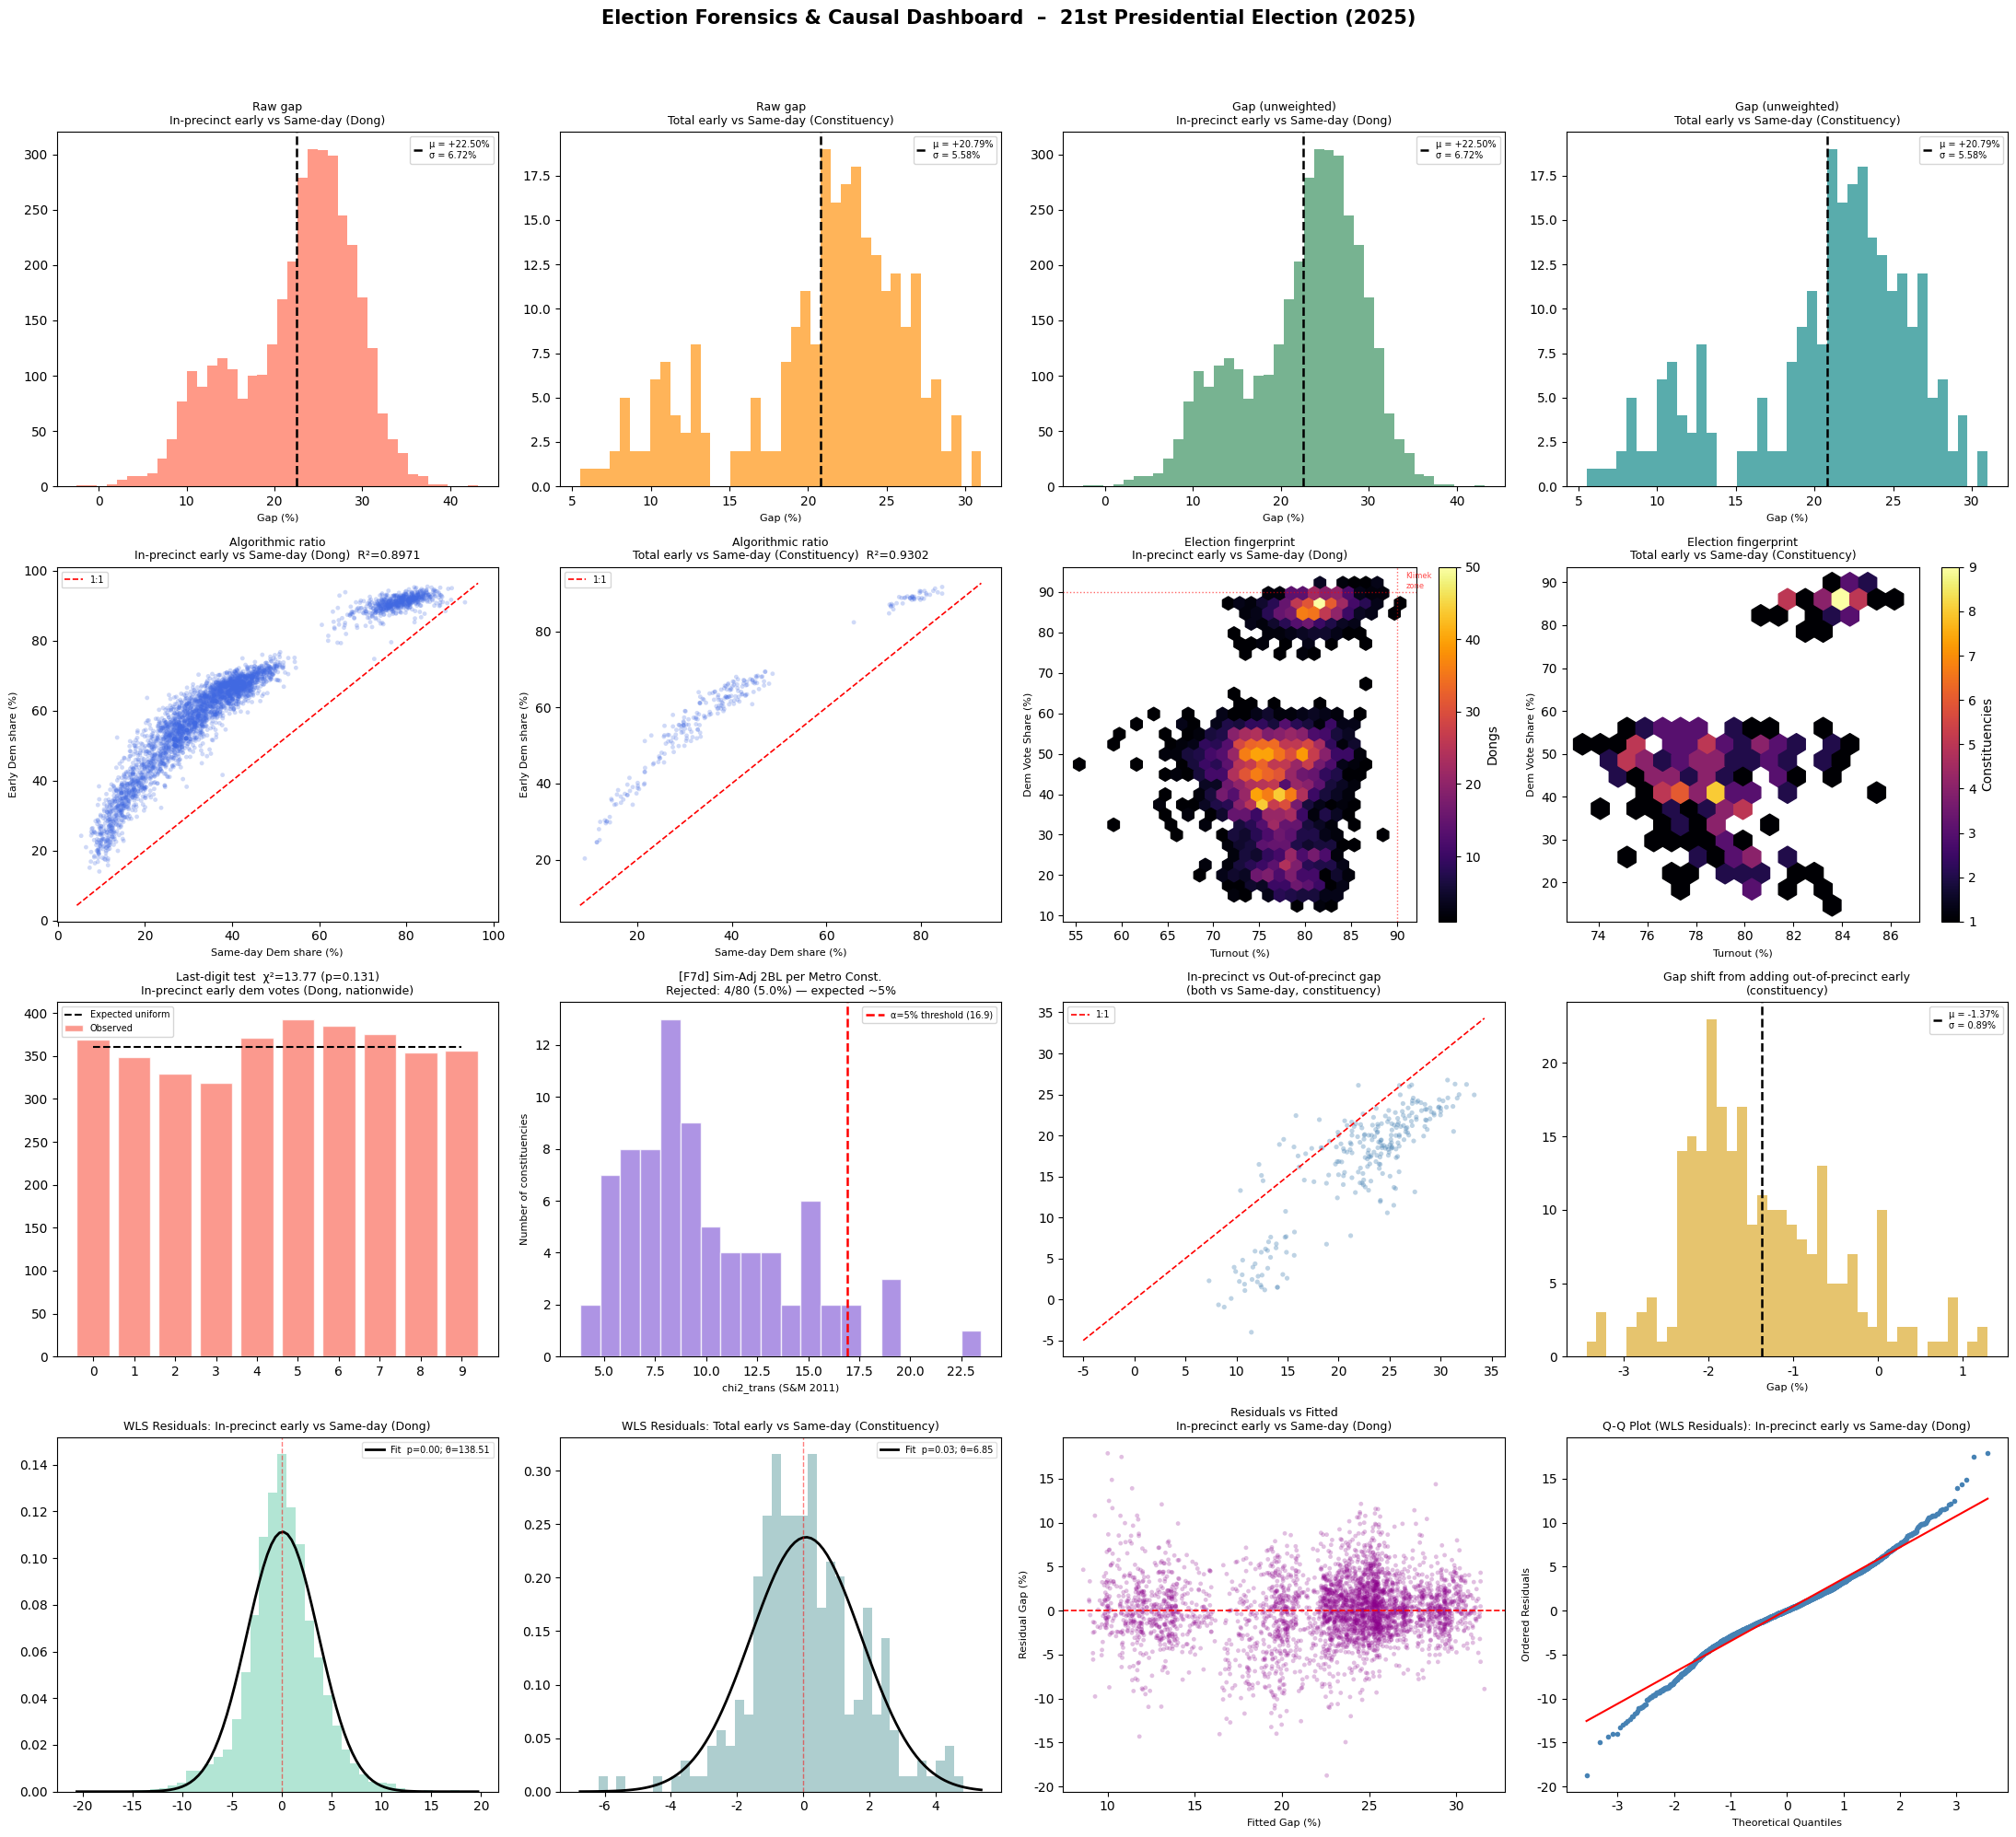

In [24]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import os
import re
import glob
from difflib import get_close_matches
from scipy.stats import (chisquare, pearsonr, norm, probplot, normaltest,
                          gaussian_kde, multivariate_t, ttest_1samp)
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# FONT SETUP
# ==========================================

def setup_font():
    """Configure matplotlib to render text properly."""
    matplotlib.rcParams['axes.unicode_minus'] = False

# ==========================================
# CONFIGURATION
# ==========================================

ELECTION_NUM = 'pres21'   # options: 21, 22, 'pres20', 'pres21'
EXCLUDE_HONAM_YEONGNAM = False

PCA_VARIANCE_THRESHOLD     = 0.95
DEMEAN_GROUP_COLS          = ['province_tag']  # Removed urban_type
MIN_COVERAGE               = 0.50

ELECTION_CONFIGS = {
    21: {
        'election_type':  'general',
        'census_csv':     '21st_election_census.csv',
        'result_csv':     '21st_election_result.csv',
        'apt_csv_glob':   '*21st_election_*_apt_price.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'미래통합당|자유한국당',
        'third_pattern':  None,
        'label':          '21st General Election (2020)',
        'year':           2020,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_21st.png',
    },
    22: {
        'election_type':  'general',
        'census_csv':     '22nd_election_census.csv',
        'result_csv':     '22nd_election_result.csv',
        'apt_csv_glob':   '*22nd_election_*_apt_price.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'국민의힘',
        'third_pattern':  None,
        'label':          '22nd General Election (2024)',
        'year':           2024,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_22nd.png',
    },
    'pres20': {
        'election_type':         'presidential',
        'census_csv':            '20th_presidential_election_census.csv',
        'result_csv':            '20th_presidential_election_result.csv',
        'apt_csv_glob':          '*20th_presidential_election_*_apt_prices.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         None,
        'label':                 '20th Presidential Election (2022)',
        'year':                  2022,
        'election_month':        3,
        'dashboard_out':         'mega_forensics_dashboard_pres20.png',
        'fallback_election_num': 21,
    },
    'pres21': {
        'election_type':         'presidential',
        'census_csv':            '21st_presidential_election_census.csv',
        'result_csv':            '21st_presidential_election_result.csv',
        'apt_csv_glob':          '*21st_presidential_election_*_apt_prices.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         r'이준석|개혁신당',
        'label':                 '21st Presidential Election (2025)',
        'year':                  2025,
        'election_month':        6,
        'dashboard_out':         'mega_forensics_dashboard_pres21.png',
        'fallback_election_num': 22,
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES_GENERAL = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES_PRESIDENTIAL = {
    '거소·선상투표', '관외사전투표', '재외투표',
    '잘못 투입·구분된 투표지',
}
GWANNAESA_LABEL = '관내사전투표'
GWANOE_LABEL    = '관외사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': 'Seoul',  '부산광역시': 'Busan',   '대구광역시': 'Daegu',
    '인천광역시': 'Incheon','광주광역시': 'Gwangju', '대전광역시': 'Daejeon',
    '울산광역시': 'Ulsan',  '세종특별자치시': 'Sejong',
    '경기도': 'Gyeonggi',  '강원도': 'Gangwon',     '강원특별자치도': 'Gangwon',
    '충청북도': 'Chungbuk', '충청남도': 'Chungnam',
    '전라북도': 'Jeonbuk',  '전북특별자치도': 'Jeonbuk', '전라남도': 'Jeonnam',
    '경상북도': 'Gyeongbuk','경상남도': 'Gyeongnam', '제주특별자치도': 'Jeju',
    # Abbreviated metro-city names used in employment CSV region column
    '서울': 'Seoul',   '부산': 'Busan',    '대구': 'Daegu',
    '인천': 'Incheon', '광주': 'Gwangju',  '대전': 'Daejeon',
    '울산': 'Ulsan',
}

# Maps standalone provincial city/county names (as they appear in employment CSVs,
# without a province prefix) to their English province tag.
SGG_TO_PROVINCE_EMP = {
    # Gyeonggi
    '가평군':'Gyeonggi','고양시':'Gyeonggi','과천시':'Gyeonggi','광명시':'Gyeonggi',
    '광주시':'Gyeonggi','구리시':'Gyeonggi','군포시':'Gyeonggi','김포시':'Gyeonggi',
    '남양주시':'Gyeonggi','동두천시':'Gyeonggi','부천시':'Gyeonggi','성남시':'Gyeonggi',
    '수원시':'Gyeonggi','시흥시':'Gyeonggi','안산시':'Gyeonggi','안성시':'Gyeonggi',
    '안양시':'Gyeonggi','양주시':'Gyeonggi','양평군':'Gyeonggi','여주군':'Gyeonggi',
    '여주시':'Gyeonggi','연천군':'Gyeonggi','오산시':'Gyeonggi','용인시':'Gyeonggi',
    '의왕시':'Gyeonggi','의정부시':'Gyeonggi','의정부시':'Gyeonggi','이천시':'Gyeonggi',
    '파주시':'Gyeonggi','평택시':'Gyeonggi','포천시':'Gyeonggi','하남시':'Gyeonggi',
    '화성시':'Gyeonggi',
    # Gangwon
    '강릉시':'Gangwon','고성군':'Gangwon','동해시':'Gangwon','삼척시':'Gangwon',
    '속초시':'Gangwon','양구군':'Gangwon','양양군':'Gangwon','영월군':'Gangwon',
    '원주시':'Gangwon','인제군':'Gangwon','정선군':'Gangwon','철원군':'Gangwon',
    '춘천시':'Gangwon','태백시':'Gangwon','평창군':'Gangwon','홍천군':'Gangwon',
    '화천군':'Gangwon','횡성군':'Gangwon',
    # Chungbuk
    '괴산군':'Chungbuk','단양군':'Chungbuk','보은군':'Chungbuk','영동군':'Chungbuk',
    '옥천군':'Chungbuk','음성군':'Chungbuk','제천시':'Chungbuk','증평군':'Chungbuk',
    '진천군':'Chungbuk','청원군':'Chungbuk','청주시':'Chungbuk','충주시':'Chungbuk',
    # Chungnam
    '계룡시':'Chungnam','공주시':'Chungnam','금산군':'Chungnam','논산시':'Chungnam',
    '당진시':'Chungnam','보령시':'Chungnam','부여군':'Chungnam','서산시':'Chungnam',
    '서천군':'Chungnam','아산시':'Chungnam','연기군':'Chungnam','예산군':'Chungnam',
    '청양군':'Chungnam','천안시':'Chungnam','태안군':'Chungnam','홍성군':'Chungnam',
    # Jeonbuk
    '고창군':'Jeonbuk','군산시':'Jeonbuk','김제시':'Jeonbuk','남원시':'Jeonbuk',
    '무주군':'Jeonbuk','부안군':'Jeonbuk','순창군':'Jeonbuk','완주군':'Jeonbuk',
    '익산시':'Jeonbuk','임실군':'Jeonbuk','장수군':'Jeonbuk','전주시':'Jeonbuk',
    '정읍시':'Jeonbuk','진안군':'Jeonbuk',
    # Jeonnam
    '강진군':'Jeonnam','고흥군':'Jeonnam','곡성군':'Jeonnam','구례군':'Jeonnam',
    '나주시':'Jeonnam','담양군':'Jeonnam','목포시':'Jeonnam','무안군':'Jeonnam',
    '보성군':'Jeonnam','순천시':'Jeonnam','신안군':'Jeonnam','여수시':'Jeonnam',
    '영광군':'Jeonnam','영암군':'Jeonnam','완도군':'Jeonnam','장성군':'Jeonnam',
    '장흥군':'Jeonnam','진도군':'Jeonnam','함평군':'Jeonnam','화순군':'Jeonnam',
    '광양시':'Jeonnam','해남군':'Jeonnam',
    # Gyeongbuk
    '경산시':'Gyeongbuk','경주시':'Gyeongbuk','고령군':'Gyeongbuk','구미시':'Gyeongbuk',
    '김천시':'Gyeongbuk','문경시':'Gyeongbuk','봉화군':'Gyeongbuk','상주시':'Gyeongbuk',
    '성주군':'Gyeongbuk','안동시':'Gyeongbuk','영덕군':'Gyeongbuk','영양군':'Gyeongbuk',
    '영주시':'Gyeongbuk','영천시':'Gyeongbuk','예천군':'Gyeongbuk','울릉군':'Gyeongbuk',
    '울진군':'Gyeongbuk','의성군':'Gyeongbuk','청도군':'Gyeongbuk','청송군':'Gyeongbuk',
    '칠곡군':'Gyeongbuk','포항시':'Gyeongbuk',
    # Gyeongnam
    '거제시':'Gyeongnam','거창군':'Gyeongnam','김해시':'Gyeongnam','남해군':'Gyeongnam',
    '밀양시':'Gyeongnam','사천시':'Gyeongnam','산청군':'Gyeongnam','양산시':'Gyeongnam',
    '의령군':'Gyeongnam','진주시':'Gyeongnam','창녕군':'Gyeongnam','창원시':'Gyeongnam',
    '통영시':'Gyeongnam','하동군':'Gyeongnam','함안군':'Gyeongnam','함양군':'Gyeongnam',
    '합천군':'Gyeongnam',
    # Jeju
    '서귀포시':'Jeju','제주시':'Jeju',
}

PARTISAN_REGION_PROVINCES = {
    'Honam':   {'Jeonnam', 'Jeonbuk', 'Gwangju', '전남', '전북', '광주'},
    'Yeongnam':{'Gyeongbuk', 'Gyeongnam', 'Daegu', 'Busan', 'Ulsan',
                '경북', '경남', '대구', '부산', '울산'},
}

AGE_GENDER_COLS = [
    'pct_m_1824', 'pct_m_2529', 'pct_m_3034', 'pct_m_3539', 'pct_m_4044', 'pct_m_4549',
    'pct_m_5054', 'pct_m_5559', 'pct_m_6064', 'pct_m_6569', 'pct_m_70plus',
    'pct_f_1824', 'pct_f_2529', 'pct_f_3034', 'pct_f_3539', 'pct_f_4044', 'pct_f_4549',
    'pct_f_5054', 'pct_f_5559', 'pct_f_6064', 'pct_f_6569', 'pct_f_70plus',
]

EMPLOYMENT_FEATURE_COLS = [
    'emp_men_total', 'emp_men_1529', 'emp_men_3049', 'emp_men_5064', 'emp_men_65plus',
    'emp_wmn_total', 'emp_wmn_1529', 'emp_wmn_3049', 'emp_wmn_5064', 'emp_wmn_65plus',
    'occ_wage_share', 'occ_regular_share', 'occ_nonwage_share',
    'job_professional', 'job_clerical', 'job_service_sales',
    'job_skilled_machine', 'job_simple_labor', 'job_farming',
    'ind_agriculture', 'ind_manufacturing', 'ind_construction',
    'ind_retail_food', 'ind_transport_finance', 'ind_services',
    'nonp_male_share', 'nonp_young_share', 'nonp_middle_share', 'nonp_old_share',
]

# ==========================================
# SHARED NORMALISATION & IO UTILITIES
# ==========================================

def _read_csv_auto(path: str, **kwargs) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8', **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp949', **kwargs)

def _to_numeric_safe(series: pd.Series) -> pd.Series:
    return (series.astype(str).str.strip()
            .replace(['-', '.', '', 'nan'], np.nan)
            .pipe(pd.to_numeric, errors='coerce'))

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구'  and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates

def get_election_periods(month: int, year: int) -> dict:
    if month <= 6:
        prev = year - 1
        return {'half_periods': [f'{prev}.1/2', f'{prev}.2/2'], 'grdp_year': prev}
    else:
        prev = year - 1
        return {'half_periods': [f'{prev}.2/2', f'{year}.1/2'], 'grdp_year': prev}

def parse_employment_sgg(region_name: str) -> tuple:
    if not isinstance(region_name, str): return ('', '')
    parts = region_name.strip().split(None, 1)
    if not parts: return ('', '')
    prov = parts[0]
    if len(parts) == 1:
        prov_eng = SGG_TO_PROVINCE_EMP.get(prov, '')
        primary  = re.sub(r'[시군구]$', '', prov).strip()
        return (prov_eng, primary)
    sgg_raw  = parts[1]
    sgg_norm = normalize_sigungu(sgg_raw)
    primary  = sgg_norm[0] if sgg_norm else re.sub(r'[시군구]$', '', sgg_raw).strip()
    prov_eng = PROV_FULL_TO_SHORT.get(prov, prov)
    return (prov_eng, primary)

# ==========================================
# 1. DEMOGRAPHIC & ASSET DATA LOADERS
# ==========================================

def _detect_year_prefix(df: pd.DataFrame) -> str:
    for col in df.columns:
        m = re.match(r'(\d{4}년\d{2}월)_계_총인구수', col)
        if m: return m.group(1)
    raise ValueError("Cannot detect census year prefix.")

def load_census_csv(csv_path: str) -> pd.DataFrame:
    print(f"\n--- [1/6] Loading Demographic Census Data ---")
    if not csv_path or not os.path.exists(csv_path): return pd.DataFrame()
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
        prefix = _detect_year_prefix(df)
        voting_age_cols = ([f"{prefix}_계_{a}세" for a in range(18, 100)]
                           + [f"{prefix}_계_100세 이상"])
        cols_4059 = [f"{prefix}_계_{a}세" for a in range(40, 60)]

        all_target_cols = list(voting_age_cols)
        for g in ['남', '여']:
            for a in range(18, 100):
                all_target_cols.append(f"{prefix}_{g}_{a}세")
            all_target_cols.append(f"{prefix}_{g}_100세 이상")

        for col in set(all_target_cols):
            if col in df.columns:
                df[col] = (df[col].astype(str).str.replace(',', '', regex=False)
                           .pipe(pd.to_numeric, errors='coerce').fillna(0))

        df = df.copy()
        df['total_voting_pop'] = df[[c for c in voting_age_cols if c in df.columns]].sum(axis=1)
        df = df[df['total_voting_pop'] > 0].copy()

        ranges = [(18,25,'1824'),(25,30,'2529'),(30,35,'3034'),(35,40,'3539'),
                  (40,45,'4044'),(45,50,'4549'),(50,55,'5054'),(55,60,'5559'),
                  (60,65,'6064'),(65,70,'6569')]

        for g, g_str in [('남','m'), ('여','f')]:
            for r_start, r_end, r_str in ranges:
                cols = [f"{prefix}_{g}_{a}세" for a in range(r_start, r_end)]
                df[f'pct_{g_str}_{r_str}'] = (df[[c for c in cols if c in df.columns]].sum(axis=1)
                                               / df['total_voting_pop'])
            cols_70 = ([f"{prefix}_{g}_{a}세" for a in range(70, 100)]
                       + [f"{prefix}_{g}_100세 이상"])
            df[f'pct_{g_str}_70plus'] = (df[[c for c in cols_70 if c in df.columns]].sum(axis=1)
                                          / df['total_voting_pop'])

        df['demographic_propensity'] = (df[[c for c in cols_4059 if c in df.columns]].sum(axis=1)
                                         / df['total_voting_pop'])

        def extract_census_keys(admin_name):
            if not isinstance(admin_name, str): return [], ""
            clean = re.sub(r'\(.*?\)', '', admin_name).strip()
            parts = clean.split()
            dong_norm = normalize_dong_name(parts[-1]) if parts else ""
            sgg_cands = []
            for token in reversed(parts[:-1]):
                for c in normalize_sigungu(token):
                    if c not in sgg_cands: sgg_cands.append(c)
            return sgg_cands, dong_norm

        rows = []
        for _, row in df.iterrows():
            sgg_cands, dong_norm = extract_census_keys(row['행정구역'])
            row_dict = {
                'sgg_candidates': sgg_cands,
                'primary_sgg':    sgg_cands[0] if sgg_cands else "",
                'dong_norm':      dong_norm,
                'dong_raw':       row['행정구역'],
                'demographic_propensity': row['demographic_propensity'],
            }
            for col in AGE_GENDER_COLS:
                row_dict[col] = row.get(col, np.nan)
            rows.append(row_dict)

        census = pd.DataFrame(rows)
        print(f"    Loaded {len(census):,} census rows with 22 Age-Gender cohorts.")
        return census
    except Exception as e:
        print(f"[!] Error processing census CSV: {e}")
        return pd.DataFrame()

def load_apt_csv(glob_pattern: str) -> pd.DataFrame:
    print(f"\n--- [2/6] Loading Apartment Transaction Data ---")
    if not glob_pattern: return pd.DataFrame()
    file_list = glob.glob(glob_pattern)
    if not file_list: return pd.DataFrame()

    df_list = []
    for file in file_list:
        try:
            df_list.append(_read_csv_auto(file, skiprows=15))
        except Exception:
            pass
    if not df_list: return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    try:
        df['거래금액(만원)'] = pd.to_numeric(
            df['거래금액(만원)'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
        df['전용면적(㎡)']   = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')
        df['price_per_sqm']  = df['거래금액(만원)'] / df['전용면적(㎡)']

        def parse_loc(x):
            parts = str(x).split()
            prov  = PROV_FULL_TO_SHORT.get(parts[0], parts[0]) if parts else ""
            sgg   = normalize_sigungu(parts[1])[0] if len(parts) > 2 and normalize_sigungu(parts[1]) else ""
            dong  = normalize_dong_name(parts[-1]) if parts else ""
            return pd.Series([prov, sgg, dong])

        df[['prov','sgg','dong_norm']] = df['시군구'].apply(parse_loc)

        # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
        mask_seoul = df['prov'] == 'Seoul'
        mask_g3 = df['sgg'].isin(['강남', '서초', '송파'])
        df.loc[mask_seoul & mask_g3, 'prov'] = 'Seoul (Gangnam3gu)'
        df.loc[mask_seoul & ~mask_g3, 'prov'] = 'Seoul (Non-Gangnam3gu)'

        apt_agg = (df.groupby(['prov','sgg','dong_norm'])['price_per_sqm']
                   .median().reset_index()
                   .rename(columns={'price_per_sqm': 'median_apt_price_sqm'}))
        print(f"    Calculated stable median prices for {len(apt_agg):,} unique Dongs.")
        return apt_agg
    except Exception as e:
        print(f"[!] Error processing concatenated APT data: {e}")
        return pd.DataFrame()

def _avg_half_periods(df: pd.DataFrame, base_cols: list) -> pd.Series:
    available = [c for c in base_cols if c in df.columns]
    if not available: return pd.Series(np.nan, index=df.index)
    return df[available].apply(pd.to_numeric, errors='coerce').mean(axis=1)

def load_employment_sgg(election_key: str, **kwargs) -> pd.DataFrame:
    print(f"\n--- [3/6] Loading Employment Covariates ---")
    cfg    = ELECTION_CONFIGS[election_key]
    month  = cfg['election_month']
    year   = cfg['year']
    periods_info = get_election_periods(month, year)
    periods      = periods_info['half_periods']

    def read_emp(path):
        if not os.path.exists(path): return pd.DataFrame()
        df = _read_csv_auto(path, low_memory=False)
        return df[[c for c in df.columns if not str(c).startswith('Unnamed')]]

    age_map = {'total':'계','1529':'15 - 29세','3049':'30 - 49세',
               '5064':'50 - 64세','65plus':'65세이상'}

    def extract_gender_emp(csv_path, gender_prefix):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df_rate = df[df['항목'].str.strip() == '고용률 (%)'].copy()
        records = {}
        for suf, kor_age in age_map.items():
            sub = df_rate[df_rate['연령별'].str.strip() == kor_age].copy()
            if sub.empty: continue
            val_col = f'{gender_prefix}_{suf}'
            sub[val_col] = _avg_half_periods(sub, periods)
            prov_sgg = sub['행정구역별'].apply(parse_employment_sgg)
            sub['province_tag'] = prov_sgg.apply(lambda x: x[0])
            sub['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
            records[val_col] = sub.groupby(['province_tag','primary_sgg'])[val_col].mean()
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_men = extract_gender_emp(kwargs.get('men_csv',   'men_employment_data.csv'),   'emp_men')
    df_wmn = extract_gender_emp(kwargs.get('women_csv', 'women_employment_data.csv'), 'emp_wmn')

    occ_type_map = {'occ_wage_share':'임금근로자',
                    'occ_regular_share':'- 상용근로자',
                    'occ_nonwage_share':'비임금근로자'}

    def extract_occ_type(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df_total = df[df['종사상지위별'].str.strip() == '계'].copy()
        df_total['_total'] = _avg_half_periods(df_total, periods)
        prov_sgg = df_total['행정구역별'].apply(parse_employment_sgg)
        df_total['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df_total['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df_total.set_index(['province_tag','primary_sgg'])['_total']
        records = {}
        for col_name, kor_cat in occ_type_map.items():
            sub = df[df['종사상지위별'].str.strip() == kor_cat].copy()
            if sub.empty: continue
            sub['_val'] = _avg_half_periods(sub, periods)
            prov_sgg2 = sub['행정구역별'].apply(parse_employment_sgg)
            sub['province_tag'] = prov_sgg2.apply(lambda x: x[0])
            sub['primary_sgg']  = prov_sgg2.apply(lambda x: x[1])
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_occ_type = extract_occ_type(kwargs.get('occ_type_csv', 'occupation_type_employment_data.csv'))

    job_map = {
        'job_professional':   '관리자, 전문가 및 관련종사자',
        'job_clerical':       '사무 종사자',
        'job_service_sales':  '서비스·판매 종사자',
        'job_skilled_machine':'기능·기계조작·조립 종사자',
        'job_simple_labor':   '단순노무 종사자',
        'job_farming':        '농림어업 숙련종사자',
    }

    def extract_job_shares(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df[df['항목'].str.strip() == '취업자[천명]'].copy()
        df['_val'] = _avg_half_periods(df, periods)
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df[df['직업별'].str.strip() == '계'].set_index(['province_tag','primary_sgg'])['_val']
        records = {}
        for col_name, kor_cat in job_map.items():
            sub = df[df['직업별'].str.strip() == kor_cat].copy()
            if sub.empty: continue
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_job = extract_job_shares(kwargs.get('occ_csv', 'occupation_employment_data.csv'))

    ind_map = {
        'ind_agriculture':        '농업, 임업 및 어업 (A)',
        'ind_manufacturing':      '광·제조업(B,C)',
        'ind_construction':       '건설업 (F) ',
        'ind_retail_food':        '도소매·숙박음식업(G,I)',
        'ind_transport_finance':  '전기·운수·통신·금융(D,H,J,K)',
        'ind_services':           '사업·개인·공공서비스 및 기타(E,L~U)',
    }

    def extract_ind_shares(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df[df['항목'].str.strip() == '취업자[천명]'].copy()
        df['_val'] = _avg_half_periods(df, periods)
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df[df['산업별'].str.strip() == '계'].set_index(['province_tag','primary_sgg'])['_val']
        records = {}
        for col_name, kor_cat in ind_map.items():
            sub = df[df['산업별'].str.strip() == kor_cat.strip()].copy()
            if sub.empty:
                match = get_close_matches(kor_cat.strip(),
                                          df['산업별'].str.strip().unique().tolist(), n=1, cutoff=0.85)
                if match: sub = df[df['산업별'].str.strip() == match[0]].copy()
            if sub.empty: continue
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_ind = extract_ind_shares(kwargs.get('ind_csv', 'industry_employment_data.csv'))

    def extract_nonpart(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df.iloc[1:].copy()
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        sub_suffixes = {'total':'', 'male':'.1', 'young':'.3', 'middle':'.4'}
        period_vals  = {k: [] for k in sub_suffixes}
        for period in periods:
            for k, suf in sub_suffixes.items():
                if period + suf in df.columns:
                    period_vals[k].append(_to_numeric_safe(df[period + suf]))
        def mean_series(lst):
            return pd.concat(lst, axis=1).mean(axis=1) if lst else pd.Series(np.nan, index=df.index)
        total  = mean_series(period_vals['total'])
        result = df[['province_tag','primary_sgg']].copy()
        result['nonp_male_share']   = mean_series(period_vals['male'])   / total.replace(0, np.nan)
        result['nonp_young_share']  = mean_series(period_vals['young'])  / total.replace(0, np.nan)
        result['nonp_middle_share'] = mean_series(period_vals['middle']) / total.replace(0, np.nan)
        return (result.groupby(['province_tag','primary_sgg'])
                [['nonp_male_share','nonp_young_share','nonp_middle_share']]
                .mean().reset_index())

    df_nonp = extract_nonpart(kwargs.get('nonp_csv', 'non_participant_employment_data.csv'))

    merge_key = ['province_tag','primary_sgg']
    frames = [f for f in [df_men, df_wmn, df_occ_type, df_job, df_ind, df_nonp] if not f.empty]
    if not frames: return pd.DataFrame(columns=merge_key + EMPLOYMENT_FEATURE_COLS)

    df_emp = frames[0]
    for frame in frames[1:]:
        df_emp = df_emp.merge(frame, on=merge_key, how='outer')
    for col in EMPLOYMENT_FEATURE_COLS:
        if col not in df_emp.columns: df_emp[col] = np.nan

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    if not df_emp.empty:
        mask_seoul = df_emp['province_tag'] == 'Seoul'
        mask_g3 = df_emp['primary_sgg'].isin(['강남', '서초', '송파'])
        df_emp.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
        df_emp.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    return df_emp

# ==========================================
# 2. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str,
                      third_pattern: str = None, election_type: str = 'general'):
    print(f"\n--- [4/6] Loading Election Result Data ({csv_path}, type={election_type}) ---")
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if election_type == 'presidential':
        df = df.rename(columns={'구시군명': '선거구명', '읍면동명': '법정읍면동명'})
        special_dong_names = SPECIAL_DONG_NAMES_PRESIDENTIAL
    else:
        special_dong_names = SPECIAL_DONG_NAMES_GENERAL

    df['득표수']    = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']   = df['후보자'].str.contains(dem_pattern,   case=False, na=False)
    df['is_con']   = df['후보자'].str.contains(con_pattern,   case=False, na=False)
    df['is_third'] = df['후보자'].str.contains(third_pattern, case=False, na=False) if third_pattern else False
    df['is_meta']  = df['후보자'].isin(META_CANDIDATES)
    df['is_early'] = df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명','선거구명','법정읍면동명']
    const_key = ['시도명','선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(special_dong_names)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot = df_votes[df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    sd_dem = df_votes[df_votes['is_dem']  & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')
    gn_th  = df_votes[df_votes['is_third'] & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_third')
    sd_th  = df_votes[df_votes['is_third'] & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_third')

    sum_people_dong = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_people'))
    sum_vote_geo    = (df_geo[df_geo['후보자'] == '투표수']
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo'))

    df_dong = gn_dem.copy()
    for frame in (gn_tot, gn_con, gn_th, sd_dem, sd_tot, sd_th,
                  sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    gn_ppl_dong = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                   .groupby(dong_key)['득표수'].sum().reset_index(name='_gn_ppl'))
    df_dong = df_dong.merge(gn_ppl_dong, on=dong_key, how='left')
    df_dong['sum_people'] = df_dong['sum_people'] + df_dong['_gn_ppl'].fillna(0)
    df_dong.drop(columns=['_gn_ppl'], inplace=True)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul = df_dong['province_tag'] == 'Seoul'
    mask_g3 = df_dong['primary_sgg'].isin(['강남', '서초', '송파'])
    df_dong.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_dong.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    # ── Constituency-level aggregates ──
    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot_c  = df_votes[df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con_c  = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    gn_turn_c = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_turnout'))

    df_gw   = df[df['법정읍면동명'] == GWANOE_LABEL]
    df_gw_v = df_gw[~df_gw['is_meta']]

    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_total')
    go_th_c   = df_gw_v[df_gw_v['is_third']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_third')
    go_turn_c = (df_gw[df_gw['후보자'] == '투표수']
                 .groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_turnout'))

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout'))

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')
    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_con_c, gn_turn_c,
                  go_dem_c, go_tot_c, go_turn_c, go_th_c,
                  sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['early_total_dem']     = df_const['in_precinct_early_dem']     + df_const['out_precinct_early_dem']
    df_const['early_total_total']   = df_const['in_precinct_early_total']   + df_const['out_precinct_early_total']
    df_const['early_total_turnout'] = df_const['in_precinct_early_turnout'] + df_const['out_precinct_early_turnout']
    df_const['total_turnout']       = df_const['early_total_turnout'] + df_const['same_day_turnout']

    go_ppl_c = (df_gw[df_gw['후보자'] == '선거인수']
                .groupby(const_key)['득표수'].sum().reset_index(name='_go_ppl'))
    df_const = df_const.merge(go_ppl_c, on=const_key, how='left')
    df_const['sum_people'] = df_const['sum_people'] + df_const['_go_ppl'].fillna(0)
    df_const.drop(columns=['_go_ppl'], inplace=True)

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_c = df_const['province_tag'] == 'Seoul'
    mask_g3_c = df_const['primary_sgg'].isin(['강남', '서초', '송파'])
    df_const.loc[mask_seoul_c & mask_g3_c, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_const.loc[mask_seoul_c & ~mask_g3_c, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    sk = ['시도명','선거구명','법정읍면동명','투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c):
        df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early_flag'] = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['province_tag']  = df_station['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_station['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_s = df_station['province_tag'] == 'Seoul'
    mask_g3_s = df_station['선거구명'].apply(lambda x: any(g in str(x) for g in ['강남', '서초', '송파']))
    df_station.loc[mask_seoul_s & mask_g3_s, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_station.loc[mask_seoul_s & ~mask_g3_s, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    df_station['region']        = df_station['province_tag'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']  = df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan)

    return df_dong, df_const, df_station

# ==========================================
# 3. MULTI-PASS DONG↔CENSUS↔APT↔EMP MATCHER
# ==========================================

def merge_dong_with_covariates(df_election: pd.DataFrame, df_census: pd.DataFrame,
                                df_apt: pd.DataFrame, df_emp: pd.DataFrame) -> pd.DataFrame:
    if not df_census.empty:
        census_lookup = {}
        census_by_sgg = {}
        for _, row in df_census.iterrows():
            dnorm = row['dong_norm']
            covs  = {'demographic_propensity': row['demographic_propensity']}
            for c in AGE_GENDER_COLS: covs[c] = row.get(c, np.nan)
            for sgg in row['sgg_candidates']:
                census_lookup[(sgg, dnorm)] = covs
                census_by_sgg.setdefault(sgg, []).append(dnorm)

        results = []
        for _, row in df_election.iterrows():
            covs = None
            dk   = row['dong_norm']
            sgc  = row['sgg_candidates'] if isinstance(row['sgg_candidates'], list) else [row['primary_sgg']]
            if (row['primary_sgg'], dk) in census_lookup:
                covs = census_lookup[(row['primary_sgg'], dk)]
            if covs is None and '·' in dk:
                k1b = (row['primary_sgg'], dk.replace('·', ''))
                if k1b in census_lookup: covs = census_lookup[k1b]
            if covs is None:
                for sgg in sgc[1:]:
                    if (sgg, dk) in census_lookup: covs = census_lookup[(sgg, dk)]; break
            if covs is None:
                for sgg in sgc:
                    pool = census_by_sgg.get(sgg, [])
                    if pool:
                        m = get_close_matches(dk, pool, n=1, cutoff=0.82)
                        if m and (sgg, m[0]) in census_lookup:
                            covs = census_lookup[(sgg, m[0])]; break
            if covs is None:
                covs = {k: np.nan for k in ['demographic_propensity'] + AGE_GENDER_COLS}
            rd = row.to_dict(); rd.update(covs)
            results.append(rd)
        df_out = pd.DataFrame(results)
    else:
        df_out = df_election.copy()

    if not df_apt.empty:
        df_out = df_out.merge(df_apt,
                              left_on=['province_tag','primary_sgg','dong_norm'],
                              right_on=['prov','sgg','dong_norm'], how='left')
        sgg_med  = df_out.groupby('primary_sgg')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(sgg_med)
        prov_med = df_out.groupby('province_tag')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(prov_med)
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(df_out['median_apt_price_sqm'].median())
        df_out['log_apt_price'] = np.log1p(df_out['median_apt_price_sqm'])
    else:
        df_out['log_apt_price'] = 0.0

    if not df_emp.empty:
        df_out = df_out.merge(df_emp[['province_tag','primary_sgg'] + EMPLOYMENT_FEATURE_COLS],
                              on=['province_tag','primary_sgg'], how='left')
        for col in EMPLOYMENT_FEATURE_COLS:
            if col not in df_out.columns: df_out[col] = np.nan
            prov_med = df_out.groupby('province_tag')[col].transform('median')
            df_out[col] = df_out[col].fillna(prov_med)
            df_out[col] = df_out[col].fillna(df_out[col].median())
    else:
        for col in EMPLOYMENT_FEATURE_COLS: df_out[col] = np.nan

    return df_out[df_out['pct_f_4044'].notna()].copy()


def merge_const_with_covariates(df_const: pd.DataFrame,
                                 df_dong_merged: pd.DataFrame) -> pd.DataFrame:
    """
    Population-weighted aggregation of dong-level census + apt covariates up to
    constituency level, for use in constituency-level forensics.
    """
    if df_dong_merged.empty or 'pct_f_4044' not in df_dong_merged.columns:
        return df_const.copy()

    const_key = ['시도명','선거구명']
    dm = df_dong_merged.dropna(subset=['pct_f_4044']).copy()

    agg_funcs = {'_reg': ('sum_people','sum')}
    for col in AGE_GENDER_COLS:
        dm[f'_pw_{col}'] = dm[col] * dm['sum_people']
        agg_funcs[f'_pw_{col}_sum'] = (f'_pw_{col}','sum')

    out_cols = list(AGE_GENDER_COLS)
    if 'log_apt_price' in dm.columns:
        dm['_pw_log_apt_price'] = dm['log_apt_price'] * dm['sum_people']
        agg_funcs['_pw_log_apt_price_sum'] = ('_pw_log_apt_price','sum')

    agg = dm.groupby(const_key).agg(**agg_funcs).reset_index()

    for col in AGE_GENDER_COLS:
        agg[col] = agg[f'_pw_{col}_sum'] / agg['_reg'].replace(0, np.nan)
    if 'log_apt_price' in dm.columns:
        agg['log_apt_price'] = agg['_pw_log_apt_price_sum'] / agg['_reg'].replace(0, np.nan)
        out_cols.append('log_apt_price')

    return df_const.merge(agg[const_key + out_cols], on=const_key, how='left')

# ==========================================
# 4. GLOBAL PCA COLLINEARITY PIPELINE
# ==========================================

def compute_vif(df: pd.DataFrame, cols: list, label: str = "") -> pd.DataFrame:
    available = [c for c in cols if c in df.columns]
    X = df[available].dropna()
    if X.shape[0] < X.shape[1] + 5: return pd.DataFrame()
    records = []
    for i, col in enumerate(available):
        try:    vif = variance_inflation_factor(X.values.astype(float), i)
        except: vif = np.nan
        records.append({'feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(records).sort_values('VIF', ascending=False)

def _drop_zero_variance_cols(df: pd.DataFrame, cols: list) -> list:
    kept = []
    for col in cols:
        if col not in df.columns: continue
        std = df[col].std(skipna=True)
        if not (pd.isna(std) or std < 1e-10): kept.append(col)
    return kept

def reduce_global_pca(df: pd.DataFrame, feature_cols: list, threshold: float) -> tuple:
    """
    Applies standard scaling to all provided valid feature columns (Demographics,
    Employment, Wealth) simultaneously and extracts perfectly orthogonal Global PCs.
    """
    available = [c for c in feature_cols if c in df.columns and df[c].notna().mean() >= MIN_COVERAGE]
    if len(available) < 2:
        return df.copy(), [], None, available

    valid_mask = df[available].notna().all(axis=1)
    if valid_mask.sum() < 30:
        return df.copy(), [], None, available

    X = df.loc[valid_mask, available].values.astype(float)
    X_scaled = StandardScaler().fit_transform(X)

    pca_probe = PCA().fit(X_scaled)
    cumvar = np.cumsum(pca_probe.explained_variance_ratio_)
    n_components = min(int(np.searchsorted(cumvar, threshold)) + 1, len(available))

    pca_final = PCA(n_components=n_components)
    components = pca_final.fit_transform(X_scaled)

    pc_cols = [f'global_pc{i+1}' for i in range(n_components)]
    df_out = df.copy()
    for col in pc_cols:
        df_out[col] = np.nan
    df_out.loc[valid_mask, pc_cols] = components

    return df_out, pc_cols, pca_final, available

def demean_continuous_within_groups(df: pd.DataFrame, cont_cols: list) -> tuple:
    df_out = df.copy()
    dm_cols   = []
    available = [c for c in cont_cols if c in df_out.columns]
    active_groups = [g for g in DEMEAN_GROUP_COLS if g in df_out.columns]
    for col in available:
        gm     = df_out.groupby(active_groups)[col].transform('mean')
        dm_col = f'{col}_dm'
        df_out[dm_col] = df_out[col] - gm
        dm_cols.append(dm_col)
    return df_out, dm_cols

def prepare_continuous_covariates(df: pd.DataFrame, raw_age_cols: list,
                                   raw_emp_cols: list, label: str = "") -> tuple:
    combined_raw = list(raw_age_cols) + list(raw_emp_cols)
    if 'log_apt_price' in df.columns:
        combined_raw.append('log_apt_price')

    df, pc_cols, pca_model, used_features = reduce_global_pca(df, combined_raw, PCA_VARIANCE_THRESHOLD)

    pc_cols = [c for c in pc_cols if df[c].notna().mean() >= MIN_COVERAGE]

    if pc_cols:
        df, dm_cols = demean_continuous_within_groups(df, pc_cols)
    else:
        dm_cols = []

    dm_cols = _drop_zero_variance_cols(df, dm_cols)

    if dm_cols:
        valid_mask = df[dm_cols].notna().all(axis=1)
        if valid_mask.sum() > len(dm_cols) + 5:
            scaler = StandardScaler()
            df.loc[valid_mask, dm_cols] = scaler.fit_transform(df.loc[valid_mask, dm_cols])

    return df, dm_cols, pca_model, used_features

# ==========================================
# 5. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if 'Incheon' in region or 'Gyeyang' in region or 'Yeonsu' in region: return "Incheon"
    if any(c in region for c in ('Suwon','Goyang','Seongnam','Yongin','Gyeonggi')): return "Gyeonggi"
    if 'Seoul (Gangnam3gu)' in region: return "Seoul (Gangnam3gu)"
    if 'Seoul' in region: return "Seoul (Non-Gangnam3gu)"
    return "Other"

def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n

def compute_benford_2bl_statistic(vote_series: pd.Series) -> float:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    if len(valid) == 0: return np.nan
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2, _ = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return chi2

def simulate_2bl_critical_value(df_constituency: pd.DataFrame,
                                 dem_col:   str = 'in_precinct_early_dem',
                                 con_col:   str = 'in_precinct_early_con',
                                 total_col: str = 'in_precinct_early_total',
                                 n_simulations: int = 500,
                                 df_t:      int = 5) -> dict:
    df_sub = df_constituency[df_constituency[total_col] > 0].copy()
    if len(df_sub) < 5:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    eps = 1e-5
    v_dem   = np.maximum(df_sub[dem_col]   / df_sub[total_col], eps)
    v_con   = np.maximum(df_sub[con_col]   / df_sub[total_col], eps)
    v_other = np.maximum(1.0 - v_dem - v_con, eps)
    denom   = v_dem + v_con + v_other
    v_dem, v_con, v_other = v_dem/denom, v_con/denom, v_other/denom
    y_dem = np.log(v_dem / v_other)
    y_con = np.log(v_con / v_other)
    Y = np.column_stack([y_dem, y_con])
    mu = np.mean(Y, axis=0)
    S  = np.cov(Y, rowvar=False)
    shape_matrix = S * (df_t - 2) / df_t if df_t > 2 else S
    shape_matrix = np.atleast_2d(shape_matrix)
    try:
        rv = multivariate_t(loc=mu, shape=shape_matrix, df=df_t)
    except Exception:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    actual_voters = df_sub[total_col].values
    simulated_chi2_stats = []
    for _ in range(n_simulations):
        Y_sim = rv.rvs(size=len(df_sub))
        if len(df_sub) == 1: Y_sim = Y_sim.reshape(1, -1)
        exp_y_dem = np.exp(Y_sim[:, 0])
        exp_y_con = np.exp(Y_sim[:, 1])
        denom_sim = 1.0 + exp_y_dem + exp_y_con
        v_dem_sim = exp_y_dem / denom_sim
        sim_counts = np.round(v_dem_sim * actual_voters)
        sim_chi2 = compute_benford_2bl_statistic(pd.Series(sim_counts))
        if not np.isnan(sim_chi2): simulated_chi2_stats.append(sim_chi2)
    if not simulated_chi2_stats:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    empirical_chi2 = compute_benford_2bl_statistic(df_sub[dem_col])
    chi2_sim95     = np.percentile(simulated_chi2_stats, 95)
    chi2_trans     = (empirical_chi2 * 16.9 / chi2_sim95) if chi2_sim95 > 0 else np.nan
    return {'empirical_chi2': empirical_chi2, 'chi2_sim95': chi2_sim95, 'chi2_trans': chi2_trans}

def _classify_gmm_cluster(t_center: float, v_center: float,
                           province_tag_series: pd.Series) -> str:
    KLIMEK_TURNOUT_THRESHOLD = 0.90
    KLIMEK_SHARE_THRESHOLD   = 0.90
    joint_extreme = (t_center > KLIMEK_TURNOUT_THRESHOLD and
                     (v_center > KLIMEK_SHARE_THRESHOLD or v_center < (1 - KLIMEK_SHARE_THRESHOLD)))
    if joint_extreme:
        return "Klimek Anomaly — extreme turnout + vote share (fraud signal)"
    if province_tag_series is not None and len(province_tag_series) > 0:
        top_prov = province_tag_series.value_counts().index[0]
        for region_name, region_provs in PARTISAN_REGION_PROVINCES.items():
            if top_prov in region_provs:
                return f"Geographic/Partisan — {region_name} region ({top_prov} dominant)"
    return "Geographic/Partisan — swing or mixed region"


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame,
                  df_station:  pd.DataFrame, df_census:    pd.DataFrame,
                  df_apt:      pd.DataFrame, df_emp:       pd.DataFrame) -> dict:
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log(f"\n--- [5/6] Forensics Suite ---")
    MIN_VOTES = 50

    dm = merge_dong_with_covariates(df_dong_raw, df_census, df_apt, df_emp)
    dm = dm[(dm['in_precinct_early_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()
    no_cand = (dm['in_precinct_early_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    # --- PROPORTIONALLY ALLOCATE OUT-OF-PRECINCT VOTES TO DONG LEVEL ---
    const_sums = dm.groupby(['시도명', '선거구명'])[['in_precinct_early_total', 'same_day_total']].transform('sum')
    dm['dong_weight'] = (dm['in_precinct_early_total'] + dm['same_day_total']) / (const_sums['in_precinct_early_total'] + const_sums['same_day_total']).replace(0, np.nan)

    cols_to_merge = ['시도명', '선거구명', 'out_precinct_early_dem', 'out_precinct_early_total']
    if 'out_precinct_early_third' in df_const_raw.columns:
        cols_to_merge.append('out_precinct_early_third')

    df_const_sub = df_const_raw[cols_to_merge].drop_duplicates()
    dm = dm.merge(df_const_sub, on=['시도명', '선거구명'], how='left')

    dm['out_precinct_alloc_dem'] = dm['out_precinct_early_dem'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_tot'] = dm['out_precinct_early_total'].fillna(0) * dm['dong_weight'].fillna(0)

    if 'out_precinct_early_third' in dm.columns:
        dm['out_precinct_alloc_third'] = dm['out_precinct_early_third'].fillna(0) * dm['dong_weight'].fillna(0)

    log("\n  ── Variable Definitions ──")
    log("  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total")
    log("                 The Democratic candidate's vote share among all valid ballots")
    log("                 cast at in-precinct early-voting stations (관내사전투표소).")
    log("  sameday_pct  = same_day_dem ÷ same_day_total")
    log("                 The Democratic share among voters who showed up on election day")
    log("                 (당일투표), the conventional voting mode.")
    log("  gap          = early_pct − sameday_pct")
    log("  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷")
    log("                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)")
    log("                 Combined Democratic share across all voting modes (Dong level).")
    log("                 Out-of-precinct early votes are proportionally allocated to dongs.")
    log("  turnout      = sum_vote_geo ÷ sum_people")
    log("                 Official turnout rate as ballots cast over registered electors.")

    dm['early_pct']   = dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
    dm['sameday_pct'] = dm['same_day_dem'] / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    dm['w_gap']       = dm['gap']

    dm['vote_share'] = ((dm['in_precinct_early_dem'] + dm['same_day_dem'] + dm['out_precinct_alloc_dem']) /
                        (dm['in_precinct_early_total'] + dm['same_day_total'] + dm['out_precinct_alloc_tot'])).fillna(0)
    dm['turnout']    = dm['sum_vote_geo'] / dm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW — nationwide naive test
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test")
    log("  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.")
    log("="*60)
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['in_precinct_early_dem'])
    log(f"  N (votes >= 10)      : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}  (df=9)")
    log("  Result: " + ("PASS" if p_2bl > 0.05 else "FAIL"))
    log("\n  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}  exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test (Three-Series Comparative)")
    log("="*60)

    def _last_digit_test(series: pd.Series, label: str) -> tuple:
        v  = series.astype(int).astype(str)
        v  = v[v.str.len() >= 2]
        ld = v.str[-1].astype(int)
        n  = len(ld)
        obs = ld.value_counts().reindex(range(10), fill_value=0).sort_index()
        exp = [n / 10.0] * 10
        chi2, p = chisquare(obs.values, f_exp=exp)
        cramer_v = np.sqrt(chi2 / (n * 9)) if n > 0 else np.nan
        log(f"  [{label}]  N={n:,}  χ²={chi2:.2f}  p={p:.4f}  "
            f"Cramér's V={cramer_v:.4f}  {'FAIL ★' if p < 0.05 else 'PASS'}")
        return obs, exp, chi2, p

    obs_ld, exp_ld, chi2_ld, p_ld = _last_digit_test(
        dm['in_precinct_early_dem'], 'in_precinct_early_dem  (early, DEM)')
    obs_ld_con = pd.Series(dtype=int)
    chi2_ld_con, p_ld_con = np.nan, np.nan
    if 'in_precinct_early_con' in dm.columns and dm['in_precinct_early_con'].sum() > 0:
        obs_ld_con, _, chi2_ld_con, p_ld_con = _last_digit_test(
            dm['in_precinct_early_con'], 'in_precinct_early_con  (early, CON)')
    _last_digit_test(dm['same_day_dem'], 'same_day_dem   (sameday, DEM)')

    ld_dem_fails  = p_ld < 0.05
    ld_con_passes = np.isnan(p_ld_con) or p_ld_con >= 0.05
    if ld_dem_fails and ld_con_passes:
        log("  [!] ASYMMETRIC FAILURE: in_precinct_early_dem fails while in_precinct_early_con and")
        log("      same_day_dem pass. This cannot be explained by a counting machine artifact")
        log("      (which would affect all candidates equally). It is candidate-specific.")
    elif ld_dem_fails:
        log("  NOTE: Failure appears in multiple series — likely a structural counting artifact.")

    log(f"\n  Binomial simulation null (using actual in_precinct_early_total & p_dem per dong):")
    gn_tot_col = dm['in_precinct_early_total'].astype(int).values
    p_dem_col  = (dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
                  .replace(0, np.nan)).fillna(0).values
    np.random.seed(42)
    sim_counts = np.array([np.random.binomial(int(N), float(p))
                           for N, p in zip(gn_tot_col, p_dem_col)])
    ld_sim = sim_counts % 10
    obs_sim = np.bincount(ld_sim, minlength=10)
    chi2_sim, p_sim = chisquare(obs_sim, f_exp=[len(ld_sim)/10]*10)
    log(f"  Simulated χ²={chi2_sim:.2f} (p={p_sim:.4f}) vs Actual χ²={chi2_ld:.2f} (p={p_ld:.4f})")
    if p_ld < 0.05 and p_sim >= 0.05:
        log("  The actual deviation exceeds what pure binomial sampling predicts.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby(['province_tag','primary_sgg'])['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate','dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations        : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}  (p={p_inv:.4f})")
        log("  Result: " + (
            "Near-zero — no weaponized invalid ballot signal." if abs(corr_inv) < 0.10
            else f"Non-trivial r={corr_inv:.4f}. Warrants further investigation."))
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
    valid_tp = df_station[(df_station['dem_votes'] + df_station['con_votes']) > 0].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes','sum'),
        con_total=('con_votes','sum'),
        station_count=('dem_votes','count'),
    ).reset_index()
    metro_agg['dem_ratio'] = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio'] = 1.0 - metro_agg['dem_ratio']

    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – in-precinct early votes only)")
    log("="*60)

    METRO_PROVINCES = {'Seoul (Non-Gangnam3gu)', 'Seoul (Gangnam3gu)', 'Incheon', 'Gyeonggi'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    obs_2bl_metro  = pd.Series(dtype=int);  exp_2bl_metro  = np.zeros(10)
    chi2_2bl_metro = np.nan;                p_2bl_metro    = np.nan;  n_2bl_metro = 0
    obs_ld_metro   = pd.Series(dtype=int);  exp_ld_metro   = []
    chi2_ld_metro  = np.nan;                p_ld_metro     = np.nan
    metro_early_agg  = pd.DataFrame()
    metro_early_std  = np.nan
    sm_const_results = pd.DataFrame()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
    else:
        # F7a – Naive 2BL
        log(f"\n  [F7a] Naive 2BL – Metro in_precinct_early_dem (N={len(dm_metro):,} precincts)")
        log(f"  NOTE: Naive χ²(9) test only. See [F7d] for simulation-adjusted result.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['in_precinct_early_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_2bl_metro > 0.05 else "FAIL"))

        votes_metro_sm  = dm_metro['in_precinct_early_dem'][dm_metro['in_precinct_early_dem'] >= 10].values.astype(float)
        votes_nation_sm = dm['in_precinct_early_dem'][dm['in_precinct_early_dem'] >= 10].values.astype(float)
        metro_min_sr    = int(votes_metro_sm.min())  if len(votes_metro_sm)  > 0 else 0
        metro_max_sr    = int(votes_metro_sm.max())  if len(votes_metro_sm)  > 0 else 0
        nation_min_sr   = int(votes_nation_sm.min()) if len(votes_nation_sm) > 0 else 0
        nation_max_sr   = int(votes_nation_sm.max()) if len(votes_nation_sm) > 0 else 0
        metro_orders    = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders   = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} ({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range     : {metro_min_sr:,} – {metro_max_sr:,} ({metro_orders:.2f} orders of magnitude)")

        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm)//10)))
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0)
            kde_obj      = gaussian_kde(votes_metro_sm)
            kde_x        = np.linspace(votes_metro_sm.min(),
                                       min(float(votes_metro_sm.max()), 2000.0), 1000)
            kde_max      = float(kde_obj(kde_x).max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"    Approx. mode of metro vote-count distribution : {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)           : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if not np.isnan(mode_approx) and 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if not np.isnan(kde_max) and kde_max > 0.01 else 'NO'}")
        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max) and (kde_max > 0.01)
        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  Simulation-adjusted result [F7d] is the primary forensic indicator.")

        # F7b – Last-digit metro
        log(f"\n  [F7b] Last-Digit – Metro in_precinct_early_dem")
        v_ld_m = dm_metro['in_precinct_early_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL"))

        # F7c – Early-only two-party ratio
        log(f"\n  [F7c] Early-Only Two-Party Ratio (in-precinct early, 63:37 hypothesis)")
        early_st = df_station[
            df_station['is_early_flag'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes']))
        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes','sum'),
            early_con_total=('con_votes','sum'),
            station_count=('dem_votes','count'),
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total']))
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:22s}: {row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")

        # --- Calculate Total Seoul ---
        seoul_rows = metro_early_agg[metro_early_agg['metro_zone'].str.contains('Seoul', na=False)]
        if not seoul_rows.empty:
            s_dem_tot = seoul_rows['early_dem_total'].sum()
            s_con_tot = seoul_rows['early_con_total'].sum()
            s_n_stat  = seoul_rows['station_count'].sum()
            if s_dem_tot + s_con_tot > 0:
                s_dem_ratio = s_dem_tot / (s_dem_tot + s_con_tot)
                s_con_ratio = 1.0 - s_dem_ratio
                log(f"    {'-'*55}")
                log(f"    {'Seoul (Combined Total)':22s}: {s_dem_ratio*100:.2f}% vs {s_con_ratio*100:.2f}%"
                    f"  (n={s_n_stat:,} early stations)")
        # ----------------------------------

        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"\n  Micro std of early two-party dem share across metro stations: {metro_early_std:.2f}%")
        log(f"  HIGH micro std alongside any macro convergence → LLN, not top-down fixing.")
        log(f"  LOW micro std (<2%) with near-63:37 macro → supports fixed-ratio hypothesis.")

        # F7d – Simulation-adjusted 2BL per metro constituency
        log(f"\n  [F7d] Simulation-Adjusted 2BL Per Metro Constituency (S&M 2011)")
        log(f"  Unit: dongs within each constituency  |  Simulations: 500  |  df_t=5")
        if 'in_precinct_early_con' not in df_dong_raw.columns:
            log("  [!] in_precinct_early_con not found in dong data. Skipping simulation-based test.")
        else:
            metro_dong_raw = df_dong_raw[
                df_dong_raw['province_tag'].isin(METRO_PROVINCES) &
                (df_dong_raw['in_precinct_early_total'] > MIN_VOTES)
            ].copy()
            sm_rows = []
            for (sido, const_name), grp in metro_dong_raw.groupby(['province_tag','선거구명']):
                if len(grp) < 5: continue
                res = simulate_2bl_critical_value(grp, n_simulations=500, df_t=5)
                res['Province']     = sido
                res['Constituency'] = const_name
                res['n_dongs']      = len(grp)
                sm_rows.append(res)
            if sm_rows:
                sm_const_results = pd.DataFrame(sm_rows)
                valid_mask = sm_const_results['chi2_trans'].notna()
                n_valid    = valid_mask.sum()
                n_reject   = (sm_const_results.loc[valid_mask,'chi2_trans'] > 16.9).sum()
                pct_reject = n_reject / n_valid * 100 if n_valid > 0 else 0.0
                log(f"  Metro constituencies analysed    : {len(sm_const_results)}")
                log(f"  With valid simulation results    : {n_valid}")
                log(f"  Exceeding sim-adjusted threshold : {n_reject} ({pct_reject:.1f}%)  (expected ~5%)")
                log("  Result: " + (
                    "PASS — rejection rate within chance expectation." if pct_reject <= 7.5
                    else "FAIL — more rejections than chance predicts. Warrants review."))
                log(f"\n  Top 10 constituencies by chi2_trans:")
                log(f"  {'Province':<22} {'Constituency':<20} {'emp_χ²':>8} {'sim95':>7} {'trans_χ²':>9} {'n_dongs':>7}")
                top_sm = (sm_const_results.dropna(subset=['chi2_trans'])
                          .sort_values('chi2_trans', ascending=False).head(10))
                for _, r in top_sm.iterrows():
                    flag = " ★" if r['chi2_trans'] > 16.9 else ""
                    log(f"  {str(r['Province'])[:22]:<22} {str(r['Constituency']):<20} "
                        f"{r['empirical_chi2']:8.2f} {r['chi2_sim95']:7.2f} "
                        f"{r['chi2_trans']:9.2f}{flag}  (n={int(r['n_dongs'])})")
            else:
                log("  [!] No valid simulation results produced.")

    # ------------------------------------------------------------------
    # [F8] BEBER & SCACCO "0s AND 5s" TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F8] Beber & Scacco '0s and 5s' Test (Human Fabrication Signature)")
    log("="*60)
    v_ld_all    = dm['in_precinct_early_dem'].astype(int).astype(str)
    v_ld_all    = v_ld_all[v_ld_all.str.len() >= 2]
    last_digits = v_ld_all.str[-1].astype(int)
    count_05    = last_digits.isin([0, 5]).sum()
    n_ld        = len(last_digits)
    p_hat_05    = count_05 / n_ld if n_ld > 0 else 0.0
    p_0         = 0.20
    if n_ld > 0:
        se_p      = np.sqrt(p_0 * (1 - p_0) / n_ld)
        z_05      = (p_hat_05 - p_0) / se_p
        p_val_05  = 2 * (1 - norm.cdf(abs(z_05)))
        log(f"  Observed 0s/5s frequency : {p_hat_05*100:.2f}%  (Expected: 20.00%)")
        log(f"  Z-Statistic              : {z_05:.4f}")
        log(f"  p-value                  : {p_val_05:.4e}")
        log("  Result: " + (
            "PASS – No significant human preference for 0s and 5s." if p_val_05 > 0.05
            else "FAIL – Unnatural frequency of 0s and 5s detected."))

    # ------------------------------------------------------------------
    # [F9] BEBER & SCACCO MEAN & VARIANCE OF LAST DIGITS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F9] Beber & Scacco Mean & Variance of Last Digits")
    log("="*60)
    if n_ld > 0:
        mean_ld = last_digits.mean()
        var_ld  = last_digits.var()
        se_mean = np.sqrt(8.25 / n_ld)
        z_mean  = (mean_ld - 4.5) / se_mean
        p_val_mean = 2 * (1 - norm.cdf(abs(z_mean)))
        log(f"  Observed Mean     : {mean_ld:.4f}  (Expected: 4.5)")
        log(f"  Observed Variance : {var_ld:.4f}   (Expected: 8.25)")
        log(f"  Mean Z-Statistic  : {z_mean:.4f}  (p={p_val_mean:.4e})")
        log("  Result: " + (
            "PASS – Last digit mean conforms to uniform distribution." if p_val_mean > 0.05
            else "FAIL – Last digit mean deviates from uniform expectation."))

    # ------------------------------------------------------------------
    # [F10] KLIMEK ET AL. MIXTURE MODELING (Election Fingerprint)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F10] Klimek et al. Mixture Modeling (Election Fingerprint)")
    log("  NOTE: Fraud signal = HIGH TURNOUT + HIGH VOTE SHARE simultaneously.")
    log("  A cluster extreme only in vote share at normal turnout is geographic.")
    log("="*60)
    fp_data_raw = dm[['turnout','vote_share','province_tag']].dropna()
    fp_data     = fp_data_raw[['turnout','vote_share']].copy()
    if len(fp_data) > 50:
        best_gmm, best_bic, best_n = None, np.inf, 2
        for n_comp in range(2, 7):
            g   = GaussianMixture(n_components=n_comp, random_state=42, n_init=3)
            g.fit(fp_data)
            bic = g.bic(fp_data)
            if bic < best_bic: best_bic, best_gmm, best_n = bic, g, n_comp
        log(f"  BIC-selected n_components: {best_n}  (BIC={best_bic:.1f})")
        labels  = best_gmm.predict(fp_data)
        weights = best_gmm.weights_
        centers = best_gmm.means_
        sorted_indices = np.argsort(weights)[::-1]
        log(f"  Identified Clusters (Turnout %, Dem Vote Share %):")
        klimek_anomaly_found = False
        for i, idx in enumerate(sorted_indices):
            w        = weights[idx] * 100
            t_center = centers[idx][0]
            v_center = centers[idx][1]
            cluster_provs = fp_data_raw.loc[fp_data.index[labels == idx], 'province_tag']
            c_type   = _classify_gmm_cluster(t_center, v_center, cluster_provs)
            if "Anomaly" in c_type: klimek_anomaly_found = True
            log(f"    Cluster {i+1}: Weight={w:.1f}%  "
                f"Turnout={t_center*100:.1f}%  VoteShare={v_center*100:.1f}%")
            log(f"             → {c_type}")
        if klimek_anomaly_found:
            log("  [!] KLIMEK FLAG: At least one cluster meets the fraud criterion.")
            log("      This warrants cross-examination with F11 (Genuine Correlations) results.")
        else:
            log("  Result: No cluster meets the Klimek joint fraud criterion.")
            log("          Cluster separation is explained by regional partisanship.")
    else:
        log("  [!] Insufficient data for Klimek GMM modeling.")

    # ------------------------------------------------------------------
    # [F11] GENUINE TURNOUT-TO-DEM-SHARE CORRELATION TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F11] Genuine Turnout-to-Dem-Share Correlation Test")
    log("  Tests whether voter turnout genuinely correlates with Democratic party")
    log("  candidate votes, independent of election forensics/fraud framing.")
    log("="*60)
    genuine_correlations = []
    for (sido, const_name), grp in dm.groupby(['시도명','선거구명']):
        grp_clean = grp[['turnout','vote_share']].dropna()
        if len(grp_clean) > 5:
            r_val, p_val = pearsonr(grp_clean['turnout'], grp_clean['vote_share'])
            prov = grp['province_tag'].iat[0] if 'province_tag' in grp.columns else sido
            genuine_correlations.append((prov, const_name, r_val, p_val, len(grp_clean)))
    if genuine_correlations:
        genuine_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
        log(f"  Analysed {len(genuine_correlations)} constituencies.")
        log(f"  Top 15 strongest Turnout–Share correlations (positive or negative):")
        for prov, const_name, r_val, p_val, n_d in genuine_correlations[:15]:
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
            log(f"      - {str(prov)[:15]:<15} {const_name:<20}: r = {r_val:+.4f} {sig:<3} (n={n_d} Dongs)")
    else:
        log("  Result: Insufficient data to calculate genuine correlations.")

    # ------------------------------------------------------------------
    # Constituency-level frame
    # ------------------------------------------------------------------
    cm = merge_const_with_covariates(df_const_raw, dm)
    cm = cm[(cm['early_total_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()
    no_cand_c = (cm['early_total_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']              = cm['early_total_dem']  / cm['early_total_total']
    cm['sameday_pct']            = cm['same_day_dem']     / cm['same_day_total']
    cm['gap']                    = cm['early_pct'] - cm['sameday_pct']
    cm['w_gap']                  = cm['gap']

    cm['in_precinct_early_pct']  = cm['in_precinct_early_dem']  / cm['in_precinct_early_total'].replace(0, np.nan)
    cm['out_precinct_early_pct'] = cm['out_precinct_early_dem'] / cm['out_precinct_early_total'].replace(0, np.nan)
    cm['in_precinct_early_gap']  = cm['in_precinct_early_pct']  - cm['sameday_pct']
    cm['out_precinct_early_gap'] = cm['out_precinct_early_pct'] - cm['sameday_pct']
    cm['gap_shift']              = cm['gap'] - cm['in_precinct_early_gap']

    # Constituency vote_share natively captures in-precinct + out-precinct in `early_total_dem`
    cm['vote_share']             = ((cm['early_total_dem'] + cm['same_day_dem']) /
                                    (cm['early_total_total'] + cm['same_day_total']))
    cm['turnout']                = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F12] ABSENTEE (OUT-OF-PRECINCT EARLY) SHIFT ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F12] Absentee (Out-of-Precinct Early) Shift Analysis")
    log("  Compares: In-precinct early gap vs Out-of-precinct early gap vs Same-day")
    log("  Unit: constituency level")
    log("="*60)
    cm_abs = cm.dropna(subset=['out_precinct_early_pct','in_precinct_early_pct','sameday_pct']).copy()
    cm_abs = cm_abs[cm_abs['out_precinct_early_total'] > MIN_VOTES].copy()

    if len(cm_abs) < 5:
        log("  [!] Insufficient out-of-precinct data for absentee shift analysis.")
    else:
        log(f"\n  N constituencies with sufficient out-of-precinct early data: {len(cm_abs)}")
        ip_gap_mean  = cm_abs['in_precinct_early_gap'].mean()  * 100
        ip_gap_std   = cm_abs['in_precinct_early_gap'].std()   * 100
        oop_gap_mean = cm_abs['out_precinct_early_gap'].mean() * 100
        oop_gap_std  = cm_abs['out_precinct_early_gap'].std()  * 100
        shift_mean   = cm_abs['gap_shift'].mean() * 100
        shift_std    = cm_abs['gap_shift'].std()  * 100

        log(f"\n  Gap = (voting-mode Dem share) − (same-day Dem share)")
        log(f"  {'Metric':<45} {'Mean':>8}  {'Std':>8}")
        log(f"  {'-'*65}")
        log(f"  {'In-precinct early gap  (관내사전 − 당일)':<45} {ip_gap_mean:>+8.2f}%  {ip_gap_std:>7.2f}%")
        log(f"  {'Out-of-precinct early gap (관외사전 − 당일)':<45} {oop_gap_mean:>+8.2f}%  {oop_gap_std:>7.2f}%")
        log(f"  {'Gap shift  (out − in)  : extra absentee premium':<45} {shift_mean:>+8.2f}%  {shift_std:>7.2f}%")

        if len(cm_abs) >= 10:
            r_gaps, p_gaps = pearsonr(cm_abs['in_precinct_early_gap'], cm_abs['out_precinct_early_gap'])
            log(f"\n  Pearson r(in-precinct gap ↔ out-of-precinct gap): {r_gaps:.4f}  (p={p_gaps:.4e})")
            if r_gaps > 0.80:
                log("  High correlation → both modes track the same underlying partisan preference.")
            elif r_gaps < 0.40:
                log("  Low correlation → out-of-precinct gap diverges from in-precinct; investigate.")

        if 'province_tag' in cm_abs.columns:
            prov_abs = cm_abs.groupby('province_tag').agg(
                n_const=('in_precinct_early_gap','count'),
                ip_gap_mean=('in_precinct_early_gap','mean'),
                oop_gap_mean=('out_precinct_early_gap','mean'),
                shift_mean=('gap_shift','mean'),
            ).reset_index().sort_values('shift_mean', ascending=False)
            prov_abs[['ip_gap_mean','oop_gap_mean','shift_mean']] *= 100
            log(f"\n  Province-level absentee shift breakdown (sorted by gap_shift desc):")
            log(f"  {'Province':<22} {'N':>4}  {'IP gap':>8}  {'OOP gap':>8}  {'Shift':>8}")
            log(f"  {'-'*60}")
            for _, r in prov_abs.iterrows():
                log(f"  {str(r['province_tag'])[:22]:<22} {int(r['n_const']):>4}  "
                    f"{r['ip_gap_mean']:>+8.2f}%  {r['oop_gap_mean']:>+8.2f}%  {r['shift_mean']:>+8.2f}%")

        log(f"\n  Top 10 constituencies by |gap_shift| (largest absentee premium):")
        log(f"  {'Province':<20} {'Constituency':<20} {'IP gap':>8}  {'OOP gap':>8}  {'Shift':>8}  {'N_oop':>6}")
        log(f"  {'-'*82}")
        top_shift = cm_abs.reindex(
            cm_abs['gap_shift'].abs().sort_values(ascending=False).index).head(10)
        for _, r in top_shift.iterrows():
            prov  = str(r.get('province_tag',''))[:20]
            const = str(r.get('선거구명', r.get('primary_sgg','')))[:20]
            log(f"  {prov:<20} {const:<20} "
                f"{r['in_precinct_early_gap']*100:>+8.2f}%  "
                f"{r['out_precinct_early_gap']*100:>+8.2f}%  "
                f"{r['gap_shift']*100:>+8.2f}%  "
                f"{int(r.get('out_precinct_early_total',0)):>6,}")

        n_pos_shift = (cm_abs['gap_shift'] > 0.02).sum()
        n_neg_shift = (cm_abs['gap_shift'] < -0.02).sum()
        n_neutral   = len(cm_abs) - n_pos_shift - n_neg_shift
        log(f"\n  Gap shift direction (threshold ±2pp):")
        log(f"    Absentee MORE Dem than in-precinct early (shift > +2pp) : {n_pos_shift} ({n_pos_shift/len(cm_abs)*100:.1f}%)")
        log(f"    Absentee LESS Dem than in-precinct early (shift < −2pp) : {n_neg_shift} ({n_neg_shift/len(cm_abs)*100:.1f}%)")
        log(f"    Broadly consistent (|shift| ≤ 2pp)                      : {n_neutral} ({n_neutral/len(cm_abs)*100:.1f}%)")

        t_stat, t_p = ttest_1samp(cm_abs['gap_shift'].dropna(), popmean=0)
        log(f"\n  One-sample t-test: mean gap_shift = 0?")
        log(f"    t = {t_stat:.4f},  p = {t_p:.4e}")
        if t_p < 0.05:
            direction = "Dem" if shift_mean > 0 else "Con"
            log(f"  SIGNIFICANT: Out-of-precinct early votes lean systematically {direction} relative")
            log(f"  to in-precinct early votes, beyond chance. Mean shift = {shift_mean:+.2f}pp.")
        else:
            log(f"  No significant systematic difference between absentee modes (p ≥ 0.05).")

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong': {
            'df': dm,
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld':  obs_ld,  'exp_ld':  exp_ld,  'chi2_ld':  chi2_ld,  'p_ld':  p_ld,
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            'metro_agg': metro_agg, 'metro_std': metro_std,
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'sm_const_results': sm_const_results,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs,
    }

# ==========================================
# 6. CAUSAL INFERENCE & REGRESSION (PCA)
# ==========================================

def get_macro_region(prov):
    if pd.isna(prov): return 'Other'
    if prov in ['Seoul (Gangnam3gu)', 'Seoul (Non-Gangnam3gu)', 'Gyeonggi', 'Incheon']: return 'Capital_Metro'
    if prov in ['Busan', 'Ulsan', 'Gyeongnam', 'Daegu', 'Gyeongbuk']: return 'Yeongnam'
    if prov in ['Gwangju', 'Jeonnam', 'Jeonbuk']: return 'Honam'
    if prov in ['Daejeon', 'Sejong', 'Chungnam', 'Chungbuk']: return 'Chungcheong'
    return 'Other'


def run_causal_analysis(dm: pd.DataFrame, cm: pd.DataFrame,
                        anomaly_log_path: str = None):
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log("\n" + "="*60)
    log("  LEVEL C │ Causal Inference & Regression")
    log("  Using Single Global PCA (Age + Emp + Wealth) + Within-group Demeaning")
    log("="*60)

    raw_age_cols = [c for c in AGE_GENDER_COLS
                    if c in dm.columns and dm[c].notna().mean() >= MIN_COVERAGE]
    raw_emp_cols = [c for c in EMPLOYMENT_FEATURE_COLS
                    if c in dm.columns and dm[c].notna().mean() >= MIN_COVERAGE]

    log(f"\n  ── Variable Coverage Diagnostic ──")
    log(f"  Valid Age-Gender Features             : {len(raw_age_cols)}")
    log(f"  Valid Employment Features             : {len(raw_emp_cols)}")
    if len(raw_emp_cols) == 0:
        log("  [!] Warning: Employment columns are below threshold. Global PCA will only use Age/Wealth.")

    df_mod, dm_cols, pca_global, used_features = prepare_continuous_covariates(
        dm, raw_age_cols, raw_emp_cols, label="Causal Regression")

    log(f"\n  ── Global PCA Summary ──")
    log(f"  Features entering PCA : {len(used_features)}")
    log(f"  Global PC components retained : {len(dm_cols)}")


    # ── Detailed Global PCA Interpretation ──
    pc_interpretations = {}
    if pca_global and len(dm_cols) > 0:
        log("\n  ── Detailed Global PCA Component Breakdown ──")
        log("  (These perfectly orthogonal components are included in the regressions as global_pcX_dm)")

        for i in range(len(dm_cols)):
            exp_var = pca_global.explained_variance_ratio_[i] * 100
            log(f"\n    [ global_pc{i+1}_dm ] (Explains {exp_var:.1f}% of total variance)")
            loadings = pd.Series(pca_global.components_[i], index=used_features).sort_values(ascending=False)

            top_pos = loadings[loadings > 0].head(4)
            top_neg = loadings[loadings < 0].tail(4).sort_values()

            pos_str = ", ".join([f"{k} (+{v:.2f})" for k, v in top_pos.items()]) if not top_pos.empty else "None"
            neg_str = ", ".join([f"{k} ({v:.2f})" for k, v in top_neg.items()]) if not top_neg.empty else "None"

            pos_short = ", ".join(top_pos.index) if not top_pos.empty else "None"
            neg_short = ", ".join(top_neg.index) if not top_neg.empty else "None"
            pc_interpretations[f"global_pc{i+1}_dm"] = f"Pos: [{pos_short}] | Neg: [{neg_short}]"

            log(f"      • MORE of: {pos_str}")
            log(f"      • LESS of: {neg_str}")


    req_cols = (['gap','early_pct','sameday_pct','vote_share',
                 'province_tag','area2_name', 'sum_people'] + dm_cols)
    df_mod = df_mod.dropna(subset=req_cols).copy()

    df_mod['macro_region'] = df_mod['province_tag'].apply(get_macro_region)

    rhs_terms = dm_cols.copy()
    base_rhs = ' + '.join(rhs_terms) if rhs_terms else '1'
    base_gap_formula = f'gap ~ {base_rhs}'

    # ── Option 1: VIF Diagnostic Check ──
    log("\n  ── Variance Inflation Factor (VIF) Diagnostic ──")
    log("  Checking multicollinearity among the demeaned Global PCs.")
    log("  (Because we used a single global PCA, these should be near 1.0, proving orthogonality)")
    vif_df = compute_vif(df_mod, dm_cols)
    if not vif_df.empty:
        for _, r in vif_df.iterrows():
            flag = " [!] HIGH (Collinearity risk)" if r['VIF'] > 5 else " (Safe)"
            log(f"    {r['feature']:<20}: {r['VIF']:>5.2f}{flag}")
    else:
        log("    [!] Could not compute VIF (insufficient data or columns).")

    log("\n  ── Automating Spatial Fixed Effects Selection (BIC) ──")
    spatial_options = {
        'None (Demographics/Wealth only)': '',
        'Macro-Regions (Metro, Honam, Yeongnam, etc.)': " + C(macro_region, Treatment('Other'))",
        'Provinces (Current Baseline)': " + C(province_tag, Treatment('Chungbuk'))"
    }

    best_bic = np.inf
    spatial_fe = ''
    best_name = ''

    for name, fe in spatial_options.items():
        test_formula = base_gap_formula + fe
        try:
            temp_model = smf.wls(test_formula, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')
            bic = temp_model.bic
            log(f"    Testing {name:<45} | BIC: {bic:,.1f}")
            if bic < best_bic:
                best_bic = bic
                spatial_fe = fe
                best_name = name
        except Exception as e:
            log(f"    [!] Failed testing {name}: {e}")

    log(f"  → Automatically Selected: {best_name} (Lowest BIC)")

    # ── [C1] Gap model ──
    formula_gap = base_gap_formula + spatial_fe
    model_gap = smf.wls(formula_gap, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})

    log("\n[C1] Mobilization Test — WLS Gap Regression")
    log("  Dependent variable : gap  (in-precinct early Dem share − same-day Dem share)")
    log("  early_pct is the Democratic share among voters who used in-precinct early voting")
    log("  (관내사전투표). sameday_pct is the Democratic share on election day (당일투표).")
    log("  gap = early_pct − sameday_pct: positive values indicate the Democratic candidate")
    log("  outperformed in early voting relative to same-day within the same precinct.")
    log("  Weights            : sum_people (dong population)")
    log("  SE correction      : HC3 (heteroskedasticity-robust)")
    log("\n" + model_gap.summary().as_text())

    # ── [C2] Algorithmic ratio model ──
    formula_ratio = f'early_pct ~ sameday_pct + {base_rhs}{spatial_fe}'
    model_ratio = smf.wls(formula_ratio, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})

    log("\n[C2] Algorithmic Ratio Test — WLS Early-on-Sameday Regression")
    log("\n" + model_ratio.summary().as_text())

    # ── [C2.5] Three-candidate full OLS (pres21 only) ──
    extra_models = {}
    model_gap_3 = model_ratio_3 = model_vs_3 = None
    df_mod_3 = pd.DataFrame()

    if ELECTION_NUM == 'pres21' and CFG.get('third_pattern'):
        log("\n" + "="*60)
        log("  [C2.5] 21st Presidential Election: Three-Candidate Race — Full OLS")
        log("  Adding third-party vote share (이준석/개혁신당) as additional covariate")
        log("  to all three main models: Gap, Ratio, and Vote Share.")
        log("="*60)

        third_nom = (df_mod.get('in_precinct_early_third', 0) +
                     df_mod.get('same_day_third', 0) +
                     df_mod.get('out_precinct_alloc_third', 0))
        third_den = (df_mod['in_precinct_early_total'] +
                     df_mod['same_day_total'] +
                     df_mod.get('out_precinct_alloc_tot', 0))

        df_mod['third_share'] = (third_nom / third_den.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)
        df_mod_3 = df_mod.dropna(subset=['third_share']).copy()

        if not df_mod_3.empty and df_mod_3['third_share'].sum() > 0:
            log(f"\n  N dongs with valid third_share: {len(df_mod_3):,}")
            log(f"  third_share mean: {df_mod_3['third_share'].mean()*100:.2f}%  "
                f"std: {df_mod_3['third_share'].std()*100:.2f}%  "
                f"max: {df_mod_3['third_share'].max()*100:.2f}%")

            log("\n  [C2.5a] Isolating Third-Party Demographic Confounding")
            log("  Third-party voting is often highly correlated with age, gender, and regional")
            log("  demographics. Adding it directly to the OLS models would cause severe")
            log("  multicollinearity and distort the baseline coefficients.")
            log("  To solve this, we regress third_share on all baseline covariates and extract")
            log("  the residual ('third_share_resid'). This represents the *unexplained* local")
            log("  surge in third-party voting, mathematically isolated from the demographics.")

            formula_third = f'third_share ~ {base_rhs}{spatial_fe}'
            model_third   = smf.wls(formula_third, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            df_mod_3['third_share_resid'] = model_third.resid

            log(f"\n  Third-Party Demographic Model (R² = {model_third.rsquared:.4f})")
            log("  Top 5 baseline predictors for third-party share:")
            tstats = model_third.tvalues.drop('Intercept', errors='ignore').abs().sort_values(ascending=False)
            for col in tstats.head(5).index:
                coef = model_third.params[col]
                pval = model_third.pvalues[col]
                sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
                log(f"    {col:<25} coef: {coef:>+8.4f}  (t={model_third.tvalues[col]:>6.2f}) {sig}")

            formula_gap_3   = formula_gap   + ' + third_share_resid'
            formula_ratio_3 = formula_ratio + ' + third_share_resid'
            formula_vs_3    = f'vote_share ~ {base_rhs}{spatial_fe} + third_share_resid'

            model_gap_3   = smf.wls(formula_gap_3,   data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            model_ratio_3 = smf.wls(formula_ratio_3, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            model_vs_3    = smf.wls(formula_vs_3,    data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})

            log(f"\n  R² Comparison (Baseline vs Orthogonalized Three-Candidate):")
            log(f"  {'Model':<30} {'Baseline R²':>12}  {'3-Cand R²':>12}  {'ΔR²':>8}")
            log(f"  {'-'*66}")
            for label_m, m_base, m_3 in [
                    ('Gap (early − sameday)',    model_gap,   model_gap_3),
                    ('Ratio (early on sameday)', model_ratio, model_ratio_3),
                    ('Total Dem vote share',     None,        model_vs_3),
            ]:
                if m_base is not None:
                    delta = m_3.rsquared - m_base.rsquared
                    log(f"  {label_m:<30} {m_base.rsquared:>12.4f}  {m_3.rsquared:>12.4f}  {delta:>+8.4f}")
                else:
                    log(f"  {label_m:<30} {'(see C8)':>12}  {m_3.rsquared:>12.4f}")

            log(f"\n  Third-Party Residual Coefficient Summary across Models:")
            log(f"  {'Model':<30} {'Coef':>8}  {'p-value':>9}  {'Significant?':>13}")
            log(f"  {'-'*66}")
            for label_m, m in [('Gap model', model_gap_3),
                                ('Ratio model', model_ratio_3),
                                ('Vote share model', model_vs_3)]:
                c  = m.params.get('third_share_resid', np.nan)
                p  = m.pvalues.get('third_share_resid', np.nan)
                sig = '*** p<0.001' if p < 0.001 else '** p<0.01' if p < 0.01 else '* p<0.05' if p < 0.05 else 'n.s.'
                log(f"  {label_m:<30} {c:>+8.4f}  {p:>9.4f}  {sig:>13}")

            log(f"\n  Coefficient Stability: Baseline Gap vs Three-Candidate Gap")
            log(f"  (Note: Thanks to orthogonalization, baseline covariates remain perfectly stable)")
            log(f"  {'Covariate':<22} {'Baseline':>10}  {'3-Cand':>10}  {'Δ%':>8}")
            log(f"  {'-'*56}")
            for col in dm_cols:
                b_coef = model_gap.params.get(col, np.nan)
                t_coef = model_gap_3.params.get(col, np.nan)
                pct_ch = ((t_coef - b_coef) / abs(b_coef) * 100
                          if (b_coef and not np.isnan(b_coef) and b_coef != 0) else np.nan)
                pct_str = f'{pct_ch:>+8.2f}%' if not np.isnan(pct_ch) else '      n/a'
                log(f"  {col:<22} {b_coef:>+10.4f}  {t_coef:>+10.4f}  {pct_str}")

            # --- NEW COUNTERFACTUAL LOGIC ---
            log("\n  [C2.5d] Counterfactual Analysis: What if the Third Party didn't run?")

            # 1. Estimate Turnout Effect (Abstention Rate)
            formula_turnout_3 = f'turnout ~ {base_rhs}{spatial_fe} + third_share_resid'
            model_turnout_3 = smf.wls(formula_turnout_3, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})

            mean_turnout = df_mod_3['turnout'].mean()
            beta_turnout = model_turnout_3.params.get('third_share_resid', 0)

            # Abstention rate (rho): fraction of third-party voters who would abstain without the candidate
            rho_raw = beta_turnout / mean_turnout if mean_turnout > 0 else 0.0
            rho_clipped = np.clip(rho_raw, 0, 1)

            # 2. Estimate Partisan Substitution
            beta_T = model_vs_3.params.get('third_share_resid', 0)
            gamma_raw = -beta_T

            # Ensure Dem and Abstention fractions don't exceed 100% combined
            gamma_clipped = np.clip(gamma_raw, 0, 1.0 - rho_clipped)
            con_fraction = 1.0 - gamma_clipped - rho_clipped

            # 3. Calculate Counterfactual Shares
            # The new valid vote pool shrinks because some third-party voters abstain
            df_mod_3['cf_denom'] = (1.0 - rho_clipped * df_mod_3['third_share']).clip(lower=1e-5)

            df_mod_3['cf_dem_share'] = ((df_mod_3['vote_share'] + gamma_clipped * df_mod_3['third_share']) / df_mod_3['cf_denom']).clip(0, 1)
            df_mod_3['cf_con_share'] = (((1.0 - df_mod_3['vote_share'] - df_mod_3['third_share']) + con_fraction * df_mod_3['third_share']) / df_mod_3['cf_denom']).clip(0, 1)

            log("  We estimate the counterfactual by reallocating the third-party vote share based on the")
            log("  empirical substitution rates derived from orthogonalized OLS coefficients.")
            log(f"  From the Turnout model, the coefficient on the third-party residual is {beta_turnout:+.4f}.")
            log(f"  This implies ~{rho_clipped*100:.1f}% of third-party voters were 'new' and would abstain without the candidate.")
            log(f"  From the Vote Share model, the coefficient on the third-party residual is {beta_T:+.4f}.")
            log(f"  This implies the remaining third-party voters were drawn approx {gamma_clipped*100:.1f}% from the Democratic")
            log(f"  candidate and {con_fraction*100:.1f}% from the Conservative candidate.")

            orig_dem_nat = (df_mod_3['vote_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            orig_con_nat = ((1 - df_mod_3['vote_share'] - df_mod_3['third_share']) * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            cf_dem_nat = (df_mod_3['cf_dem_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            cf_con_nat = (df_mod_3['cf_con_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()

            log(f"")
            log(f"  National Original Dem Share : {orig_dem_nat*100:.2f}%  |  Con Share: {orig_con_nat*100:.2f}%")
            log(f"  National CF Dem Share       : {cf_dem_nat*100:.2f}%  |  Con Share: {cf_con_nat*100:.2f}%")

            log(f"\n  ── Region-wise Counterfactual Regression (cf_dem_share) ──")
            log("  Below is the full regression output for each macro region modeling the")
            log("  counterfactual Democratic vote share (as if the third-party candidate did not run)")
            log("  against the baseline continuous covariates and local province fixed effects.")

            for m_region in sorted(df_mod_3['macro_region'].dropna().unique()):
                df_reg = df_mod_3[df_mod_3['macro_region'] == m_region].copy()
                if len(df_reg) > 15:
                    try:
                        provs_in_region = df_reg['province_tag'].nunique()
                        local_fe = " + C(province_tag)" if provs_in_region > 1 else ""
                        cf_formula = f'cf_dem_share ~ {base_rhs}{local_fe}'

                        m_cf = smf.wls(cf_formula, data=df_reg, weights=df_reg['sum_people']).fit(cov_type='HC3')

                        log(f"\n{'='*65}")
                        log(f"  Macro Region: {m_region.upper()}")
                        log(f"  N = {len(df_reg)} dongs | Formula: {cf_formula}")
                        log(f"{'='*65}")
                        log("\n" + m_cf.summary().as_text())
                    except Exception as e:
                        log(f"\n  [!] Failed to run counterfactual regression for {m_region}: {e}")

            extra_models = {
                'model_gap_3':   model_gap_3,
                'model_ratio_3': model_ratio_3,
                'model_vs_3':    model_vs_3,
                'model_turnout_3': model_turnout_3,
                'df_mod_3':      df_mod_3,
                'gamma':         gamma_clipped,
                'rho':           rho_clipped,
                'nat_orig_dem':  orig_dem_nat,
                'nat_orig_con':  orig_con_nat,
                'nat_cf_dem':    cf_dem_nat,
                'nat_cf_con':    cf_con_nat
            }
        else:
            log("  [!] Third candidate data missing or zero. Cannot run three-candidate OLS.")

    df_mod['residual_gap'] = model_gap.resid
    df_mod['fitted_gap']   = model_gap.fittedvalues

    # ── [C2b] Constituency-level WLS gap model ──
    cm_mod    = cm.copy()
    agg_cols  = dm_cols
    if agg_cols and not cm_mod.empty:
        for col in agg_cols:
            df_mod[f'_pw_{col}'] = df_mod[col] * df_mod['sum_people']
        agg_funcs = {'sum_people': 'sum'}
        for col in agg_cols:
            agg_funcs[f'_pw_{col}'] = 'sum'
        agg_df = (df_mod.groupby(['시도명','선거구명'])
                  .agg(agg_funcs)
                  .rename(columns={'sum_people':'_reg'})
                  .reset_index())
        for col in agg_cols:
            agg_df[col] = agg_df[f'_pw_{col}'] / agg_df['_reg'].replace(0, np.nan)
        cm_mod = cm_mod.merge(agg_df[['시도명','선거구명'] + agg_cols],
                               on=['시도명','선거구명'], how='inner')
        cm_mod = cm_mod.dropna(subset=['gap','province_tag','sum_people'] + agg_cols).copy()

        # Add macro_region to cm_mod for spatial_fe
        cm_mod['macro_region'] = cm_mod['province_tag'].apply(get_macro_region)

        if not cm_mod.empty:
            formula_gap_c = f'gap ~ {base_rhs}{spatial_fe}'
            model_gap_c   = smf.wls(formula_gap_c, data=cm_mod,
                                     weights=cm_mod['sum_people']).fit(cov_type='HC3')
            cm_mod['residual_gap'] = model_gap_c.resid
            log("\n[C2b] Constituency-Level WLS Gap Regression")
            log("  Dependent variable : gap  (total early Dem share − same-day Dem share)")
            log("  Weights            : sum_people (constituency population)")
            log("  SE correction      : HC3")
            log("\n" + model_gap_c.summary().as_text())
        else:
            log("\n[!] Insufficient data for Constituency-Level WLS Regression")

    # ── [C3] Propensity score matching ──
    median_turnout = df_mod['in_precinct_early_total'].median()
    df_mod['D_high_early'] = (df_mod['in_precinct_early_total'] > median_turnout).astype(int)

    prov_dummies  = pd.get_dummies(df_mod['province_tag'], drop_first=True)
    X_cols = df_mod[dm_cols]
    X = pd.concat([X_cols, prov_dummies], axis=1)
    y = df_mod['D_high_early']

    lr = LogisticRegression(solver='liblinear', max_iter=1000)
    lr.fit(X, y)
    df_mod['propensity_score'] = lr.predict_proba(X)[:, 1]

    treated = df_mod[df_mod['D_high_early'] == 1]
    control = df_mod[df_mod['D_high_early'] == 0]
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[['propensity_score']])
    _, indices = nn.kneighbors(treated[['propensity_score']])
    matched_control = control.iloc[indices.flatten()]

    treated_mean      = treated['vote_share'].mean()
    matched_ctrl_mean = matched_control['vote_share'].mean()
    att = treated_mean - matched_ctrl_mean

    log("\n[C3] Propensity Score Matching — Average Treatment Effect on the Treated (ATT)")
    log("  ── Setup ──")
    log(f"  Treatment (D=1): Dongs where in-precinct early total > {median_turnout:,.0f} votes (median)")
    log(f"  Control  (D=0): Dongs at or below the median early-vote volume.")
    log(f"  Matching vars : Global PCs (Demographics + Wealth), province FE.")
    log(f"  Outcome       : Total Democratic vote share (in-precinct early + same-day combined).")
    log(f"\n  ── Results ──")
    log(f"  Treated Dem vote share (high-early dongs) : {treated_mean*100:.2f}%")
    log(f"  Matched control share (propensity-matched) : {matched_ctrl_mean*100:.2f}%")
    log(f"  Estimated ATT                              : {att*100:+.2f}%")
    log(f"\n  ── Interpretation in relation to regression [C1] and [C8] ──")
    log(f"  WLS regression [C1] estimates the conditional ATE of covariates on the")
    log(f"  early-vs-same-day gap, assuming a linear functional form. It answers:")
    log(f"  'Holding all other covariates constant, how does each unit shift in, e.g.,")
    log(f"  Global PC1 change the gap?'  Regression coefficients are marginal effects,")
    log(f"  estimated across the full covariate distribution.")
    log(f"")
    log(f"  PSM-ATT asks a fundamentally different counterfactual: 'For precincts that")
    log(f"  actually experienced ABOVE-MEDIAN early-voting volume (the treated group),")
    log(f"  what would their Democratic vote share have been if they had instead had")
    log(f"  BELOW-MEDIAN volume, conditional on having the same propensity to be high-")
    log(f"  volume (i.e. same observable characteristics)?'")
    log(f"")
    log(f"  PSM [C3] controls non-parametrically through nearest-neighbour matching on")
    log(f"  the propensity score, making no linearity assumption. It also focuses")
    log(f"  specifically on the treated sample (ATT), rather than averaging over all")
    log(f"  dongs (ATE as in regression).")
    log(f"")
    log(f"  Convergence check:")
    reg_gap_mean = model_gap.fittedvalues.mean() * 100
    log(f"    Regression-implied mean fitted gap (from [C1]) : {reg_gap_mean:+.2f}%")
    log(f"    PSM ATT on total vote share                    : {att*100:+.2f}%")
    log(f"  These measure different estimands (gap vs total share; ATE vs ATT), so")
    log(f"  direct numerical comparison is not meaningful. However, if both imply")
    log(f"  a large, consistent, demographically-unexplained Democratic premium in")
    log(f"  high-early-volume precincts, that would warrant further scrutiny.")
    log(f"  If the ATT is small relative to the raw gap, observable covariates")
    log(f"  (demographics, wealth, urbanisation) largely account for the pattern.")

    # ── [C4] Fraud vs Mobilization diagnostic ──
    raw_mean  = df_mod['gap'].mean()
    r_squared = model_gap.rsquared
    log("\n[C4] Fraud vs. Mobilization Diagnostic (WLS Variance Analysis)")
    log(f"  Raw Mean Gap                       : {raw_mean*100:+.2f}%")
    log(f"  Covariate Explained Variance R²    : {r_squared*100:.2f}%")
    log(f"  Unexplained Variance               : {(1-r_squared)*100:.2f}%")

    # ── [C6] Anomaly profiling ──
    log("\n[C6] Anomaly Profiling: Top 8 Dongs by Absolute Unexplained Residual (Pop > 2,000)")
    log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Fitted':>9} {'Residual':>9}")
    valid_dongs  = df_mod[df_mod['sum_people'] >= 2000]
    top_outliers = valid_dongs.reindex(
        valid_dongs['residual_gap'].abs().sort_values(ascending=False).index).head(8)
    for _, row in top_outliers.iterrows():
        region = f"{row['province_tag']} {row['area2_name']}"[:15]
        dong   = str(row['name'])[:13]
        log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
            f"{row['fitted_gap']*100:+9.2f}% {row['residual_gap']*100:+9.2f}%")

    c6_anomalies = valid_dongs[valid_dongs['residual_gap'].abs() > 0.05].copy()
    c6_anomalies = c6_anomalies.sort_values('residual_gap', key=abs, ascending=False)

    # ── [C7] Isolation Forest ──
    log("\n[C7] Isolation Forest Multivariate Anomaly Detection")
    iso_features = dm_cols + ['gap', 'turnout', 'vote_share']
    df_iso = df_mod.dropna(subset=iso_features).copy()
    c7_anomalies = pd.DataFrame()
    if len(df_iso) > 100:
        iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=200)
        df_iso['anomaly_score'] = iso.fit_predict(df_iso[iso_features])
        c7_anomalies = df_iso[df_iso['anomaly_score'] == -1].copy()
        log(f"  Isolated {len(c7_anomalies)} extreme multivariate anomalies across {len(iso_features)} dimensions.")
        log(f"  These precincts exhibit statistically implausible feature combinations.")
        log(f"\n  Top 5 anomalies by absolute gap:")
        log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Turnout':>9} {'Dem Share':>9}")
        top_iso = c7_anomalies.reindex(
            c7_anomalies['gap'].abs().sort_values(ascending=False).index).head(5)
        for _, row in top_iso.iterrows():
            region = f"{row['province_tag']} {row['area2_name']}"[:15]
            dong   = str(row['name'])[:13]
            log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
                f"{row['turnout']*100:9.1f}% {row['vote_share']*100:9.1f}%")
    else:
        log("  [!] Insufficient clean data for multivariate Isolation Forest.")

    if anomaly_log_path:
        _write_anomaly_log(c6_anomalies, c7_anomalies, anomaly_log_path)

    # ── [C8] Total Dem vote share WLS regression ──
    log("\n" + "="*60)
    log("  [C8] Total Dem Vote Share Regression")
    log("  Dependent variable : vote_share  (early + same-day Dem / total votes)")
    log("  Same covariates as Gap model [C1].")
    log("="*60)
    formula_vs = f'vote_share ~ {base_rhs}{spatial_fe}'
    model_vs = smf.wls(formula_vs, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})
    log("\n" + model_vs.summary().as_text())

    # NEW: Print the PCA cheat-sheet directly alongside the regression coefficients
    log("\n  ── What do these Global PCs mean for Vote Share? ──")
    for col in dm_cols:
        coef = model_vs.params.get(col, np.nan)
        pval = model_vs.pvalues.get(col, np.nan)
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
        desc = pc_interpretations.get(col, "Unknown")

        # Display the coefficient and its significance next to what the PC actually represents
        log(f"  {col:<15} (Coef: {coef:>+7.4f} {sig:<4}) -> {desc}")

    df_mod['residual_vs'] = model_vs.resid
    df_mod['fitted_vs']   = model_vs.fittedvalues

    return df_mod, cm_mod if not cm_mod.empty else cm, model_gap, model_ratio, model_vs, logs, extra_models


def _write_anomaly_log(c6_anomalies: pd.DataFrame, c7_anomalies: pd.DataFrame,
                       out_path: str):
    lines = [
        "=" * 70,
        f"  ELECTION FORENSICS — ANOMALY LOG",
        f"  Election: {CFG['label']}",
        "=" * 70,
        "",
        "[ SECTION C6: Dongs with |WLS Residual Gap| > 5.0 percentage points ]",
        "  These precincts show a gap between early and same-day voting that the",
        "  demographic, wealth, and regional covariates cannot explain. They are",
        "  ranked by absolute unexplained residual (largest first).",
        "",
    ]

    if c6_anomalies.empty:
        lines.append("  No dongs exceed the 5.0 pp residual threshold.")
    else:
        lines.append(f"  N dongs flagged: {len(c6_anomalies)}")
        lines.append("")
        hdr = (f"  {'Province':<22} {'Constituency':<22} {'Dong':<16}"
               f" {'Population':>10} {'Gap%':>8} {'Fitted%':>8} {'Residual%':>10}")
        lines.append(hdr)
        lines.append("  " + "-" * 102)
        for _, row in c6_anomalies.iterrows():
            prov  = str(row.get('province_tag', ''))[:22]
            const = str(row.get('area2_name', ''))[:21]
            dong  = str(row.get('name', ''))[:15]
            pop   = int(row.get('sum_people', 0))
            gap   = row.get('gap', np.nan) * 100
            fit   = row.get('fitted_gap', np.nan) * 100
            res   = row.get('residual_gap', np.nan) * 100
            lines.append(
                f"  {prov:<22} {const:<22} {dong:<16}"
                f" {pop:>10,} {gap:>+8.2f}% {fit:>+8.2f}% {res:>+10.2f}%")

    lines += [
        "",
        "=" * 70,
        "[ SECTION C7: All Isolation Forest Multivariate Anomalies ]",
        "  Precincts flagged as statistically implausible across the full",
        "  feature space (demographics, wealth, gap, turnout, vote share).",
        "  Contamination parameter: 1% (i.e. top ~1% most anomalous dongs).",
        "",
    ]

    if c7_anomalies.empty:
        lines.append("  No C7 anomalies (Isolation Forest may not have run — check data coverage).")
    else:
        lines.append(f"  N dongs flagged: {len(c7_anomalies)}")
        lines.append("")
        hdr = (f"  {'Province':<22} {'Constituency':<22} {'Dong':<16}"
               f" {'Population':>10} {'Gap%':>8} {'Turnout%':>9} {'Share%':>8}")
        lines.append(hdr)
        lines.append("  " + "-" * 102)
        for _, row in c7_anomalies.sort_values('gap', key=abs, ascending=False).iterrows():
            prov    = str(row.get('province_tag', ''))[:22]
            const   = str(row.get('area2_name', ''))[:21]
            dong    = str(row.get('name', ''))[:15]
            pop     = int(row.get('sum_people', 0))
            gap     = row.get('gap', np.nan) * 100
            turnout = row.get('turnout', np.nan) * 100
            share   = row.get('vote_share', np.nan) * 100
            lines.append(
                f"  {prov:<22} {const:<22} {dong:<16}"
                f" {pop:>10,} {gap:>+8.2f}% {turnout:>9.1f}% {share:>8.1f}%")

    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved anomaly log → '{out_path}'")

# ==========================================
# 7. COVARIATE EFFECTS PLOT
# ==========================================

def _split_coefs(model):
    """Splits model parameters into Continuous (PCs) and Regional (Intercept + Dummies) DataFrames."""
    params = model.params
    ci     = model.conf_int()
    pvals  = model.pvalues
    intercept_val = params.get('Intercept', 0.0)

    df_cont = []
    df_reg  = []

    for name in params.index:
        val = params[name]
        c_lo = ci.loc[name, 0]
        c_hi = ci.loc[name, 1]
        pval = pvals[name]

        if name == 'Intercept':
            df_reg.append({
                'param': 'Intercept (Baseline)',
                'coef': val, 'ci_lo': c_lo, 'ci_hi': c_hi,
                'pval': pval, 'raw_param': name
            })
        elif 'province_tag' in name or 'macro_region' in name:
            if 'province_tag' in name:
                clean_name = re.sub(r"^.*\[T\.(.*)\]$", r"Prov: \1", name)
            else:
                clean_name = re.sub(r"^.*\[T\.(.*)\]$", r"Reg: \1", name)
            # Add intercept to region dummy coefficients for absolute values
            df_reg.append({
                'param': f"{clean_name} (Abs)",
                'coef': val + intercept_val,
                'ci_lo': c_lo + intercept_val,
                'ci_hi': c_hi + intercept_val,
                'pval': pval, 'raw_param': name
            })
        else:
            df_cont.append({
                'param': name,
                'coef': val, 'ci_lo': c_lo, 'ci_hi': c_hi,
                'pval': pval, 'raw_param': name
            })

    return pd.DataFrame(df_cont), pd.DataFrame(df_reg), intercept_val


def plot_covariate_effects(df_mod: pd.DataFrame, model_gap, model_vs,
                            dm_cols: list, out_path: str, title: str):
    setup_font()

    df_gap_cont, df_gap_reg, int_gap = _split_coefs(model_gap)
    df_vs_cont,  df_vs_reg,  int_vs  = _split_coefs(model_vs)

    sig_params = set(df_gap_cont.loc[df_gap_cont['pval'] < 0.05, 'param'].tolist() +
                     df_vs_cont.loc[df_vs_cont['pval']  < 0.05, 'param'].tolist())
    scatter_cols = [c for c in dm_cols if c in sig_params and c in df_mod.columns][:6]

    n_scatter_rows = max(1, math.ceil(len(scatter_cols) / 2))
    n_rows = 2 + n_scatter_rows # 2 rows for forests + N rows for scatter

    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 12 + 4.5 * n_scatter_rows))
    fig.suptitle(f'Covariate Effects on Democratic Vote — {title}',
                 fontsize=14, fontweight='bold', y=0.992)

    def _forest_panel(ax, df_c, accent, panel_title, baseline_val=0):
        if df_c.empty:
            ax.axis('off')
            return
        df_c = df_c.sort_values('coef').reset_index(drop=True)
        y_pos  = np.arange(len(df_c))
        colors = [accent if p < 0.05 else '#aaaaaa' for p in df_c['pval']]
        ax.barh(y_pos, df_c['coef'], color=colors, alpha=0.75, height=0.6)
        ax.errorbar(df_c['coef'], y_pos,
                    xerr=[df_c['coef'] - df_c['ci_lo'],
                           df_c['ci_hi'] - df_c['coef']],
                    fmt='none', color='#333333', capsize=3, linewidth=1)
        ax.axvline(baseline_val, color='black', lw=0.8, ls='--')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_c['param'], fontsize=7)
        ax.set_title(panel_title, fontsize=10)
        ax.set_xlabel('Coefficient  (coloured = p < 0.05)', fontsize=9)

    # Row 0: Gap Model (Continuous | Regional)
    _forest_panel(axes[0, 0], df_gap_cont, '#d62728', 'Continuous Covariates: Gap Model\n(Early − Same-day Dem share)')
    _forest_panel(axes[0, 1], df_gap_reg, '#ff7f0e', 'Regional Absolute Est: Gap Model\n(Intercept + Province Effect)', baseline_val=int_gap)

    # Row 1: Vote Share Model (Continuous | Regional)
    _forest_panel(axes[1, 0], df_vs_cont, '#1f77b4', 'Continuous Covariates: Total Vote Share Model\n(Dem / all valid votes)')
    _forest_panel(axes[1, 1], df_vs_reg, '#2ca02c', 'Regional Absolute Est: Total Vote Share Model\n(Intercept + Province Effect)', baseline_val=int_vs)

    df_plot = df_mod.dropna(subset=['vote_share']).copy()
    weights  = df_plot['sum_people'].clip(lower=1)

    provs = sorted(df_plot['province_tag'].dropna().unique())
    cmap  = plt.cm.tab20
    prov_color = {p: cmap(i / max(len(provs)-1, 1)) for i, p in enumerate(provs)}

    present_provs = [p for p in provs if p in df_plot['province_tag'].values]
    prov_handles  = [Patch(color=prov_color[p], label=p) for p in present_provs]

    for idx, col in enumerate(scatter_cols):
        row_i = 2 + idx // 2
        col_i = idx % 2
        if row_i >= n_rows: break
        ax = axes[row_i, col_i]
        if col not in df_plot.columns:
            ax.axis('off'); continue

        x = df_plot[col]
        y = df_plot['vote_share'] * 100
        c = df_plot['province_tag'].map(prov_color).fillna('#888888')

        sz = np.sqrt(weights / weights.max()) * 40
        ax.scatter(x, y, c=c, s=sz, alpha=0.35, edgecolors='none')

        valid = df_plot[[col,'vote_share']].dropna()
        if len(valid) >= 10:
            z     = np.polyfit(valid[col], valid['vote_share'] * 100, 1)
            p_ln  = np.poly1d(z)
            xl    = np.linspace(float(x.min()), float(x.max()), 200)
            ax.plot(xl, p_ln(xl), 'k-', lw=1.6, alpha=0.8)
            r_val, p_val = pearsonr(valid[col], valid['vote_share'])
            subtitle = f'r = {r_val:+.3f}  (p = {p_val:.3f})'
        else:
            subtitle = '(insufficient data for trend)'

        friendly = col.replace('_dm','').replace('_',' ')
        ax.set_title(f'{friendly}\nvs Dem Vote Share   {subtitle}', fontsize=9)
        ax.set_xlabel(friendly, fontsize=8)
        ax.set_ylabel('Dem Vote Share (%)', fontsize=8)

        if idx == 0 and prov_handles:
            ax.legend(handles=prov_handles, title='Province', fontsize=6,
                      title_fontsize=7, ncol=2, loc='best', framealpha=0.7,
                      handlelength=1.0, handleheight=0.8)

    for idx in range(len(scatter_cols), n_scatter_rows * 2):
        row_i = 2 + idx // 2
        col_i = idx % 2
        if row_i < n_rows:
            axes[row_i, col_i].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.992])
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved covariate effects plot → '{out_path}'")


# ==========================================
# 7b. PRES21 THREE-CANDIDATE PLOT
# ==========================================

def plot_pres21_third_party(df_mod: pd.DataFrame, extra_models: dict,
                             dm_cols: list, out_path: str, title: str):
    setup_font()

    model_gap_3   = extra_models.get('model_gap_3')
    model_ratio_3 = extra_models.get('model_ratio_3')
    model_vs_3    = extra_models.get('model_vs_3')
    df_mod_3      = extra_models.get('df_mod_3', pd.DataFrame())

    if model_gap_3 is None:
        print("[!] No third-party models available. Skipping pres21 plot.")
        return

    # Expand canvas to accommodate split continuous/regional + counterfactuals
    fig, axes = plt.subplots(6, 2, figsize=(16, 42))
    fig.suptitle(f'Three-Candidate Race Analysis — {title}',
                 fontsize=14, fontweight='bold', y=0.995)

    def _forest_panel(ax, df_c, accent, panel_title, highlight_param=None, baseline_val=0):
        if df_c.empty:
            ax.axis('off')
            return
        df_c = df_c.sort_values('coef').reset_index(drop=True)
        y_pos = np.arange(len(df_c))

        def _color(row):
            if highlight_param and row['raw_param'] == highlight_param:
                return '#ff7f0e'
            return accent if row['pval'] < 0.05 else '#aaaaaa'

        colors = [_color(r) for _, r in df_c.iterrows()]
        ax.barh(y_pos, df_c['coef'], color=colors, alpha=0.75, height=0.6)
        ax.errorbar(df_c['coef'], y_pos,
                    xerr=[df_c['coef'] - df_c['ci_lo'],
                           df_c['ci_hi'] - df_c['coef']],
                    fmt='none', color='#333333', capsize=3, linewidth=1)
        ax.axvline(baseline_val, color='black', lw=0.8, ls='--')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_c['param'], fontsize=7)
        ax.set_title(panel_title, fontsize=10)
        ax.set_xlabel('Coefficient  (orange = 3rd-party resid; coloured = p<0.05)', fontsize=9)

    df_g_cont, df_g_reg, int_g = _split_coefs(model_gap_3)
    df_r_cont, df_r_reg, int_r = _split_coefs(model_ratio_3)
    df_v_cont, df_v_reg, int_v = _split_coefs(model_vs_3)

    # Row 0: Gap Model
    _forest_panel(axes[0, 0], df_g_cont, '#d62728', '[C2.5a] Continuous Covs: Gap Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[0, 1], df_g_reg,  '#ff9896', '[C2.5a] Regional Abs Est: Gap Model + 3rd-Party', baseline_val=int_g)

    # Row 1: Ratio Model
    _forest_panel(axes[1, 0], df_r_cont, '#2ca02c', '[C2.5b] Continuous Covs: Ratio Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[1, 1], df_r_reg,  '#98df8a', '[C2.5b] Regional Abs Est: Ratio Model + 3rd-Party', baseline_val=int_r)

    # Row 2: Vote Share Model
    _forest_panel(axes[2, 0], df_v_cont, '#1f77b4', '[C2.5c] Continuous Covs: Vote Share Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[2, 1], df_v_reg,  '#aec7e8', '[C2.5c] Regional Abs Est: Vote Share Model + 3rd-Party', baseline_val=int_v)

    # Row 3: Covariate Stability Bar Plot
    ax_stab = axes[3, 0]
    params_3   = model_gap_3.params
    pvals_3    = model_gap_3.pvalues
    cov_labels = [c for c in dm_cols if c in params_3.index]

    if cov_labels:
        y_pos = np.arange(len(cov_labels))
        coefs = [params_3.get(c, np.nan) for c in cov_labels]
        pvals = [pvals_3.get(c, 1.0) for c in cov_labels]
        colors_stab = ['#d62728' if p < 0.05 else '#aaaaaa' for p in pvals]
        ax_stab.barh(y_pos, coefs, color=colors_stab, alpha=0.75, height=0.6, label='3-Cand model')
        ax_stab.axvline(0, color='black', lw=0.8, ls='--')
        ax_stab.set_yticks(y_pos)
        ax_stab.set_yticklabels([c.replace('_dm','') for c in cov_labels], fontsize=7)
        ax_stab.set_title('Continuous Covariate Stability in 3-Cand Gap Model\n(red = p<0.05)', fontsize=10)
        ax_stab.set_xlabel('Coefficient', fontsize=9)
    else:
        ax_stab.text(0.5, 0.5, 'No shared covariates to display',
                     ha='center', va='center', transform=ax_stab.transAxes)
        ax_stab.axis('off')

    axes[3, 1].axis('off') # Leave this panel empty or you can shift plots up.

    # Align residuals from main causal framework
    for col in ['residual_gap', 'residual_vs']:
        if col in df_mod.columns:
            df_mod_3[col] = df_mod[col]

    # Row 4: Added Variable Plots
    if not df_mod_3.empty and 'third_share_resid' in df_mod_3.columns:
        ax_s0 = axes[4, 0]
        provs = sorted(df_mod_3['province_tag'].dropna().unique())
        cmap  = plt.cm.tab20
        prov_color = {p: cmap(i / max(len(provs)-1, 1)) for i, p in enumerate(provs)}
        c_scatter = df_mod_3['province_tag'].map(prov_color).fillna('#888888')
        sz = np.sqrt(df_mod_3['sum_people'].clip(lower=1) /
                     df_mod_3['sum_people'].max()) * 40

        x_val = df_mod_3['third_share_resid'] * 100
        y_val = df_mod_3.get('residual_gap', pd.Series(dtype=float)) * 100

        ax_s0.scatter(x_val, y_val, c=c_scatter, s=sz, alpha=0.35, edgecolors='none')

        valid = pd.DataFrame({'x': x_val, 'y': y_val}).dropna()
        if len(valid) >= 10:
            z   = np.polyfit(valid['x'], valid['y'], 1)
            p_l = np.poly1d(z)
            xl  = np.linspace(float(valid['x'].min()), float(valid['x'].max()), 200)
            ax_s0.plot(xl, p_l(xl), 'k-', lw=1.6, alpha=0.8)
            r_val, p_val = pearsonr(valid['x'], valid['y'])
            ax_s0.set_title(f'Added Variable: Third-Party vs Early-Sameday Gap\nr={r_val:+.3f}  p={p_val:.3f}', fontsize=10)
        else:
            ax_s0.set_title('Added Variable: Third-Party vs Early-Sameday Gap', fontsize=10)

        ax_s0.set_xlabel('Unexplained Third-Party Share (Residual %)', fontsize=9)
        ax_s0.set_ylabel('Unexplained Gap (Residual %)', fontsize=9)
        ax_s0.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
        ax_s0.axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)

        prov_handles = [Patch(color=prov_color[p], label=p) for p in provs
                        if p in df_mod_3['province_tag'].values]
        if prov_handles:
            ax_s0.legend(handles=prov_handles, title='Province', fontsize=6,
                         title_fontsize=7, ncol=2, loc='best', framealpha=0.7)

        # Added variable plot for Vote Share
        ax_s1 = axes[4, 1]
        y_val2 = df_mod_3.get('residual_vs', pd.Series(dtype=float)) * 100
        ax_s1.scatter(x_val, y_val2, c=c_scatter, s=sz, alpha=0.35, edgecolors='none')

        valid2 = pd.DataFrame({'x': x_val, 'y': y_val2}).dropna()
        if len(valid2) >= 10:
            z2   = np.polyfit(valid2['x'], valid2['y'], 1)
            p_l2 = np.poly1d(z2)
            ax_s1.plot(xl, p_l2(xl), 'k-', lw=1.6, alpha=0.8)
            r2_val, p2_val = pearsonr(valid2['x'], valid2['y'])
            ax_s1.set_title(f'Added Variable: Third-Party vs Total Dem Vote Share\nr={r2_val:+.3f}  p={p2_val:.3f}', fontsize=10)
        else:
            ax_s1.set_title('Added Variable: Third-Party vs Total Dem Vote Share', fontsize=10)

        ax_s1.set_xlabel('Unexplained Third-Party Share (Residual %)', fontsize=9)
        ax_s1.set_ylabel('Unexplained Dem Vote Share (Residual %)', fontsize=9)
        ax_s1.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
        ax_s1.axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)
    else:
        axes[4, 0].axis('off')
        axes[4, 1].axis('off')

    # Row 5: Counterfactual Scenarios
    if 'cf_dem_share' in df_mod_3.columns:
        ax_d = axes[5, 0]

        prov_agg = df_mod_3.groupby('province_tag').apply(
            lambda x: pd.Series({
                'orig_dem': (x['vote_share'] * x['sum_people']).sum() / x['sum_people'].sum(),
                'cf_dem': (x['cf_dem_share'] * x['sum_people']).sum() / x['sum_people'].sum()
            })
        ).reset_index().sort_values('orig_dem')

        y_pos_d = np.arange(len(prov_agg))

        ax_d.hlines(y=y_pos_d, xmin=prov_agg['orig_dem']*100, xmax=prov_agg['cf_dem']*100,
                    color='gray', alpha=0.5, zorder=1)

        ax_d.scatter(prov_agg['orig_dem']*100, y_pos_d, color='#1f77b4', s=60, label='Original Dem Share', zorder=2)
        ax_d.scatter(prov_agg['cf_dem']*100, y_pos_d, color='#d62728', marker='D', s=60, label='Counterfactual (No Third Party)', zorder=2)

        ax_d.set_yticks(y_pos_d)
        ax_d.set_yticklabels(prov_agg['province_tag'], fontsize=8)
        ax_d.set_title('[C2.5d] Provincial Dem Share: Original vs Counterfactual', fontsize=10)
        ax_d.set_xlabel('Democratic Vote Share (%)', fontsize=9)
        ax_d.legend(fontsize=8, loc='lower right')

        # Counterfactual KDE Distribution plot
        ax_k = axes[5, 1]

        try:
            orig_kde = gaussian_kde(df_mod_3['vote_share']*100, weights=df_mod_3['sum_people'])
            cf_kde   = gaussian_kde(df_mod_3['cf_dem_share']*100, weights=df_mod_3['sum_people'])

            x_grid = np.linspace(df_mod_3['vote_share'].min()*100 - 5, df_mod_3['vote_share'].max()*100 + 5, 200)

            ax_k.plot(x_grid, orig_kde(x_grid), color='#1f77b4', lw=2, label='Original')
            ax_k.fill_between(x_grid, orig_kde(x_grid), alpha=0.3, color='#1f77b4')

            ax_k.plot(x_grid, cf_kde(x_grid), color='#d62728', lw=2, linestyle='--', label='Counterfactual')
            ax_k.fill_between(x_grid, cf_kde(x_grid), alpha=0.3, color='#d62728')

            ax_k.set_title('Dong-Level Dem Vote Share Distribution\n(Population Weighted)', fontsize=10)
            ax_k.set_xlabel('Democratic Vote Share (%)', fontsize=9)
            ax_k.set_ylabel('Density', fontsize=9)
            ax_k.legend(fontsize=8, loc='upper left')

            gamma = extra_models.get('gamma', 0)
            rho = extra_models.get('rho', 0)
            nat_orig = extra_models.get('nat_orig_dem', 0)*100
            nat_cf   = extra_models.get('nat_cf_dem', 0)*100

            txt = (f"Empirical Substitution:\n"
                   f"~{gamma*100:.1f}% to Dem cand.\n"
                   f"~{rho*100:.1f}% Abstain.\n\n"
                   f"Natl Dem Share (Orig): {nat_orig:.2f}%\n"
                   f"Natl Dem Share (CF):  {nat_cf:.2f}%")

            ax_k.text(0.95, 0.95, txt, transform=ax_k.transAxes, fontsize=9,
                      verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
        except Exception as e:
            ax_k.text(0.5, 0.5, f"KDE Error: {e}", ha='center', va='center')
            ax_k.axis('off')

    else:
        axes[5, 0].axis('off')
        axes[5, 1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.995])
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved pres21 three-candidate plot → '{out_path}'")

# ==========================================
# 8. DASHBOARDS & REPORTS
# ==========================================

def _draw_naive_2bl(ax, obs_2bl, exp_2bl, results):
    """Fallback panel: naive nationwide 2BL bar chart."""
    digits = np.arange(10)
    w = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    ax.bar(digits - w/2, obs_2bl, w, color='mediumpurple', alpha=0.8,
           edgecolor='white', label='Observed')
    ax.bar(digits + w/2, exp_2bl, w, color='slategray',    alpha=0.6,
           edgecolor='white', label='Expected (Benford)')
    ax.set_title(f'2nd-digit Benford (2BL, naive)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n'
                 f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    ax.set_xticks(digits)
    ax.legend(fontsize=7)


def plot_dashboard(results: dict, out_path: str, title: str):
    setup_font()
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']
    sm_const_results = results['dong'].get('sm_const_results', pd.DataFrame())

    fig, axes = plt.subplots(4, 4, figsize=(22, 20))
    fig.suptitle(f"Election Forensics & Causal Dashboard  –  {title}",
                 fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = 'In-precinct early vs Same-day (Dong)'
    LEVEL_B = 'Total early vs Same-day (Constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('Same-day Dem share (%)', fontsize=8)
        ax.set_ylabel('Early Dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def plot_residual_hist(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0: ax.axis('off'); return
        ax.hist(data, bins=40, density=True, color=color, alpha=0.5)
        mu, std = data.mean(), data.std()
        x = np.linspace(*ax.get_xlim(), 100)
        ax.plot(x, norm.pdf(x, mu, std), 'k', linewidth=2)
        ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5)
        theta, p_val = normaltest(data)
        ax.set_title(f'WLS Residuals: {label}', fontsize=9)
        ax.legend([f'Fit  p={p_val:.2f}; θ={theta:.2f}'], fontsize=7,
                  loc='upper right', framealpha=0.6)

    def plot_qq(ax, data, title_str):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0: ax.axis('off'); return
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot (WLS Residuals): {title_str}', fontsize=9)
        ax.get_lines()[0].set_markerfacecolor('steelblue')
        ax.get_lines()[0].set_markeredgecolor('none')
        ax.get_lines()[0].set_markersize(4)
        ax.get_lines()[1].set_color('red')
        ax.set_xlabel('Theoretical Quantiles', fontsize=8)
        ax.set_ylabel('Ordered Residuals', fontsize=8)

    hist_gap(axes[0,0], dm['gap'],  f'Raw gap\n{LEVEL_A}',      'tomato')
    hist_gap(axes[0,1], cm['gap'],  f'Raw gap\n{LEVEL_B}',      'darkorange')
    hist_gap(axes[0,2], dm['gap'],  f'Gap (unweighted)\n{LEVEL_A}',  'seagreen')
    hist_gap(axes[0,3], cm['gap'],  f'Gap (unweighted)\n{LEVEL_B}',  'teal')

    scatter_ratio(axes[1,0], dm['sameday_pct'], dm['early_pct'], r2_dong,  f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1,1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1,2].hexbin(fp['turnout']*100, fp['vote_share']*100,
                           gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1,2], label='Dongs')
    axes[1,2].set_title(f'Election fingerprint\n{LEVEL_A}', fontsize=9)
    axes[1,2].set_xlabel('Turnout (%)', fontsize=8)
    axes[1,2].set_ylabel('Dem Vote Share (%)', fontsize=8)
    axes[1,2].axvline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].axhline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].text(91, 91, 'Klimek\nzone', fontsize=6, color='red', alpha=0.7)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1,3].hexbin(fpc['turnout']*100, fpc['vote_share']*100,
                            gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1,3], label='Constituencies')
    axes[1,3].set_title(f'Election fingerprint\n{LEVEL_B}', fontsize=9)
    axes[1,3].set_xlabel('Turnout (%)', fontsize=8)
    axes[1,3].set_ylabel('Dem Vote Share (%)', fontsize=8)

    axes[2,0].bar(range(10), obs_ld, color='salmon',   alpha=0.8, edgecolor='white', label='Observed')
    axes[2,0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld']; p_ld = results['dong']['p_ld']
    axes[2,0].set_title(f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n'
                        f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    axes[2,0].set_xticks(range(10))
    axes[2,0].legend(fontsize=7)

    ax21 = axes[2,1]
    if not sm_const_results.empty and 'chi2_trans' in sm_const_results.columns:
        trans_vals = sm_const_results['chi2_trans'].dropna()
        if len(trans_vals) > 0:
            ax21.hist(trans_vals, bins=20, color='mediumpurple', alpha=0.75, edgecolor='white')
            ax21.axvline(16.9, color='red', lw=1.8, ls='--', label='α=5% threshold (16.9)')
            n_reject = (trans_vals > 16.9).sum()
            pct_rej  = n_reject / len(trans_vals) * 100
            ax21.set_title(f'[F7d] Sim-Adj 2BL per Metro Const.\n'
                           f'Rejected: {n_reject}/{len(trans_vals)} ({pct_rej:.1f}%) — expected ~5%',
                           fontsize=9)
            ax21.set_xlabel('chi2_trans (S&M 2011)', fontsize=8)
            ax21.set_ylabel('Number of constituencies', fontsize=8)
            ax21.legend(fontsize=7)
        else:
            _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)
    else:
        _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)

    vgo = cm.dropna(subset=['out_precinct_early_pct'])
    axes[2,2].scatter(vgo['in_precinct_early_gap']*100, vgo['out_precinct_early_gap']*100,
                      alpha=0.35, s=14, color='steelblue', edgecolors='none')
    lims = [
        min(vgo['in_precinct_early_gap'].min(), vgo['out_precinct_early_gap'].min())*100 - 1,
        max(vgo['in_precinct_early_gap'].max(), vgo['out_precinct_early_gap'].max())*100 + 1,
    ]
    axes[2,2].plot(lims, lims, 'r--', lw=1.2, label='1:1')
    axes[2,2].set_title('In-precinct vs Out-of-precinct gap\n(both vs Same-day, constituency)', fontsize=9)
    axes[2,2].legend(fontsize=7)

    hist_gap(axes[2,3], cm['gap_shift'],
             'Gap shift from adding out-of-precinct early\n(constituency)', 'goldenrod')

    plot_residual_hist(axes[3,0], dm.get('residual_gap', pd.Series(dtype=float)),
                       f'{LEVEL_A}', 'mediumaquamarine')
    if 'residual_gap' in cm.columns:
        plot_residual_hist(axes[3,1], cm.get('residual_gap', pd.Series(dtype=float)),
                           f'{LEVEL_B}', 'cadetblue')
    else:
        axes[3,1].axis('off')

    if 'fitted_gap' in dm.columns and 'residual_gap' in dm.columns:
        x, y = dm['fitted_gap'] * 100, dm['residual_gap'] * 100
        axes[3,2].scatter(x, y, alpha=0.25, s=12, color='darkmagenta', edgecolors='none')
        axes[3,2].axhline(0, color='red', lw=1.2, ls='--')
        axes[3,2].set_title(f'Residuals vs Fitted\n{LEVEL_A}', fontsize=9)
        axes[3,2].set_xlabel('Fitted Gap (%)', fontsize=8)
        axes[3,2].set_ylabel('Residual Gap (%)', fontsize=8)

    plot_qq(axes[3,3], dm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_A}')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def save_individual_plots(results: dict, prefix: str):
    """Saves key diagnostic plots individually for manuscript inclusion."""
    dm = results['dong']['df']
    setup_font()

    fig, ax = plt.subplots(figsize=(6, 4))
    data = dm['gap'].replace([np.inf,-np.inf], np.nan).dropna() * 100
    ax.hist(data, bins=40, color='tomato', alpha=0.65, edgecolor='none')
    ax.axvline(data.mean(), color='black', lw=1.8, ls='--', label=f'μ = {data.mean():+.2f}%')
    ax.set_title('Raw Gap (In-precinct early vs Same-day)')
    ax.set_xlabel('Gap (%)')
    ax.legend()
    fig.savefig(f"{prefix}_fig1_gap_hist.png", dpi=200, bbox_inches='tight')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = ax.hexbin(fp['turnout']*100, fp['vote_share']*100, gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=ax, label='Dongs')
    ax.set_title('Election Fingerprint')
    ax.set_xlabel('Turnout (%)')
    ax.set_ylabel('Dem Vote Share (%)')
    fig.savefig(f"{prefix}_fig2_fingerprint.png", dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved individual plots to {prefix}_fig*.png")


def save_text_report(results: dict, out_path: str, title: str):
    print(f"Saving text report → {out_path}")
    lines = [
        f"{'='*70}",
        f"  ELECTION FORENSICS & REGRESSION REPORT: {title}",
        f"{'='*70}", "",
        "[ SECTION 1: FORENSICS SUITE  (F1–F12) ]", "",
    ]
    lines.extend(results['forensics_logs'])
    lines += ["", "[ SECTION 2: CAUSAL INFERENCE & PCA WLS REGRESSION  (C1–C8) ]", ""]
    lines.extend(results['causal_logs'])
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved text report → '{out_path}'")

# ==========================================
# EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Shift & Forensics — {CFG['label']}")
    print(f"{'='*60}")

    census_csv   = CFG.get('census_csv')
    apt_csv_glob = CFG.get('apt_csv_glob')
    election_type = CFG.get('election_type', 'general')

    if 'fallback_election_num' in CFG and (census_csv is None or apt_csv_glob is None):
        fallback_cfg = ELECTION_CONFIGS.get(CFG['fallback_election_num'], {})
        if census_csv   is None and fallback_cfg.get('census_csv'):
            census_csv   = fallback_cfg['census_csv']
        if apt_csv_glob is None and fallback_cfg.get('apt_csv_glob'):
            apt_csv_glob = fallback_cfg['apt_csv_glob']

    df_census = load_census_csv(census_csv)
    df_apt    = load_apt_csv(apt_csv_glob)
    df_emp    = load_employment_sgg(election_key=ELECTION_NUM)

    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'],
        dem_pattern=CFG['dem_pattern'],
        con_pattern=CFG['con_pattern'],
        third_pattern=CFG.get('third_pattern'),
        election_type=election_type,
    )

    if EXCLUDE_HONAM_YEONGNAM:
        exclude_provs = PARTISAN_REGION_PROVINCES['Honam'] | PARTISAN_REGION_PROVINCES['Yeongnam']
        short_exclude = set()
        for p in exclude_provs:
            short_exclude.add(PROV_FULL_TO_SHORT.get(p, p))
            short_exclude.add(p)
        df_dong    = df_dong[~df_dong['province_tag'].isin(short_exclude)]
        df_const   = df_const[~df_const['province_tag'].isin(short_exclude)]
        df_station = df_station[~df_station['province_tag'].isin(short_exclude)]
        print(f"\n[!] EXCLUDE_HONAM_YEONGNAM=True — Honam/Yeongnam filtered out.")

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station, df_census, df_apt, df_emp)

        dm_raw = results['dong']['df']
        cm_raw = results['const']['df']

        anomaly_log_path = CFG['dashboard_out'].replace('.png', '_anomaly_log.txt')

        dm_causal, cm_causal, mod_gap, mod_ratio, mod_vs, causal_logs, extra_models = \
            run_causal_analysis(dm_raw, cm_raw, anomaly_log_path=anomaly_log_path)

        results['dong']['df']  = dm_causal
        results['const']['df'] = cm_causal
        results['mod_gap']     = mod_gap
        results['mod_ratio']   = mod_ratio
        results['mod_vs']      = mod_vs
        results['causal_logs'] = causal_logs

        dm_cols_inferred = [c for c in dm_causal.columns if c.startswith('global_pc') and c.endswith('_dm')]

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])

        cov_out = CFG['dashboard_out'].replace('.png', '_covariate_effects.png')
        plot_covariate_effects(dm_causal, mod_gap, mod_vs,
                               dm_cols_inferred, cov_out, CFG['label'])

        if ELECTION_NUM == 'pres21' and extra_models:
            pres21_out = CFG['dashboard_out'].replace('.png', '_pres21_third_party.png')
            plot_pres21_third_party(dm_causal, extra_models,
                                    dm_cols_inferred, pres21_out, CFG['label'])

        save_individual_plots(results,
                              prefix=CFG['label'].replace(" ", "_").lower()[:10])

        text_report_out = CFG['dashboard_out'].replace('.png', '_report.txt')
        save_text_report(results, out_path=text_report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")

[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Shift & Forensics — 22nd General Election (2024)

--- [1/6] Loading Demographic Census Data ---
    Loaded 3,894 census rows with 22 Age-Gender cohorts.

--- [2/6] Loading Apartment Transaction Data ---
    Calculated stable median prices for 3,427 unique Dongs.

--- [3/6] Loading Employment Covariates ---

--- [4/6] Loading Election Result Data (22nd_election_result.csv, type=general) ---

--- [5/6] Forensics Suite ---

  ── Variable Definitions ──
  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total
                 The Democratic candidate's vote share among all valid ballots
                 cast at in-precinct early-voting stations (관내사전투표소).
  sameday_pct  = same_day_dem ÷ same_day_total
                 The Democratic share among voters who showed up on election day
                 (당일투표), the conventional voting mode.
  gap          = early_pct − sameday_pct
  vote_share   

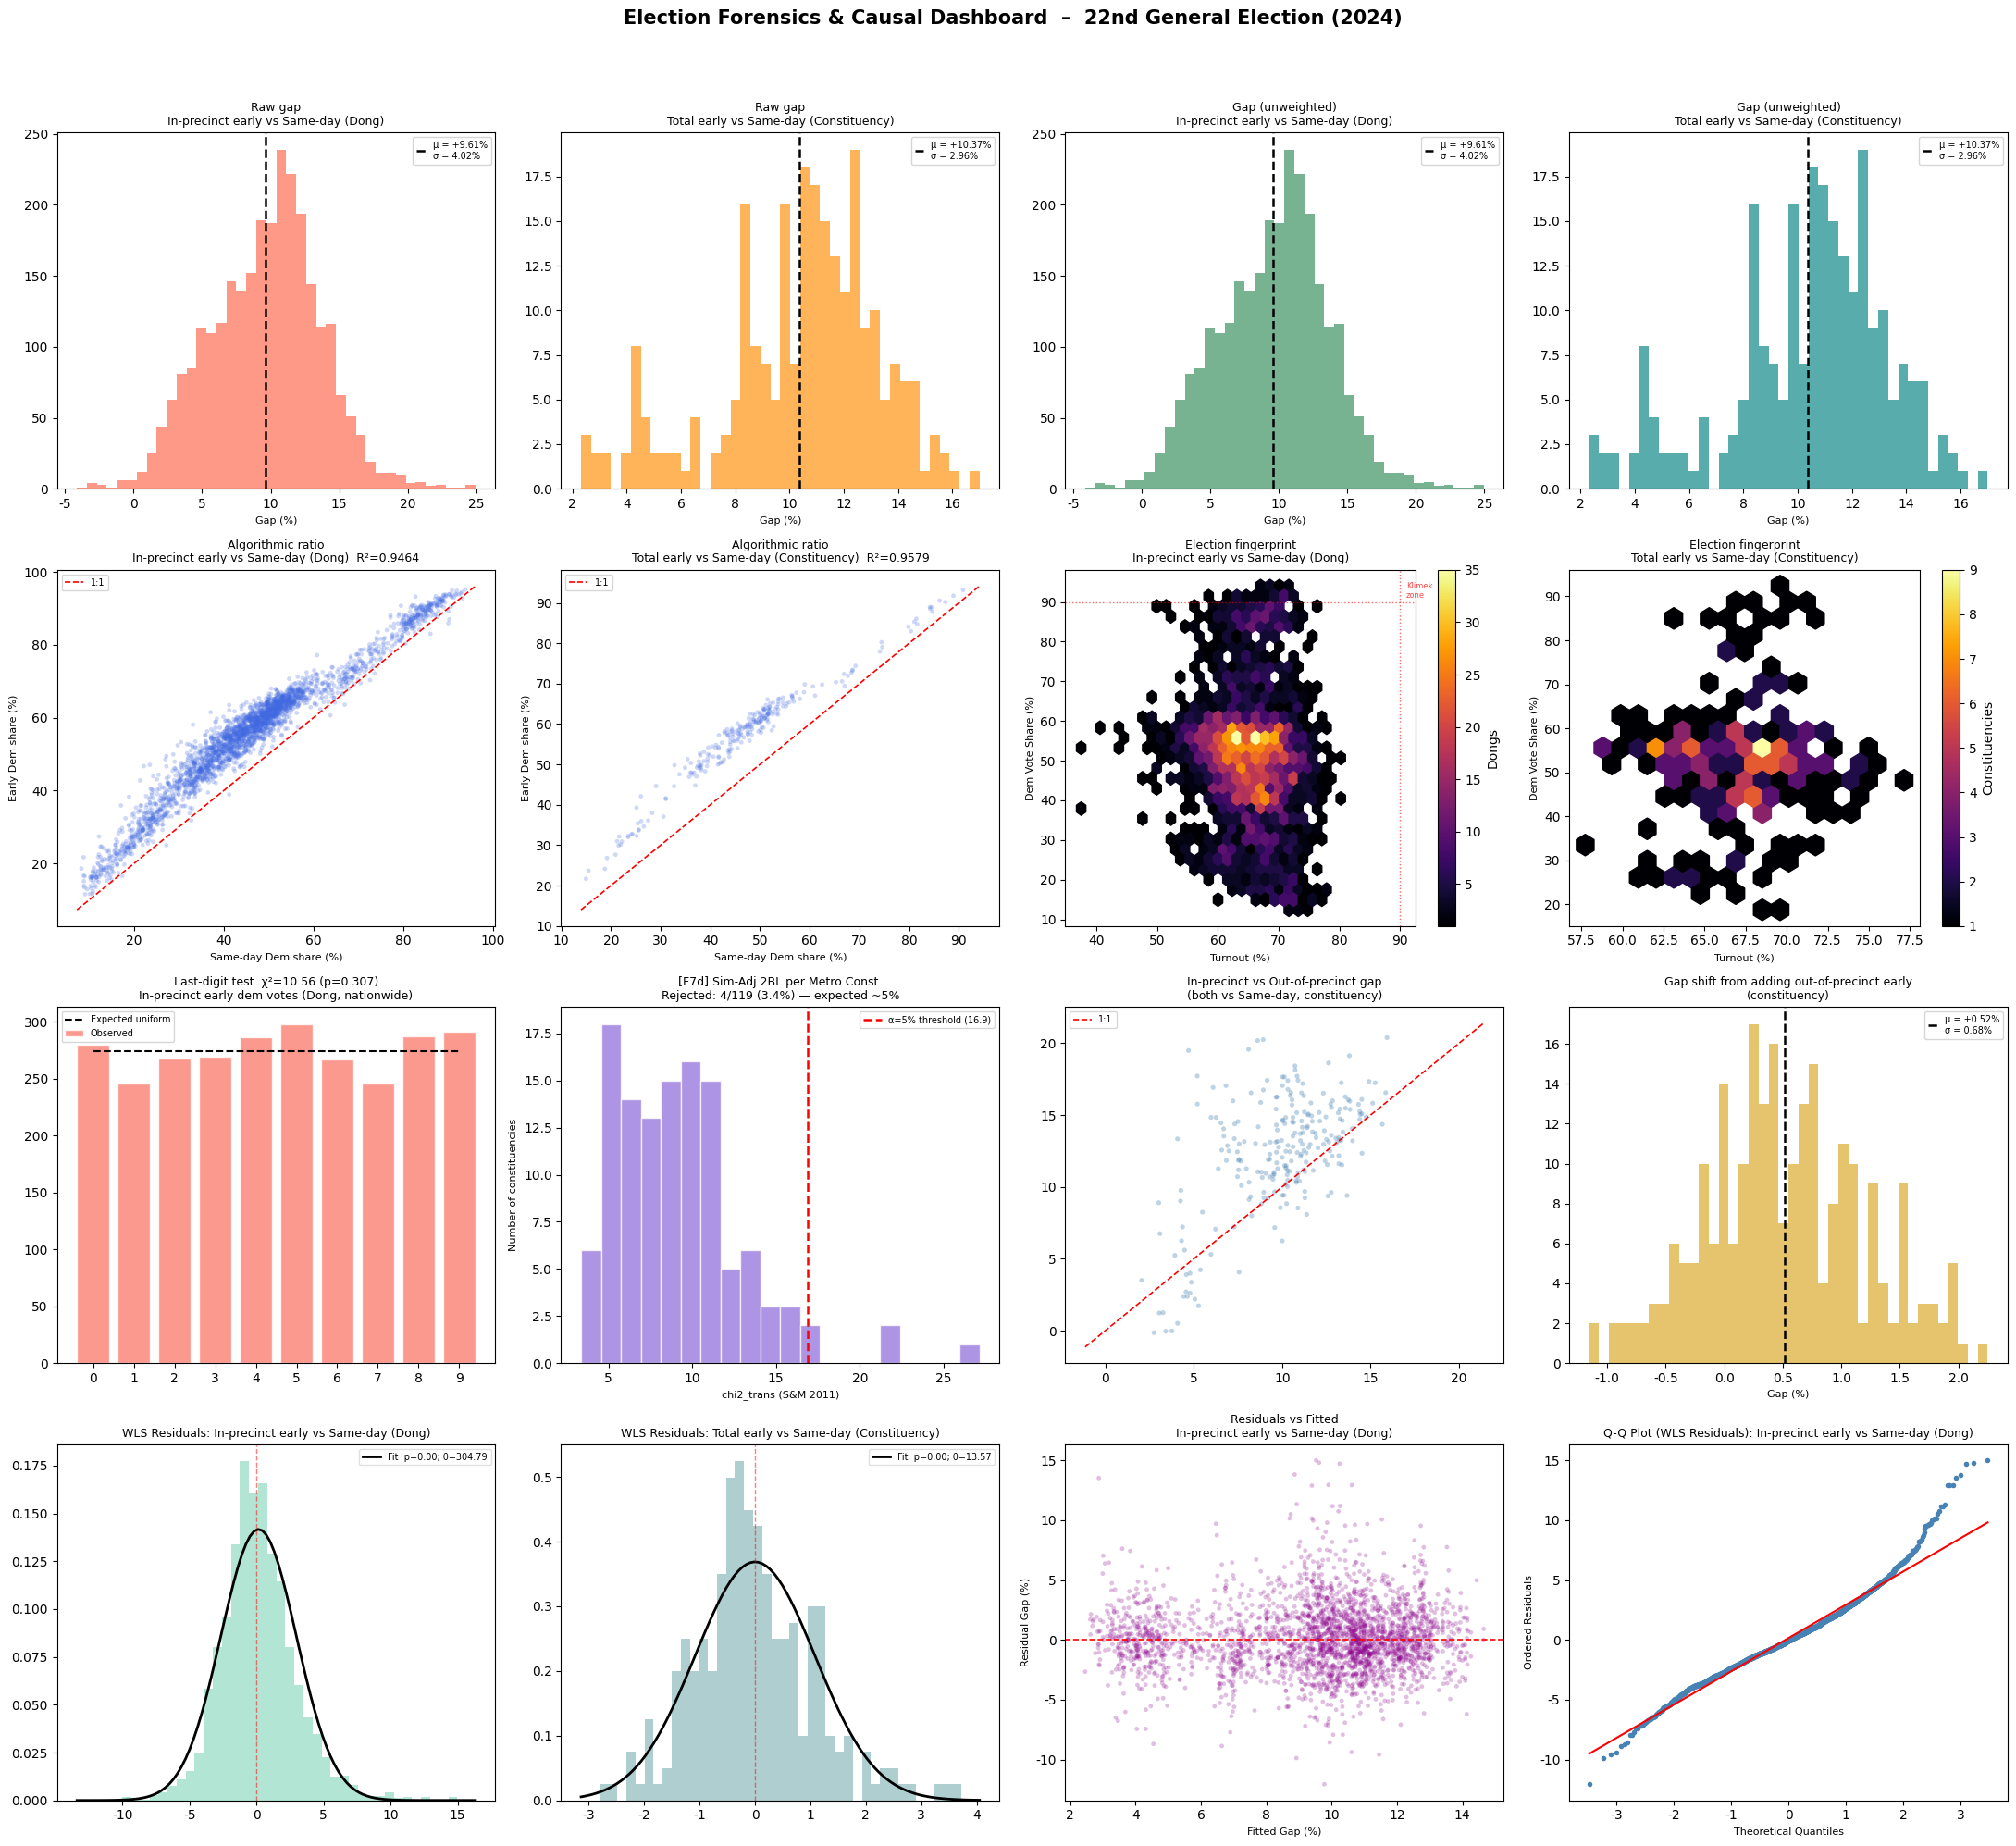

In [25]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import os
import re
import glob
from difflib import get_close_matches
from scipy.stats import (chisquare, pearsonr, norm, probplot, normaltest,
                          gaussian_kde, multivariate_t, ttest_1samp)
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# FONT SETUP
# ==========================================

def setup_font():
    """Configure matplotlib to render text properly."""
    matplotlib.rcParams['axes.unicode_minus'] = False

# ==========================================
# CONFIGURATION
# ==========================================

ELECTION_NUM = 22   # options: 21, 22, 'pres20', 'pres21'
EXCLUDE_HONAM_YEONGNAM = False

PCA_VARIANCE_THRESHOLD     = 0.95
DEMEAN_GROUP_COLS          = ['province_tag']  # Removed urban_type
MIN_COVERAGE               = 0.50

ELECTION_CONFIGS = {
    21: {
        'election_type':  'general',
        'census_csv':     '21st_election_census.csv',
        'result_csv':     '21st_election_result.csv',
        'apt_csv_glob':   '*21st_election_*_apt_price.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'미래통합당|자유한국당',
        'third_pattern':  None,
        'label':          '21st General Election (2020)',
        'year':           2020,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_21st.png',
    },
    22: {
        'election_type':  'general',
        'census_csv':     '22nd_election_census.csv',
        'result_csv':     '22nd_election_result.csv',
        'apt_csv_glob':   '*22nd_election_*_apt_price.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'국민의힘',
        'third_pattern':  None,
        'label':          '22nd General Election (2024)',
        'year':           2024,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_22nd.png',
    },
    'pres20': {
        'election_type':         'presidential',
        'census_csv':            '20th_presidential_election_census.csv',
        'result_csv':            '20th_presidential_election_result.csv',
        'apt_csv_glob':          '*20th_presidential_election_*_apt_prices.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         None,
        'label':                 '20th Presidential Election (2022)',
        'year':                  2022,
        'election_month':        3,
        'dashboard_out':         'mega_forensics_dashboard_pres20.png',
        'fallback_election_num': 21,
    },
    'pres21': {
        'election_type':         'presidential',
        'census_csv':            '21st_presidential_election_census.csv',
        'result_csv':            '21st_presidential_election_result.csv',
        'apt_csv_glob':          '*21st_presidential_election_*_apt_prices.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         r'이준석|개혁신당',
        'label':                 '21st Presidential Election (2025)',
        'year':                  2025,
        'election_month':        6,
        'dashboard_out':         'mega_forensics_dashboard_pres21.png',
        'fallback_election_num': 22,
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES_GENERAL = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES_PRESIDENTIAL = {
    '거소·선상투표', '관외사전투표', '재외투표',
    '잘못 투입·구분된 투표지',
}
GWANNAESA_LABEL = '관내사전투표'
GWANOE_LABEL    = '관외사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': 'Seoul',  '부산광역시': 'Busan',   '대구광역시': 'Daegu',
    '인천광역시': 'Incheon','광주광역시': 'Gwangju', '대전광역시': 'Daejeon',
    '울산광역시': 'Ulsan',  '세종특별자치시': 'Sejong',
    '경기도': 'Gyeonggi',  '강원도': 'Gangwon',     '강원특별자치도': 'Gangwon',
    '충청북도': 'Chungbuk', '충청남도': 'Chungnam',
    '전라북도': 'Jeonbuk',  '전북특별자치도': 'Jeonbuk', '전라남도': 'Jeonnam',
    '경상북도': 'Gyeongbuk','경상남도': 'Gyeongnam', '제주특별자치도': 'Jeju',
    # Abbreviated metro-city names used in employment CSV region column
    '서울': 'Seoul',   '부산': 'Busan',    '대구': 'Daegu',
    '인천': 'Incheon', '광주': 'Gwangju',  '대전': 'Daejeon',
    '울산': 'Ulsan',
}

# Maps standalone provincial city/county names (as they appear in employment CSVs,
# without a province prefix) to their English province tag.
SGG_TO_PROVINCE_EMP = {
    # Gyeonggi
    '가평군':'Gyeonggi','고양시':'Gyeonggi','과천시':'Gyeonggi','광명시':'Gyeonggi',
    '광주시':'Gyeonggi','구리시':'Gyeonggi','군포시':'Gyeonggi','김포시':'Gyeonggi',
    '남양주시':'Gyeonggi','동두천시':'Gyeonggi','부천시':'Gyeonggi','성남시':'Gyeonggi',
    '수원시':'Gyeonggi','시흥시':'Gyeonggi','안산시':'Gyeonggi','안성시':'Gyeonggi',
    '안양시':'Gyeonggi','양주시':'Gyeonggi','양평군':'Gyeonggi','여주군':'Gyeonggi',
    '여주시':'Gyeonggi','연천군':'Gyeonggi','오산시':'Gyeonggi','용인시':'Gyeonggi',
    '의왕시':'Gyeonggi','의정부시':'Gyeonggi','의정부시':'Gyeonggi','이천시':'Gyeonggi',
    '파주시':'Gyeonggi','평택시':'Gyeonggi','포천시':'Gyeonggi','하남시':'Gyeonggi',
    '화성시':'Gyeonggi',
    # Gangwon
    '강릉시':'Gangwon','고성군':'Gangwon','동해시':'Gangwon','삼척시':'Gangwon',
    '속초시':'Gangwon','양구군':'Gangwon','양양군':'Gangwon','영월군':'Gangwon',
    '원주시':'Gangwon','인제군':'Gangwon','정선군':'Gangwon','철원군':'Gangwon',
    '춘천시':'Gangwon','태백시':'Gangwon','평창군':'Gangwon','홍천군':'Gangwon',
    '화천군':'Gangwon','횡성군':'Gangwon',
    # Chungbuk
    '괴산군':'Chungbuk','단양군':'Chungbuk','보은군':'Chungbuk','영동군':'Chungbuk',
    '옥천군':'Chungbuk','음성군':'Chungbuk','제천시':'Chungbuk','증평군':'Chungbuk',
    '진천군':'Chungbuk','청원군':'Chungbuk','청주시':'Chungbuk','충주시':'Chungbuk',
    # Chungnam
    '계룡시':'Chungnam','공주시':'Chungnam','금산군':'Chungnam','논산시':'Chungnam',
    '당진시':'Chungnam','보령시':'Chungnam','부여군':'Chungnam','서산시':'Chungnam',
    '서천군':'Chungnam','아산시':'Chungnam','연기군':'Chungnam','예산군':'Chungnam',
    '청양군':'Chungnam','천안시':'Chungnam','태안군':'Chungnam','홍성군':'Chungnam',
    # Jeonbuk
    '고창군':'Jeonbuk','군산시':'Jeonbuk','김제시':'Jeonbuk','남원시':'Jeonbuk',
    '무주군':'Jeonbuk','부안군':'Jeonbuk','순창군':'Jeonbuk','완주군':'Jeonbuk',
    '익산시':'Jeonbuk','임실군':'Jeonbuk','장수군':'Jeonbuk','전주시':'Jeonbuk',
    '정읍시':'Jeonbuk','진안군':'Jeonbuk',
    # Jeonnam
    '강진군':'Jeonnam','고흥군':'Jeonnam','곡성군':'Jeonnam','구례군':'Jeonnam',
    '나주시':'Jeonnam','담양군':'Jeonnam','목포시':'Jeonnam','무안군':'Jeonnam',
    '보성군':'Jeonnam','순천시':'Jeonnam','신안군':'Jeonnam','여수시':'Jeonnam',
    '영광군':'Jeonnam','영암군':'Jeonnam','완도군':'Jeonnam','장성군':'Jeonnam',
    '장흥군':'Jeonnam','진도군':'Jeonnam','함평군':'Jeonnam','화순군':'Jeonnam',
    '광양시':'Jeonnam','해남군':'Jeonnam',
    # Gyeongbuk
    '경산시':'Gyeongbuk','경주시':'Gyeongbuk','고령군':'Gyeongbuk','구미시':'Gyeongbuk',
    '김천시':'Gyeongbuk','문경시':'Gyeongbuk','봉화군':'Gyeongbuk','상주시':'Gyeongbuk',
    '성주군':'Gyeongbuk','안동시':'Gyeongbuk','영덕군':'Gyeongbuk','영양군':'Gyeongbuk',
    '영주시':'Gyeongbuk','영천시':'Gyeongbuk','예천군':'Gyeongbuk','울릉군':'Gyeongbuk',
    '울진군':'Gyeongbuk','의성군':'Gyeongbuk','청도군':'Gyeongbuk','청송군':'Gyeongbuk',
    '칠곡군':'Gyeongbuk','포항시':'Gyeongbuk',
    # Gyeongnam
    '거제시':'Gyeongnam','거창군':'Gyeongnam','김해시':'Gyeongnam','남해군':'Gyeongnam',
    '밀양시':'Gyeongnam','사천시':'Gyeongnam','산청군':'Gyeongnam','양산시':'Gyeongnam',
    '의령군':'Gyeongnam','진주시':'Gyeongnam','창녕군':'Gyeongnam','창원시':'Gyeongnam',
    '통영시':'Gyeongnam','하동군':'Gyeongnam','함안군':'Gyeongnam','함양군':'Gyeongnam',
    '합천군':'Gyeongnam',
    # Jeju
    '서귀포시':'Jeju','제주시':'Jeju',
}

PARTISAN_REGION_PROVINCES = {
    'Honam':   {'Jeonnam', 'Jeonbuk', 'Gwangju', '전남', '전북', '광주'},
    'Yeongnam':{'Gyeongbuk', 'Gyeongnam', 'Daegu', 'Busan', 'Ulsan',
                '경북', '경남', '대구', '부산', '울산'},
}

AGE_GENDER_COLS = [
    'pct_m_1824', 'pct_m_2529', 'pct_m_3034', 'pct_m_3539', 'pct_m_4044', 'pct_m_4549',
    'pct_m_5054', 'pct_m_5559', 'pct_m_6064', 'pct_m_6569', 'pct_m_70plus',
    'pct_f_1824', 'pct_f_2529', 'pct_f_3034', 'pct_f_3539', 'pct_f_4044', 'pct_f_4549',
    'pct_f_5054', 'pct_f_5559', 'pct_f_6064', 'pct_f_6569', 'pct_f_70plus',
]

EMPLOYMENT_FEATURE_COLS = [
    'emp_men_total', 'emp_men_1529', 'emp_men_3049', 'emp_men_5064', 'emp_men_65plus',
    'emp_wmn_total', 'emp_wmn_1529', 'emp_wmn_3049', 'emp_wmn_5064', 'emp_wmn_65plus',
    'occ_wage_share', 'occ_regular_share', 'occ_nonwage_share',
    'job_professional', 'job_clerical', 'job_service_sales',
    'job_skilled_machine', 'job_simple_labor', 'job_farming',
    'ind_agriculture', 'ind_manufacturing', 'ind_construction',
    'ind_retail_food', 'ind_transport_finance', 'ind_services',
    'nonp_male_share', 'nonp_young_share', 'nonp_middle_share', 'nonp_old_share',
]

# ==========================================
# SHARED NORMALISATION & IO UTILITIES
# ==========================================

def _read_csv_auto(path: str, **kwargs) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8', **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp949', **kwargs)

def _to_numeric_safe(series: pd.Series) -> pd.Series:
    return (series.astype(str).str.strip()
            .replace(['-', '.', '', 'nan'], np.nan)
            .pipe(pd.to_numeric, errors='coerce'))

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구'  and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates

def get_election_periods(month: int, year: int) -> dict:
    if month <= 6:
        prev = year - 1
        return {'half_periods': [f'{prev}.1/2', f'{prev}.2/2'], 'grdp_year': prev}
    else:
        prev = year - 1
        return {'half_periods': [f'{prev}.2/2', f'{year}.1/2'], 'grdp_year': prev}

def parse_employment_sgg(region_name: str) -> tuple:
    if not isinstance(region_name, str): return ('', '')
    parts = region_name.strip().split(None, 1)
    if not parts: return ('', '')
    prov = parts[0]
    if len(parts) == 1:
        prov_eng = SGG_TO_PROVINCE_EMP.get(prov, '')
        primary  = re.sub(r'[시군구]$', '', prov).strip()
        return (prov_eng, primary)
    sgg_raw  = parts[1]
    sgg_norm = normalize_sigungu(sgg_raw)
    primary  = sgg_norm[0] if sgg_norm else re.sub(r'[시군구]$', '', sgg_raw).strip()
    prov_eng = PROV_FULL_TO_SHORT.get(prov, prov)
    return (prov_eng, primary)

# ==========================================
# 1. DEMOGRAPHIC & ASSET DATA LOADERS
# ==========================================

def _detect_year_prefix(df: pd.DataFrame) -> str:
    for col in df.columns:
        m = re.match(r'(\d{4}년\d{2}월)_계_총인구수', col)
        if m: return m.group(1)
    raise ValueError("Cannot detect census year prefix.")

def load_census_csv(csv_path: str) -> pd.DataFrame:
    print(f"\n--- [1/6] Loading Demographic Census Data ---")
    if not csv_path or not os.path.exists(csv_path): return pd.DataFrame()
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
        prefix = _detect_year_prefix(df)
        voting_age_cols = ([f"{prefix}_계_{a}세" for a in range(18, 100)]
                           + [f"{prefix}_계_100세 이상"])
        cols_4059 = [f"{prefix}_계_{a}세" for a in range(40, 60)]

        all_target_cols = list(voting_age_cols)
        for g in ['남', '여']:
            for a in range(18, 100):
                all_target_cols.append(f"{prefix}_{g}_{a}세")
            all_target_cols.append(f"{prefix}_{g}_100세 이상")

        for col in set(all_target_cols):
            if col in df.columns:
                df[col] = (df[col].astype(str).str.replace(',', '', regex=False)
                           .pipe(pd.to_numeric, errors='coerce').fillna(0))

        df = df.copy()
        df['total_voting_pop'] = df[[c for c in voting_age_cols if c in df.columns]].sum(axis=1)
        df = df[df['total_voting_pop'] > 0].copy()

        ranges = [(18,25,'1824'),(25,30,'2529'),(30,35,'3034'),(35,40,'3539'),
                  (40,45,'4044'),(45,50,'4549'),(50,55,'5054'),(55,60,'5559'),
                  (60,65,'6064'),(65,70,'6569')]

        for g, g_str in [('남','m'), ('여','f')]:
            for r_start, r_end, r_str in ranges:
                cols = [f"{prefix}_{g}_{a}세" for a in range(r_start, r_end)]
                df[f'pct_{g_str}_{r_str}'] = (df[[c for c in cols if c in df.columns]].sum(axis=1)
                                               / df['total_voting_pop'])
            cols_70 = ([f"{prefix}_{g}_{a}세" for a in range(70, 100)]
                       + [f"{prefix}_{g}_100세 이상"])
            df[f'pct_{g_str}_70plus'] = (df[[c for c in cols_70 if c in df.columns]].sum(axis=1)
                                          / df['total_voting_pop'])

        df['demographic_propensity'] = (df[[c for c in cols_4059 if c in df.columns]].sum(axis=1)
                                         / df['total_voting_pop'])

        def extract_census_keys(admin_name):
            if not isinstance(admin_name, str): return [], ""
            clean = re.sub(r'\(.*?\)', '', admin_name).strip()
            parts = clean.split()
            dong_norm = normalize_dong_name(parts[-1]) if parts else ""
            sgg_cands = []
            for token in reversed(parts[:-1]):
                for c in normalize_sigungu(token):
                    if c not in sgg_cands: sgg_cands.append(c)
            return sgg_cands, dong_norm

        rows = []
        for _, row in df.iterrows():
            sgg_cands, dong_norm = extract_census_keys(row['행정구역'])
            row_dict = {
                'sgg_candidates': sgg_cands,
                'primary_sgg':    sgg_cands[0] if sgg_cands else "",
                'dong_norm':      dong_norm,
                'dong_raw':       row['행정구역'],
                'demographic_propensity': row['demographic_propensity'],
            }
            for col in AGE_GENDER_COLS:
                row_dict[col] = row.get(col, np.nan)
            rows.append(row_dict)

        census = pd.DataFrame(rows)
        print(f"    Loaded {len(census):,} census rows with 22 Age-Gender cohorts.")
        return census
    except Exception as e:
        print(f"[!] Error processing census CSV: {e}")
        return pd.DataFrame()

def load_apt_csv(glob_pattern: str) -> pd.DataFrame:
    print(f"\n--- [2/6] Loading Apartment Transaction Data ---")
    if not glob_pattern: return pd.DataFrame()
    file_list = glob.glob(glob_pattern)
    if not file_list: return pd.DataFrame()

    df_list = []
    for file in file_list:
        try:
            df_list.append(_read_csv_auto(file, skiprows=15))
        except Exception:
            pass
    if not df_list: return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    try:
        df['거래금액(만원)'] = pd.to_numeric(
            df['거래금액(만원)'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
        df['전용면적(㎡)']   = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')
        df['price_per_sqm']  = df['거래금액(만원)'] / df['전용면적(㎡)']

        def parse_loc(x):
            parts = str(x).split()
            prov  = PROV_FULL_TO_SHORT.get(parts[0], parts[0]) if parts else ""
            sgg   = normalize_sigungu(parts[1])[0] if len(parts) > 2 and normalize_sigungu(parts[1]) else ""
            dong  = normalize_dong_name(parts[-1]) if parts else ""
            return pd.Series([prov, sgg, dong])

        df[['prov','sgg','dong_norm']] = df['시군구'].apply(parse_loc)

        # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
        mask_seoul = df['prov'] == 'Seoul'
        mask_g3 = df['sgg'].isin(['강남', '서초', '송파'])
        df.loc[mask_seoul & mask_g3, 'prov'] = 'Seoul (Gangnam3gu)'
        df.loc[mask_seoul & ~mask_g3, 'prov'] = 'Seoul (Non-Gangnam3gu)'

        apt_agg = (df.groupby(['prov','sgg','dong_norm'])['price_per_sqm']
                   .median().reset_index()
                   .rename(columns={'price_per_sqm': 'median_apt_price_sqm'}))
        print(f"    Calculated stable median prices for {len(apt_agg):,} unique Dongs.")
        return apt_agg
    except Exception as e:
        print(f"[!] Error processing concatenated APT data: {e}")
        return pd.DataFrame()

def _avg_half_periods(df: pd.DataFrame, base_cols: list) -> pd.Series:
    available = [c for c in base_cols if c in df.columns]
    if not available: return pd.Series(np.nan, index=df.index)
    return df[available].apply(pd.to_numeric, errors='coerce').mean(axis=1)

def load_employment_sgg(election_key: str, **kwargs) -> pd.DataFrame:
    print(f"\n--- [3/6] Loading Employment Covariates ---")
    cfg    = ELECTION_CONFIGS[election_key]
    month  = cfg['election_month']
    year   = cfg['year']
    periods_info = get_election_periods(month, year)
    periods      = periods_info['half_periods']

    def read_emp(path):
        if not os.path.exists(path): return pd.DataFrame()
        df = _read_csv_auto(path, low_memory=False)
        return df[[c for c in df.columns if not str(c).startswith('Unnamed')]]

    age_map = {'total':'계','1529':'15 - 29세','3049':'30 - 49세',
               '5064':'50 - 64세','65plus':'65세이상'}

    def extract_gender_emp(csv_path, gender_prefix):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df_rate = df[df['항목'].str.strip() == '고용률 (%)'].copy()
        records = {}
        for suf, kor_age in age_map.items():
            sub = df_rate[df_rate['연령별'].str.strip() == kor_age].copy()
            if sub.empty: continue
            val_col = f'{gender_prefix}_{suf}'
            sub[val_col] = _avg_half_periods(sub, periods)
            prov_sgg = sub['행정구역별'].apply(parse_employment_sgg)
            sub['province_tag'] = prov_sgg.apply(lambda x: x[0])
            sub['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
            records[val_col] = sub.groupby(['province_tag','primary_sgg'])[val_col].mean()
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_men = extract_gender_emp(kwargs.get('men_csv',   'men_employment_data.csv'),   'emp_men')
    df_wmn = extract_gender_emp(kwargs.get('women_csv', 'women_employment_data.csv'), 'emp_wmn')

    occ_type_map = {'occ_wage_share':'임금근로자',
                    'occ_regular_share':'- 상용근로자',
                    'occ_nonwage_share':'비임금근로자'}

    def extract_occ_type(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df_total = df[df['종사상지위별'].str.strip() == '계'].copy()
        df_total['_total'] = _avg_half_periods(df_total, periods)
        prov_sgg = df_total['행정구역별'].apply(parse_employment_sgg)
        df_total['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df_total['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df_total.set_index(['province_tag','primary_sgg'])['_total']
        records = {}
        for col_name, kor_cat in occ_type_map.items():
            sub = df[df['종사상지위별'].str.strip() == kor_cat].copy()
            if sub.empty: continue
            sub['_val'] = _avg_half_periods(sub, periods)
            prov_sgg2 = sub['행정구역별'].apply(parse_employment_sgg)
            sub['province_tag'] = prov_sgg2.apply(lambda x: x[0])
            sub['primary_sgg']  = prov_sgg2.apply(lambda x: x[1])
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_occ_type = extract_occ_type(kwargs.get('occ_type_csv', 'occupation_type_employment_data.csv'))

    job_map = {
        'job_professional':   '관리자, 전문가 및 관련종사자',
        'job_clerical':       '사무 종사자',
        'job_service_sales':  '서비스·판매 종사자',
        'job_skilled_machine':'기능·기계조작·조립 종사자',
        'job_simple_labor':   '단순노무 종사자',
        'job_farming':        '농림어업 숙련종사자',
    }

    def extract_job_shares(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df[df['항목'].str.strip() == '취업자[천명]'].copy()
        df['_val'] = _avg_half_periods(df, periods)
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df[df['직업별'].str.strip() == '계'].set_index(['province_tag','primary_sgg'])['_val']
        records = {}
        for col_name, kor_cat in job_map.items():
            sub = df[df['직업별'].str.strip() == kor_cat].copy()
            if sub.empty: continue
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_job = extract_job_shares(kwargs.get('occ_csv', 'occupation_employment_data.csv'))

    ind_map = {
        'ind_agriculture':        '농업, 임업 및 어업 (A)',
        'ind_manufacturing':      '광·제조업(B,C)',
        'ind_construction':       '건설업 (F) ',
        'ind_retail_food':        '도소매·숙박음식업(G,I)',
        'ind_transport_finance':  '전기·운수·통신·금융(D,H,J,K)',
        'ind_services':           '사업·개인·공공서비스 및 기타(E,L~U)',
    }

    def extract_ind_shares(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df[df['항목'].str.strip() == '취업자[천명]'].copy()
        df['_val'] = _avg_half_periods(df, periods)
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        total_map = df[df['산업별'].str.strip() == '계'].set_index(['province_tag','primary_sgg'])['_val']
        records = {}
        for col_name, kor_cat in ind_map.items():
            sub = df[df['산업별'].str.strip() == kor_cat.strip()].copy()
            if sub.empty:
                match = get_close_matches(kor_cat.strip(),
                                          df['산업별'].str.strip().unique().tolist(), n=1, cutoff=0.85)
                if match: sub = df[df['산업별'].str.strip() == match[0]].copy()
            if sub.empty: continue
            records[col_name] = sub.set_index(['province_tag','primary_sgg'])['_val'] / total_map
        if not records: return pd.DataFrame()
        return pd.concat(records, axis=1).reset_index()

    df_ind = extract_ind_shares(kwargs.get('ind_csv', 'industry_employment_data.csv'))

    def extract_nonpart(csv_path):
        df = read_emp(csv_path)
        if df.empty: return pd.DataFrame()
        df = df.iloc[1:].copy()
        prov_sgg = df['행정구역별'].apply(parse_employment_sgg)
        df['province_tag'] = prov_sgg.apply(lambda x: x[0])
        df['primary_sgg']  = prov_sgg.apply(lambda x: x[1])
        sub_suffixes = {'total':'', 'male':'.1', 'young':'.3', 'middle':'.4'}
        period_vals  = {k: [] for k in sub_suffixes}
        for period in periods:
            for k, suf in sub_suffixes.items():
                if period + suf in df.columns:
                    period_vals[k].append(_to_numeric_safe(df[period + suf]))
        def mean_series(lst):
            return pd.concat(lst, axis=1).mean(axis=1) if lst else pd.Series(np.nan, index=df.index)
        total  = mean_series(period_vals['total'])
        result = df[['province_tag','primary_sgg']].copy()
        result['nonp_male_share']   = mean_series(period_vals['male'])   / total.replace(0, np.nan)
        result['nonp_young_share']  = mean_series(period_vals['young'])  / total.replace(0, np.nan)
        result['nonp_middle_share'] = mean_series(period_vals['middle']) / total.replace(0, np.nan)
        return (result.groupby(['province_tag','primary_sgg'])
                [['nonp_male_share','nonp_young_share','nonp_middle_share']]
                .mean().reset_index())

    df_nonp = extract_nonpart(kwargs.get('nonp_csv', 'non_participant_employment_data.csv'))

    merge_key = ['province_tag','primary_sgg']
    frames = [f for f in [df_men, df_wmn, df_occ_type, df_job, df_ind, df_nonp] if not f.empty]
    if not frames: return pd.DataFrame(columns=merge_key + EMPLOYMENT_FEATURE_COLS)

    df_emp = frames[0]
    for frame in frames[1:]:
        df_emp = df_emp.merge(frame, on=merge_key, how='outer')
    for col in EMPLOYMENT_FEATURE_COLS:
        if col not in df_emp.columns: df_emp[col] = np.nan

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    if not df_emp.empty:
        mask_seoul = df_emp['province_tag'] == 'Seoul'
        mask_g3 = df_emp['primary_sgg'].isin(['강남', '서초', '송파'])
        df_emp.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
        df_emp.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    return df_emp

# ==========================================
# 2. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str,
                      third_pattern: str = None, election_type: str = 'general'):
    print(f"\n--- [4/6] Loading Election Result Data ({csv_path}, type={election_type}) ---")
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if election_type == 'presidential':
        df = df.rename(columns={'구시군명': '선거구명', '읍면동명': '법정읍면동명'})
        special_dong_names = SPECIAL_DONG_NAMES_PRESIDENTIAL
    else:
        special_dong_names = SPECIAL_DONG_NAMES_GENERAL

    df['득표수']    = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']   = df['후보자'].str.contains(dem_pattern,   case=False, na=False)
    df['is_con']   = df['후보자'].str.contains(con_pattern,   case=False, na=False)
    df['is_third'] = df['후보자'].str.contains(third_pattern, case=False, na=False) if third_pattern else False
    df['is_meta']  = df['후보자'].isin(META_CANDIDATES)
    df['is_early'] = df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명','선거구명','법정읍면동명']
    const_key = ['시도명','선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(special_dong_names)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot = df_votes[df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    sd_dem = df_votes[df_votes['is_dem']  & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')
    gn_th  = df_votes[df_votes['is_third'] & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_third')
    sd_th  = df_votes[df_votes['is_third'] & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_third')

    sum_people_dong = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_people'))
    sum_vote_geo    = (df_geo[df_geo['후보자'] == '투표수']
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo'))

    df_dong = gn_dem.copy()
    for frame in (gn_tot, gn_con, gn_th, sd_dem, sd_tot, sd_th,
                  sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    gn_ppl_dong = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                   .groupby(dong_key)['득표수'].sum().reset_index(name='_gn_ppl'))
    df_dong = df_dong.merge(gn_ppl_dong, on=dong_key, how='left')
    df_dong['sum_people'] = df_dong['sum_people'] + df_dong['_gn_ppl'].fillna(0)
    df_dong.drop(columns=['_gn_ppl'], inplace=True)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul = df_dong['province_tag'] == 'Seoul'
    mask_g3 = df_dong['primary_sgg'].isin(['강남', '서초', '송파'])
    df_dong.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_dong.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    # ── Constituency-level aggregates ──
    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot_c  = df_votes[df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con_c  = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    gn_turn_c = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_turnout'))

    df_gw   = df[df['법정읍면동명'] == GWANOE_LABEL]
    df_gw_v = df_gw[~df_gw['is_meta']]

    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_total')
    go_th_c   = df_gw_v[df_gw_v['is_third']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_third')
    go_turn_c = (df_gw[df_gw['후보자'] == '투표수']
                 .groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_turnout'))

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout'))

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')
    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_con_c, gn_turn_c,
                  go_dem_c, go_tot_c, go_turn_c, go_th_c,
                  sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['early_total_dem']     = df_const['in_precinct_early_dem']     + df_const['out_precinct_early_dem']
    df_const['early_total_total']   = df_const['in_precinct_early_total']   + df_const['out_precinct_early_total']
    df_const['early_total_turnout'] = df_const['in_precinct_early_turnout'] + df_const['out_precinct_early_turnout']
    df_const['total_turnout']       = df_const['early_total_turnout'] + df_const['same_day_turnout']

    go_ppl_c = (df_gw[df_gw['후보자'] == '선거인수']
                .groupby(const_key)['득표수'].sum().reset_index(name='_go_ppl'))
    df_const = df_const.merge(go_ppl_c, on=const_key, how='left')
    df_const['sum_people'] = df_const['sum_people'] + df_const['_go_ppl'].fillna(0)
    df_const.drop(columns=['_go_ppl'], inplace=True)

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_c = df_const['province_tag'] == 'Seoul'
    mask_g3_c = df_const['primary_sgg'].isin(['강남', '서초', '송파'])
    df_const.loc[mask_seoul_c & mask_g3_c, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_const.loc[mask_seoul_c & ~mask_g3_c, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    sk = ['시도명','선거구명','법정읍면동명','투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c):
        df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early_flag'] = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['province_tag']  = df_station['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_station['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_s = df_station['province_tag'] == 'Seoul'
    mask_g3_s = df_station['선거구명'].apply(lambda x: any(g in str(x) for g in ['강남', '서초', '송파']))
    df_station.loc[mask_seoul_s & mask_g3_s, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_station.loc[mask_seoul_s & ~mask_g3_s, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    df_station['region']        = df_station['province_tag'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']  = df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan)

    return df_dong, df_const, df_station

# ==========================================
# 3. MULTI-PASS DONG↔CENSUS↔APT↔EMP MATCHER
# ==========================================

def merge_dong_with_covariates(df_election: pd.DataFrame, df_census: pd.DataFrame,
                                df_apt: pd.DataFrame, df_emp: pd.DataFrame) -> pd.DataFrame:
    if not df_census.empty:
        census_lookup = {}
        census_by_sgg = {}
        for _, row in df_census.iterrows():
            dnorm = row['dong_norm']
            covs  = {'demographic_propensity': row['demographic_propensity']}
            for c in AGE_GENDER_COLS: covs[c] = row.get(c, np.nan)
            for sgg in row['sgg_candidates']:
                census_lookup[(sgg, dnorm)] = covs
                census_by_sgg.setdefault(sgg, []).append(dnorm)

        results = []
        for _, row in df_election.iterrows():
            covs = None
            dk   = row['dong_norm']
            sgc  = row['sgg_candidates'] if isinstance(row['sgg_candidates'], list) else [row['primary_sgg']]
            if (row['primary_sgg'], dk) in census_lookup:
                covs = census_lookup[(row['primary_sgg'], dk)]
            if covs is None and '·' in dk:
                k1b = (row['primary_sgg'], dk.replace('·', ''))
                if k1b in census_lookup: covs = census_lookup[k1b]
            if covs is None:
                for sgg in sgc[1:]:
                    if (sgg, dk) in census_lookup: covs = census_lookup[(sgg, dk)]; break
            if covs is None:
                for sgg in sgc:
                    pool = census_by_sgg.get(sgg, [])
                    if pool:
                        m = get_close_matches(dk, pool, n=1, cutoff=0.82)
                        if m and (sgg, m[0]) in census_lookup:
                            covs = census_lookup[(sgg, m[0])]; break
            if covs is None:
                covs = {k: np.nan for k in ['demographic_propensity'] + AGE_GENDER_COLS}
            rd = row.to_dict(); rd.update(covs)
            results.append(rd)
        df_out = pd.DataFrame(results)
    else:
        df_out = df_election.copy()

    if not df_apt.empty:
        df_out = df_out.merge(df_apt,
                              left_on=['province_tag','primary_sgg','dong_norm'],
                              right_on=['prov','sgg','dong_norm'], how='left')
        sgg_med  = df_out.groupby('primary_sgg')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(sgg_med)
        prov_med = df_out.groupby('province_tag')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(prov_med)
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(df_out['median_apt_price_sqm'].median())
        df_out['log_apt_price'] = np.log1p(df_out['median_apt_price_sqm'])
    else:
        df_out['log_apt_price'] = 0.0

    if not df_emp.empty:
        df_out = df_out.merge(df_emp[['province_tag','primary_sgg'] + EMPLOYMENT_FEATURE_COLS],
                              on=['province_tag','primary_sgg'], how='left')
        for col in EMPLOYMENT_FEATURE_COLS:
            if col not in df_out.columns: df_out[col] = np.nan
            prov_med = df_out.groupby('province_tag')[col].transform('median')
            df_out[col] = df_out[col].fillna(prov_med)
            df_out[col] = df_out[col].fillna(df_out[col].median())
    else:
        for col in EMPLOYMENT_FEATURE_COLS: df_out[col] = np.nan

    return df_out[df_out['pct_f_4044'].notna()].copy()


def merge_const_with_covariates(df_const: pd.DataFrame,
                                 df_dong_merged: pd.DataFrame) -> pd.DataFrame:
    """
    Population-weighted aggregation of dong-level census + apt covariates up to
    constituency level, for use in constituency-level forensics.
    """
    if df_dong_merged.empty or 'pct_f_4044' not in df_dong_merged.columns:
        return df_const.copy()

    const_key = ['시도명','선거구명']
    dm = df_dong_merged.dropna(subset=['pct_f_4044']).copy()

    agg_funcs = {'_reg': ('sum_people','sum')}
    for col in AGE_GENDER_COLS:
        dm[f'_pw_{col}'] = dm[col] * dm['sum_people']
        agg_funcs[f'_pw_{col}_sum'] = (f'_pw_{col}','sum')

    out_cols = list(AGE_GENDER_COLS)
    if 'log_apt_price' in dm.columns:
        dm['_pw_log_apt_price'] = dm['log_apt_price'] * dm['sum_people']
        agg_funcs['_pw_log_apt_price_sum'] = ('_pw_log_apt_price','sum')

    agg = dm.groupby(const_key).agg(**agg_funcs).reset_index()

    for col in AGE_GENDER_COLS:
        agg[col] = agg[f'_pw_{col}_sum'] / agg['_reg'].replace(0, np.nan)
    if 'log_apt_price' in dm.columns:
        agg['log_apt_price'] = agg['_pw_log_apt_price_sum'] / agg['_reg'].replace(0, np.nan)
        out_cols.append('log_apt_price')

    return df_const.merge(agg[const_key + out_cols], on=const_key, how='left')

# ==========================================
# 4. GLOBAL PCA COLLINEARITY PIPELINE
# ==========================================

def compute_vif(df: pd.DataFrame, cols: list, label: str = "") -> pd.DataFrame:
    available = [c for c in cols if c in df.columns]
    X = df[available].dropna()
    if X.shape[0] < X.shape[1] + 5: return pd.DataFrame()
    records = []
    for i, col in enumerate(available):
        try:    vif = variance_inflation_factor(X.values.astype(float), i)
        except: vif = np.nan
        records.append({'feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(records).sort_values('VIF', ascending=False)

def _drop_zero_variance_cols(df: pd.DataFrame, cols: list) -> list:
    kept = []
    for col in cols:
        if col not in df.columns: continue
        std = df[col].std(skipna=True)
        if not (pd.isna(std) or std < 1e-10): kept.append(col)
    return kept

def reduce_global_pca(df: pd.DataFrame, feature_cols: list, threshold: float) -> tuple:
    """
    Applies standard scaling to all provided valid feature columns (Demographics,
    Employment, Wealth) simultaneously and extracts perfectly orthogonal Global PCs.
    """
    available = [c for c in feature_cols if c in df.columns and df[c].notna().mean() >= MIN_COVERAGE]
    if len(available) < 2:
        return df.copy(), [], None, available

    valid_mask = df[available].notna().all(axis=1)
    if valid_mask.sum() < 30:
        return df.copy(), [], None, available

    X = df.loc[valid_mask, available].values.astype(float)
    X_scaled = StandardScaler().fit_transform(X)

    pca_probe = PCA().fit(X_scaled)
    cumvar = np.cumsum(pca_probe.explained_variance_ratio_)
    n_components = min(int(np.searchsorted(cumvar, threshold)) + 1, len(available))

    pca_final = PCA(n_components=n_components)
    components = pca_final.fit_transform(X_scaled)

    pc_cols = [f'global_pc{i+1}' for i in range(n_components)]
    df_out = df.copy()
    for col in pc_cols:
        df_out[col] = np.nan
    df_out.loc[valid_mask, pc_cols] = components

    return df_out, pc_cols, pca_final, available

def demean_continuous_within_groups(df: pd.DataFrame, cont_cols: list) -> tuple:
    df_out = df.copy()
    dm_cols   = []
    available = [c for c in cont_cols if c in df_out.columns]
    active_groups = [g for g in DEMEAN_GROUP_COLS if g in df_out.columns]
    for col in available:
        gm     = df_out.groupby(active_groups)[col].transform('mean')
        dm_col = f'{col}_dm'
        df_out[dm_col] = df_out[col] - gm
        dm_cols.append(dm_col)
    return df_out, dm_cols

def prepare_continuous_covariates(df: pd.DataFrame, raw_age_cols: list,
                                   raw_emp_cols: list, label: str = "") -> tuple:
    combined_raw = list(raw_age_cols) + list(raw_emp_cols)
    if 'log_apt_price' in df.columns:
        combined_raw.append('log_apt_price')

    df, pc_cols, pca_model, used_features = reduce_global_pca(df, combined_raw, PCA_VARIANCE_THRESHOLD)

    pc_cols = [c for c in pc_cols if df[c].notna().mean() >= MIN_COVERAGE]

    if pc_cols:
        df, dm_cols = demean_continuous_within_groups(df, pc_cols)
    else:
        dm_cols = []

    dm_cols = _drop_zero_variance_cols(df, dm_cols)

    if dm_cols:
        valid_mask = df[dm_cols].notna().all(axis=1)
        if valid_mask.sum() > len(dm_cols) + 5:
            scaler = StandardScaler()
            df.loc[valid_mask, dm_cols] = scaler.fit_transform(df.loc[valid_mask, dm_cols])

    return df, dm_cols, pca_model, used_features

# ==========================================
# 5. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if 'Incheon' in region or 'Gyeyang' in region or 'Yeonsu' in region: return "Incheon"
    if any(c in region for c in ('Suwon','Goyang','Seongnam','Yongin','Gyeonggi')): return "Gyeonggi"
    if 'Seoul (Gangnam3gu)' in region: return "Seoul (Gangnam3gu)"
    if 'Seoul' in region: return "Seoul (Non-Gangnam3gu)"
    return "Other"

def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n

def compute_benford_2bl_statistic(vote_series: pd.Series) -> float:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    if len(valid) == 0: return np.nan
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2, _ = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return chi2

def simulate_2bl_critical_value(df_constituency: pd.DataFrame,
                                 dem_col:   str = 'in_precinct_early_dem',
                                 con_col:   str = 'in_precinct_early_con',
                                 total_col: str = 'in_precinct_early_total',
                                 n_simulations: int = 500,
                                 df_t:      int = 5) -> dict:
    df_sub = df_constituency[df_constituency[total_col] > 0].copy()
    if len(df_sub) < 5:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    eps = 1e-5
    v_dem   = np.maximum(df_sub[dem_col]   / df_sub[total_col], eps)
    v_con   = np.maximum(df_sub[con_col]   / df_sub[total_col], eps)
    v_other = np.maximum(1.0 - v_dem - v_con, eps)
    denom   = v_dem + v_con + v_other
    v_dem, v_con, v_other = v_dem/denom, v_con/denom, v_other/denom
    y_dem = np.log(v_dem / v_other)
    y_con = np.log(v_con / v_other)
    Y = np.column_stack([y_dem, y_con])
    mu = np.mean(Y, axis=0)
    S  = np.cov(Y, rowvar=False)
    shape_matrix = S * (df_t - 2) / df_t if df_t > 2 else S
    shape_matrix = np.atleast_2d(shape_matrix)
    try:
        rv = multivariate_t(loc=mu, shape=shape_matrix, df=df_t)
    except Exception:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    actual_voters = df_sub[total_col].values
    simulated_chi2_stats = []
    for _ in range(n_simulations):
        Y_sim = rv.rvs(size=len(df_sub))
        if len(df_sub) == 1: Y_sim = Y_sim.reshape(1, -1)
        exp_y_dem = np.exp(Y_sim[:, 0])
        exp_y_con = np.exp(Y_sim[:, 1])
        denom_sim = 1.0 + exp_y_dem + exp_y_con
        v_dem_sim = exp_y_dem / denom_sim
        sim_counts = np.round(v_dem_sim * actual_voters)
        sim_chi2 = compute_benford_2bl_statistic(pd.Series(sim_counts))
        if not np.isnan(sim_chi2): simulated_chi2_stats.append(sim_chi2)
    if not simulated_chi2_stats:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    empirical_chi2 = compute_benford_2bl_statistic(df_sub[dem_col])
    chi2_sim95     = np.percentile(simulated_chi2_stats, 95)
    chi2_trans     = (empirical_chi2 * 16.9 / chi2_sim95) if chi2_sim95 > 0 else np.nan
    return {'empirical_chi2': empirical_chi2, 'chi2_sim95': chi2_sim95, 'chi2_trans': chi2_trans}

def _classify_gmm_cluster(t_center: float, v_center: float,
                           province_tag_series: pd.Series) -> str:
    KLIMEK_TURNOUT_THRESHOLD = 0.90
    KLIMEK_SHARE_THRESHOLD   = 0.90
    joint_extreme = (t_center > KLIMEK_TURNOUT_THRESHOLD and
                     (v_center > KLIMEK_SHARE_THRESHOLD or v_center < (1 - KLIMEK_SHARE_THRESHOLD)))
    if joint_extreme:
        return "Klimek Anomaly — extreme turnout + vote share (fraud signal)"
    if province_tag_series is not None and len(province_tag_series) > 0:
        top_prov = province_tag_series.value_counts().index[0]
        for region_name, region_provs in PARTISAN_REGION_PROVINCES.items():
            if top_prov in region_provs:
                return f"Geographic/Partisan — {region_name} region ({top_prov} dominant)"
    return "Geographic/Partisan — swing or mixed region"


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame,
                  df_station:  pd.DataFrame, df_census:    pd.DataFrame,
                  df_apt:      pd.DataFrame, df_emp:       pd.DataFrame) -> dict:
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log(f"\n--- [5/6] Forensics Suite ---")
    MIN_VOTES = 50

    dm = merge_dong_with_covariates(df_dong_raw, df_census, df_apt, df_emp)
    dm = dm[(dm['in_precinct_early_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()
    no_cand = (dm['in_precinct_early_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    # --- PROPORTIONALLY ALLOCATE OUT-OF-PRECINCT VOTES TO DONG LEVEL ---
    const_sums = dm.groupby(['시도명', '선거구명'])[['in_precinct_early_total', 'same_day_total']].transform('sum')
    dm['dong_weight'] = (dm['in_precinct_early_total'] + dm['same_day_total']) / (const_sums['in_precinct_early_total'] + const_sums['same_day_total']).replace(0, np.nan)

    cols_to_merge = ['시도명', '선거구명', 'out_precinct_early_dem', 'out_precinct_early_total']
    if 'out_precinct_early_third' in df_const_raw.columns:
        cols_to_merge.append('out_precinct_early_third')

    df_const_sub = df_const_raw[cols_to_merge].drop_duplicates()
    dm = dm.merge(df_const_sub, on=['시도명', '선거구명'], how='left')

    dm['out_precinct_alloc_dem'] = dm['out_precinct_early_dem'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_tot'] = dm['out_precinct_early_total'].fillna(0) * dm['dong_weight'].fillna(0)

    if 'out_precinct_early_third' in dm.columns:
        dm['out_precinct_alloc_third'] = dm['out_precinct_early_third'].fillna(0) * dm['dong_weight'].fillna(0)

    log("\n  ── Variable Definitions ──")
    log("  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total")
    log("                 The Democratic candidate's vote share among all valid ballots")
    log("                 cast at in-precinct early-voting stations (관내사전투표소).")
    log("  sameday_pct  = same_day_dem ÷ same_day_total")
    log("                 The Democratic share among voters who showed up on election day")
    log("                 (당일투표), the conventional voting mode.")
    log("  gap          = early_pct − sameday_pct")
    log("  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷")
    log("                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)")
    log("                 Combined Democratic share across all voting modes (Dong level).")
    log("                 Out-of-precinct early votes are proportionally allocated to dongs.")
    log("  turnout      = sum_vote_geo ÷ sum_people")
    log("                 Official turnout rate as ballots cast over registered electors.")

    dm['early_pct']   = dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
    dm['sameday_pct'] = dm['same_day_dem'] / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    dm['w_gap']       = dm['gap']

    dm['vote_share'] = ((dm['in_precinct_early_dem'] + dm['same_day_dem'] + dm['out_precinct_alloc_dem']) /
                        (dm['in_precinct_early_total'] + dm['same_day_total'] + dm['out_precinct_alloc_tot'])).fillna(0)
    dm['turnout']    = dm['sum_vote_geo'] / dm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW — nationwide naive test
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test")
    log("  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.")
    log("="*60)
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['in_precinct_early_dem'])
    log(f"  N (votes >= 10)      : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}  (df=9)")
    log("  Result: " + ("PASS" if p_2bl > 0.05 else "FAIL"))
    log("\n  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}  exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test (Three-Series Comparative)")
    log("="*60)

    def _last_digit_test(series: pd.Series, label: str) -> tuple:
        v  = series.astype(int).astype(str)
        v  = v[v.str.len() >= 2]
        ld = v.str[-1].astype(int)
        n  = len(ld)
        obs = ld.value_counts().reindex(range(10), fill_value=0).sort_index()
        exp = [n / 10.0] * 10
        chi2, p = chisquare(obs.values, f_exp=exp)
        cramer_v = np.sqrt(chi2 / (n * 9)) if n > 0 else np.nan
        log(f"  [{label}]  N={n:,}  χ²={chi2:.2f}  p={p:.4f}  "
            f"Cramér's V={cramer_v:.4f}  {'FAIL ★' if p < 0.05 else 'PASS'}")
        return obs, exp, chi2, p

    obs_ld, exp_ld, chi2_ld, p_ld = _last_digit_test(
        dm['in_precinct_early_dem'], 'in_precinct_early_dem  (early, DEM)')
    obs_ld_con = pd.Series(dtype=int)
    chi2_ld_con, p_ld_con = np.nan, np.nan
    if 'in_precinct_early_con' in dm.columns and dm['in_precinct_early_con'].sum() > 0:
        obs_ld_con, _, chi2_ld_con, p_ld_con = _last_digit_test(
            dm['in_precinct_early_con'], 'in_precinct_early_con  (early, CON)')
    _last_digit_test(dm['same_day_dem'], 'same_day_dem   (sameday, DEM)')

    ld_dem_fails  = p_ld < 0.05
    ld_con_passes = np.isnan(p_ld_con) or p_ld_con >= 0.05
    if ld_dem_fails and ld_con_passes:
        log("  [!] ASYMMETRIC FAILURE: in_precinct_early_dem fails while in_precinct_early_con and")
        log("      same_day_dem pass. This cannot be explained by a counting machine artifact")
        log("      (which would affect all candidates equally). It is candidate-specific.")
    elif ld_dem_fails:
        log("  NOTE: Failure appears in multiple series — likely a structural counting artifact.")

    log(f"\n  Binomial simulation null (using actual in_precinct_early_total & p_dem per dong):")
    gn_tot_col = dm['in_precinct_early_total'].astype(int).values
    p_dem_col  = (dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
                  .replace(0, np.nan)).fillna(0).values
    np.random.seed(42)
    sim_counts = np.array([np.random.binomial(int(N), float(p))
                           for N, p in zip(gn_tot_col, p_dem_col)])
    ld_sim = sim_counts % 10
    obs_sim = np.bincount(ld_sim, minlength=10)
    chi2_sim, p_sim = chisquare(obs_sim, f_exp=[len(ld_sim)/10]*10)
    log(f"  Simulated χ²={chi2_sim:.2f} (p={p_sim:.4f}) vs Actual χ²={chi2_ld:.2f} (p={p_ld:.4f})")
    if p_ld < 0.05 and p_sim >= 0.05:
        log("  The actual deviation exceeds what pure binomial sampling predicts.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby(['province_tag','primary_sgg'])['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate','dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations        : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}  (p={p_inv:.4f})")
        log("  Result: " + (
            "Near-zero — no weaponized invalid ballot signal." if abs(corr_inv) < 0.10
            else f"Non-trivial r={corr_inv:.4f}. Warrants further investigation."))
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
    valid_tp = df_station[(df_station['dem_votes'] + df_station['con_votes']) > 0].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes','sum'),
        con_total=('con_votes','sum'),
        station_count=('dem_votes','count'),
    ).reset_index()
    metro_agg['dem_ratio'] = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio'] = 1.0 - metro_agg['dem_ratio']

    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – in-precinct early votes only)")
    log("="*60)

    METRO_PROVINCES = {'Seoul (Non-Gangnam3gu)', 'Seoul (Gangnam3gu)', 'Incheon', 'Gyeonggi'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    obs_2bl_metro  = pd.Series(dtype=int);  exp_2bl_metro  = np.zeros(10)
    chi2_2bl_metro = np.nan;                p_2bl_metro    = np.nan;  n_2bl_metro = 0
    obs_ld_metro   = pd.Series(dtype=int);  exp_ld_metro   = []
    chi2_ld_metro  = np.nan;                p_ld_metro     = np.nan
    metro_early_agg  = pd.DataFrame()
    metro_early_std  = np.nan
    sm_const_results = pd.DataFrame()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
    else:
        # F7a – Naive 2BL
        log(f"\n  [F7a] Naive 2BL – Metro in_precinct_early_dem (N={len(dm_metro):,} precincts)")
        log(f"  NOTE: Naive χ²(9) test only. See [F7d] for simulation-adjusted result.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['in_precinct_early_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_2bl_metro > 0.05 else "FAIL"))

        votes_metro_sm  = dm_metro['in_precinct_early_dem'][dm_metro['in_precinct_early_dem'] >= 10].values.astype(float)
        votes_nation_sm = dm['in_precinct_early_dem'][dm['in_precinct_early_dem'] >= 10].values.astype(float)
        metro_min_sr    = int(votes_metro_sm.min())  if len(votes_metro_sm)  > 0 else 0
        metro_max_sr    = int(votes_metro_sm.max())  if len(votes_metro_sm)  > 0 else 0
        nation_min_sr   = int(votes_nation_sm.min()) if len(votes_nation_sm) > 0 else 0
        nation_max_sr   = int(votes_nation_sm.max()) if len(votes_nation_sm) > 0 else 0
        metro_orders    = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders   = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} ({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range     : {metro_min_sr:,} – {metro_max_sr:,} ({metro_orders:.2f} orders of magnitude)")

        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm)//10)))
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0)
            kde_obj      = gaussian_kde(votes_metro_sm)
            kde_x        = np.linspace(votes_metro_sm.min(),
                                       min(float(votes_metro_sm.max()), 2000.0), 1000)
            kde_max      = float(kde_obj(kde_x).max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"    Approx. mode of metro vote-count distribution : {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)           : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if not np.isnan(mode_approx) and 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if not np.isnan(kde_max) and kde_max > 0.01 else 'NO'}")
        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max) and (kde_max > 0.01)
        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  Simulation-adjusted result [F7d] is the primary forensic indicator.")

        # F7b – Last-digit metro
        log(f"\n  [F7b] Last-Digit – Metro in_precinct_early_dem")
        v_ld_m = dm_metro['in_precinct_early_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL"))

        # F7c – Early-only two-party ratio
        log(f"\n  [F7c] Early-Only Two-Party Ratio (in-precinct early, 63:37 hypothesis)")
        early_st = df_station[
            df_station['is_early_flag'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes']))
        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes','sum'),
            early_con_total=('con_votes','sum'),
            station_count=('dem_votes','count'),
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total']))
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:22s}: {row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")

        # --- Calculate Total Seoul ---
        seoul_rows = metro_early_agg[metro_early_agg['metro_zone'].str.contains('Seoul', na=False)]
        if not seoul_rows.empty:
            s_dem_tot = seoul_rows['early_dem_total'].sum()
            s_con_tot = seoul_rows['early_con_total'].sum()
            s_n_stat  = seoul_rows['station_count'].sum()
            if s_dem_tot + s_con_tot > 0:
                s_dem_ratio = s_dem_tot / (s_dem_tot + s_con_tot)
                s_con_ratio = 1.0 - s_dem_ratio
                log(f"    {'-'*55}")
                log(f"    {'Seoul (Combined Total)':22s}: {s_dem_ratio*100:.2f}% vs {s_con_ratio*100:.2f}%"
                    f"  (n={s_n_stat:,} early stations)")
        # ----------------------------------

        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"\n  Micro std of early two-party dem share across metro stations: {metro_early_std:.2f}%")
        log(f"  HIGH micro std alongside any macro convergence → LLN, not top-down fixing.")
        log(f"  LOW micro std (<2%) with near-63:37 macro → supports fixed-ratio hypothesis.")

        # F7d – Simulation-adjusted 2BL per metro constituency
        log(f"\n  [F7d] Simulation-Adjusted 2BL Per Metro Constituency (S&M 2011)")
        log(f"  Unit: dongs within each constituency  |  Simulations: 500  |  df_t=5")
        if 'in_precinct_early_con' not in df_dong_raw.columns:
            log("  [!] in_precinct_early_con not found in dong data. Skipping simulation-based test.")
        else:
            metro_dong_raw = df_dong_raw[
                df_dong_raw['province_tag'].isin(METRO_PROVINCES) &
                (df_dong_raw['in_precinct_early_total'] > MIN_VOTES)
            ].copy()
            sm_rows = []
            for (sido, const_name), grp in metro_dong_raw.groupby(['province_tag','선거구명']):
                if len(grp) < 5: continue
                res = simulate_2bl_critical_value(grp, n_simulations=500, df_t=5)
                res['Province']     = sido
                res['Constituency'] = const_name
                res['n_dongs']      = len(grp)
                sm_rows.append(res)
            if sm_rows:
                sm_const_results = pd.DataFrame(sm_rows)
                valid_mask = sm_const_results['chi2_trans'].notna()
                n_valid    = valid_mask.sum()
                n_reject   = (sm_const_results.loc[valid_mask,'chi2_trans'] > 16.9).sum()
                pct_reject = n_reject / n_valid * 100 if n_valid > 0 else 0.0
                log(f"  Metro constituencies analysed    : {len(sm_const_results)}")
                log(f"  With valid simulation results    : {n_valid}")
                log(f"  Exceeding sim-adjusted threshold : {n_reject} ({pct_reject:.1f}%)  (expected ~5%)")
                log("  Result: " + (
                    "PASS — rejection rate within chance expectation." if pct_reject <= 7.5
                    else "FAIL — more rejections than chance predicts. Warrants review."))
                log(f"\n  Top 10 constituencies by chi2_trans:")
                log(f"  {'Province':<22} {'Constituency':<20} {'emp_χ²':>8} {'sim95':>7} {'trans_χ²':>9} {'n_dongs':>7}")
                top_sm = (sm_const_results.dropna(subset=['chi2_trans'])
                          .sort_values('chi2_trans', ascending=False).head(10))
                for _, r in top_sm.iterrows():
                    flag = " ★" if r['chi2_trans'] > 16.9 else ""
                    log(f"  {str(r['Province'])[:22]:<22} {str(r['Constituency']):<20} "
                        f"{r['empirical_chi2']:8.2f} {r['chi2_sim95']:7.2f} "
                        f"{r['chi2_trans']:9.2f}{flag}  (n={int(r['n_dongs'])})")
            else:
                log("  [!] No valid simulation results produced.")

    # ------------------------------------------------------------------
    # [F8] BEBER & SCACCO "0s AND 5s" TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F8] Beber & Scacco '0s and 5s' Test (Human Fabrication Signature)")
    log("="*60)
    v_ld_all    = dm['in_precinct_early_dem'].astype(int).astype(str)
    v_ld_all    = v_ld_all[v_ld_all.str.len() >= 2]
    last_digits = v_ld_all.str[-1].astype(int)
    count_05    = last_digits.isin([0, 5]).sum()
    n_ld        = len(last_digits)
    p_hat_05    = count_05 / n_ld if n_ld > 0 else 0.0
    p_0         = 0.20
    if n_ld > 0:
        se_p      = np.sqrt(p_0 * (1 - p_0) / n_ld)
        z_05      = (p_hat_05 - p_0) / se_p
        p_val_05  = 2 * (1 - norm.cdf(abs(z_05)))
        log(f"  Observed 0s/5s frequency : {p_hat_05*100:.2f}%  (Expected: 20.00%)")
        log(f"  Z-Statistic              : {z_05:.4f}")
        log(f"  p-value                  : {p_val_05:.4e}")
        log("  Result: " + (
            "PASS – No significant human preference for 0s and 5s." if p_val_05 > 0.05
            else "FAIL – Unnatural frequency of 0s and 5s detected."))

    # ------------------------------------------------------------------
    # [F9] BEBER & SCACCO MEAN & VARIANCE OF LAST DIGITS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F9] Beber & Scacco Mean & Variance of Last Digits")
    log("="*60)
    if n_ld > 0:
        mean_ld = last_digits.mean()
        var_ld  = last_digits.var()
        se_mean = np.sqrt(8.25 / n_ld)
        z_mean  = (mean_ld - 4.5) / se_mean
        p_val_mean = 2 * (1 - norm.cdf(abs(z_mean)))
        log(f"  Observed Mean     : {mean_ld:.4f}  (Expected: 4.5)")
        log(f"  Observed Variance : {var_ld:.4f}   (Expected: 8.25)")
        log(f"  Mean Z-Statistic  : {z_mean:.4f}  (p={p_val_mean:.4e})")
        log("  Result: " + (
            "PASS – Last digit mean conforms to uniform distribution." if p_val_mean > 0.05
            else "FAIL – Last digit mean deviates from uniform expectation."))

    # ------------------------------------------------------------------
    # [F10] KLIMEK ET AL. MIXTURE MODELING (Election Fingerprint)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F10] Klimek et al. Mixture Modeling (Election Fingerprint)")
    log("  NOTE: Fraud signal = HIGH TURNOUT + HIGH VOTE SHARE simultaneously.")
    log("  A cluster extreme only in vote share at normal turnout is geographic.")
    log("="*60)
    fp_data_raw = dm[['turnout','vote_share','province_tag']].dropna()
    fp_data     = fp_data_raw[['turnout','vote_share']].copy()
    if len(fp_data) > 50:
        best_gmm, best_bic, best_n = None, np.inf, 2
        for n_comp in range(2, 7):
            g   = GaussianMixture(n_components=n_comp, random_state=42, n_init=3)
            g.fit(fp_data)
            bic = g.bic(fp_data)
            if bic < best_bic: best_bic, best_gmm, best_n = bic, g, n_comp
        log(f"  BIC-selected n_components: {best_n}  (BIC={best_bic:.1f})")
        labels  = best_gmm.predict(fp_data)
        weights = best_gmm.weights_
        centers = best_gmm.means_
        sorted_indices = np.argsort(weights)[::-1]
        log(f"  Identified Clusters (Turnout %, Dem Vote Share %):")
        klimek_anomaly_found = False
        for i, idx in enumerate(sorted_indices):
            w        = weights[idx] * 100
            t_center = centers[idx][0]
            v_center = centers[idx][1]
            cluster_provs = fp_data_raw.loc[fp_data.index[labels == idx], 'province_tag']
            c_type   = _classify_gmm_cluster(t_center, v_center, cluster_provs)
            if "Anomaly" in c_type: klimek_anomaly_found = True
            log(f"    Cluster {i+1}: Weight={w:.1f}%  "
                f"Turnout={t_center*100:.1f}%  VoteShare={v_center*100:.1f}%")
            log(f"             → {c_type}")
        if klimek_anomaly_found:
            log("  [!] KLIMEK FLAG: At least one cluster meets the fraud criterion.")
            log("      This warrants cross-examination with F11 (Genuine Correlations) results.")
        else:
            log("  Result: No cluster meets the Klimek joint fraud criterion.")
            log("          Cluster separation is explained by regional partisanship.")
    else:
        log("  [!] Insufficient data for Klimek GMM modeling.")

    # ------------------------------------------------------------------
    # [F11] GENUINE TURNOUT-TO-DEM-SHARE CORRELATION TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F11] Genuine Turnout-to-Dem-Share Correlation Test")
    log("  Tests whether voter turnout genuinely correlates with Democratic party")
    log("  candidate votes, independent of election forensics/fraud framing.")
    log("="*60)
    genuine_correlations = []
    for (sido, const_name), grp in dm.groupby(['시도명','선거구명']):
        grp_clean = grp[['turnout','vote_share']].dropna()
        if len(grp_clean) > 5:
            r_val, p_val = pearsonr(grp_clean['turnout'], grp_clean['vote_share'])
            prov = grp['province_tag'].iat[0] if 'province_tag' in grp.columns else sido
            genuine_correlations.append((prov, const_name, r_val, p_val, len(grp_clean)))
    if genuine_correlations:
        genuine_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
        log(f"  Analysed {len(genuine_correlations)} constituencies.")
        log(f"  Top 15 strongest Turnout–Share correlations (positive or negative):")
        for prov, const_name, r_val, p_val, n_d in genuine_correlations[:15]:
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
            log(f"      - {str(prov)[:15]:<15} {const_name:<20}: r = {r_val:+.4f} {sig:<3} (n={n_d} Dongs)")
    else:
        log("  Result: Insufficient data to calculate genuine correlations.")

    # ------------------------------------------------------------------
    # Constituency-level frame
    # ------------------------------------------------------------------
    cm = merge_const_with_covariates(df_const_raw, dm)
    cm = cm[(cm['early_total_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()
    no_cand_c = (cm['early_total_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']              = cm['early_total_dem']  / cm['early_total_total']
    cm['sameday_pct']            = cm['same_day_dem']     / cm['same_day_total']
    cm['gap']                    = cm['early_pct'] - cm['sameday_pct']
    cm['w_gap']                  = cm['gap']

    cm['in_precinct_early_pct']  = cm['in_precinct_early_dem']  / cm['in_precinct_early_total'].replace(0, np.nan)
    cm['out_precinct_early_pct'] = cm['out_precinct_early_dem'] / cm['out_precinct_early_total'].replace(0, np.nan)
    cm['in_precinct_early_gap']  = cm['in_precinct_early_pct']  - cm['sameday_pct']
    cm['out_precinct_early_gap'] = cm['out_precinct_early_pct'] - cm['sameday_pct']
    cm['gap_shift']              = cm['gap'] - cm['in_precinct_early_gap']

    # Constituency vote_share natively captures in-precinct + out-precinct in `early_total_dem`
    cm['vote_share']             = ((cm['early_total_dem'] + cm['same_day_dem']) /
                                    (cm['early_total_total'] + cm['same_day_total']))
    cm['turnout']                = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F12] ABSENTEE (OUT-OF-PRECINCT EARLY) SHIFT ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F12] Absentee (Out-of-Precinct Early) Shift Analysis")
    log("  Compares: In-precinct early gap vs Out-of-precinct early gap vs Same-day")
    log("  Unit: constituency level")
    log("="*60)
    cm_abs = cm.dropna(subset=['out_precinct_early_pct','in_precinct_early_pct','sameday_pct']).copy()
    cm_abs = cm_abs[cm_abs['out_precinct_early_total'] > MIN_VOTES].copy()

    if len(cm_abs) < 5:
        log("  [!] Insufficient out-of-precinct data for absentee shift analysis.")
    else:
        log(f"\n  N constituencies with sufficient out-of-precinct early data: {len(cm_abs)}")
        ip_gap_mean  = cm_abs['in_precinct_early_gap'].mean()  * 100
        ip_gap_std   = cm_abs['in_precinct_early_gap'].std()   * 100
        oop_gap_mean = cm_abs['out_precinct_early_gap'].mean() * 100
        oop_gap_std  = cm_abs['out_precinct_early_gap'].std()  * 100
        shift_mean   = cm_abs['gap_shift'].mean() * 100
        shift_std    = cm_abs['gap_shift'].std()  * 100

        log(f"\n  Gap = (voting-mode Dem share) − (same-day Dem share)")
        log(f"  {'Metric':<45} {'Mean':>8}  {'Std':>8}")
        log(f"  {'-'*65}")
        log(f"  {'In-precinct early gap  (관내사전 − 당일)':<45} {ip_gap_mean:>+8.2f}%  {ip_gap_std:>7.2f}%")
        log(f"  {'Out-of-precinct early gap (관외사전 − 당일)':<45} {oop_gap_mean:>+8.2f}%  {oop_gap_std:>7.2f}%")
        log(f"  {'Gap shift  (out − in)  : extra absentee premium':<45} {shift_mean:>+8.2f}%  {shift_std:>7.2f}%")

        if len(cm_abs) >= 10:
            r_gaps, p_gaps = pearsonr(cm_abs['in_precinct_early_gap'], cm_abs['out_precinct_early_gap'])
            log(f"\n  Pearson r(in-precinct gap ↔ out-of-precinct gap): {r_gaps:.4f}  (p={p_gaps:.4e})")
            if r_gaps > 0.80:
                log("  High correlation → both modes track the same underlying partisan preference.")
            elif r_gaps < 0.40:
                log("  Low correlation → out-of-precinct gap diverges from in-precinct; investigate.")

        if 'province_tag' in cm_abs.columns:
            prov_abs = cm_abs.groupby('province_tag').agg(
                n_const=('in_precinct_early_gap','count'),
                ip_gap_mean=('in_precinct_early_gap','mean'),
                oop_gap_mean=('out_precinct_early_gap','mean'),
                shift_mean=('gap_shift','mean'),
            ).reset_index().sort_values('shift_mean', ascending=False)
            prov_abs[['ip_gap_mean','oop_gap_mean','shift_mean']] *= 100
            log(f"\n  Province-level absentee shift breakdown (sorted by gap_shift desc):")
            log(f"  {'Province':<22} {'N':>4}  {'IP gap':>8}  {'OOP gap':>8}  {'Shift':>8}")
            log(f"  {'-'*60}")
            for _, r in prov_abs.iterrows():
                log(f"  {str(r['province_tag'])[:22]:<22} {int(r['n_const']):>4}  "
                    f"{r['ip_gap_mean']:>+8.2f}%  {r['oop_gap_mean']:>+8.2f}%  {r['shift_mean']:>+8.2f}%")

        log(f"\n  Top 10 constituencies by |gap_shift| (largest absentee premium):")
        log(f"  {'Province':<20} {'Constituency':<20} {'IP gap':>8}  {'OOP gap':>8}  {'Shift':>8}  {'N_oop':>6}")
        log(f"  {'-'*82}")
        top_shift = cm_abs.reindex(
            cm_abs['gap_shift'].abs().sort_values(ascending=False).index).head(10)
        for _, r in top_shift.iterrows():
            prov  = str(r.get('province_tag',''))[:20]
            const = str(r.get('선거구명', r.get('primary_sgg','')))[:20]
            log(f"  {prov:<20} {const:<20} "
                f"{r['in_precinct_early_gap']*100:>+8.2f}%  "
                f"{r['out_precinct_early_gap']*100:>+8.2f}%  "
                f"{r['gap_shift']*100:>+8.2f}%  "
                f"{int(r.get('out_precinct_early_total',0)):>6,}")

        n_pos_shift = (cm_abs['gap_shift'] > 0.02).sum()
        n_neg_shift = (cm_abs['gap_shift'] < -0.02).sum()
        n_neutral   = len(cm_abs) - n_pos_shift - n_neg_shift
        log(f"\n  Gap shift direction (threshold ±2pp):")
        log(f"    Absentee MORE Dem than in-precinct early (shift > +2pp) : {n_pos_shift} ({n_pos_shift/len(cm_abs)*100:.1f}%)")
        log(f"    Absentee LESS Dem than in-precinct early (shift < −2pp) : {n_neg_shift} ({n_neg_shift/len(cm_abs)*100:.1f}%)")
        log(f"    Broadly consistent (|shift| ≤ 2pp)                      : {n_neutral} ({n_neutral/len(cm_abs)*100:.1f}%)")

        t_stat, t_p = ttest_1samp(cm_abs['gap_shift'].dropna(), popmean=0)
        log(f"\n  One-sample t-test: mean gap_shift = 0?")
        log(f"    t = {t_stat:.4f},  p = {t_p:.4e}")
        if t_p < 0.05:
            direction = "Dem" if shift_mean > 0 else "Con"
            log(f"  SIGNIFICANT: Out-of-precinct early votes lean systematically {direction} relative")
            log(f"  to in-precinct early votes, beyond chance. Mean shift = {shift_mean:+.2f}pp.")
        else:
            log(f"  No significant systematic difference between absentee modes (p ≥ 0.05).")

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong': {
            'df': dm,
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld':  obs_ld,  'exp_ld':  exp_ld,  'chi2_ld':  chi2_ld,  'p_ld':  p_ld,
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            'metro_agg': metro_agg, 'metro_std': metro_std,
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'sm_const_results': sm_const_results,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs,
    }

# ==========================================
# 6. CAUSAL INFERENCE & REGRESSION (PCA)
# ==========================================

def get_macro_region(prov):
    if pd.isna(prov): return 'Other'
    if prov in ['Seoul (Gangnam3gu)', 'Seoul (Non-Gangnam3gu)', 'Gyeonggi', 'Incheon']: return 'Capital_Metro'
    if prov in ['Busan', 'Ulsan', 'Gyeongnam', 'Daegu', 'Gyeongbuk']: return 'Yeongnam'
    if prov in ['Gwangju', 'Jeonnam', 'Jeonbuk']: return 'Honam'
    if prov in ['Daejeon', 'Sejong', 'Chungnam', 'Chungbuk']: return 'Chungcheong'
    return 'Other'


def run_causal_analysis(dm: pd.DataFrame, cm: pd.DataFrame,
                        anomaly_log_path: str = None):
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log("\n" + "="*60)
    log("  LEVEL C │ Causal Inference & Regression")
    log("  Using Single Global PCA (Age + Emp + Wealth) + Within-group Demeaning")
    log("="*60)

    raw_age_cols = [c for c in AGE_GENDER_COLS
                    if c in dm.columns and dm[c].notna().mean() >= MIN_COVERAGE]
    raw_emp_cols = [c for c in EMPLOYMENT_FEATURE_COLS
                    if c in dm.columns and dm[c].notna().mean() >= MIN_COVERAGE]

    log(f"\n  ── Variable Coverage Diagnostic ──")
    log(f"  Valid Age-Gender Features             : {len(raw_age_cols)}")
    log(f"  Valid Employment Features             : {len(raw_emp_cols)}")
    if len(raw_emp_cols) == 0:
        log("  [!] Warning: Employment columns are below threshold. Global PCA will only use Age/Wealth.")

    df_mod, dm_cols, pca_global, used_features = prepare_continuous_covariates(
        dm, raw_age_cols, raw_emp_cols, label="Causal Regression")

    log(f"\n  ── Global PCA Summary ──")
    log(f"  Features entering PCA : {len(used_features)}")
    log(f"  Global PC components retained : {len(dm_cols)}")


    # ── Detailed Global PCA Interpretation ──
    pc_interpretations = {}
    if pca_global and len(dm_cols) > 0:
        log("\n  ── Detailed Global PCA Component Breakdown ──")
        log("  (These perfectly orthogonal components are included in the regressions as global_pcX_dm)")

        for i in range(len(dm_cols)):
            exp_var = pca_global.explained_variance_ratio_[i] * 100
            log(f"\n    [ global_pc{i+1}_dm ] (Explains {exp_var:.1f}% of total variance)")
            loadings = pd.Series(pca_global.components_[i], index=used_features).sort_values(ascending=False)

            top_pos = loadings[loadings > 0].head(4)
            top_neg = loadings[loadings < 0].tail(4).sort_values()

            pos_str = ", ".join([f"{k} (+{v:.2f})" for k, v in top_pos.items()]) if not top_pos.empty else "None"
            neg_str = ", ".join([f"{k} ({v:.2f})" for k, v in top_neg.items()]) if not top_neg.empty else "None"

            pos_short = ", ".join(top_pos.index) if not top_pos.empty else "None"
            neg_short = ", ".join(top_neg.index) if not top_neg.empty else "None"
            pc_interpretations[f"global_pc{i+1}_dm"] = f"Pos: [{pos_short}] | Neg: [{neg_short}]"

            log(f"      • MORE of: {pos_str}")
            log(f"      • LESS of: {neg_str}")


    req_cols = (['gap','early_pct','sameday_pct','vote_share',
                 'province_tag','area2_name', 'sum_people'] + dm_cols)
    df_mod = df_mod.dropna(subset=req_cols).copy()

    df_mod['macro_region'] = df_mod['province_tag'].apply(get_macro_region)

    rhs_terms = dm_cols.copy()
    base_rhs = ' + '.join(rhs_terms) if rhs_terms else '1'
    base_gap_formula = f'gap ~ {base_rhs}'

    # ── Option 1: VIF Diagnostic Check ──
    log("\n  ── Variance Inflation Factor (VIF) Diagnostic ──")
    log("  Checking multicollinearity among the demeaned Global PCs.")
    log("  (Because we used a single global PCA, these should be near 1.0, proving orthogonality)")
    vif_df = compute_vif(df_mod, dm_cols)
    if not vif_df.empty:
        for _, r in vif_df.iterrows():
            flag = " [!] HIGH (Collinearity risk)" if r['VIF'] > 5 else " (Safe)"
            log(f"    {r['feature']:<20}: {r['VIF']:>5.2f}{flag}")
    else:
        log("    [!] Could not compute VIF (insufficient data or columns).")

    log("\n  ── Automating Spatial Fixed Effects Selection (BIC) ──")
    spatial_options = {
        'None (Demographics/Wealth only)': '',
        'Macro-Regions (Metro, Honam, Yeongnam, etc.)': " + C(macro_region, Treatment('Other'))",
        'Provinces (Current Baseline)': " + C(province_tag, Treatment('Chungbuk'))"
    }

    best_bic = np.inf
    spatial_fe = ''
    best_name = ''

    for name, fe in spatial_options.items():
        test_formula = base_gap_formula + fe
        try:
            temp_model = smf.wls(test_formula, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')
            bic = temp_model.bic
            log(f"    Testing {name:<45} | BIC: {bic:,.1f}")
            if bic < best_bic:
                best_bic = bic
                spatial_fe = fe
                best_name = name
        except Exception as e:
            log(f"    [!] Failed testing {name}: {e}")

    log(f"  → Automatically Selected: {best_name} (Lowest BIC)")

    # ── [C1] Gap model ──
    formula_gap = base_gap_formula + spatial_fe
    model_gap = smf.wls(formula_gap, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})

    log("\n[C1] Mobilization Test — WLS Gap Regression")
    log("  Dependent variable : gap  (in-precinct early Dem share − same-day Dem share)")
    log("  early_pct is the Democratic share among voters who used in-precinct early voting")
    log("  (관내사전투표). sameday_pct is the Democratic share on election day (당일투표).")
    log("  gap = early_pct − sameday_pct: positive values indicate the Democratic candidate")
    log("  outperformed in early voting relative to same-day within the same precinct.")
    log("  Weights            : sum_people (dong population)")
    log("  SE correction      : HC3 (heteroskedasticity-robust)")
    log("\n" + model_gap.summary().as_text())

    # ── [C2] Algorithmic ratio model ──
    formula_ratio = f'early_pct ~ sameday_pct + {base_rhs}{spatial_fe}'
    model_ratio = smf.wls(formula_ratio, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})

    log("\n[C2] Algorithmic Ratio Test — WLS Early-on-Sameday Regression")
    log("\n" + model_ratio.summary().as_text())

    # ── [C2.5] Three-candidate full OLS (pres21 only) ──
    extra_models = {}
    model_gap_3 = model_ratio_3 = model_vs_3 = None
    df_mod_3 = pd.DataFrame()

    if ELECTION_NUM == 'pres21' and CFG.get('third_pattern'):
        log("\n" + "="*60)
        log("  [C2.5] 21st Presidential Election: Three-Candidate Race — Full OLS")
        log("  Adding third-party vote share (이준석/개혁신당) as additional covariate")
        log("  to all three main models: Gap, Ratio, and Vote Share.")
        log("="*60)

        third_nom = (df_mod.get('in_precinct_early_third', 0) +
                     df_mod.get('same_day_third', 0) +
                     df_mod.get('out_precinct_alloc_third', 0))
        third_den = (df_mod['in_precinct_early_total'] +
                     df_mod['same_day_total'] +
                     df_mod.get('out_precinct_alloc_tot', 0))

        df_mod['third_share'] = (third_nom / third_den.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)
        df_mod_3 = df_mod.dropna(subset=['third_share']).copy()

        if not df_mod_3.empty and df_mod_3['third_share'].sum() > 0:
            log(f"\n  N dongs with valid third_share: {len(df_mod_3):,}")
            log(f"  third_share mean: {df_mod_3['third_share'].mean()*100:.2f}%  "
                f"std: {df_mod_3['third_share'].std()*100:.2f}%  "
                f"max: {df_mod_3['third_share'].max()*100:.2f}%")

            log("\n  [C2.5a] Isolating Third-Party Demographic Confounding")
            log("  Third-party voting is often highly correlated with age, gender, and regional")
            log("  demographics. Adding it directly to the OLS models would cause severe")
            log("  multicollinearity and distort the baseline coefficients.")
            log("  To solve this, we regress third_share on all baseline covariates and extract")
            log("  the residual ('third_share_resid'). This represents the *unexplained* local")
            log("  surge in third-party voting, mathematically isolated from the demographics.")

            formula_third = f'third_share ~ {base_rhs}{spatial_fe}'
            model_third   = smf.wls(formula_third, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            df_mod_3['third_share_resid'] = model_third.resid

            log(f"\n  Third-Party Demographic Model (R² = {model_third.rsquared:.4f})")
            log("  Top 5 baseline predictors for third-party share:")
            tstats = model_third.tvalues.drop('Intercept', errors='ignore').abs().sort_values(ascending=False)
            for col in tstats.head(5).index:
                coef = model_third.params[col]
                pval = model_third.pvalues[col]
                sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
                log(f"    {col:<25} coef: {coef:>+8.4f}  (t={model_third.tvalues[col]:>6.2f}) {sig}")

            formula_gap_3   = formula_gap   + ' + third_share_resid'
            formula_ratio_3 = formula_ratio + ' + third_share_resid'
            formula_vs_3    = f'vote_share ~ {base_rhs}{spatial_fe} + third_share_resid'

            model_gap_3   = smf.wls(formula_gap_3,   data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            model_ratio_3 = smf.wls(formula_ratio_3, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})
            model_vs_3    = smf.wls(formula_vs_3,    data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})

            log(f"\n  R² Comparison (Baseline vs Orthogonalized Three-Candidate):")
            log(f"  {'Model':<30} {'Baseline R²':>12}  {'3-Cand R²':>12}  {'ΔR²':>8}")
            log(f"  {'-'*66}")
            for label_m, m_base, m_3 in [
                    ('Gap (early − sameday)',    model_gap,   model_gap_3),
                    ('Ratio (early on sameday)', model_ratio, model_ratio_3),
                    ('Total Dem vote share',     None,        model_vs_3),
            ]:
                if m_base is not None:
                    delta = m_3.rsquared - m_base.rsquared
                    log(f"  {label_m:<30} {m_base.rsquared:>12.4f}  {m_3.rsquared:>12.4f}  {delta:>+8.4f}")
                else:
                    log(f"  {label_m:<30} {'(see C8)':>12}  {m_3.rsquared:>12.4f}")

            log(f"\n  Third-Party Residual Coefficient Summary across Models:")
            log(f"  {'Model':<30} {'Coef':>8}  {'p-value':>9}  {'Significant?':>13}")
            log(f"  {'-'*66}")
            for label_m, m in [('Gap model', model_gap_3),
                                ('Ratio model', model_ratio_3),
                                ('Vote share model', model_vs_3)]:
                c  = m.params.get('third_share_resid', np.nan)
                p  = m.pvalues.get('third_share_resid', np.nan)
                sig = '*** p<0.001' if p < 0.001 else '** p<0.01' if p < 0.01 else '* p<0.05' if p < 0.05 else 'n.s.'
                log(f"  {label_m:<30} {c:>+8.4f}  {p:>9.4f}  {sig:>13}")

            log(f"\n  Coefficient Stability: Baseline Gap vs Three-Candidate Gap")
            log(f"  (Note: Thanks to orthogonalization, baseline covariates remain perfectly stable)")
            log(f"  {'Covariate':<22} {'Baseline':>10}  {'3-Cand':>10}  {'Δ%':>8}")
            log(f"  {'-'*56}")
            for col in dm_cols:
                b_coef = model_gap.params.get(col, np.nan)
                t_coef = model_gap_3.params.get(col, np.nan)
                pct_ch = ((t_coef - b_coef) / abs(b_coef) * 100
                          if (b_coef and not np.isnan(b_coef) and b_coef != 0) else np.nan)
                pct_str = f'{pct_ch:>+8.2f}%' if not np.isnan(pct_ch) else '      n/a'
                log(f"  {col:<22} {b_coef:>+10.4f}  {t_coef:>+10.4f}  {pct_str}")

            # --- NEW COUNTERFACTUAL LOGIC ---
            log("\n  [C2.5d] Counterfactual Analysis: What if the Third Party didn't run?")

            # 1. Estimate Turnout Effect (Abstention Rate)
            formula_turnout_3 = f'turnout ~ {base_rhs}{spatial_fe} + third_share_resid'
            model_turnout_3 = smf.wls(formula_turnout_3, data=df_mod_3, weights=df_mod_3['sum_people']).fit(
                cov_type='cluster', cov_kwds={'groups': df_mod_3['area2_name']})

            mean_turnout = df_mod_3['turnout'].mean()
            beta_turnout = model_turnout_3.params.get('third_share_resid', 0)

            # Abstention rate (rho): fraction of third-party voters who would abstain without the candidate
            rho_raw = beta_turnout / mean_turnout if mean_turnout > 0 else 0.0
            rho_clipped = np.clip(rho_raw, 0, 1)

            # 2. Estimate Partisan Substitution
            beta_T = model_vs_3.params.get('third_share_resid', 0)
            gamma_raw = -beta_T

            # Ensure Dem and Abstention fractions don't exceed 100% combined
            gamma_clipped = np.clip(gamma_raw, 0, 1.0 - rho_clipped)
            con_fraction = 1.0 - gamma_clipped - rho_clipped

            # 3. Calculate Counterfactual Shares
            # The new valid vote pool shrinks because some third-party voters abstain
            df_mod_3['cf_denom'] = (1.0 - rho_clipped * df_mod_3['third_share']).clip(lower=1e-5)

            df_mod_3['cf_dem_share'] = ((df_mod_3['vote_share'] + gamma_clipped * df_mod_3['third_share']) / df_mod_3['cf_denom']).clip(0, 1)
            df_mod_3['cf_con_share'] = (((1.0 - df_mod_3['vote_share'] - df_mod_3['third_share']) + con_fraction * df_mod_3['third_share']) / df_mod_3['cf_denom']).clip(0, 1)

            log("  We estimate the counterfactual by reallocating the third-party vote share based on the")
            log("  empirical substitution rates derived from orthogonalized OLS coefficients.")
            log(f"  From the Turnout model, the coefficient on the third-party residual is {beta_turnout:+.4f}.")
            log(f"  This implies ~{rho_clipped*100:.1f}% of third-party voters were 'new' and would abstain without the candidate.")
            log(f"  From the Vote Share model, the coefficient on the third-party residual is {beta_T:+.4f}.")
            log(f"  This implies the remaining third-party voters were drawn approx {gamma_clipped*100:.1f}% from the Democratic")
            log(f"  candidate and {con_fraction*100:.1f}% from the Conservative candidate.")

            orig_dem_nat = (df_mod_3['vote_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            orig_con_nat = ((1 - df_mod_3['vote_share'] - df_mod_3['third_share']) * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            cf_dem_nat = (df_mod_3['cf_dem_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()
            cf_con_nat = (df_mod_3['cf_con_share'] * df_mod_3['sum_people']).sum() / df_mod_3['sum_people'].sum()

            log(f"")
            log(f"  National Original Dem Share : {orig_dem_nat*100:.2f}%  |  Con Share: {orig_con_nat*100:.2f}%")
            log(f"  National CF Dem Share       : {cf_dem_nat*100:.2f}%  |  Con Share: {cf_con_nat*100:.2f}%")

            log(f"\n  ── Region-wise Counterfactual Regression (cf_dem_share) ──")
            log("  Below is the full regression output for each macro region modeling the")
            log("  counterfactual Democratic vote share (as if the third-party candidate did not run)")
            log("  against the baseline continuous covariates and local province fixed effects.")

            for m_region in sorted(df_mod_3['macro_region'].dropna().unique()):
                df_reg = df_mod_3[df_mod_3['macro_region'] == m_region].copy()
                if len(df_reg) > 15:
                    try:
                        provs_in_region = df_reg['province_tag'].nunique()
                        local_fe = " + C(province_tag)" if provs_in_region > 1 else ""
                        cf_formula = f'cf_dem_share ~ {base_rhs}{local_fe}'

                        m_cf = smf.wls(cf_formula, data=df_reg, weights=df_reg['sum_people']).fit(cov_type='HC3')

                        log(f"\n{'='*65}")
                        log(f"  Macro Region: {m_region.upper()}")
                        log(f"  N = {len(df_reg)} dongs | Formula: {cf_formula}")
                        log(f"{'='*65}")
                        log("\n" + m_cf.summary().as_text())
                    except Exception as e:
                        log(f"\n  [!] Failed to run counterfactual regression for {m_region}: {e}")

            extra_models = {
                'model_gap_3':   model_gap_3,
                'model_ratio_3': model_ratio_3,
                'model_vs_3':    model_vs_3,
                'model_turnout_3': model_turnout_3,
                'df_mod_3':      df_mod_3,
                'gamma':         gamma_clipped,
                'rho':           rho_clipped,
                'nat_orig_dem':  orig_dem_nat,
                'nat_orig_con':  orig_con_nat,
                'nat_cf_dem':    cf_dem_nat,
                'nat_cf_con':    cf_con_nat
            }
        else:
            log("  [!] Third candidate data missing or zero. Cannot run three-candidate OLS.")

    df_mod['residual_gap'] = model_gap.resid
    df_mod['fitted_gap']   = model_gap.fittedvalues

    # ── [C2b] Constituency-level WLS gap model ──
    cm_mod    = cm.copy()
    agg_cols  = dm_cols
    if agg_cols and not cm_mod.empty:
        for col in agg_cols:
            df_mod[f'_pw_{col}'] = df_mod[col] * df_mod['sum_people']
        agg_funcs = {'sum_people': 'sum'}
        for col in agg_cols:
            agg_funcs[f'_pw_{col}'] = 'sum'
        agg_df = (df_mod.groupby(['시도명','선거구명'])
                  .agg(agg_funcs)
                  .rename(columns={'sum_people':'_reg'})
                  .reset_index())
        for col in agg_cols:
            agg_df[col] = agg_df[f'_pw_{col}'] / agg_df['_reg'].replace(0, np.nan)
        cm_mod = cm_mod.merge(agg_df[['시도명','선거구명'] + agg_cols],
                               on=['시도명','선거구명'], how='inner')
        cm_mod = cm_mod.dropna(subset=['gap','province_tag','sum_people'] + agg_cols).copy()

        # Add macro_region to cm_mod for spatial_fe
        cm_mod['macro_region'] = cm_mod['province_tag'].apply(get_macro_region)

        if not cm_mod.empty:
            formula_gap_c = f'gap ~ {base_rhs}{spatial_fe}'
            model_gap_c   = smf.wls(formula_gap_c, data=cm_mod,
                                     weights=cm_mod['sum_people']).fit(cov_type='HC3')
            cm_mod['residual_gap'] = model_gap_c.resid
            log("\n[C2b] Constituency-Level WLS Gap Regression")
            log("  Dependent variable : gap  (total early Dem share − same-day Dem share)")
            log("  Weights            : sum_people (constituency population)")
            log("  SE correction      : HC3")
            log("\n" + model_gap_c.summary().as_text())
        else:
            log("\n[!] Insufficient data for Constituency-Level WLS Regression")

    # ── [C3] Propensity score matching ──
    median_turnout = df_mod['in_precinct_early_total'].median()
    df_mod['D_high_early'] = (df_mod['in_precinct_early_total'] > median_turnout).astype(int)

    prov_dummies  = pd.get_dummies(df_mod['province_tag'], drop_first=True)
    X_cols = df_mod[dm_cols]
    X = pd.concat([X_cols, prov_dummies], axis=1)
    y = df_mod['D_high_early']

    lr = LogisticRegression(solver='liblinear', max_iter=1000)
    lr.fit(X, y)
    df_mod['propensity_score'] = lr.predict_proba(X)[:, 1]

    treated = df_mod[df_mod['D_high_early'] == 1]
    control = df_mod[df_mod['D_high_early'] == 0]
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[['propensity_score']])
    _, indices = nn.kneighbors(treated[['propensity_score']])
    matched_control = control.iloc[indices.flatten()]

    treated_mean      = treated['vote_share'].mean()
    matched_ctrl_mean = matched_control['vote_share'].mean()
    att = treated_mean - matched_ctrl_mean

    log("\n[C3] Propensity Score Matching — Average Treatment Effect on the Treated (ATT)")
    log("  ── Setup ──")
    log(f"  Treatment (D=1): Dongs where in-precinct early total > {median_turnout:,.0f} votes (median)")
    log(f"  Control  (D=0): Dongs at or below the median early-vote volume.")
    log(f"  Matching vars : Global PCs (Demographics + Wealth), province FE.")
    log(f"  Outcome       : Total Democratic vote share (in-precinct early + same-day combined).")
    log(f"\n  ── Results ──")
    log(f"  Treated Dem vote share (high-early dongs) : {treated_mean*100:.2f}%")
    log(f"  Matched control share (propensity-matched) : {matched_ctrl_mean*100:.2f}%")
    log(f"  Estimated ATT                              : {att*100:+.2f}%")
    log(f"\n  ── Interpretation in relation to regression [C1] and [C8] ──")
    log(f"  WLS regression [C1] estimates the conditional ATE of covariates on the")
    log(f"  early-vs-same-day gap, assuming a linear functional form. It answers:")
    log(f"  'Holding all other covariates constant, how does each unit shift in, e.g.,")
    log(f"  Global PC1 change the gap?'  Regression coefficients are marginal effects,")
    log(f"  estimated across the full covariate distribution.")
    log(f"")
    log(f"  PSM-ATT asks a fundamentally different counterfactual: 'For precincts that")
    log(f"  actually experienced ABOVE-MEDIAN early-voting volume (the treated group),")
    log(f"  what would their Democratic vote share have been if they had instead had")
    log(f"  BELOW-MEDIAN volume, conditional on having the same propensity to be high-")
    log(f"  volume (i.e. same observable characteristics)?'")
    log(f"")
    log(f"  PSM [C3] controls non-parametrically through nearest-neighbour matching on")
    log(f"  the propensity score, making no linearity assumption. It also focuses")
    log(f"  specifically on the treated sample (ATT), rather than averaging over all")
    log(f"  dongs (ATE as in regression).")
    log(f"")
    log(f"  Convergence check:")
    reg_gap_mean = model_gap.fittedvalues.mean() * 100
    log(f"    Regression-implied mean fitted gap (from [C1]) : {reg_gap_mean:+.2f}%")
    log(f"    PSM ATT on total vote share                    : {att*100:+.2f}%")
    log(f"  These measure different estimands (gap vs total share; ATE vs ATT), so")
    log(f"  direct numerical comparison is not meaningful. However, if both imply")
    log(f"  a large, consistent, demographically-unexplained Democratic premium in")
    log(f"  high-early-volume precincts, that would warrant further scrutiny.")
    log(f"  If the ATT is small relative to the raw gap, observable covariates")
    log(f"  (demographics, wealth, urbanisation) largely account for the pattern.")

    # ── [C4] Fraud vs Mobilization diagnostic ──
    raw_mean  = df_mod['gap'].mean()
    r_squared = model_gap.rsquared
    log("\n[C4] Fraud vs. Mobilization Diagnostic (WLS Variance Analysis)")
    log(f"  Raw Mean Gap                       : {raw_mean*100:+.2f}%")
    log(f"  Covariate Explained Variance R²    : {r_squared*100:.2f}%")
    log(f"  Unexplained Variance               : {(1-r_squared)*100:.2f}%")

    # ── [C6] Anomaly profiling ──
    log("\n[C6] Anomaly Profiling: Top 8 Dongs by Absolute Unexplained Residual (Pop > 2,000)")
    log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Fitted':>9} {'Residual':>9}")
    valid_dongs  = df_mod[df_mod['sum_people'] >= 2000]
    top_outliers = valid_dongs.reindex(
        valid_dongs['residual_gap'].abs().sort_values(ascending=False).index).head(8)
    for _, row in top_outliers.iterrows():
        region = f"{row['province_tag']} {row['area2_name']}"[:15]
        dong   = str(row['name'])[:13]
        log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
            f"{row['fitted_gap']*100:+9.2f}% {row['residual_gap']*100:+9.2f}%")

    c6_anomalies = valid_dongs[valid_dongs['residual_gap'].abs() > 0.05].copy()
    c6_anomalies = c6_anomalies.sort_values('residual_gap', key=abs, ascending=False)

    # ── [C7] Isolation Forest ──
    log("\n[C7] Isolation Forest Multivariate Anomaly Detection")
    iso_features = dm_cols + ['gap', 'turnout', 'vote_share']
    df_iso = df_mod.dropna(subset=iso_features).copy()
    c7_anomalies = pd.DataFrame()
    if len(df_iso) > 100:
        iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=200)
        df_iso['anomaly_score'] = iso.fit_predict(df_iso[iso_features])
        c7_anomalies = df_iso[df_iso['anomaly_score'] == -1].copy()
        log(f"  Isolated {len(c7_anomalies)} extreme multivariate anomalies across {len(iso_features)} dimensions.")
        log(f"  These precincts exhibit statistically implausible feature combinations.")
        log(f"\n  Top 5 anomalies by absolute gap:")
        log(f"  {'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Turnout':>9} {'Dem Share':>9}")
        top_iso = c7_anomalies.reindex(
            c7_anomalies['gap'].abs().sort_values(ascending=False).index).head(5)
        for _, row in top_iso.iterrows():
            region = f"{row['province_tag']} {row['area2_name']}"[:15]
            dong   = str(row['name'])[:13]
            log(f"  {region:<16} {dong:<14} {row['gap']*100:+9.2f}% "
                f"{row['turnout']*100:9.1f}% {row['vote_share']*100:9.1f}%")
    else:
        log("  [!] Insufficient clean data for multivariate Isolation Forest.")

    if anomaly_log_path:
        _write_anomaly_log(c6_anomalies, c7_anomalies, anomaly_log_path)

    # ── [C8] Total Dem vote share WLS regression ──
    log("\n" + "="*60)
    log("  [C8] Total Dem Vote Share Regression")
    log("  Dependent variable : vote_share  (early + same-day Dem / total votes)")
    log("  Same covariates as Gap model [C1].")
    log("="*60)
    formula_vs = f'vote_share ~ {base_rhs}{spatial_fe}'
    model_vs = smf.wls(formula_vs, data=df_mod, weights=df_mod['sum_people']).fit(
        cov_type='cluster', cov_kwds={'groups': df_mod['area2_name']})
    log("\n" + model_vs.summary().as_text())

    # NEW: Print the PCA cheat-sheet directly alongside the regression coefficients
    log("\n  ── What do these Global PCs mean for Vote Share? ──")
    for col in dm_cols:
        coef = model_vs.params.get(col, np.nan)
        pval = model_vs.pvalues.get(col, np.nan)
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
        desc = pc_interpretations.get(col, "Unknown")

        # Display the coefficient and its significance next to what the PC actually represents
        log(f"  {col:<15} (Coef: {coef:>+7.4f} {sig:<4}) -> {desc}")

    df_mod['residual_vs'] = model_vs.resid
    df_mod['fitted_vs']   = model_vs.fittedvalues

    return df_mod, cm_mod if not cm_mod.empty else cm, model_gap, model_ratio, model_vs, logs, extra_models


def _write_anomaly_log(c6_anomalies: pd.DataFrame, c7_anomalies: pd.DataFrame,
                       out_path: str):
    lines = [
        "=" * 70,
        f"  ELECTION FORENSICS — ANOMALY LOG",
        f"  Election: {CFG['label']}",
        "=" * 70,
        "",
        "[ SECTION C6: Dongs with |WLS Residual Gap| > 5.0 percentage points ]",
        "  These precincts show a gap between early and same-day voting that the",
        "  demographic, wealth, and regional covariates cannot explain. They are",
        "  ranked by absolute unexplained residual (largest first).",
        "",
    ]

    if c6_anomalies.empty:
        lines.append("  No dongs exceed the 5.0 pp residual threshold.")
    else:
        lines.append(f"  N dongs flagged: {len(c6_anomalies)}")
        lines.append("")
        hdr = (f"  {'Province':<22} {'Constituency':<22} {'Dong':<16}"
               f" {'Population':>10} {'Gap%':>8} {'Fitted%':>8} {'Residual%':>10}")
        lines.append(hdr)
        lines.append("  " + "-" * 102)
        for _, row in c6_anomalies.iterrows():
            prov  = str(row.get('province_tag', ''))[:22]
            const = str(row.get('area2_name', ''))[:21]
            dong  = str(row.get('name', ''))[:15]
            pop   = int(row.get('sum_people', 0))
            gap   = row.get('gap', np.nan) * 100
            fit   = row.get('fitted_gap', np.nan) * 100
            res   = row.get('residual_gap', np.nan) * 100
            lines.append(
                f"  {prov:<22} {const:<22} {dong:<16}"
                f" {pop:>10,} {gap:>+8.2f}% {fit:>+8.2f}% {res:>+10.2f}%")

    lines += [
        "",
        "=" * 70,
        "[ SECTION C7: All Isolation Forest Multivariate Anomalies ]",
        "  Precincts flagged as statistically implausible across the full",
        "  feature space (demographics, wealth, gap, turnout, vote share).",
        "  Contamination parameter: 1% (i.e. top ~1% most anomalous dongs).",
        "",
    ]

    if c7_anomalies.empty:
        lines.append("  No C7 anomalies (Isolation Forest may not have run — check data coverage).")
    else:
        lines.append(f"  N dongs flagged: {len(c7_anomalies)}")
        lines.append("")
        hdr = (f"  {'Province':<22} {'Constituency':<22} {'Dong':<16}"
               f" {'Population':>10} {'Gap%':>8} {'Turnout%':>9} {'Share%':>8}")
        lines.append(hdr)
        lines.append("  " + "-" * 102)
        for _, row in c7_anomalies.sort_values('gap', key=abs, ascending=False).iterrows():
            prov    = str(row.get('province_tag', ''))[:22]
            const   = str(row.get('area2_name', ''))[:21]
            dong    = str(row.get('name', ''))[:15]
            pop     = int(row.get('sum_people', 0))
            gap     = row.get('gap', np.nan) * 100
            turnout = row.get('turnout', np.nan) * 100
            share   = row.get('vote_share', np.nan) * 100
            lines.append(
                f"  {prov:<22} {const:<22} {dong:<16}"
                f" {pop:>10,} {gap:>+8.2f}% {turnout:>9.1f}% {share:>8.1f}%")

    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved anomaly log → '{out_path}'")

# ==========================================
# 7. COVARIATE EFFECTS PLOT
# ==========================================

def _split_coefs(model):
    """Splits model parameters into Continuous (PCs) and Regional (Intercept + Dummies) DataFrames."""
    params = model.params
    ci     = model.conf_int()
    pvals  = model.pvalues
    intercept_val = params.get('Intercept', 0.0)

    df_cont = []
    df_reg  = []

    for name in params.index:
        val = params[name]
        c_lo = ci.loc[name, 0]
        c_hi = ci.loc[name, 1]
        pval = pvals[name]

        if name == 'Intercept':
            df_reg.append({
                'param': 'Intercept (Baseline)',
                'coef': val, 'ci_lo': c_lo, 'ci_hi': c_hi,
                'pval': pval, 'raw_param': name
            })
        elif 'province_tag' in name or 'macro_region' in name:
            if 'province_tag' in name:
                clean_name = re.sub(r"^.*\[T\.(.*)\]$", r"Prov: \1", name)
            else:
                clean_name = re.sub(r"^.*\[T\.(.*)\]$", r"Reg: \1", name)
            # Add intercept to region dummy coefficients for absolute values
            df_reg.append({
                'param': f"{clean_name} (Abs)",
                'coef': val + intercept_val,
                'ci_lo': c_lo + intercept_val,
                'ci_hi': c_hi + intercept_val,
                'pval': pval, 'raw_param': name
            })
        else:
            df_cont.append({
                'param': name,
                'coef': val, 'ci_lo': c_lo, 'ci_hi': c_hi,
                'pval': pval, 'raw_param': name
            })

    return pd.DataFrame(df_cont), pd.DataFrame(df_reg), intercept_val


def plot_covariate_effects(df_mod: pd.DataFrame, model_gap, model_vs,
                            dm_cols: list, out_path: str, title: str):
    setup_font()

    df_gap_cont, df_gap_reg, int_gap = _split_coefs(model_gap)
    df_vs_cont,  df_vs_reg,  int_vs  = _split_coefs(model_vs)

    sig_params = set(df_gap_cont.loc[df_gap_cont['pval'] < 0.05, 'param'].tolist() +
                     df_vs_cont.loc[df_vs_cont['pval']  < 0.05, 'param'].tolist())
    scatter_cols = [c for c in dm_cols if c in sig_params and c in df_mod.columns][:6]

    n_scatter_rows = max(1, math.ceil(len(scatter_cols) / 2))
    n_rows = 2 + n_scatter_rows # 2 rows for forests + N rows for scatter

    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 12 + 4.5 * n_scatter_rows))
    fig.suptitle(f'Covariate Effects on Democratic Vote — {title}',
                 fontsize=14, fontweight='bold', y=0.992)

    def _forest_panel(ax, df_c, accent, panel_title, baseline_val=0):
        if df_c.empty:
            ax.axis('off')
            return
        df_c = df_c.sort_values('coef').reset_index(drop=True)
        y_pos  = np.arange(len(df_c))
        colors = [accent if p < 0.05 else '#aaaaaa' for p in df_c['pval']]
        ax.barh(y_pos, df_c['coef'], color=colors, alpha=0.75, height=0.6)
        ax.errorbar(df_c['coef'], y_pos,
                    xerr=[df_c['coef'] - df_c['ci_lo'],
                           df_c['ci_hi'] - df_c['coef']],
                    fmt='none', color='#333333', capsize=3, linewidth=1)
        ax.axvline(baseline_val, color='black', lw=0.8, ls='--')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_c['param'], fontsize=7)
        ax.set_title(panel_title, fontsize=10)
        ax.set_xlabel('Coefficient  (coloured = p < 0.05)', fontsize=9)

    # Row 0: Gap Model (Continuous | Regional)
    _forest_panel(axes[0, 0], df_gap_cont, '#d62728', 'Continuous Covariates: Gap Model\n(Early − Same-day Dem share)')
    _forest_panel(axes[0, 1], df_gap_reg, '#ff7f0e', 'Regional Absolute Est: Gap Model\n(Intercept + Province Effect)', baseline_val=int_gap)

    # Row 1: Vote Share Model (Continuous | Regional)
    _forest_panel(axes[1, 0], df_vs_cont, '#1f77b4', 'Continuous Covariates: Total Vote Share Model\n(Dem / all valid votes)')
    _forest_panel(axes[1, 1], df_vs_reg, '#2ca02c', 'Regional Absolute Est: Total Vote Share Model\n(Intercept + Province Effect)', baseline_val=int_vs)

    df_plot = df_mod.dropna(subset=['vote_share']).copy()
    weights  = df_plot['sum_people'].clip(lower=1)

    provs = sorted(df_plot['province_tag'].dropna().unique())
    cmap  = plt.cm.tab20
    prov_color = {p: cmap(i / max(len(provs)-1, 1)) for i, p in enumerate(provs)}

    present_provs = [p for p in provs if p in df_plot['province_tag'].values]
    prov_handles  = [Patch(color=prov_color[p], label=p) for p in present_provs]

    for idx, col in enumerate(scatter_cols):
        row_i = 2 + idx // 2
        col_i = idx % 2
        if row_i >= n_rows: break
        ax = axes[row_i, col_i]
        if col not in df_plot.columns:
            ax.axis('off'); continue

        x = df_plot[col]
        y = df_plot['vote_share'] * 100
        c = df_plot['province_tag'].map(prov_color).fillna('#888888')

        sz = np.sqrt(weights / weights.max()) * 40
        ax.scatter(x, y, c=c, s=sz, alpha=0.35, edgecolors='none')

        valid = df_plot[[col,'vote_share']].dropna()
        if len(valid) >= 10:
            z     = np.polyfit(valid[col], valid['vote_share'] * 100, 1)
            p_ln  = np.poly1d(z)
            xl    = np.linspace(float(x.min()), float(x.max()), 200)
            ax.plot(xl, p_ln(xl), 'k-', lw=1.6, alpha=0.8)
            r_val, p_val = pearsonr(valid[col], valid['vote_share'])
            subtitle = f'r = {r_val:+.3f}  (p = {p_val:.3f})'
        else:
            subtitle = '(insufficient data for trend)'

        friendly = col.replace('_dm','').replace('_',' ')
        ax.set_title(f'{friendly}\nvs Dem Vote Share   {subtitle}', fontsize=9)
        ax.set_xlabel(friendly, fontsize=8)
        ax.set_ylabel('Dem Vote Share (%)', fontsize=8)

        if idx == 0 and prov_handles:
            ax.legend(handles=prov_handles, title='Province', fontsize=6,
                      title_fontsize=7, ncol=2, loc='best', framealpha=0.7,
                      handlelength=1.0, handleheight=0.8)

    for idx in range(len(scatter_cols), n_scatter_rows * 2):
        row_i = 2 + idx // 2
        col_i = idx % 2
        if row_i < n_rows:
            axes[row_i, col_i].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.992])
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved covariate effects plot → '{out_path}'")


# ==========================================
# 7b. PRES21 THREE-CANDIDATE PLOT
# ==========================================

def plot_pres21_third_party(df_mod: pd.DataFrame, extra_models: dict,
                             dm_cols: list, out_path: str, title: str):
    setup_font()

    model_gap_3   = extra_models.get('model_gap_3')
    model_ratio_3 = extra_models.get('model_ratio_3')
    model_vs_3    = extra_models.get('model_vs_3')
    df_mod_3      = extra_models.get('df_mod_3', pd.DataFrame())

    if model_gap_3 is None:
        print("[!] No third-party models available. Skipping pres21 plot.")
        return

    # Expand canvas to accommodate split continuous/regional + counterfactuals
    fig, axes = plt.subplots(6, 2, figsize=(16, 42))
    fig.suptitle(f'Three-Candidate Race Analysis — {title}',
                 fontsize=14, fontweight='bold', y=0.995)

    def _forest_panel(ax, df_c, accent, panel_title, highlight_param=None, baseline_val=0):
        if df_c.empty:
            ax.axis('off')
            return
        df_c = df_c.sort_values('coef').reset_index(drop=True)
        y_pos = np.arange(len(df_c))

        def _color(row):
            if highlight_param and row['raw_param'] == highlight_param:
                return '#ff7f0e'
            return accent if row['pval'] < 0.05 else '#aaaaaa'

        colors = [_color(r) for _, r in df_c.iterrows()]
        ax.barh(y_pos, df_c['coef'], color=colors, alpha=0.75, height=0.6)
        ax.errorbar(df_c['coef'], y_pos,
                    xerr=[df_c['coef'] - df_c['ci_lo'],
                           df_c['ci_hi'] - df_c['coef']],
                    fmt='none', color='#333333', capsize=3, linewidth=1)
        ax.axvline(baseline_val, color='black', lw=0.8, ls='--')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_c['param'], fontsize=7)
        ax.set_title(panel_title, fontsize=10)
        ax.set_xlabel('Coefficient  (orange = 3rd-party resid; coloured = p<0.05)', fontsize=9)

    df_g_cont, df_g_reg, int_g = _split_coefs(model_gap_3)
    df_r_cont, df_r_reg, int_r = _split_coefs(model_ratio_3)
    df_v_cont, df_v_reg, int_v = _split_coefs(model_vs_3)

    # Row 0: Gap Model
    _forest_panel(axes[0, 0], df_g_cont, '#d62728', '[C2.5a] Continuous Covs: Gap Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[0, 1], df_g_reg,  '#ff9896', '[C2.5a] Regional Abs Est: Gap Model + 3rd-Party', baseline_val=int_g)

    # Row 1: Ratio Model
    _forest_panel(axes[1, 0], df_r_cont, '#2ca02c', '[C2.5b] Continuous Covs: Ratio Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[1, 1], df_r_reg,  '#98df8a', '[C2.5b] Regional Abs Est: Ratio Model + 3rd-Party', baseline_val=int_r)

    # Row 2: Vote Share Model
    _forest_panel(axes[2, 0], df_v_cont, '#1f77b4', '[C2.5c] Continuous Covs: Vote Share Model + 3rd-Party', highlight_param='third_share_resid')
    _forest_panel(axes[2, 1], df_v_reg,  '#aec7e8', '[C2.5c] Regional Abs Est: Vote Share Model + 3rd-Party', baseline_val=int_v)

    # Row 3: Covariate Stability Bar Plot
    ax_stab = axes[3, 0]
    params_3   = model_gap_3.params
    pvals_3    = model_gap_3.pvalues
    cov_labels = [c for c in dm_cols if c in params_3.index]

    if cov_labels:
        y_pos = np.arange(len(cov_labels))
        coefs = [params_3.get(c, np.nan) for c in cov_labels]
        pvals = [pvals_3.get(c, 1.0) for c in cov_labels]
        colors_stab = ['#d62728' if p < 0.05 else '#aaaaaa' for p in pvals]
        ax_stab.barh(y_pos, coefs, color=colors_stab, alpha=0.75, height=0.6, label='3-Cand model')
        ax_stab.axvline(0, color='black', lw=0.8, ls='--')
        ax_stab.set_yticks(y_pos)
        ax_stab.set_yticklabels([c.replace('_dm','') for c in cov_labels], fontsize=7)
        ax_stab.set_title('Continuous Covariate Stability in 3-Cand Gap Model\n(red = p<0.05)', fontsize=10)
        ax_stab.set_xlabel('Coefficient', fontsize=9)
    else:
        ax_stab.text(0.5, 0.5, 'No shared covariates to display',
                     ha='center', va='center', transform=ax_stab.transAxes)
        ax_stab.axis('off')

    axes[3, 1].axis('off') # Leave this panel empty or you can shift plots up.

    # Align residuals from main causal framework
    for col in ['residual_gap', 'residual_vs']:
        if col in df_mod.columns:
            df_mod_3[col] = df_mod[col]

    # Row 4: Added Variable Plots
    if not df_mod_3.empty and 'third_share_resid' in df_mod_3.columns:
        ax_s0 = axes[4, 0]
        provs = sorted(df_mod_3['province_tag'].dropna().unique())
        cmap  = plt.cm.tab20
        prov_color = {p: cmap(i / max(len(provs)-1, 1)) for i, p in enumerate(provs)}
        c_scatter = df_mod_3['province_tag'].map(prov_color).fillna('#888888')
        sz = np.sqrt(df_mod_3['sum_people'].clip(lower=1) /
                     df_mod_3['sum_people'].max()) * 40

        x_val = df_mod_3['third_share_resid'] * 100
        y_val = df_mod_3.get('residual_gap', pd.Series(dtype=float)) * 100

        ax_s0.scatter(x_val, y_val, c=c_scatter, s=sz, alpha=0.35, edgecolors='none')

        valid = pd.DataFrame({'x': x_val, 'y': y_val}).dropna()
        if len(valid) >= 10:
            z   = np.polyfit(valid['x'], valid['y'], 1)
            p_l = np.poly1d(z)
            xl  = np.linspace(float(valid['x'].min()), float(valid['x'].max()), 200)
            ax_s0.plot(xl, p_l(xl), 'k-', lw=1.6, alpha=0.8)
            r_val, p_val = pearsonr(valid['x'], valid['y'])
            ax_s0.set_title(f'Added Variable: Third-Party vs Early-Sameday Gap\nr={r_val:+.3f}  p={p_val:.3f}', fontsize=10)
        else:
            ax_s0.set_title('Added Variable: Third-Party vs Early-Sameday Gap', fontsize=10)

        ax_s0.set_xlabel('Unexplained Third-Party Share (Residual %)', fontsize=9)
        ax_s0.set_ylabel('Unexplained Gap (Residual %)', fontsize=9)
        ax_s0.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
        ax_s0.axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)

        prov_handles = [Patch(color=prov_color[p], label=p) for p in provs
                        if p in df_mod_3['province_tag'].values]
        if prov_handles:
            ax_s0.legend(handles=prov_handles, title='Province', fontsize=6,
                         title_fontsize=7, ncol=2, loc='best', framealpha=0.7)

        # Added variable plot for Vote Share
        ax_s1 = axes[4, 1]
        y_val2 = df_mod_3.get('residual_vs', pd.Series(dtype=float)) * 100
        ax_s1.scatter(x_val, y_val2, c=c_scatter, s=sz, alpha=0.35, edgecolors='none')

        valid2 = pd.DataFrame({'x': x_val, 'y': y_val2}).dropna()
        if len(valid2) >= 10:
            z2   = np.polyfit(valid2['x'], valid2['y'], 1)
            p_l2 = np.poly1d(z2)
            ax_s1.plot(xl, p_l2(xl), 'k-', lw=1.6, alpha=0.8)
            r2_val, p2_val = pearsonr(valid2['x'], valid2['y'])
            ax_s1.set_title(f'Added Variable: Third-Party vs Total Dem Vote Share\nr={r2_val:+.3f}  p={p2_val:.3f}', fontsize=10)
        else:
            ax_s1.set_title('Added Variable: Third-Party vs Total Dem Vote Share', fontsize=10)

        ax_s1.set_xlabel('Unexplained Third-Party Share (Residual %)', fontsize=9)
        ax_s1.set_ylabel('Unexplained Dem Vote Share (Residual %)', fontsize=9)
        ax_s1.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
        ax_s1.axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)
    else:
        axes[4, 0].axis('off')
        axes[4, 1].axis('off')

    # Row 5: Counterfactual Scenarios
    if 'cf_dem_share' in df_mod_3.columns:
        ax_d = axes[5, 0]

        prov_agg = df_mod_3.groupby('province_tag').apply(
            lambda x: pd.Series({
                'orig_dem': (x['vote_share'] * x['sum_people']).sum() / x['sum_people'].sum(),
                'cf_dem': (x['cf_dem_share'] * x['sum_people']).sum() / x['sum_people'].sum()
            })
        ).reset_index().sort_values('orig_dem')

        y_pos_d = np.arange(len(prov_agg))

        ax_d.hlines(y=y_pos_d, xmin=prov_agg['orig_dem']*100, xmax=prov_agg['cf_dem']*100,
                    color='gray', alpha=0.5, zorder=1)

        ax_d.scatter(prov_agg['orig_dem']*100, y_pos_d, color='#1f77b4', s=60, label='Original Dem Share', zorder=2)
        ax_d.scatter(prov_agg['cf_dem']*100, y_pos_d, color='#d62728', marker='D', s=60, label='Counterfactual (No Third Party)', zorder=2)

        ax_d.set_yticks(y_pos_d)
        ax_d.set_yticklabels(prov_agg['province_tag'], fontsize=8)
        ax_d.set_title('[C2.5d] Provincial Dem Share: Original vs Counterfactual', fontsize=10)
        ax_d.set_xlabel('Democratic Vote Share (%)', fontsize=9)
        ax_d.legend(fontsize=8, loc='lower right')

        # Counterfactual KDE Distribution plot
        ax_k = axes[5, 1]

        try:
            orig_kde = gaussian_kde(df_mod_3['vote_share']*100, weights=df_mod_3['sum_people'])
            cf_kde   = gaussian_kde(df_mod_3['cf_dem_share']*100, weights=df_mod_3['sum_people'])

            x_grid = np.linspace(df_mod_3['vote_share'].min()*100 - 5, df_mod_3['vote_share'].max()*100 + 5, 200)

            ax_k.plot(x_grid, orig_kde(x_grid), color='#1f77b4', lw=2, label='Original')
            ax_k.fill_between(x_grid, orig_kde(x_grid), alpha=0.3, color='#1f77b4')

            ax_k.plot(x_grid, cf_kde(x_grid), color='#d62728', lw=2, linestyle='--', label='Counterfactual')
            ax_k.fill_between(x_grid, cf_kde(x_grid), alpha=0.3, color='#d62728')

            ax_k.set_title('Dong-Level Dem Vote Share Distribution\n(Population Weighted)', fontsize=10)
            ax_k.set_xlabel('Democratic Vote Share (%)', fontsize=9)
            ax_k.set_ylabel('Density', fontsize=9)
            ax_k.legend(fontsize=8, loc='upper left')

            gamma = extra_models.get('gamma', 0)
            rho = extra_models.get('rho', 0)
            nat_orig = extra_models.get('nat_orig_dem', 0)*100
            nat_cf   = extra_models.get('nat_cf_dem', 0)*100

            txt = (f"Empirical Substitution:\n"
                   f"~{gamma*100:.1f}% to Dem cand.\n"
                   f"~{rho*100:.1f}% Abstain.\n\n"
                   f"Natl Dem Share (Orig): {nat_orig:.2f}%\n"
                   f"Natl Dem Share (CF):  {nat_cf:.2f}%")

            ax_k.text(0.95, 0.95, txt, transform=ax_k.transAxes, fontsize=9,
                      verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
        except Exception as e:
            ax_k.text(0.5, 0.5, f"KDE Error: {e}", ha='center', va='center')
            ax_k.axis('off')

    else:
        axes[5, 0].axis('off')
        axes[5, 1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.995])
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved pres21 three-candidate plot → '{out_path}'")

# ==========================================
# 8. DASHBOARDS & REPORTS
# ==========================================

def _draw_naive_2bl(ax, obs_2bl, exp_2bl, results):
    """Fallback panel: naive nationwide 2BL bar chart."""
    digits = np.arange(10)
    w = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    ax.bar(digits - w/2, obs_2bl, w, color='mediumpurple', alpha=0.8,
           edgecolor='white', label='Observed')
    ax.bar(digits + w/2, exp_2bl, w, color='slategray',    alpha=0.6,
           edgecolor='white', label='Expected (Benford)')
    ax.set_title(f'2nd-digit Benford (2BL, naive)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n'
                 f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    ax.set_xticks(digits)
    ax.legend(fontsize=7)


def plot_dashboard(results: dict, out_path: str, title: str):
    setup_font()
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']
    sm_const_results = results['dong'].get('sm_const_results', pd.DataFrame())

    fig, axes = plt.subplots(4, 4, figsize=(22, 20))
    fig.suptitle(f"Election Forensics & Causal Dashboard  –  {title}",
                 fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = 'In-precinct early vs Same-day (Dong)'
    LEVEL_B = 'Total early vs Same-day (Constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('Same-day Dem share (%)', fontsize=8)
        ax.set_ylabel('Early Dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def plot_residual_hist(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0: ax.axis('off'); return
        ax.hist(data, bins=40, density=True, color=color, alpha=0.5)
        mu, std = data.mean(), data.std()
        x = np.linspace(*ax.get_xlim(), 100)
        ax.plot(x, norm.pdf(x, mu, std), 'k', linewidth=2)
        ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5)
        theta, p_val = normaltest(data)
        ax.set_title(f'WLS Residuals: {label}', fontsize=9)
        ax.legend([f'Fit  p={p_val:.2f}; θ={theta:.2f}'], fontsize=7,
                  loc='upper right', framealpha=0.6)

    def plot_qq(ax, data, title_str):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0: ax.axis('off'); return
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot (WLS Residuals): {title_str}', fontsize=9)
        ax.get_lines()[0].set_markerfacecolor('steelblue')
        ax.get_lines()[0].set_markeredgecolor('none')
        ax.get_lines()[0].set_markersize(4)
        ax.get_lines()[1].set_color('red')
        ax.set_xlabel('Theoretical Quantiles', fontsize=8)
        ax.set_ylabel('Ordered Residuals', fontsize=8)

    hist_gap(axes[0,0], dm['gap'],  f'Raw gap\n{LEVEL_A}',      'tomato')
    hist_gap(axes[0,1], cm['gap'],  f'Raw gap\n{LEVEL_B}',      'darkorange')
    hist_gap(axes[0,2], dm['gap'],  f'Gap (unweighted)\n{LEVEL_A}',  'seagreen')
    hist_gap(axes[0,3], cm['gap'],  f'Gap (unweighted)\n{LEVEL_B}',  'teal')

    scatter_ratio(axes[1,0], dm['sameday_pct'], dm['early_pct'], r2_dong,  f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1,1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1,2].hexbin(fp['turnout']*100, fp['vote_share']*100,
                           gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1,2], label='Dongs')
    axes[1,2].set_title(f'Election fingerprint\n{LEVEL_A}', fontsize=9)
    axes[1,2].set_xlabel('Turnout (%)', fontsize=8)
    axes[1,2].set_ylabel('Dem Vote Share (%)', fontsize=8)
    axes[1,2].axvline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].axhline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].text(91, 91, 'Klimek\nzone', fontsize=6, color='red', alpha=0.7)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1,3].hexbin(fpc['turnout']*100, fpc['vote_share']*100,
                            gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1,3], label='Constituencies')
    axes[1,3].set_title(f'Election fingerprint\n{LEVEL_B}', fontsize=9)
    axes[1,3].set_xlabel('Turnout (%)', fontsize=8)
    axes[1,3].set_ylabel('Dem Vote Share (%)', fontsize=8)

    axes[2,0].bar(range(10), obs_ld, color='salmon',   alpha=0.8, edgecolor='white', label='Observed')
    axes[2,0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld']; p_ld = results['dong']['p_ld']
    axes[2,0].set_title(f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n'
                        f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    axes[2,0].set_xticks(range(10))
    axes[2,0].legend(fontsize=7)

    ax21 = axes[2,1]
    if not sm_const_results.empty and 'chi2_trans' in sm_const_results.columns:
        trans_vals = sm_const_results['chi2_trans'].dropna()
        if len(trans_vals) > 0:
            ax21.hist(trans_vals, bins=20, color='mediumpurple', alpha=0.75, edgecolor='white')
            ax21.axvline(16.9, color='red', lw=1.8, ls='--', label='α=5% threshold (16.9)')
            n_reject = (trans_vals > 16.9).sum()
            pct_rej  = n_reject / len(trans_vals) * 100
            ax21.set_title(f'[F7d] Sim-Adj 2BL per Metro Const.\n'
                           f'Rejected: {n_reject}/{len(trans_vals)} ({pct_rej:.1f}%) — expected ~5%',
                           fontsize=9)
            ax21.set_xlabel('chi2_trans (S&M 2011)', fontsize=8)
            ax21.set_ylabel('Number of constituencies', fontsize=8)
            ax21.legend(fontsize=7)
        else:
            _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)
    else:
        _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)

    vgo = cm.dropna(subset=['out_precinct_early_pct'])
    axes[2,2].scatter(vgo['in_precinct_early_gap']*100, vgo['out_precinct_early_gap']*100,
                      alpha=0.35, s=14, color='steelblue', edgecolors='none')
    lims = [
        min(vgo['in_precinct_early_gap'].min(), vgo['out_precinct_early_gap'].min())*100 - 1,
        max(vgo['in_precinct_early_gap'].max(), vgo['out_precinct_early_gap'].max())*100 + 1,
    ]
    axes[2,2].plot(lims, lims, 'r--', lw=1.2, label='1:1')
    axes[2,2].set_title('In-precinct vs Out-of-precinct gap\n(both vs Same-day, constituency)', fontsize=9)
    axes[2,2].legend(fontsize=7)

    hist_gap(axes[2,3], cm['gap_shift'],
             'Gap shift from adding out-of-precinct early\n(constituency)', 'goldenrod')

    plot_residual_hist(axes[3,0], dm.get('residual_gap', pd.Series(dtype=float)),
                       f'{LEVEL_A}', 'mediumaquamarine')
    if 'residual_gap' in cm.columns:
        plot_residual_hist(axes[3,1], cm.get('residual_gap', pd.Series(dtype=float)),
                           f'{LEVEL_B}', 'cadetblue')
    else:
        axes[3,1].axis('off')

    if 'fitted_gap' in dm.columns and 'residual_gap' in dm.columns:
        x, y = dm['fitted_gap'] * 100, dm['residual_gap'] * 100
        axes[3,2].scatter(x, y, alpha=0.25, s=12, color='darkmagenta', edgecolors='none')
        axes[3,2].axhline(0, color='red', lw=1.2, ls='--')
        axes[3,2].set_title(f'Residuals vs Fitted\n{LEVEL_A}', fontsize=9)
        axes[3,2].set_xlabel('Fitted Gap (%)', fontsize=8)
        axes[3,2].set_ylabel('Residual Gap (%)', fontsize=8)

    plot_qq(axes[3,3], dm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_A}')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def save_individual_plots(results: dict, prefix: str):
    """Saves key diagnostic plots individually for manuscript inclusion."""
    dm = results['dong']['df']
    setup_font()

    fig, ax = plt.subplots(figsize=(6, 4))
    data = dm['gap'].replace([np.inf,-np.inf], np.nan).dropna() * 100
    ax.hist(data, bins=40, color='tomato', alpha=0.65, edgecolor='none')
    ax.axvline(data.mean(), color='black', lw=1.8, ls='--', label=f'μ = {data.mean():+.2f}%')
    ax.set_title('Raw Gap (In-precinct early vs Same-day)')
    ax.set_xlabel('Gap (%)')
    ax.legend()
    fig.savefig(f"{prefix}_fig1_gap_hist.png", dpi=200, bbox_inches='tight')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = ax.hexbin(fp['turnout']*100, fp['vote_share']*100, gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=ax, label='Dongs')
    ax.set_title('Election Fingerprint')
    ax.set_xlabel('Turnout (%)')
    ax.set_ylabel('Dem Vote Share (%)')
    fig.savefig(f"{prefix}_fig2_fingerprint.png", dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved individual plots to {prefix}_fig*.png")


def save_text_report(results: dict, out_path: str, title: str):
    print(f"Saving text report → {out_path}")
    lines = [
        f"{'='*70}",
        f"  ELECTION FORENSICS & REGRESSION REPORT: {title}",
        f"{'='*70}", "",
        "[ SECTION 1: FORENSICS SUITE  (F1–F12) ]", "",
    ]
    lines.extend(results['forensics_logs'])
    lines += ["", "[ SECTION 2: CAUSAL INFERENCE & PCA WLS REGRESSION  (C1–C8) ]", ""]
    lines.extend(results['causal_logs'])
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved text report → '{out_path}'")

# ==========================================
# EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Shift & Forensics — {CFG['label']}")
    print(f"{'='*60}")

    census_csv   = CFG.get('census_csv')
    apt_csv_glob = CFG.get('apt_csv_glob')
    election_type = CFG.get('election_type', 'general')

    if 'fallback_election_num' in CFG and (census_csv is None or apt_csv_glob is None):
        fallback_cfg = ELECTION_CONFIGS.get(CFG['fallback_election_num'], {})
        if census_csv   is None and fallback_cfg.get('census_csv'):
            census_csv   = fallback_cfg['census_csv']
        if apt_csv_glob is None and fallback_cfg.get('apt_csv_glob'):
            apt_csv_glob = fallback_cfg['apt_csv_glob']

    df_census = load_census_csv(census_csv)
    df_apt    = load_apt_csv(apt_csv_glob)
    df_emp    = load_employment_sgg(election_key=ELECTION_NUM)

    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'],
        dem_pattern=CFG['dem_pattern'],
        con_pattern=CFG['con_pattern'],
        third_pattern=CFG.get('third_pattern'),
        election_type=election_type,
    )

    if EXCLUDE_HONAM_YEONGNAM:
        exclude_provs = PARTISAN_REGION_PROVINCES['Honam'] | PARTISAN_REGION_PROVINCES['Yeongnam']
        short_exclude = set()
        for p in exclude_provs:
            short_exclude.add(PROV_FULL_TO_SHORT.get(p, p))
            short_exclude.add(p)
        df_dong    = df_dong[~df_dong['province_tag'].isin(short_exclude)]
        df_const   = df_const[~df_const['province_tag'].isin(short_exclude)]
        df_station = df_station[~df_station['province_tag'].isin(short_exclude)]
        print(f"\n[!] EXCLUDE_HONAM_YEONGNAM=True — Honam/Yeongnam filtered out.")

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station, df_census, df_apt, df_emp)

        dm_raw = results['dong']['df']
        cm_raw = results['const']['df']

        anomaly_log_path = CFG['dashboard_out'].replace('.png', '_anomaly_log.txt')

        dm_causal, cm_causal, mod_gap, mod_ratio, mod_vs, causal_logs, extra_models = \
            run_causal_analysis(dm_raw, cm_raw, anomaly_log_path=anomaly_log_path)

        results['dong']['df']  = dm_causal
        results['const']['df'] = cm_causal
        results['mod_gap']     = mod_gap
        results['mod_ratio']   = mod_ratio
        results['mod_vs']      = mod_vs
        results['causal_logs'] = causal_logs

        dm_cols_inferred = [c for c in dm_causal.columns if c.startswith('global_pc') and c.endswith('_dm')]

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])

        cov_out = CFG['dashboard_out'].replace('.png', '_covariate_effects.png')
        plot_covariate_effects(dm_causal, mod_gap, mod_vs,
                               dm_cols_inferred, cov_out, CFG['label'])

        if ELECTION_NUM == 'pres21' and extra_models:
            pres21_out = CFG['dashboard_out'].replace('.png', '_pres21_third_party.png')
            plot_pres21_third_party(dm_causal, extra_models,
                                    dm_cols_inferred, pres21_out, CFG['label'])

        save_individual_plots(results,
                              prefix=CFG['label'].replace(" ", "_").lower()[:10])

        text_report_out = CFG['dashboard_out'].replace('.png', '_report.txt')
        save_text_report(results, out_path=text_report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")